# NII-CU Cross-Domain CCME Validation

This notebook contains the NII-CU multispectral aerial person-detection
experiments reported in:

"Cross-Modal Counterfactual Explanation for Reference-Conditioned Modality
Necessity and Sufficiency in Multi-Modal Fusion Systems."

The notebook includes:

- RGB and thermal crop extraction,
- leakage and thermal-separability checks,
- RGB-only, thermal-only, early-fusion, and late-fusion models,
- five-seed predictive evaluation,
- full-test CCME modality necessity and sufficiency analysis,
- reference-sensitivity analysis,
- exact two-modality Shapley analysis,
- pixel-level modality replacement,
- and complementary seed-42 validation.

## Reproducibility note

This notebook preserves the executed analyses and outputs used in the
manuscript. Computationally intensive stages such as model training and
full-test explanation analyses are retained for transparency and do not need
to be re-executed merely to inspect the reported results.

Population-level predictive and CCME analyses use independently trained
checkpoints for seeds 42-46. Detailed complementary analyses use the
designated seed-42 Late-Fusion checkpoint unless otherwise stated.

## Section 0 : Imports and Configuration

In [ ]:
import os, json, warnings
from pathlib import Path
from copy import deepcopy
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report)
from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'figure.dpi':150,
                     'axes.spines.top':False,
                     'axes.spines.right':False})

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"PyTorch {torch.__version__}")

PyTorch 2.10.0


In [ ]:
PROJECT_ROOT = Path.cwd()

NII_ROOT = PROJECT_ROOT / "data" / "NII_CU_MAPD_dataset" / "4-channel"

NII_OUT = PROJECT_ROOT / "outputs" / "nii_cu"

NII_CKPT = PROJECT_ROOT / "checkpoints" / "nii_cu"

RGB_TRAIN = NII_ROOT / "images/rgb/train"

TH_TRAIN = NII_ROOT / "images/thermal/train"

LBL_TRAIN = NII_ROOT / "labels/train"

RGB_VAL = NII_ROOT / "images/rgb/val"

TH_VAL = NII_ROOT / "images/thermal/val"

LBL_VAL = NII_ROOT / "labels/val"

NII_OUT = Path("./nii_crops")

NII_CKPT = Path("./nii_checkpoints")

NII_FIG = Path("./nii_figures")

for d in [NII_OUT, NII_CKPT, NII_FIG]:
    d.mkdir(parents=True, exist_ok=True)


TH_W, TH_H = 701, 513       # thermal image dimensions

RGB_W, RGB_H = 2706, 1980   # RGB image dimensions

SCALE_W = RGB_W / TH_W      # ≈ 3.862

SCALE_H = RGB_H / TH_H      # ≈ 3.860

CROP_TH = 160               # crop size in thermal space (px)

CROP_RGB = int(CROP_TH * SCALE_W)  # ≈ 618 px → resized to 224

STRIDE = 160                # stride for normal tile extraction

IMG_SIZE = 224              # ResNet input

BATCH_SIZE = 32

EPOCHS = 15

LR = 3e-4

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device: {DEVICE}")

print(
    f"Thermal crop: {CROP_TH}×{CROP_TH} px  →  "
    f"resize to {IMG_SIZE}×{IMG_SIZE}"
)

print(
    f"RGB crop:     {CROP_RGB}×{CROP_RGB} px  →  "
    f"resize to {IMG_SIZE}×{IMG_SIZE}"
)

print(f"Scale factor: W={SCALE_W:.3f}  H={SCALE_H:.3f}")

print(f"NII_ROOT exists: {NII_ROOT.exists()}")

Device: mps
Thermal crop: 160×160 px  →  resize to 224×224
RGB crop:     617×617 px  →  resize to 224×224
Scale factor: W=3.860  H=3.860
NII_ROOT exists: True


## Section 1 : Verify Data

Key confirmed properties:
- Labels are in absolute thermal pixel coordinates (x1 y1 x2 y2 class flag1 flag2)
- Thermal is false-colour grayscale stored as RGB. All 3 channels identical
- We extract channel 0 only as the thermal signal
- Scale factor RGB/thermal ≈ 3.86× uniform in both dimensions

RGB  shape: (1980, 2706, 3)  dtype: uint8
TH   shape: (513, 701)   dtype: uint8  range: [76,235]
Bboxes: 10
  TH:  (436,151) → (547,287)  size=111×136
  RGB: (1682,582) → (2110,1108)  size=428×526
  TH:  (308,172) → (410,330)  size=102×158
  RGB: (1189,664) → (1583,1273)  size=395×608
  TH:  (210,189) → (325,321)  size=115×132
  RGB: (810,730) → (1254,1240)  size=444×510


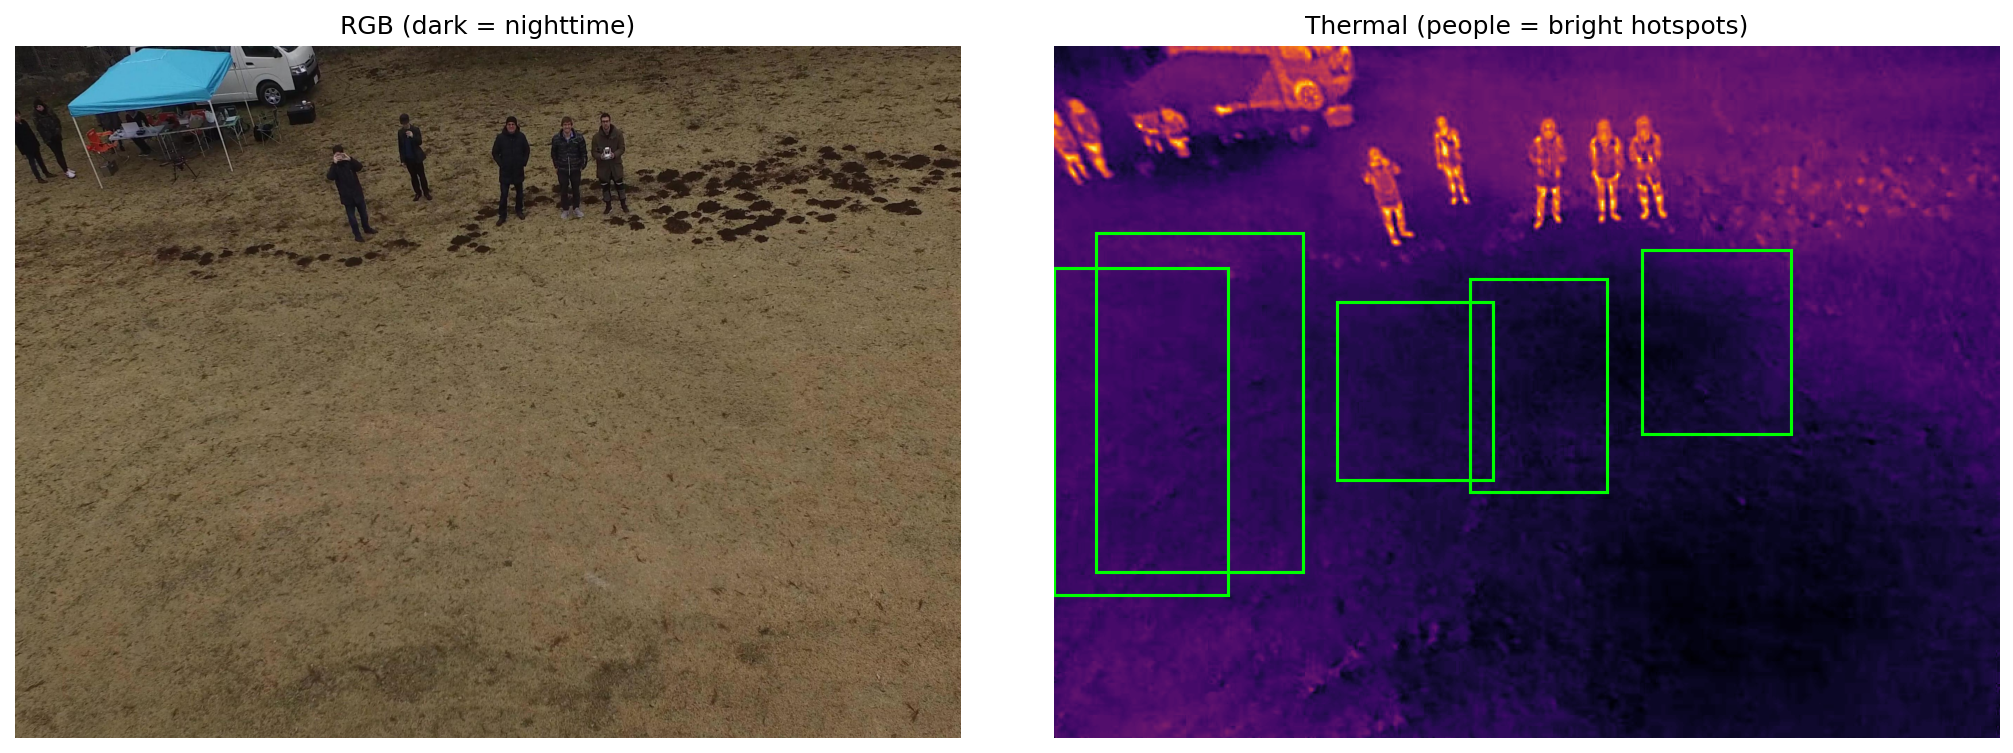


Data verified. Ready for crop extraction.


In [3]:
# Loading helpers
def load_thermal(path: Path) -> np.ndarray:
    """
    Load thermal JPEG and extract single-channel grayscale.
    All three channels are identical (grayscale stored as RGB).
    Returns (H, W) uint8 array, range [76, 235].
    """
    arr = np.array(Image.open(str(path)))  # (513, 701, 3)
    return arr[:, :, 0]                    # take channel 0, discard G and B

def load_rgb(path: Path) -> np.ndarray:
    """Load RGB JPEG. Returns (H, W, 3) uint8 array."""
    return np.array(Image.open(str(path)))

def parse_label(lbl_path: Path) -> List[Tuple]:
    """
    Parse NII-CU label file.
    Format: x1 y1 x2 y2 class flag1 flag2 (absolute thermal coords)
    Returns list of (x1, y1, x2, y2) in thermal pixel space.
    """
    bboxes = []
    with open(str(lbl_path)) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            vals = [float(v) for v in line.split()]
            x1, y1, x2, y2 = vals[0], vals[1], vals[2], vals[3]
            bboxes.append((x1, y1, x2, y2))
    return bboxes

def th_bbox_to_rgb_bbox(x1, y1, x2, y2):
    """Scale bbox from thermal space to RGB space."""
    return (x1*SCALE_W, y1*SCALE_H, x2*SCALE_W, y2*SCALE_H)

# Verify one sample
sample = "flight1_frame00461"
rgb = load_rgb(RGB_TRAIN / f"{sample}.jpg")
th  = load_thermal(TH_TRAIN / f"{sample}.jpg")
bbs = parse_label(LBL_TRAIN / f"{sample}.txt")

print(f"RGB  shape: {rgb.shape}  dtype: {rgb.dtype}")
print(f"TH   shape: {th.shape}   dtype: {th.dtype}  range: [{th.min()},{th.max()}]")
print(f"Bboxes: {len(bbs)}")
for bb in bbs[:3]:
    x1,y1,x2,y2 = bb
    print(f"  TH:  ({x1:.0f},{y1:.0f}) → ({x2:.0f},{y2:.0f})  "
          f"size={x2-x1:.0f}×{y2-y1:.0f}")
    rx1,ry1,rx2,ry2 = th_bbox_to_rgb_bbox(*bb)
    print(f"  RGB: ({rx1:.0f},{ry1:.0f}) → ({rx2:.0f},{ry2:.0f})  "
          f"size={rx2-rx1:.0f}×{ry2-ry1:.0f}")

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb); axes[0].set_title("RGB (dark = nighttime)")
axes[1].imshow(th, cmap='inferno'); axes[1].set_title("Thermal (people = bright hotspots)")
for ax in axes: ax.axis('off')
# Draw bboxes on thermal
for x1,y1,x2,y2 in bbs:
    import matplotlib.patches as patches
    axes[1].add_patch(patches.Rectangle(
        (x1,y1), x2-x1, y2-y1,
        linewidth=1.5, edgecolor='lime', facecolor='none'))
plt.tight_layout()
plt.savefig(NII_FIG/"nii_sample_verify.pdf", bbox_inches='tight')
plt.show()
print("\nData verified. Ready for crop extraction.")

## Section 2 : Crop Extraction

**Strategy:**
- Work in thermal coordinate space (701×513)
- Anomaly crops: 160×160 thermal centred on each bbox  +  corresponding RGB crop at scaled coords
- Normal crops: 160×160 thermal grid tiles with zero IoU against all bboxes  +  corresponding RGB
- Both saved as uint8 .npy files then packed into memmap for fast loading

**Why 160×160 in thermal space:**
- Median person bbox ≈ 110×145 px → 160×160 comfortably contains each person
- At stride 160, 701×513 image yields ~12 non-overlapping tiles
- Sufficient normal crop supply per image

In [4]:
# IoU helper
def bbox_iou(b1, b2):
    """IoU between two (x1,y1,x2,y2) boxes."""
    ix1 = max(b1[0],b2[0]); iy1 = max(b1[1],b2[1])
    ix2 = min(b1[2],b2[2]); iy2 = min(b1[3],b2[3])
    iw = max(0, ix2-ix1); ih = max(0, iy2-iy1)
    inter = iw*ih
    a1 = (b1[2]-b1[0])*(b1[3]-b1[1])
    a2 = (b2[2]-b2[0])*(b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / (union + 1e-8)

# Crop extraction
def extract_nii_crops(
    rgb_dir: Path, th_dir: Path, lbl_dir: Path,
    out_root: Path, split_name: str,
    crop_th: int = CROP_TH, stride: int = STRIDE,
) -> pd.DataFrame:
    """
    Extract paired RGB+thermal crops from NII-CU images.

    Anomaly: 160×160 thermal centred on each person bbox → label=1
    Normal:  160×160 thermal grid tiles, zero IoU with all bboxes → label=0

    For each thermal crop, the corresponding RGB region is computed by
    scaling coordinates by SCALE_W and SCALE_H, then resized to IMG_SIZE.

    Saves: out_root/split_name/rgb/  and  out_root/split_name/thermal/
    Returns DataFrame index.
    """
    out_rgb = out_root / split_name / "rgb"
    out_th  = out_root / split_name / "thermal"
    out_rgb.mkdir(parents=True, exist_ok=True)
    out_th.mkdir(parents=True, exist_ok=True)

    stems = sorted(f.stem for f in lbl_dir.glob("*.txt"))
    records = []

    for stem in tqdm(stems, desc=f"Extracting {split_name}"):
        rgb_path = rgb_dir / f"{stem}.jpg"
        th_path  = th_dir  / f"{stem}.jpg"
        lbl_path = lbl_dir / f"{stem}.txt"

        if not rgb_path.exists() or not th_path.exists(): continue

        rgb_arr = load_rgb(rgb_path)        # (1980, 2706, 3)
        th_arr  = load_thermal(th_path)     # (513,  701)
        bboxes  = parse_label(lbl_path)     # [(x1,y1,x2,y2), ...]

        crop_id = 0

        # Anomaly crops
        for x1,y1,x2,y2 in bboxes:
            # Centre of person bbox in thermal space
            cx = (x1 + x2) / 2
            cy = (y1 + y2) / 2

            # Thermal crop window (clamped to image bounds)
            tx1 = int(max(0, min(cx - crop_th//2, TH_W - crop_th)))
            ty1 = int(max(0, min(cy - crop_th//2, TH_H - crop_th)))
            tx2, ty2 = tx1 + crop_th, ty1 + crop_th

            # Corresponding RGB crop (scale by SCALE_W, SCALE_H)
            rx1 = int(tx1 * SCALE_W); ry1 = int(ty1 * SCALE_H)
            rx2 = int(tx2 * SCALE_W); ry2 = int(ty2 * SCALE_H)
            rx2 = min(rx2, RGB_W); ry2 = min(ry2, RGB_H)

            th_crop  = th_arr[ty1:ty2, tx1:tx2]
            rgb_crop = rgb_arr[ry1:ry2, rx1:rx2]

            if th_crop.shape != (crop_th, crop_th): continue
            if rgb_crop.shape[0] < 10 or rgb_crop.shape[1] < 10: continue

            rp = out_rgb / f"{stem}_c{crop_id:04d}_anom.npy"
            tp = out_th  / f"{stem}_c{crop_id:04d}_anom.npy"
            np.save(str(rp), rgb_crop)
            np.save(str(tp), th_crop)
            records.append({"stem":stem, "crop_id":crop_id,
                "rgb_npy":str(rp), "thermal_npy":str(tp), "label":1})
            crop_id += 1

        # Normal crops
        # Tile the thermal image, skip tiles overlapping any bbox
        for ty in range(0, TH_H - crop_th + 1, stride):
            for tx in range(0, TH_W - crop_th + 1, stride):
                tile = (tx, ty, tx+crop_th, ty+crop_th)
                if any(bbox_iou(tile, b) > 0.0 for b in bboxes):
                    continue

                rx1 = int(tx  * SCALE_W); ry1 = int(ty  * SCALE_H)
                rx2 = int((tx+crop_th)*SCALE_W)
                ry2 = int((ty+crop_th)*SCALE_H)
                rx2 = min(rx2, RGB_W); ry2 = min(ry2, RGB_H)

                th_crop  = th_arr[ty:ty+crop_th, tx:tx+crop_th]
                rgb_crop = rgb_arr[ry1:ry2, rx1:rx2]

                if rgb_crop.shape[0] < 10 or rgb_crop.shape[1] < 10: continue

                rp = out_rgb / f"{stem}_c{crop_id:04d}_norm.npy"
                tp = out_th  / f"{stem}_c{crop_id:04d}_norm.npy"
                np.save(str(rp), rgb_crop)
                np.save(str(tp), th_crop)
                records.append({"stem":stem, "crop_id":crop_id,
                    "rgb_npy":str(rp), "thermal_npy":str(tp), "label":0})
                crop_id += 1

    df = pd.DataFrame(records)
    df.to_csv(out_root / f"{split_name}_index.csv", index=False)
    n_a = (df['label']==1).sum(); n_n = (df['label']==0).sum()
    print(f"\n{split_name}: {len(df)} crops | "
          f"anomaly={n_a} ({n_a/len(df)*100:.1f}%) | normal={n_n}")
    return df

In [ ]:
# Cached crop indices are reused when available.
# Rebuilding is required only when reconstructing the crop dataset
# from the original NII-CU release.

# Build or load cached index
TRAIN_IDX = NII_OUT / "train_index.csv"
VAL_IDX   = NII_OUT / "val_index.csv"

if TRAIN_IDX.exists():
    print("Loading cached train index...")
    nii_train_df = pd.read_csv(TRAIN_IDX)
else:
    print("Extracting train crops (~15-25 min)...")
    nii_train_df = extract_nii_crops(
        RGB_TRAIN, TH_TRAIN, LBL_TRAIN, NII_OUT, "train")

if VAL_IDX.exists():
    print("Loading cached val index...")
    nii_val_df = pd.read_csv(VAL_IDX)
else:
    print("Extracting val crops...")
    nii_val_df = extract_nii_crops(
        RGB_VAL, TH_VAL, LBL_VAL, NII_OUT, "val")

print(f"\nTrain: {len(nii_train_df)} crops")
print(f"Val:   {len(nii_val_df)} crops")
print(nii_train_df['label'].value_counts())

Loading cached train index...
Loading cached val index...

Train: 41517 crops
Val:   6668 crops
label
0    31373
1    10144
Name: count, dtype: int64


## Section 3 : Pack to Memmap and Build Dataloaders

In [6]:
# Pack crops to memmap for fast loading
def pack_to_memmap(df, out_root, split_name):
    """
    Pack individual .npy crop files into memory-mapped arrays.
    RGB crops may have variable size (due to scaling) — resize to IMG_SIZE here.
    """
    N = len(df)
    mm_r = np.memmap(out_root/f"{split_name}_rgb.mmap",
                     dtype='uint8', mode='w+',
                     shape=(N, IMG_SIZE, IMG_SIZE, 3))
    mm_t = np.memmap(out_root/f"{split_name}_th.mmap",
                     dtype='uint8', mode='w+',
                     shape=(N, CROP_TH, CROP_TH))
    mm_l = np.memmap(out_root/f"{split_name}_labels.mmap",
                     dtype='int8',  mode='w+', shape=(N,))

    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=N,
                                       desc=f"Packing {split_name}")):
        rgb_raw = np.load(row['rgb_npy'])
        th_raw  = np.load(row['thermal_npy'])
        # Resize RGB to IMG_SIZE (variable source size due to scaling)
        rgb_pil = Image.fromarray(rgb_raw).resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mm_r[i] = np.array(rgb_pil)
        mm_t[i] = th_raw
        mm_l[i] = int(row['label'])

    mm_r.flush(); mm_t.flush(); mm_l.flush()
    size_gb = (N * IMG_SIZE * IMG_SIZE * 3) / 1e9
    print(f"{split_name}: packed {N} crops → {size_gb:.1f} GB")

for df_s, name in [(nii_train_df,"tr"),(nii_val_df,"va")]:
    if not (NII_OUT/f"{name}_labels.mmap").exists():
        pack_to_memmap(df_s, NII_OUT, name)
    else:
        print(f"  {name}: memmap exists, skipping")
print("Packing complete.")

  tr: memmap exists, skipping
  va: memmap exists, skipping
Packing complete.


In [ ]:
# Dataset class
class NIIDataset(Dataset):
    """
    Paired RGB+Thermal crop dataset for NII-CU person detection.

    RGB:     (3, 224, 224) float32  — ImageNet normalised
    Thermal: (1, 224, 224) float32  — normalised (mean=0.5, std=0.25)
             Single channel uint8, range [76,235]
    Label:   0=no person (normal)  1=person present (anomaly)

    Structurally identical to PairedModuleDataset for valid comparison.
    """
    def __init__(self, df, out_root, split_name, split='train'):
        N = len(df)
        self.rgb = np.memmap(out_root/f"{split_name}_rgb.mmap",
                             dtype='uint8', mode='r',
                             shape=(N, IMG_SIZE, IMG_SIZE, 3))
        self.th  = np.memmap(out_root/f"{split_name}_th.mmap",
                             dtype='uint8', mode='r',
                             shape=(N, CROP_TH, CROP_TH))
        self.lbl = np.memmap(out_root/f"{split_name}_labels.mmap",
                             dtype='int8',  mode='r', shape=(N,))
        self.training = (split == 'train')

        self.th_resize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
        ])
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.1)
        self.rgb_norm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225)),
        ])
        self.th_norm = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,),(0.25,)),
        ])

    def __len__(self): return len(self.lbl)

    def __getitem__(self, idx):
        rgb = self.rgb[idx].copy()           # (224,224,3) already resized
        th  = self.th[idx].copy()            # (160,160) uint8
        if th.ndim == 2: th = th[:,:,None]   # (160,160,1)

        rgb_pil = Image.fromarray(rgb)
        th_pil  = self.th_resize(th)         # resize to 224×224

        if self.training:
            if torch.rand(1).item() < 0.5:
                rgb_pil = transforms.functional.hflip(rgb_pil)
                th_pil  = transforms.functional.hflip(th_pil)
            if torch.rand(1).item() < 0.3:
                rgb_pil = transforms.functional.vflip(rgb_pil)
                th_pil  = transforms.functional.vflip(th_pil)
            rgb_pil = self.color_jitter(rgb_pil)

        return (self.rgb_norm(rgb_pil),
                self.th_norm(th_pil),
                torch.tensor(int(self.lbl[idx]), dtype=torch.long))

# Build dataloaders
# NII-CU provides train/val split. We use val as test (held-out)
# Create internal val from train for model selection
tr_imgs = nii_train_df['stem'].unique()
tr_has_anom = (nii_train_df.groupby('stem')['label'].max()
               .reindex(tr_imgs).fillna(0).astype(int).values)
tr_stems, va_stems = train_test_split(
    tr_imgs, test_size=0.15, random_state=SEED, stratify=tr_has_anom)

tr_df = nii_train_df[nii_train_df['stem'].isin(tr_stems)].reset_index(drop=True)
va_df = nii_train_df[nii_train_df['stem'].isin(va_stems)].reset_index(drop=True)
te_df = nii_val_df.reset_index(drop=True)

# Pack internal splits
for df_s, name in [(tr_df,"tr2"),(va_df,"va2"),(te_df,"te2")]:
    if not (NII_OUT/f"{name}_labels.mmap").exists():
        pack_to_memmap(df_s, NII_OUT, name)
    else:
        print(f"  {name}: memmap exists")

dsets = {
    'train': NIIDataset(tr_df, NII_OUT, "tr2", 'train'),
    'val':   NIIDataset(va_df, NII_OUT, "va2", 'val'),
    'test':  NIIDataset(te_df, NII_OUT, "te2", 'test'),
}
lbl  = tr_df['label'].values
sw   = (1.0 / np.bincount(lbl))[lbl]
samp = WeightedRandomSampler(sw, len(sw))

loaders = {
    'train': DataLoader(dsets['train'], batch_size=BATCH_SIZE,
                        sampler=samp, num_workers=0),
    'val':   DataLoader(dsets['val'],   batch_size=BATCH_SIZE,
                        shuffle=False,  num_workers=0),
    'test':  DataLoader(dsets['test'],  batch_size=BATCH_SIZE,
                        shuffle=False,  num_workers=0),
}

print("\nNII-CU image-level split:")
for k, ds in dsets.items():
    lbl_arr = np.array(ds.lbl[:])
    rate = (lbl_arr==1).sum() / len(lbl_arr) * 100
    print(f"  {k:5s} | {len(ds):6d} crops | anomaly: {rate:.1f}%")

  tr2: memmap exists
  va2: memmap exists
  te2: memmap exists

NII-CU image-level split:
  train |  35341 crops | anomaly: 24.6%
  val   |   6176 crops | anomaly: 23.7%
  test  |   6668 crops | anomaly: 13.4%


### Annotation-format audit

In [ ]:
from collections import Counter

def audit_annotation_fields(label_dir):
    combinations = Counter()
    row_count = 0

    for path in sorted(label_dir.glob("*.txt")):
        with open(path) as file:
            for line in file:
                values = line.strip().split()
                if not values:
                    continue

                if len(values) < 7:
                    raise ValueError(
                        f"{path.name} has only {len(values)} fields."
                    )

                class_id = values[4]
                flag1 = values[5]
                flag2 = values[6]

                combinations[(class_id, flag1, flag2)] += 1
                row_count += 1

    return row_count, combinations

for split_name, label_dir in {
    "train": LBL_TRAIN,
    "val": LBL_VAL,
}.items():
    total, combinations = audit_annotation_fields(label_dir)
    print(f"\n{split_name}: {total} annotations")
    for combination, count in combinations.most_common():
        print(combination, count)


train: 10144 annotations
('0', '0', '0') 9311
('0', '1', '0') 833

val: 891 annotations
('0', '0', '0') 475
('0', '1', '0') 416


### Thermal-feature separability audit

In [9]:
def extract_thermal_statistics(df):
    rows = []

    for index, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Thermal statistics",
    ):
        thermal = np.load(row["thermal_npy"]).astype(np.float32)

        h, w = thermal.shape
        y1, y2 = h // 4, 3 * h // 4
        x1, x2 = w // 4, 3 * w // 4

        center = thermal[y1:y2, x1:x2]

        border_mask = np.ones((h, w), dtype=bool)
        border_mask[y1:y2, x1:x2] = False
        border = thermal[border_mask]

        rows.append({
            "index": index,
            "stem": row["stem"],
            "label": int(row["label"]),
            "mean": float(thermal.mean()),
            "maximum": float(thermal.max()),
            "median": float(np.median(thermal)),
            "std": float(thermal.std()),
            "p90": float(np.percentile(thermal, 90)),
            "p95": float(np.percentile(thermal, 95)),
            "p99": float(np.percentile(thermal, 99)),
            "center_mean": float(center.mean()),
            "center_max": float(center.max()),
            "border_mean": float(border.mean()),
            "center_minus_border": float(
                center.mean() - border.mean()
            ),
        })

    return pd.DataFrame(rows)

thermal_train_features = extract_thermal_statistics(nii_train_df)
thermal_test_features = extract_thermal_statistics(nii_val_df)

Thermal statistics:   0%|          | 0/41517 [00:00<?, ?it/s]

Thermal statistics:   0%|          | 0/6668 [00:00<?, ?it/s]

In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

FEATURES = [
    "mean",
    "maximum",
    "median",
    "std",
    "p90",
    "p95",
    "p99",
    "center_mean",
    "center_max",
    "border_mean",
    "center_minus_border",
]

X_train = thermal_train_features[FEATURES].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

y_train = thermal_train_features["label"].astype(int)

X_test = thermal_test_features[FEATURES].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

y_test = thermal_test_features["label"].astype(int)


def evaluate_binary_model(name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "specificity": specificity,
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(
            y_true, probabilities
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


results = []

# Logistic regression using all simple thermal features
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        ),
    ),
])

logistic_model.fit(X_train, y_train)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

results.append(
    evaluate_binary_model(
        "Logistic regression — all thermal statistics",
        y_test,
        logistic_probabilities,
    )
)

# Very shallow tree: deliberately low complexity
tree_model = DecisionTreeClassifier(
    max_depth=2,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
)

tree_model.fit(X_train, y_train)
tree_probabilities = tree_model.predict_proba(X_test)[:, 1]

results.append(
    evaluate_binary_model(
        "Decision tree — depth 2",
        y_test,
        tree_probabilities,
    )
)

baseline_results = pd.DataFrame(results)
display(baseline_results.round(4))

,model,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,Logistic regression — all thermal statistics,0.6167,0.2475,0.9158,0.5705,0.3897,0.7990,0.3154,3296,2481,75,816
1,Decision tree — depth 2,0.6449,0.2631,0.9203,0.6024,0.4092,0.8033,0.3001,3480,2297,71,820


In [11]:
individual_feature_results = []

for feature in FEATURES:
    train_values = X_train[[feature]]
    test_values = X_test[[feature]]

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ])

    model.fit(train_values, y_train)
    probabilities = model.predict_proba(test_values)[:, 1]

    row = evaluate_binary_model(
        f"Single feature: {feature}",
        y_test,
        probabilities,
    )
    row["feature"] = feature
    individual_feature_results.append(row)

individual_feature_results = (
    pd.DataFrame(individual_feature_results)
    .sort_values("roc_auc", ascending=False)
)

display(
    individual_feature_results[
        [
            "feature",
            "accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "roc_auc",
            "average_precision",
            "fp",
            "fn",
        ]
    ].round(4)
)

,feature,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,fp,fn
9,border_mean,0.7065,0.2937,0.8519,0.6841,0.4368,0.8451,0.3994,1825,132
0,mean,0.7073,0.2951,0.8575,0.6841,0.4391,0.8413,0.3823,1825,127
4,p90,0.6444,0.2588,0.8911,0.6064,0.4011,0.8338,0.3551,2274,97
6,p99,0.6251,0.2537,0.9304,0.5780,0.3987,0.8337,0.3470,2438,62
2,median,0.6998,0.2900,0.8608,0.6749,0.4338,0.8333,0.3575,1878,124
5,p95,0.6398,0.2582,0.9057,0.5988,0.4019,0.8316,0.3482,2318,84
7,center_mean,0.7002,0.2876,0.8418,0.6784,0.4287,0.8202,0.3269,1858,141
8,center_max,0.5915,0.2363,0.9214,0.5406,0.3761,0.8086,0.3245,2654,70
1,maximum,0.4907,0.1849,0.8249,0.4392,0.3021,0.7332,0.3153,3240,156
3,std,0.4658,0.1692,0.7666,0.4194,0.2772,0.5838,0.1446,3354,208


In [12]:
separability_summary = []

for feature in FEATURES:
    negatives = thermal_test_features.loc[
        thermal_test_features["label"] == 0, feature
    ]
    positives = thermal_test_features.loc[
        thermal_test_features["label"] == 1, feature
    ]

    separability_summary.append({
        "feature": feature,
        "negative_min": negatives.min(),
        "negative_max": negatives.max(),
        "positive_min": positives.min(),
        "positive_max": positives.max(),
        "median_negative": negatives.median(),
        "median_positive": positives.median(),
        "strict_gap":
            positives.min() > negatives.max()
            or negatives.min() > positives.max(),
    })

separability_summary = pd.DataFrame(separability_summary)

display(
    separability_summary.sort_values(
        ["strict_gap", "feature"],
        ascending=[False, True],
    ).round(3)
)

,feature,negative_min,negative_max,positive_min,positive_max,median_negative,median_positive,strict_gap
9,border_mean,85.566,163.258,85.839,154.414,118.221,103.938,False
8,center_max,91.000,247.000,94.000,223.000,132.000,115.000,False
7,center_mean,85.183,168.229,85.932,158.789,118.231,105.231,False
10,center_minus_border,-15.481,19.295,-9.120,7.022,0.010,0.191,False
1,maximum,94.000,247.000,100.000,239.000,145.000,121.000,False
0,mean,85.628,163.358,85.862,155.508,118.239,103.738,False
2,median,86.000,164.000,86.000,159.000,118.000,104.000,False
4,p90,88.000,175.000,91.000,172.000,125.000,112.000,False
5,p95,89.000,177.000,93.000,175.000,128.000,114.000,False
6,p99,90.000,202.000,95.000,178.000,133.000,116.000,False


In [13]:
baseline_results.to_csv(
    NII_OUT / "thermal_trivial_baseline_results.csv",
    index=False,
)

individual_feature_results.to_csv(
    NII_OUT / "thermal_single_feature_results.csv",
    index=False,
)

separability_summary.to_csv(
    NII_OUT / "thermal_separability_summary.csv",
    index=False,
)

thermal_train_features.to_csv(
    NII_OUT / "thermal_features_train.csv",
    index=False,
)

thermal_test_features.to_csv(
    NII_OUT / "thermal_features_test.csv",
    index=False,
)

print("Saved all thermal baseline audit outputs.")

Saved all thermal baseline audit outputs.


### Low-resolution thermal baseline

In [14]:
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from PIL import Image

DOWNSAMPLED_SIZE = (16, 16)


def build_downsampled_features(df, split_name):
    features = []
    metadata = []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"Downsampling {split_name}",
    ):
        thermal = np.load(row["thermal_npy"]).astype(np.uint8)

        small = Image.fromarray(thermal).resize(
            DOWNSAMPLED_SIZE,
            resample=Image.Resampling.BILINEAR,
        )

        vector = np.asarray(small, dtype=np.float32).reshape(-1) / 255.0

        features.append(vector)
        metadata.append({
            "stem": row["stem"],
            "label": int(row["label"]),
            "thermal_npy": row["thermal_npy"],
        })

    return np.stack(features), pd.DataFrame(metadata)


X_train_16, train_meta_16 = build_downsampled_features(
    nii_train_df,
    "train",
)

X_test_16, test_meta_16 = build_downsampled_features(
    nii_val_df,
    "held-out test",
)

y_train_16 = train_meta_16["label"].to_numpy()
y_test_16 = test_meta_16["label"].to_numpy()

print("Train:", X_train_16.shape, y_train_16.shape)
print("Test:", X_test_16.shape, y_test_16.shape)

Downsampling train:   0%|          | 0/41517 [00:00<?, ?it/s]

Downsampling held-out test:   0%|          | 0/6668 [00:00<?, ?it/s]

Train: (41517, 256) (41517,)
Test: (6668, 256) (6668,)


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


def evaluate_probabilities(name, y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "specificity": specificity,
        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(
            y_true,
            probabilities,
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


pixel_logistic = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42,
        ),
    ),
])

pixel_logistic.fit(X_train_16, y_train_16)

pixel_probabilities = pixel_logistic.predict_proba(
    X_test_16
)[:, 1]

pixel_result = evaluate_probabilities(
    "Logistic regression — 16x16 thermal pixels",
    y_test_16,
    pixel_probabilities,
)

pixel_result_df = pd.DataFrame([pixel_result])
display(pixel_result_df.round(4))

,model,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,Logistic regression — 16x16 thermal pixels,0.7818,0.3353,0.6442,0.803,0.441,0.8098,0.339,4639,1138,317,574


In [16]:
positive_centroid = X_train_16[y_train_16 == 1].mean(axis=0)
negative_centroid = X_train_16[y_train_16 == 0].mean(axis=0)

distance_to_positive = np.linalg.norm(
    X_test_16 - positive_centroid,
    axis=1,
)

distance_to_negative = np.linalg.norm(
    X_test_16 - negative_centroid,
    axis=1,
)

centroid_scores = (
    distance_to_negative
    - distance_to_positive
)

centroid_result = evaluate_probabilities(
    "Nearest centroid — 16x16 thermal pixels",
    y_test_16,
    centroid_scores,
    threshold=0.0,
)

centroid_result_df = pd.DataFrame([centroid_result])
display(centroid_result_df.round(4))

,model,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,Nearest centroid — 16x16 thermal pixels,0.6924,0.2857,0.8676,0.6654,0.4298,0.8431,0.4114,3844,1933,118,773


### Train-test leakage and duplicate audit

In [17]:
import hashlib


def array_hash(path):
    array = np.load(path)
    return hashlib.sha256(array.tobytes()).hexdigest()


train_hashes = {}

for _, row in tqdm(
    nii_train_df.iterrows(),
    total=len(nii_train_df),
    desc="Hashing train crops",
):
    crop_hash = array_hash(row["thermal_npy"])

    train_hashes.setdefault(crop_hash, []).append({
        "stem": row["stem"],
        "label": int(row["label"]),
        "path": row["thermal_npy"],
    })


duplicate_rows = []

for _, row in tqdm(
    nii_val_df.iterrows(),
    total=len(nii_val_df),
    desc="Checking test duplicates",
):
    crop_hash = array_hash(row["thermal_npy"])

    if crop_hash in train_hashes:
        for train_match in train_hashes[crop_hash]:
            duplicate_rows.append({
                "test_stem": row["stem"],
                "test_label": int(row["label"]),
                "test_path": row["thermal_npy"],
                "train_stem": train_match["stem"],
                "train_label": train_match["label"],
                "train_path": train_match["path"],
                "same_label":
                    int(row["label"]) == train_match["label"],
            })


exact_duplicates_df = pd.DataFrame(duplicate_rows)

print(
    "Exact train-test duplicate matches:",
    len(exact_duplicates_df),
)

if not exact_duplicates_df.empty:
    display(exact_duplicates_df.head(20))

Hashing train crops:   0%|          | 0/41517 [00:00<?, ?it/s]

Checking test duplicates:   0%|          | 0/6668 [00:00<?, ?it/s]

Exact train-test duplicate matches: 0


In [18]:
train_stems = set(
    nii_train_df["stem"].astype(str).unique()
)

test_stems = set(
    nii_val_df["stem"].astype(str).unique()
)

stem_overlap = sorted(train_stems.intersection(test_stems))

print("Unique train stems:", len(train_stems))
print("Unique test stems:", len(test_stems))
print("Overlapping stems:", len(stem_overlap))

if stem_overlap:
    print(stem_overlap[:20])

Unique train stems: 2653
Unique test stems: 485
Overlapping stems: 0


In [19]:
def average_hash_from_array(array, size=16):
    image = Image.fromarray(array.astype(np.uint8))
    image = image.resize(
        (size, size),
        resample=Image.Resampling.BILINEAR,
    )

    small = np.asarray(image, dtype=np.float32)
    bits = small >= small.mean()

    return bits.reshape(-1).astype(np.uint8)


def hamming_distance(hash_a, hash_b):
    return int(np.count_nonzero(hash_a != hash_b))

In [20]:
from sklearn.neighbors import NearestNeighbors

nearest_neighbor_model = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean",
    algorithm="auto",
    n_jobs=-1,
)

nearest_neighbor_model.fit(X_train_16)

nearest_distances, nearest_indices = (
    nearest_neighbor_model.kneighbors(X_test_16)
)

nearest_distances = nearest_distances[:, 0]
nearest_indices = nearest_indices[:, 0]

near_duplicate_df = test_meta_16.copy()

near_duplicate_df["nearest_train_index"] = nearest_indices
near_duplicate_df["nearest_distance"] = nearest_distances

near_duplicate_df["nearest_train_stem"] = [
    train_meta_16.iloc[index]["stem"]
    for index in nearest_indices
]

near_duplicate_df["nearest_train_label"] = [
    int(train_meta_16.iloc[index]["label"])
    for index in nearest_indices
]

near_duplicate_df["same_label"] = (
    near_duplicate_df["label"]
    == near_duplicate_df["nearest_train_label"]
)

display(
    near_duplicate_df
    .sort_values("nearest_distance")
    .head(30)
)

,stem,label,thermal_npy,nearest_train_index,nearest_distance,nearest_train_stem,nearest_train_label,same_label
3366,flight3_frame20901,0,nii_crops/val/thermal/flight3_frame20901_c0002...,178,0.077742,flight1_frame00671,0,True
4799,flight3_frame22881,0,nii_crops/val/thermal/flight3_frame22881_c0004...,28715,0.080464,flight2_frame21141,0,True
4409,flight3_frame22391,0,nii_crops/val/thermal/flight3_frame22391_c0002...,28817,0.083281,flight2_frame21211,0,True
2519,flight3_frame19161,0,nii_crops/val/thermal/flight3_frame19161_c0006...,28563,0.084564,flight2_frame21041,0,True
5074,flight3_frame23321,0,nii_crops/val/thermal/flight3_frame23321_c0003...,40508,0.084836,flight3_frame05391,0,True
3770,flight3_frame21871,0,nii_crops/val/thermal/flight3_frame21871_c0001...,28817,0.087337,flight2_frame21211,0,True
3991,flight3_frame22041,0,nii_crops/val/thermal/flight3_frame22041_c0001...,28817,0.087601,flight2_frame21211,0,True
4325,flight3_frame22331,0,nii_crops/val/thermal/flight3_frame22331_c0002...,28757,0.087601,flight2_frame21171,0,True
2206,flight3_frame18791,0,nii_crops/val/thermal/flight3_frame18791_c0003...,28511,0.088214,flight2_frame20971,0,True
3965,flight3_frame22021,0,nii_crops/val/thermal/flight3_frame22021_c0001...,28802,0.088735,flight2_frame21201,0,True


In [21]:
print(
    pd.Series(nearest_distances)
    .describe(
        percentiles=[
            0.001,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

count    6668.000000
mean        0.252336
std         0.122138
min         0.077742
0.1%        0.087601
1%          0.099183
5%          0.120683
25%         0.161381
50%         0.218994
75%         0.308479
95%         0.521785
99%         0.627306
max         0.947382
dtype: float64


In [22]:
pixel_result_df.to_csv(
    NII_OUT / "thermal_16x16_logistic_result.csv",
    index=False,
)

centroid_result_df.to_csv(
    NII_OUT / "thermal_16x16_centroid_result.csv",
    index=False,
)

exact_duplicates_df.to_csv(
    NII_OUT / "thermal_exact_train_test_duplicates.csv",
    index=False,
)

near_duplicate_df.to_csv(
    NII_OUT / "thermal_nearest_train_crop_audit.csv",
    index=False,
)

np.save(
    NII_OUT / "thermal_train_16x16_features.npy",
    X_train_16,
)

np.save(
    NII_OUT / "thermal_test_16x16_features.npy",
    X_test_16,
)

print("Saved spatial-baseline and duplicate-audit outputs.")

Saved spatial-baseline and duplicate-audit outputs.


## Model Architectures

In [ ]:
import random
from collections import OrderedDict

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# Reproducibility utilities

def reset_random_seeds(seed: int = SEED) -> None:
    """
    Reset Python, NumPy, and PyTorch random states.
    Call this immediately before constructing each model.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        # These settings improve reproducibility on CUDA.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


reset_random_seeds(SEED)

# Backbone helpers

def build_rgb_resnet18() -> nn.Module:
    """
    ImageNet-pretrained ResNet-18 RGB encoder.

    Returns a module that outputs a 512-dimensional embedding.
    """
    backbone = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    backbone.fc = nn.Identity()
    return backbone


def build_thermal_resnet18() -> nn.Module:
    """
    ImageNet-pretrained ResNet-18 modified for one thermal channel.

    The one-channel convolution is initialized using the mean
    of the original RGB convolutional weights.
    """
    backbone = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    original_conv = backbone.conv1

    thermal_conv = nn.Conv2d(
        in_channels=1,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        thermal_conv.weight.copy_(
            original_conv.weight.mean(dim=1, keepdim=True)
        )

    backbone.conv1 = thermal_conv
    backbone.fc = nn.Identity()

    return backbone


def build_early_fusion_resnet18() -> nn.Module:
    """
    ImageNet-pretrained ResNet-18 modified for a four-channel
    RGB-plus-thermal input.

    RGB channels retain their pretrained weights. The thermal
    channel is initialized using the mean RGB convolution.
    """
    backbone = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    original_conv = backbone.conv1

    fusion_conv = nn.Conv2d(
        in_channels=4,
        out_channels=original_conv.out_channels,
        kernel_size=original_conv.kernel_size,
        stride=original_conv.stride,
        padding=original_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        fusion_conv.weight[:, :3].copy_(original_conv.weight)
        fusion_conv.weight[:, 3:4].copy_(
            original_conv.weight.mean(dim=1, keepdim=True)
        )

    backbone.conv1 = fusion_conv
    backbone.fc = nn.Identity()

    return backbone


# Model definitions

class RGBOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = build_rgb_resnet18()
        self.classifier = nn.Linear(512, 2)

    def forward(self, rgb, thermal=None):
        embedding = self.encoder(rgb)
        logits = self.classifier(embedding)
        return logits


class ThermalOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = build_thermal_resnet18()
        self.classifier = nn.Linear(512, 2)

    def forward(self, rgb, thermal=None):
        # Supports either:
        # model(rgb, thermal), or model(thermal)
        if thermal is None:
            thermal = rgb

        embedding = self.encoder(thermal)
        logits = self.classifier(embedding)
        return logits


class EarlyFusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = build_early_fusion_resnet18()
        self.classifier = nn.Linear(512, 2)

    def forward(self, rgb, thermal):
        fused_input = torch.cat([rgb, thermal], dim=1)
        embedding = self.encoder(fused_input)
        logits = self.classifier(embedding)
        return logits


class LateFusionModel(nn.Module):
    """
    Late-fusion architecture used for CCME.

    The modality-specific embeddings remain independently
    accessible before concatenation.
    """

    def __init__(self):
        super().__init__()

        self.rgb_encoder = build_rgb_resnet18()
        self.thermal_encoder = build_thermal_resnet18()

        self.fusion = nn.Sequential(
            nn.LayerNorm(1024),
            nn.Dropout(p=0.30),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.20),
        )

        self.classifier = nn.Linear(256, 2)

    def encode_modalities(self, rgb, thermal):
        rgb_embedding = self.rgb_encoder(rgb)
        thermal_embedding = self.thermal_encoder(thermal)

        return rgb_embedding, thermal_embedding

    def classify_embeddings(
        self,
        rgb_embedding,
        thermal_embedding,
    ):
        concatenated = torch.cat(
            [rgb_embedding, thermal_embedding],
            dim=1,
        )

        fused_embedding = self.fusion(concatenated)
        logits = self.classifier(fused_embedding)

        return logits

    def forward(self, rgb, thermal):
        rgb_embedding, thermal_embedding = (
            self.encode_modalities(rgb, thermal)
        )

        return self.classify_embeddings(
            rgb_embedding,
            thermal_embedding,
        )


# Model factory

MODEL_BUILDERS = OrderedDict({
    "RGB-Only": RGBOnlyModel,
    "Thermal-Only": ThermalOnlyModel,
    "Early-Fusion": EarlyFusionModel,
    "Late-Fusion": LateFusionModel,
})


def build_model(model_name: str, seed: int = SEED) -> nn.Module:
    if model_name not in MODEL_BUILDERS:
        raise ValueError(
            f"Unknown model: {model_name}. "
            f"Available: {list(MODEL_BUILDERS)}"
        )

    reset_random_seeds(seed)

    model = MODEL_BUILDERS[model_name]()
    return model.to(DEVICE)


# Brief architecture check
for model_name in MODEL_BUILDERS:
    temporary_model = build_model(model_name, SEED)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in temporary_model.parameters()
        if parameter.requires_grad
    )

    print(
        f"{model_name:15s} | "
        f"trainable parameters: {trainable_parameters:,}"
    )

    del temporary_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nSection 4 complete.")

RGB-Only        | trainable parameters: 11,177,538
Thermal-Only    | trainable parameters: 11,171,266
Early-Fusion    | trainable parameters: 11,180,674
Late-Fusion     | trainable parameters: 22,611,714

Section 4 complete.


## SECTION 5 : TRAINING
## PRIMARY SEED-42 TRAINING

In [ ]:
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. Output directory for this fresh audit

AUDIT_CKPT = NII_CKPT / "fresh_seed42_audit"
AUDIT_CKPT.mkdir(parents=True, exist_ok=True)

print("Fresh checkpoints will be saved to:")
print(AUDIT_CKPT.resolve())

# 2. Reproducibility

def reset_random_seeds(seed: int = SEED) -> None:
    """
    Reset Python, NumPy, and PyTorch random states.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


reset_random_seeds(SEED)

# 3. Forward-routing helper

def forward_model(
    model_name: str,
    model: nn.Module,
    rgb: torch.Tensor,
    thermal: torch.Tensor,
) -> torch.Tensor:
    """
    Route each architecture to the correct inputs.
    """

    if model_name == "RGB-Only":
        return model(rgb)

    if model_name == "Thermal-Only":
        return model(thermal)

    if model_name in {"Early-Fusion", "Late-Fusion"}:
        return model(rgb, thermal)

    raise ValueError(
        f"Unsupported model name: {model_name}"
    )


# 4. One complete training or validation epoch

def run_epoch(
    model_name: str,
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer=None,
):
    """
    Run one epoch.

    When optimizer is supplied:
        - training mode
        - gradients enabled
        - parameters updated

    When optimizer is None:
        - evaluation mode
        - no gradients
    """

    is_training = optimizer is not None
    model.train(is_training)

    running_loss = 0.0

    label_batches = []
    probability_batches = []

    context = (
        torch.enable_grad()
        if is_training
        else torch.no_grad()
    )

    with context:
        for batch_index, batch in enumerate(loader):

            if len(batch) != 3:
                raise ValueError(
                    "Expected each batch to contain "
                    "(rgb, thermal, labels), but received "
                    f"{len(batch)} elements."
                )

            rgb, thermal, labels = batch

            rgb = rgb.to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            thermal = thermal.to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            # Force labels to one-dimensional integer array.
            labels = labels.to(
                DEVICE,
                dtype=torch.long,
                non_blocking=True,
            ).reshape(-1)

            if is_training:
                optimizer.zero_grad(set_to_none=True)

            logits = forward_model(
                model_name=model_name,
                model=model,
                rgb=rgb,
                thermal=thermal,
            )

            # Binary classifier must return (batch_size, 2).
            if logits.ndim != 2:
                raise ValueError(
                    f"{model_name} returned logits with "
                    f"{logits.ndim} dimensions and shape "
                    f"{tuple(logits.shape)}. "
                    "Expected shape (batch_size, 2)."
                )

            if logits.shape[1] != 2:
                raise ValueError(
                    f"{model_name} returned "
                    f"{logits.shape[1]} output classes. "
                    "Expected exactly 2."
                )

            if logits.shape[0] != labels.shape[0]:
                raise ValueError(
                    "Logit and label batch sizes differ: "
                    f"{logits.shape[0]} versus "
                    f"{labels.shape[0]}."
                )

            loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"Non-finite loss detected for "
                    f"{model_name} in batch {batch_index}: "
                    f"{loss.item()}"
                )

            if is_training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                optimizer.step()

            probabilities = torch.softmax(
                logits,
                dim=1,
            )[:, 1]

            batch_size = labels.shape[0]

            running_loss += (
                float(loss.detach().cpu().item())
                * batch_size
            )

            # Store each batch separately, always as 1-D.
            label_batches.append(
                labels.detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

            probability_batches.append(
                probabilities.detach()
                .cpu()
                .numpy()
                .reshape(-1)
            )

    if len(label_batches) == 0:
        raise RuntimeError(
            f"The {model_name} loader produced no batches."
        )

    # Concatenate into flat arrays of shape (N,).
    labels_array = np.concatenate(
        label_batches,
        axis=0,
    ).astype(np.int64)

    probability_array = np.concatenate(
        probability_batches,
        axis=0,
    ).astype(np.float64)

    # Defensive shape checks.
    labels_array = labels_array.reshape(-1)
    probability_array = probability_array.reshape(-1)

    if labels_array.ndim != 1:
        raise RuntimeError(
            "Labels were not converted to a 1-D array: "
            f"{labels_array.shape}"
        )

    if probability_array.ndim != 1:
        raise RuntimeError(
            "Probabilities were not converted to a 1-D array: "
            f"{probability_array.shape}"
        )

    if len(labels_array) != len(probability_array):
        raise RuntimeError(
            "The number of labels and probabilities differs: "
            f"{len(labels_array)} versus "
            f"{len(probability_array)}."
        )

    if len(labels_array) != len(loader.dataset):
        raise RuntimeError(
            "The number of evaluated samples does not match "
            "the dataset size: "
            f"{len(labels_array)} versus "
            f"{len(loader.dataset)}."
        )

    if not np.isfinite(probability_array).all():
        bad_count = int(
            (~np.isfinite(probability_array)).sum()
        )

        raise RuntimeError(
            f"Detected {bad_count} non-finite probabilities."
        )

    unique_labels = np.unique(labels_array)

    if not set(unique_labels.tolist()).issubset({0, 1}):
        raise RuntimeError(
            f"Unexpected labels detected: {unique_labels}"
        )

    epoch_loss = (
        running_loss / len(labels_array)
    )

    # AUC and AP require both classes.
    if len(unique_labels) == 2:
        epoch_auc = roc_auc_score(
            y_true=labels_array,
            y_score=probability_array,
        )

        epoch_ap = average_precision_score(
            y_true=labels_array,
            y_score=probability_array,
        )
    else:
        epoch_auc = np.nan
        epoch_ap = np.nan

        print(
            "Warning: only one class was observed in "
            f"the {model_name} epoch: {unique_labels}."
        )

    return {
        "loss": float(epoch_loss),
        "roc_auc": float(epoch_auc),
        "average_precision": float(epoch_ap),
        "n_samples": int(len(labels_array)),
        "n_positive": int(labels_array.sum()),
        "n_negative": int(
            len(labels_array) - labels_array.sum()
        ),
    }

# 5. Train one architecture

def train_one_model(
    model_name: str,
    seed: int = SEED,
    max_epochs: int = EPOCHS,
    patience: int = 5,
):
    """
    Train one architecture from scratch.

    Model selection:
        highest internal-validation ROC AUC

    Early stopping:
        stop after `patience` epochs without improvement
    """

    reset_random_seeds(seed)

    # build_model and MODEL_BUILDERS come from Section 4.
    model = build_model(
        model_name=model_name,
        seed=seed,
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=0.05,
    )

    optimizer = AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4,
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max_epochs,
    )

    safe_model_name = (
        model_name.lower().replace("-", "_")
    )

    checkpoint_path = (
        AUDIT_CKPT
        / f"{safe_model_name}_seed{seed}.pt"
    )

    history_path = (
        AUDIT_CKPT
        / f"{safe_model_name}_seed{seed}_history.csv"
    )

    best_validation_auc = -np.inf
    best_epoch = None
    epochs_without_improvement = 0

    history_records = []

    print("\n" + "=" * 76)
    print(
        f"Training {model_name} from scratch | "
        f"seed={seed}"
    )
    print("=" * 76)

    for epoch in range(1, max_epochs + 1):

        train_metrics = run_epoch(
            model_name=model_name,
            model=model,
            loader=loaders["train"],
            criterion=criterion,
            optimizer=optimizer,
        )

        validation_metrics = run_epoch(
            model_name=model_name,
            model=model,
            loader=loaders["val"],
            criterion=criterion,
            optimizer=None,
        )

        current_lr = float(
            optimizer.param_groups[0]["lr"]
        )

        epoch_record = {
            "model": model_name,
            "seed": seed,
            "epoch": epoch,
            "learning_rate": current_lr,

            "train_loss":
                train_metrics["loss"],
            "train_auc":
                train_metrics["roc_auc"],
            "train_ap":
                train_metrics["average_precision"],
            "train_n":
                train_metrics["n_samples"],
            "train_positive":
                train_metrics["n_positive"],
            "train_negative":
                train_metrics["n_negative"],

            "val_loss":
                validation_metrics["loss"],
            "val_auc":
                validation_metrics["roc_auc"],
            "val_ap":
                validation_metrics["average_precision"],
            "val_n":
                validation_metrics["n_samples"],
            "val_positive":
                validation_metrics["n_positive"],
            "val_negative":
                validation_metrics["n_negative"],
        }

        history_records.append(epoch_record)

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"LR={current_lr:.2e} | "
            f"Train loss={train_metrics['loss']:.4f}, "
            f"AUC={train_metrics['roc_auc']:.4f}, "
            f"AP={train_metrics['average_precision']:.4f} | "
            f"Val loss={validation_metrics['loss']:.4f}, "
            f"AUC={validation_metrics['roc_auc']:.4f}, "
            f"AP={validation_metrics['average_precision']:.4f}"
        )

        validation_auc = (
            validation_metrics["roc_auc"]
        )

        if not np.isfinite(validation_auc):
            raise RuntimeError(
                f"Validation AUC is not finite for "
                f"{model_name} at epoch {epoch}."
            )

        improved = (
            validation_auc
            > best_validation_auc + 1e-6
        )

        if improved:
            best_validation_auc = float(
                validation_auc
            )

            best_epoch = int(epoch)
            epochs_without_improvement = 0

            checkpoint = {
                "model_name": model_name,
                "seed": int(seed),
                "epoch": int(epoch),
                "best_validation_auc":
                    float(best_validation_auc),

                "model_state_dict":
                    deepcopy(model.state_dict()),

                "optimizer_state_dict":
                    deepcopy(optimizer.state_dict()),

                "scheduler_state_dict":
                    deepcopy(scheduler.state_dict()),

                "configuration": {
                    "learning_rate": float(LR),
                    "weight_decay": 1e-4,
                    "label_smoothing": 0.05,
                    "batch_size": int(BATCH_SIZE),
                    "maximum_epochs":
                        int(max_epochs),
                    "early_stopping_patience":
                        int(patience),
                    "device": str(DEVICE),
                },
            }

            torch.save(
                checkpoint,
                checkpoint_path,
            )

            print(
                "  ✓ Saved new best checkpoint | "
                f"validation AUC="
                f"{best_validation_auc:.6f}"
            )

        else:
            epochs_without_improvement += 1

            print(
                "  No validation-AUC improvement | "
                f"patience "
                f"{epochs_without_improvement}/"
                f"{patience}"
            )

        scheduler.step()

        # Save history after every completed epoch.
        pd.DataFrame(
            history_records
        ).to_csv(
            history_path,
            index=False,
        )

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best epoch: {best_epoch}; "
                f"best validation AUC: "
                f"{best_validation_auc:.6f}"
            )
            break

    if best_epoch is None:
        raise RuntimeError(
            f"No valid checkpoint was saved for "
            f"{model_name}."
        )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Expected checkpoint was not found: "
            f"{checkpoint_path}"
        )

    history_df = pd.DataFrame(
        history_records
    )

    print(
        f"\n{model_name} training complete."
    )
    print(
        f"Best epoch: {best_epoch}"
    )
    print(
        f"Best validation AUC: "
        f"{best_validation_auc:.6f}"
    )
    print(
        f"Checkpoint: {checkpoint_path.resolve()}"
    )

    return {
        "model_name": model_name,
        "seed": int(seed),
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
        "best_epoch": int(best_epoch),
        "best_validation_auc":
            float(best_validation_auc),
        "history": history_df,
    }


# ------------------------------------------------------------
# 6. Quick loader diagnostic before training
# ------------------------------------------------------------

rgb_batch, thermal_batch, label_batch = next(
    iter(loaders["train"])
)

print("\nTraining-loader diagnostic:")
print("RGB batch shape:    ", tuple(rgb_batch.shape))
print("Thermal batch shape:", tuple(thermal_batch.shape))
print("Label batch shape:  ", tuple(label_batch.shape))
print(
    "Flattened labels:   ",
    tuple(label_batch.reshape(-1).shape),
)
print(
    "Unique labels:      ",
    torch.unique(label_batch).tolist(),
)

if rgb_batch.ndim != 4 or rgb_batch.shape[1] != 3:
    raise RuntimeError(
        f"Unexpected RGB batch shape: "
        f"{tuple(rgb_batch.shape)}"
    )

if thermal_batch.ndim != 4 or thermal_batch.shape[1] != 1:
    raise RuntimeError(
        f"Unexpected thermal batch shape: "
        f"{tuple(thermal_batch.shape)}"
    )

if label_batch.reshape(-1).ndim != 1:
    raise RuntimeError(
        "Labels could not be flattened correctly."
    )


# 7. Train all four architectures from scratch

training_summaries = {}

for model_name in MODEL_BUILDERS:

    summary = train_one_model(
        model_name=model_name,
        seed=SEED,
        max_epochs=EPOCHS,
        patience=5,
    )

    training_summaries[model_name] = summary

    # Release temporary accelerator cache between models.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if (
        hasattr(torch.backends, "mps")
        and torch.backends.mps.is_available()
    ):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


# 8. Training summary table

training_summary_df = pd.DataFrame([
    {
        "model":
            summary["model_name"],
        "seed":
            summary["seed"],
        "best_epoch":
            summary["best_epoch"],
        "best_validation_auc":
            summary["best_validation_auc"],
        "checkpoint":
            str(
                summary[
                    "checkpoint_path"
                ].resolve()
            ),
        "history_file":
            str(
                summary[
                    "history_path"
                ].resolve()
            ),
    }
    for summary in training_summaries.values()
])

display(
    training_summary_df.round(6)
)

training_summary_path = (
    AUDIT_CKPT / "training_summary.csv"
)

training_summary_df.to_csv(
    training_summary_path,
    index=False,
)

print("\nSection 5 complete.")
print("Training summary saved to:")
print(training_summary_path.resolve())

Fresh checkpoints will be saved to:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit

Training-loader diagnostic:
RGB batch shape:     (32, 3, 224, 224)
Thermal batch shape: (32, 1, 224, 224)
Label batch shape:   (32,)
Flattened labels:    (32,)
Unique labels:       [0, 1]

Training RGB-Only from scratch | seed=42
Epoch 01/15 | LR=3.00e-04 | Train loss=0.4037, AUC=0.9205, AP=0.9116 | Val loss=0.3313, AUC=0.9506, AP=0.8776
  ✓ Saved new best checkpoint | validation AUC=0.950589
Epoch 02/15 | LR=2.97e-04 | Train loss=0.3125, AUC=0.9622, AP=0.9592 | Val loss=0.2811, AUC=0.9654, AP=0.9095
  ✓ Saved new best checkpoint | validation AUC=0.965413
Epoch 03/15 | LR=2.87e-04 | Train loss=0.2719, AUC=0.9762, AP=0.9753 | Val loss=0.2596, AUC=0.9770, AP=0.9420
  ✓ Saved new best checkpoint | validation AUC=0.977014
Epoch 04/15 | LR=2.71e-04 | Train loss=0.2417, AUC=0.9840, AP=0.9837 | Val loss=0.2910

,model,seed,best_epoch,best_validation_auc,checkpoint,history_file
0,RGB-Only,42,15,0.988183,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...
1,Thermal-Only,42,4,0.999621,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...
2,Early-Fusion,42,9,0.989646,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...
3,Late-Fusion,42,12,0.999981,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...,/Users/mdtohidulislam/Documents/BU 2025/Fall 2...



Section 5 complete.
Training summary saved to:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/training_summary.csv


Testing RGB-Only:   0%|          | 0/209 [00:00<?, ?it/s]

RGB-Only        | Accuracy=0.858278 | AUC=0.721192 | AP=0.300470 | FP=171 | FN=774


Testing Thermal-Only:   0%|          | 0/209 [00:00<?, ?it/s]

Thermal-Only    | Accuracy=0.999850 | AUC=0.999975 | AP=0.999859 | FP=0 | FN=1


Testing Early-Fusion:   0%|          | 0/209 [00:00<?, ?it/s]

...

Late-Fusion     | Accuracy=0.999700 | AUC=0.998888 | AP=0.999029 | FP=1 | FN=1


,model,seed,best_epoch,best_validation_auc,test_n,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,RGB-Only,42,15,0.988183,6668,0.858278,0.406250,0.131313,0.970400,0.198473,0.721192,0.300470,5606,171,774,117
1,Thermal-Only,42,4,0.999621,6668,0.999850,1.000000,0.998878,1.000000,0.999439,0.999975,0.999859,5777,0,1,890
2,Early-Fusion,42,9,0.989646,6668,0.886923,0.640657,0.350168,0.969707,0.452830,0.859882,0.555067,5602,175,579,312
3,Late-Fusion,42,12,0.999981,6668,0.999700,0.998878,0.998878,0.999827,0.998878,0.998888,0.999029,5776,1,1,890



Held-out test-set checks passed:
  Total crops:  6668
  Normal crops: 5777
  Person crops: 891

THERMAL-ONLY INDEPENDENT VERIFICATION
Best epoch: 4
Best validation ROC AUC: 0.999621
Test accuracy: 0.999850
Test precision: 1.000000
Test recall: 0.998878
Test specificity: 1.000000
Test F1: 0.999439
Test ROC AUC: 0.999975
Test average precision: 0.999859
Confusion matrix: TN=5777, FP=0, FN=1, TP=890
Misclassified test crops: 1


,stem,crop_id,label,prediction,probability_positive,signed_margin,thermal_npy
3149,flight3_frame20401,1,1,0,0.035352,-3.306409,nii_crops/val/thermal/flight3_frame20401_c0001...



Thermal-Only true-label counts:
evaluated_label
0    5777
1     891
Name: count, dtype: int64

Thermal-Only predicted-label counts:
prediction
0    5778
1     890
Name: count, dtype: int64

Thermal-Only classification report:
              precision    recall  f1-score   support

      Normal   0.999827  1.000000  0.999913      5777
      Person   1.000000  0.998878  0.999439       891

    accuracy                       0.999850      6668
   macro avg   0.999913  0.999439  0.999676      6668
weighted avg   0.999850  0.999850  0.999850      6668



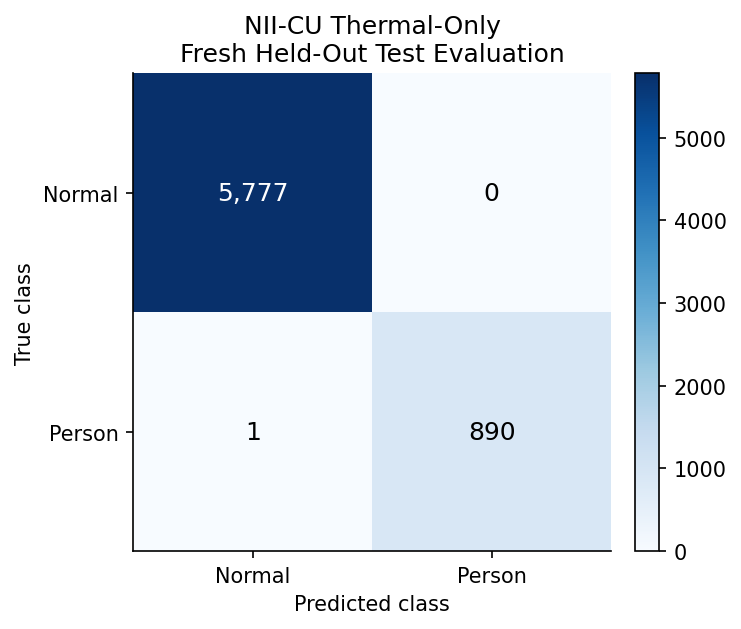


Thermal-Only probability summary by true class:


,count,mean,std,min,0.1%,1%,5%,50%,95%,99%,99.9%,max
evaluated_label,,,,,,,,,,,,
0,5777.0,0.027953,0.005392,0.022254,0.022879,0.023889,0.024833,0.027283,0.031503,0.040246,0.107293,0.173749
1,891.0,0.974314,0.031578,0.035352,0.843883,0.969222,0.971208,0.975868,0.977921,0.978529,0.980003,0.981028



Section 6 complete.

Saved metrics:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/fresh_test_metrics_seed42.csv

Saved Thermal-Only predictions:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/thermal_only_seed42_test_predictions.csv

Saved Thermal-Only errors:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/thermal_only_seed42_test_errors.csv

Saved confusion matrix:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_figures/thermal_only_fresh_confusion_matrix.pdf


In [ ]:
# SECTION 6 : INDEPENDENT HELD-OUT TEST EVALUATION
# Reload best checkpoints and save sample-level predictions

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

# 1. Evaluate one saved checkpoint

@torch.no_grad()
def evaluate_saved_checkpoint(
    model_name: str,
    checkpoint_path: Path,
    seed: int = SEED,
):
    """
    Build a fresh model, load its best checkpoint from disk,
    and evaluate it on the untouched NII-CU held-out test set.

    Returns:
        metrics: dictionary of test metrics
        prediction_df: one row per test crop
        model: freshly loaded trained model
    """

    reset_random_seeds(seed)

    # Construct an entirely new model object.
    model = build_model(
        model_name=model_name,
        seed=seed,
    )

    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {checkpoint_path}"
        )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    if "model_state_dict" not in checkpoint:
        raise KeyError(
            f"{checkpoint_path.name} does not contain "
            "'model_state_dict'."
        )

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    model.to(DEVICE)
    model.eval()

    label_batches = []
    prediction_batches = []
    probability_batches = []
    logit_normal_batches = []
    logit_person_batches = []

    for batch in tqdm(
        loaders["test"],
        desc=f"Testing {model_name}",
        leave=False,
    ):
        if len(batch) != 3:
            raise ValueError(
                "Expected test batch to contain "
                "(rgb, thermal, labels)."
            )

        rgb, thermal, labels = batch

        rgb = rgb.to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )

        thermal = thermal.to(
            DEVICE,
            dtype=torch.float32,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            dtype=torch.long,
            non_blocking=True,
        ).reshape(-1)

        logits = forward_model(
            model_name=model_name,
            model=model,
            rgb=rgb,
            thermal=thermal,
        )

        if logits.ndim != 2 or logits.shape[1] != 2:
            raise ValueError(
                f"{model_name} produced logits with shape "
                f"{tuple(logits.shape)}; expected (batch, 2)."
            )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        label_batches.append(
            labels.cpu().numpy().reshape(-1)
        )

        prediction_batches.append(
            predictions.cpu().numpy().reshape(-1)
        )

        probability_batches.append(
            probabilities.cpu().numpy().reshape(-1)
        )

        logit_normal_batches.append(
            logits[:, 0].cpu().numpy().reshape(-1)
        )

        logit_person_batches.append(
            logits[:, 1].cpu().numpy().reshape(-1)
        )

    labels_array = np.concatenate(
        label_batches
    ).astype(np.int64).reshape(-1)

    predictions_array = np.concatenate(
        prediction_batches
    ).astype(np.int64).reshape(-1)

    probabilities_array = np.concatenate(
        probability_batches
    ).astype(np.float64).reshape(-1)

    logit_normal_array = np.concatenate(
        logit_normal_batches
    ).astype(np.float64).reshape(-1)

    logit_person_array = np.concatenate(
        logit_person_batches
    ).astype(np.float64).reshape(-1)

    # --------------------------------------------------------
    # Shape and validity checks
    # --------------------------------------------------------

    expected_n = len(te_df)

    if len(labels_array) != expected_n:
        raise RuntimeError(
            f"Expected {expected_n} test predictions, "
            f"but obtained {len(labels_array)}."
        )

    if not (
        len(labels_array)
        == len(predictions_array)
        == len(probabilities_array)
        == len(logit_normal_array)
        == len(logit_person_array)
    ):
        raise RuntimeError(
            "Evaluation arrays have inconsistent lengths."
        )

    if not np.isfinite(probabilities_array).all():
        raise RuntimeError(
            "Non-finite test probabilities detected."
        )

    if not set(
        np.unique(labels_array).tolist()
    ).issubset({0, 1}):
        raise RuntimeError(
            f"Unexpected test labels: "
            f"{np.unique(labels_array)}"
        )

    if not set(
        np.unique(predictions_array).tolist()
    ).issubset({0, 1}):
        raise RuntimeError(
            f"Unexpected predicted labels: "
            f"{np.unique(predictions_array)}"
        )
    
    # Metrics

    tn, fp, fn, tp = confusion_matrix(
        labels_array,
        predictions_array,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    metrics = {
        "model": model_name,
        "seed": int(seed),

        "best_epoch":
            int(checkpoint.get("epoch", -1)),

        "best_validation_auc":
            float(
                checkpoint.get(
                    "best_validation_auc",
                    np.nan,
                )
            ),

        "test_n":
            int(len(labels_array)),

        "accuracy":
            float(
                accuracy_score(
                    labels_array,
                    predictions_array,
                )
            ),

        "precision":
            float(
                precision_score(
                    labels_array,
                    predictions_array,
                    zero_division=0,
                )
            ),

        "recall":
            float(
                recall_score(
                    labels_array,
                    predictions_array,
                    zero_division=0,
                )
            ),

        "specificity":
            float(specificity),

        "f1":
            float(
                f1_score(
                    labels_array,
                    predictions_array,
                    zero_division=0,
                )
            ),

        "roc_auc":
            float(
                roc_auc_score(
                    labels_array,
                    probabilities_array,
                )
            ),

        "average_precision":
            float(
                average_precision_score(
                    labels_array,
                    probabilities_array,
                )
            ),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    # Sample-level prediction table

    prediction_df = te_df[
        [
            "stem",
            "crop_id",
            "rgb_npy",
            "thermal_npy",
            "label",
        ]
    ].copy().reset_index(drop=True)

    if len(prediction_df) != len(labels_array):
        raise RuntimeError(
            "te_df order/length does not match evaluation output."
        )

    prediction_df["evaluated_label"] = labels_array
    prediction_df["prediction"] = predictions_array
    prediction_df["probability_positive"] = (
        probabilities_array
    )
    prediction_df["logit_normal"] = (
        logit_normal_array
    )
    prediction_df["logit_person"] = (
        logit_person_array
    )
    prediction_df["signed_margin"] = (
        logit_person_array - logit_normal_array
    )
    prediction_df["correct"] = (
        labels_array == predictions_array
    )

    # Verify that DataFrame labels and loader labels align.
    dataframe_labels = prediction_df[
        "label"
    ].to_numpy(dtype=np.int64)

    if not np.array_equal(
        dataframe_labels,
        labels_array,
    ):
        mismatch_count = int(
            np.sum(
                dataframe_labels
                != labels_array
            )
        )

        raise RuntimeError(
            "Test DataFrame labels and DataLoader labels "
            f"do not align. Mismatches: {mismatch_count}"
        )

    return metrics, prediction_df, model

# 2. Evaluate all four best checkpoints

required_models = list(MODEL_BUILDERS.keys())

missing_summaries = [
    name
    for name in required_models
    if name not in training_summaries
]

if missing_summaries:
    raise RuntimeError(
        "Training summaries are missing for: "
        f"{missing_summaries}. "
        "Finish Section 5 before running Section 6."
    )

fresh_test_metrics = []
fresh_prediction_tables = {}
fresh_models = {}

for model_name in required_models:

    checkpoint_path = training_summaries[
        model_name
    ]["checkpoint_path"]

    metrics, prediction_df, loaded_model = (
        evaluate_saved_checkpoint(
            model_name=model_name,
            checkpoint_path=checkpoint_path,
            seed=SEED,
        )
    )

    fresh_test_metrics.append(metrics)
    fresh_prediction_tables[
        model_name
    ] = prediction_df

    fresh_models[
        model_name
    ] = loaded_model

    safe_name = (
        model_name.lower().replace("-", "_")
    )

    prediction_path = (
        AUDIT_CKPT
        / f"{safe_name}_seed{SEED}_"
          "test_predictions.csv"
    )

    prediction_df.to_csv(
        prediction_path,
        index=False,
    )

    print(
        f"{model_name:15s} | "
        f"Accuracy={metrics['accuracy']:.6f} | "
        f"AUC={metrics['roc_auc']:.6f} | "
        f"AP={metrics['average_precision']:.6f} | "
        f"FP={metrics['fp']} | "
        f"FN={metrics['fn']}"
    )

# 3. Final metrics table

fresh_metrics_df = pd.DataFrame(
    fresh_test_metrics
)

model_order = {
    model_name: index
    for index, model_name in enumerate(
        required_models
    )
}

fresh_metrics_df[
    "_model_order"
] = fresh_metrics_df[
    "model"
].map(model_order)

fresh_metrics_df = (
    fresh_metrics_df
    .sort_values("_model_order")
    .drop(columns="_model_order")
    .reset_index(drop=True)
)

metric_columns = [
    "model",
    "seed",
    "best_epoch",
    "best_validation_auc",
    "test_n",
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
    "average_precision",
    "tn",
    "fp",
    "fn",
    "tp",
]

display(
    fresh_metrics_df[
        metric_columns
    ].round(6)
)

metrics_path = (
    AUDIT_CKPT
    / f"fresh_test_metrics_seed{SEED}.csv"
)

fresh_metrics_df.to_csv(
    metrics_path,
    index=False,
)

# 4. Held-out dataset sanity checks

expected_test_total = 6668
expected_test_normal = 5777
expected_test_person = 891

actual_test_total = len(te_df)
actual_test_person = int(
    te_df["label"].sum()
)
actual_test_normal = int(
    (te_df["label"] == 0).sum()
)

assert actual_test_total == expected_test_total, (
    f"Expected {expected_test_total} test crops, "
    f"found {actual_test_total}."
)

assert actual_test_normal == expected_test_normal, (
    f"Expected {expected_test_normal} normal crops, "
    f"found {actual_test_normal}."
)

assert actual_test_person == expected_test_person, (
    f"Expected {expected_test_person} person crops, "
    f"found {actual_test_person}."
)

print("\nHeld-out test-set checks passed:")
print(f"  Total crops:  {actual_test_total}")
print(f"  Normal crops: {actual_test_normal}")
print(f"  Person crops: {actual_test_person}")


# 5. Thermal-Only focused verification

thermal_metric_rows = fresh_metrics_df.loc[
    fresh_metrics_df["model"]
    == "Thermal-Only"
]

if len(thermal_metric_rows) != 1:
    raise RuntimeError(
        "Expected exactly one Thermal-Only metrics row."
    )

thermal_row = thermal_metric_rows.iloc[0]

thermal_predictions = (
    fresh_prediction_tables[
        "Thermal-Only"
    ]
)

thermal_errors = thermal_predictions.loc[
    ~thermal_predictions["correct"]
].copy()

print("\n" + "=" * 76)
print("THERMAL-ONLY INDEPENDENT VERIFICATION")
print("=" * 76)

print(
    f"Best epoch: "
    f"{int(thermal_row['best_epoch'])}"
)

print(
    "Best validation ROC AUC: "
    f"{thermal_row['best_validation_auc']:.6f}"
)

print(
    f"Test accuracy: "
    f"{thermal_row['accuracy']:.6f}"
)

print(
    f"Test precision: "
    f"{thermal_row['precision']:.6f}"
)

print(
    f"Test recall: "
    f"{thermal_row['recall']:.6f}"
)

print(
    f"Test specificity: "
    f"{thermal_row['specificity']:.6f}"
)

print(
    f"Test F1: "
    f"{thermal_row['f1']:.6f}"
)

print(
    f"Test ROC AUC: "
    f"{thermal_row['roc_auc']:.6f}"
)

print(
    "Test average precision: "
    f"{thermal_row['average_precision']:.6f}"
)

print(
    "Confusion matrix: "
    f"TN={int(thermal_row['tn'])}, "
    f"FP={int(thermal_row['fp'])}, "
    f"FN={int(thermal_row['fn'])}, "
    f"TP={int(thermal_row['tp'])}"
)

print(
    "Misclassified test crops: "
    f"{len(thermal_errors)}"
)

if thermal_errors.empty:
    print(
        "No Thermal-Only test errors were observed."
    )
else:
    display(
        thermal_errors[
            [
                "stem",
                "crop_id",
                "label",
                "prediction",
                "probability_positive",
                "signed_margin",
                "thermal_npy",
            ]
        ].sort_values(
            "probability_positive"
        ).head(30)
    )

# 6. Verify true and predicted class counts

print("\nThermal-Only true-label counts:")
print(
    thermal_predictions[
        "evaluated_label"
    ].value_counts().sort_index()
)

print("\nThermal-Only predicted-label counts:")
print(
    thermal_predictions[
        "prediction"
    ].value_counts().sort_index()
)

# 7. Classification report

print("\nThermal-Only classification report:")

print(
    classification_report(
        thermal_predictions[
            "evaluated_label"
        ],
        thermal_predictions[
            "prediction"
        ],
        target_names=[
            "Normal",
            "Person",
        ],
        digits=6,
        zero_division=0,
    )
)

# 8. Confusion-matrix figure

thermal_cm = confusion_matrix(
    thermal_predictions[
        "evaluated_label"
    ],
    thermal_predictions[
        "prediction"
    ],
    labels=[0, 1],
)

fig, ax = plt.subplots(
    figsize=(5.2, 4.3)
)

image = ax.imshow(
    thermal_cm,
    cmap="Blues",
)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Normal",
    "Person",
])

ax.set_yticklabels([
    "Normal",
    "Person",
])

ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")

ax.set_title(
    "NII-CU Thermal-Only\n"
    "Fresh Held-Out Test Evaluation"
)

maximum_count = thermal_cm.max()

for row_index in range(2):
    for column_index in range(2):

        count = thermal_cm[
            row_index,
            column_index
        ]

        text_color = (
            "white"
            if count > maximum_count / 2
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            f"{count:,}",
            ha="center",
            va="center",
            fontsize=12,
            color=text_color,
        )

fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

plt.tight_layout()

confusion_path = (
    NII_FIG
    / "thermal_only_fresh_"
      "confusion_matrix.pdf"
)

plt.savefig(
    confusion_path,
    bbox_inches="tight",
)

plt.show()

# 9. Probability-distribution summary

probability_summary = (
    thermal_predictions
    .groupby("evaluated_label")[
        "probability_positive"
    ]
    .describe(
        percentiles=[
            0.001,
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
            0.999,
        ]
    )
)

print(
    "\nThermal-Only probability summary "
    "by true class:"
)

display(
    probability_summary.round(6)
)

probability_summary.to_csv(
    AUDIT_CKPT
    / "thermal_only_probability_"
      "summary_by_class.csv"
)

# 10. Save Thermal-Only errors separately

thermal_errors_path = (
    AUDIT_CKPT
    / "thermal_only_seed42_"
      "test_errors.csv"
)

thermal_errors.to_csv(
    thermal_errors_path,
    index=False,
)

# 11. Final output locations

print("\nSection 6 complete.")

print("\nSaved metrics:")
print(metrics_path.resolve())

print("\nSaved Thermal-Only predictions:")
print(
    (
        AUDIT_CKPT
        / "thermal_only_seed42_"
          "test_predictions.csv"
    ).resolve()
)

print("\nSaved Thermal-Only errors:")
print(thermal_errors_path.resolve())

print("\nSaved confusion matrix:")
print(confusion_path.resolve())

Thermal-Only errors: 1


,stem,crop_id,label,prediction,probability_positive,signed_margin,rgb_npy,thermal_npy
3149,flight3_frame20401,1,1,0,0.035352,-3.306409,nii_crops/val/rgb/flight3_frame20401_c0001_ano...,nii_crops/val/thermal/flight3_frame20401_c0001...


Correct positive crops from the same source frame: 1


,stem,crop_id,evaluated_label,prediction,probability_positive,signed_margin,thermal_npy
0,flight3_frame20401,1,1,0,0.035352,-3.306409,nii_crops/val/thermal/flight3_frame20401_c0001...
1,flight3_frame20401,0,1,1,0.971431,3.526450,nii_crops/val/thermal/flight3_frame20401_c0000...


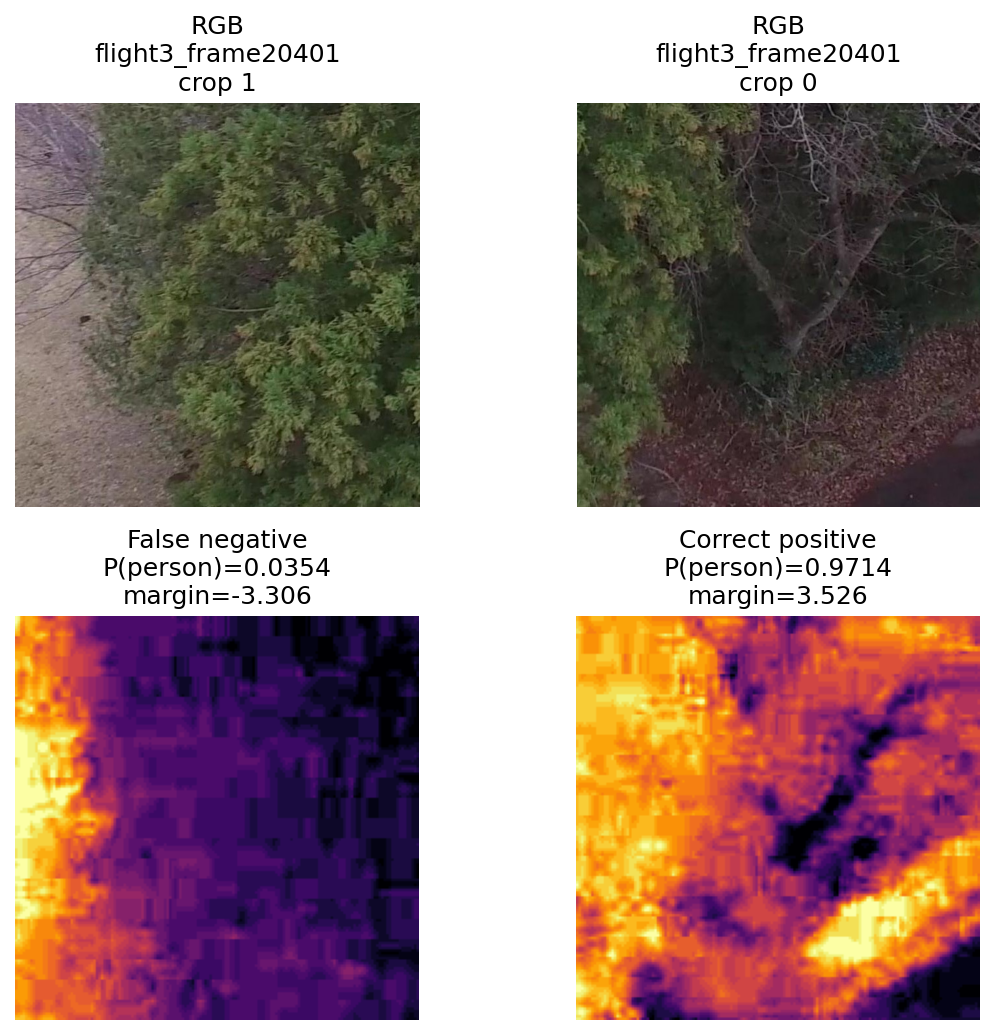

Saved error-audit figure to:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_figures/thermal_only_false_negative_audit.pdf
Best single thermal feature: border_mean
Best single-feature ROC AUC: 0.845100


,model,input,accuracy,precision,recall,specificity,f1,roc_auc,average_precision,fp,fn
0,Thermal-Only,Full-resolution thermal,0.999850,1.000000,0.998878,1.000000,0.999439,0.999975,0.999859,0,1
1,Late-Fusion,RGB + thermal,0.999700,0.998878,0.998878,0.999827,0.998878,0.998888,0.999029,1,1
2,Single feature: border_mean,One thermal statistic,0.706509,0.293731,0.851852,0.684092,0.436835,0.845100,0.399384,1825,132
3,Nearest centroid — 16x16 thermal pixels,16×16 thermal pixels,0.692412,0.285661,0.867565,0.665397,0.429803,0.843143,0.411366,1933,118
4,Logistic regression — 16x16 thermal pixels,16×16 thermal pixels,0.781794,0.335280,0.644220,0.803012,0.441030,0.809847,0.339037,1138,317
5,Decision tree — depth 2,Handcrafted thermal statistics,0.644871,0.263073,0.920314,0.602389,0.409182,0.803252,0.300100,2297,71
6,Logistic regression — all thermal statistics,Handcrafted thermal statistics,0.616677,0.247498,0.915825,0.570538,0.389685,0.799042,0.315443,2481,75


Saved comparison table to:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/nii_cu_thermal_separability_comparison.csv


,Method,Input representation,Accuracy,ROC AUC,AP,FP,FN
0,Thermal-Only,Full-resolution thermal,0.9999,1.0000,0.9999,0,1
1,Late-Fusion,RGB + thermal,0.9997,0.9989,0.9990,1,1
2,Single feature: border_mean,One thermal statistic,0.7065,0.8451,0.3994,1825,132
3,Nearest centroid — 16x16 thermal pixels,16×16 thermal pixels,0.6924,0.8431,0.4114,1933,118
4,Logistic regression — 16x16 thermal pixels,16×16 thermal pixels,0.7818,0.8098,0.3390,1138,317
5,Decision tree — depth 2,Handcrafted thermal statistics,0.6449,0.8033,0.3001,2297,71
6,Logistic regression — all thermal statistics,Handcrafted thermal statistics,0.6167,0.7990,0.3154,2481,75


Saved manuscript-ready table to:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/nii_cu_baseline_table_for_manuscript.csv


In [ ]:
# SECTION 6A : NII-CU THERMAL-SEPARABILITY SUMMARY

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# 1. Locate the Thermal-Only error

thermal_predictions = fresh_prediction_tables["Thermal-Only"].copy()

thermal_errors = thermal_predictions.loc[
    ~thermal_predictions["correct"]
].copy()

print(f"Thermal-Only errors: {len(thermal_errors)}")

if thermal_errors.empty:
    print("No Thermal-Only errors were found.")
else:
    display(
        thermal_errors[
            [
                "stem",
                "crop_id",
                "label",
                "prediction",
                "probability_positive",
                "signed_margin",
                "rgb_npy",
                "thermal_npy",
            ]
        ]
    )


# 2. Utility functions for displaying saved crops

def load_saved_rgb_crop(path):
    array = np.load(path)

    if array.dtype != np.uint8:
        array = np.clip(array, 0, 255).astype(np.uint8)

    return array


def load_saved_thermal_crop(path):
    array = np.load(path)

    if array.ndim == 3:
        array = array[..., 0]

    return array.astype(np.float32)


def normalize_thermal_for_display(array):
    """
    Per-crop display normalization only.
    This does not affect model evaluation.
    """
    low = np.percentile(array, 1)
    high = np.percentile(array, 99)

    if high <= low:
        return np.zeros_like(array, dtype=np.float32)

    normalized = (array - low) / (high - low)
    return np.clip(normalized, 0, 1)

# 3. Find comparison positives

if not thermal_errors.empty:

    error_row = thermal_errors.iloc[0]
    error_stem = error_row["stem"]

    # Correctly classified positive crops from the same frame.
    same_frame_correct_positives = thermal_predictions.loc[
        (thermal_predictions["stem"] == error_stem)
        & (thermal_predictions["evaluated_label"] == 1)
        & (thermal_predictions["correct"])
    ].copy()

    # Other correctly classified positives with the lowest confidence.
    low_confidence_correct_positives = (
        thermal_predictions.loc[
            (thermal_predictions["evaluated_label"] == 1)
            & (thermal_predictions["correct"])
        ]
        .sort_values("probability_positive")
        .head(6)
        .copy()
    )

    print(
        "Correct positive crops from the same source frame:",
        len(same_frame_correct_positives),
    )

    if len(same_frame_correct_positives) > 0:
        comparison_rows = pd.concat(
            [
                thermal_errors.head(1),
                same_frame_correct_positives.head(3),
            ],
            ignore_index=True,
        )
    else:
        comparison_rows = pd.concat(
            [
                thermal_errors.head(1),
                low_confidence_correct_positives.head(3),
            ],
            ignore_index=True,
        )

    display(
        comparison_rows[
            [
                "stem",
                "crop_id",
                "evaluated_label",
                "prediction",
                "probability_positive",
                "signed_margin",
                "thermal_npy",
            ]
        ]
    )

# 4. Visualize the false negative and comparison crops

if not thermal_errors.empty:

    n_examples = len(comparison_rows)

    fig, axes = plt.subplots(
        2,
        n_examples,
        figsize=(4 * n_examples, 7),
    )

    if n_examples == 1:
        axes = np.asarray(axes).reshape(2, 1)

    for column_index, (_, row) in enumerate(
        comparison_rows.iterrows()
    ):

        rgb_crop = load_saved_rgb_crop(
            row["rgb_npy"]
        )

        thermal_crop = load_saved_thermal_crop(
            row["thermal_npy"]
        )

        thermal_display = normalize_thermal_for_display(
            thermal_crop
        )

        axes[0, column_index].imshow(rgb_crop)
        axes[0, column_index].axis("off")
        axes[0, column_index].set_title(
            f"RGB\n{row['stem']}\n"
            f"crop {int(row['crop_id'])}"
        )

        axes[1, column_index].imshow(
            thermal_display,
            cmap="inferno",
            vmin=0,
            vmax=1,
        )

        axes[1, column_index].axis("off")

        status = (
            "False negative"
            if not bool(row["correct"])
            else "Correct positive"
        )

        axes[1, column_index].set_title(
            f"{status}\n"
            f"P(person)={row['probability_positive']:.4f}\n"
            f"margin={row['signed_margin']:.3f}"
        )

    plt.tight_layout()

    error_figure_path = (
        NII_FIG
        / "thermal_only_false_negative_audit.pdf"
    )

    plt.savefig(
        error_figure_path,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved error-audit figure to:")
    print(error_figure_path.resolve())


# 5. Load the previously saved simple-baseline results

scalar_baseline_path = (
    NII_OUT / "thermal_trivial_baseline_results.csv"
)

single_feature_path = (
    NII_OUT / "thermal_single_feature_results.csv"
)

pixel_logistic_path = (
    NII_OUT / "thermal_16x16_logistic_result.csv"
)

centroid_path = (
    NII_OUT / "thermal_16x16_centroid_result.csv"
)

required_paths = [
    scalar_baseline_path,
    single_feature_path,
    pixel_logistic_path,
    centroid_path,
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing baseline result files:\n"
        + "\n".join(str(path) for path in missing_paths)
    )

scalar_baselines = pd.read_csv(
    scalar_baseline_path
)

single_feature_results = pd.read_csv(
    single_feature_path
)

pixel_logistic_result = pd.read_csv(
    pixel_logistic_path
)

centroid_result = pd.read_csv(
    centroid_path
)


# 6. Select the strongest single scalar feature

best_single_feature = (
    single_feature_results
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .iloc[0]
)

print(
    "Best single thermal feature:",
    best_single_feature["feature"],
)

print(
    "Best single-feature ROC AUC:",
    f"{best_single_feature['roc_auc']:.6f}",
)


# 7. Build a unified comparison table

comparison_records = []

# Best scalar-statistics model
for _, row in scalar_baselines.iterrows():
    comparison_records.append({
        "model":
            row["model"],
        "input":
            "Handcrafted thermal statistics",
        "accuracy":
            row["accuracy"],
        "precision":
            row["precision"],
        "recall":
            row["recall"],
        "specificity":
            row["specificity"],
        "f1":
            row["f1"],
        "roc_auc":
            row["roc_auc"],
        "average_precision":
            row["average_precision"],
        "fp":
            int(row["fp"]),
        "fn":
            int(row["fn"]),
    })


# Best individual scalar feature
comparison_records.append({
    "model":
        f"Single feature: {best_single_feature['feature']}",
    "input":
        "One thermal statistic",
    "accuracy":
        best_single_feature["accuracy"],
    "precision":
        best_single_feature["precision"],
    "recall":
        best_single_feature["recall"],
    "specificity":
        best_single_feature["specificity"],
    "f1":
        best_single_feature["f1"],
    "roc_auc":
        best_single_feature["roc_auc"],
    "average_precision":
        best_single_feature["average_precision"],
    "fp":
        int(best_single_feature["fp"]),
    "fn":
        int(best_single_feature["fn"]),
})


# Logistic regression on downsampled thermal pixels
pixel_row = pixel_logistic_result.iloc[0]

comparison_records.append({
    "model":
        pixel_row["model"],
    "input":
        "16×16 thermal pixels",
    "accuracy":
        pixel_row["accuracy"],
    "precision":
        pixel_row["precision"],
    "recall":
        pixel_row["recall"],
    "specificity":
        pixel_row["specificity"],
    "f1":
        pixel_row["f1"],
    "roc_auc":
        pixel_row["roc_auc"],
    "average_precision":
        pixel_row["average_precision"],
    "fp":
        int(pixel_row["fp"]),
    "fn":
        int(pixel_row["fn"]),
})


# Nearest-centroid thermal template
centroid_row = centroid_result.iloc[0]

comparison_records.append({
    "model":
        centroid_row["model"],
    "input":
        "16×16 thermal pixels",
    "accuracy":
        centroid_row["accuracy"],
    "precision":
        centroid_row["precision"],
    "recall":
        centroid_row["recall"],
    "specificity":
        centroid_row["specificity"],
    "f1":
        centroid_row["f1"],
    "roc_auc":
        centroid_row["roc_auc"],
    "average_precision":
        centroid_row["average_precision"],
    "fp":
        int(centroid_row["fp"]),
    "fn":
        int(centroid_row["fn"]),
})


# Fresh deep models
for model_name in [
    "Thermal-Only",
    "Late-Fusion",
]:

    model_row = fresh_metrics_df.loc[
        fresh_metrics_df["model"] == model_name
    ].iloc[0]

    comparison_records.append({
        "model":
            model_name,
        "input":
            (
                "Full-resolution thermal"
                if model_name == "Thermal-Only"
                else "RGB + thermal"
            ),
        "accuracy":
            model_row["accuracy"],
        "precision":
            model_row["precision"],
        "recall":
            model_row["recall"],
        "specificity":
            model_row["specificity"],
        "f1":
            model_row["f1"],
        "roc_auc":
            model_row["roc_auc"],
        "average_precision":
            model_row["average_precision"],
        "fp":
            int(model_row["fp"]),
        "fn":
            int(model_row["fn"]),
    })


baseline_comparison_df = pd.DataFrame(
    comparison_records
)

baseline_comparison_df = (
    baseline_comparison_df
    .sort_values(
        "roc_auc",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    baseline_comparison_df.round(6)
)


# 8. Save the comparison table

comparison_csv_path = (
    AUDIT_CKPT
    / "nii_cu_thermal_separability_comparison.csv"
)

baseline_comparison_df.to_csv(
    comparison_csv_path,
    index=False,
)

print("Saved comparison table to:")
print(comparison_csv_path.resolve())


# 9. Manuscript-ready condensed table

manuscript_table = baseline_comparison_df[
    [
        "model",
        "input",
        "accuracy",
        "roc_auc",
        "average_precision",
        "fp",
        "fn",
    ]
].copy()

manuscript_table = manuscript_table.rename(
    columns={
        "model": "Method",
        "input": "Input representation",
        "accuracy": "Accuracy",
        "roc_auc": "ROC AUC",
        "average_precision": "AP",
        "fp": "FP",
        "fn": "FN",
    }
)

display(
    manuscript_table.round(4)
)

manuscript_table_path = (
    AUDIT_CKPT
    / "nii_cu_baseline_table_for_manuscript.csv"
)

manuscript_table.to_csv(
    manuscript_table_path,
    index=False,
)

print("Saved manuscript-ready table to:")
print(manuscript_table_path.resolve())

In [ ]:
### Seed-42 analysis initialization
# Connect the newly trained seed-42 models to the established
# CCME, Shapley, replacement, and sensitivity pipeline.


from pathlib import Path
import numpy as np
import torch


# 1. Verify that the fresh training and evaluation completed

required_fresh_objects = [
    "fresh_models",
    "fresh_metrics_df",
    "fresh_prediction_tables",
    "training_summaries",
    "AUDIT_CKPT",
    "NII_FIG",
    "dsets",
    "tr_df",
    "te_df",
    "NII_OUT",
    "NIIDataset",
    "DEVICE",
]

missing_fresh_objects = [
    name
    for name in required_fresh_objects
    if name not in globals()
]

if missing_fresh_objects:
    raise NameError(
        "Run the revised Sections 5 and 6 first. "
        "Missing objects: "
        + ", ".join(missing_fresh_objects)
    )

# 2. Confirm all four fresh models are available

expected_model_names = [
    "RGB-Only",
    "Thermal-Only",
    "Early-Fusion",
    "Late-Fusion",
]

missing_models = [
    model_name
    for model_name in expected_model_names
    if model_name not in fresh_models
]

if missing_models:
    raise KeyError(
        "Freshly evaluated models are missing: "
        + ", ".join(missing_models)
    )


# 3. Map the fresh model collection to the object name expected
#    by the established corrected post-hoc pipeline

nii_models = {
    model_name: fresh_models[model_name]
    for model_name in expected_model_names
}

for model_name, model in nii_models.items():
    model.to(DEVICE)
    model.eval()

    for parameter in model.parameters():
        parameter.requires_grad_(False)

print("Models connected to corrected post-hoc pipeline:")

for model_name, model in nii_models.items():
    print(
        f"  {model_name:15s} | "
        f"device={next(model.parameters()).device}"
    )

# 4. Use a new output directory
#    This prevents overwriting the manuscript's previous results.

NII_FRESH_POSTHOC_DIR = (
    Path(AUDIT_CKPT)
    / "corrected_posthoc_fresh_seed42"
)

NII_FRESH_POSTHOC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# The later corrected cells define NII_CORRECTED_DIR themselves.
# We deliberately point NII_FIG to a fresh analysis root so that
# their internal:
#
#     NII_CORRECTED_DIR = Path(NII_FIG) / "corrected_posthoc"
#
# resolves inside this new audit directory.

NII_ORIGINAL_FIG_DIR = Path(NII_FIG)

NII_FIG = NII_FRESH_POSTHOC_DIR

print("\nPrevious figure directory preserved as:")
print(NII_ORIGINAL_FIG_DIR.resolve())

print("\nFresh post-hoc analysis root:")
print(NII_FIG.resolve())


# 5. Verify the fresh Late-Fusion result before CCME

fresh_late_row = fresh_metrics_df.loc[
    fresh_metrics_df["model"] == "Late-Fusion"
]

if len(fresh_late_row) != 1:
    raise RuntimeError(
        "Expected exactly one fresh Late-Fusion metrics row."
    )

fresh_late_row = fresh_late_row.iloc[0]

print("\nFresh Late-Fusion checkpoint audit:")

print(
    f"  Best epoch: "
    f"{int(fresh_late_row['best_epoch'])}"
)

print(
    f"  Validation ROC AUC: "
    f"{fresh_late_row['best_validation_auc']:.6f}"
)

print(
    f"  Test ROC AUC: "
    f"{fresh_late_row['roc_auc']:.6f}"
)

print(
    f"  Test AP: "
    f"{fresh_late_row['average_precision']:.6f}"
)

print(
    "  Confusion matrix: "
    f"TN={int(fresh_late_row['tn'])}, "
    f"FP={int(fresh_late_row['fp'])}, "
    f"FN={int(fresh_late_row['fn'])}, "
    f"TP={int(fresh_late_row['tp'])}"
)


# 6. Confirm test prediction ordering

fresh_late_predictions = (
    fresh_prediction_tables["Late-Fusion"]
    .copy()
    .reset_index(drop=True)
)

if len(fresh_late_predictions) != len(te_df):
    raise RuntimeError(
        "Fresh Late-Fusion predictions do not cover "
        "the complete held-out test set."
    )

if not np.array_equal(
    fresh_late_predictions[
        "label"
    ].to_numpy(dtype=int),
    te_df[
        "label"
    ].to_numpy(dtype=int),
):
    raise RuntimeError(
        "Fresh Late-Fusion prediction ordering does not "
        "match te_df."
    )

print(
    "\nFresh Late-Fusion prediction ordering verified:",
    len(fresh_late_predictions),
    "test crops",
)

# 7. Check that the corrected cells will use the intended model

assert nii_models["Late-Fusion"] is fresh_models["Late-Fusion"]

print(
    "\nBridge complete. The existing corrected post-hoc cells "
    "will now use the fresh seed-42 Late-Fusion model."
)

Models connected to corrected post-hoc pipeline:
  RGB-Only        | device=mps:0
  Thermal-Only    | device=mps:0
  Early-Fusion    | device=mps:0
  Late-Fusion     | device=mps:0

Previous figure directory preserved as:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_figures

Fresh post-hoc analysis root:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42

Fresh Late-Fusion checkpoint audit:
  Best epoch: 12
  Validation ROC AUC: 0.999981
  Test ROC AUC: 0.998888
  Test AP: 0.999029
  Confusion matrix: TN=5776, FP=1, FN=1, TP=890

Fresh Late-Fusion prediction ordering verified: 6668 test crops

Bridge complete. The existing corrected post-hoc cells will now use the fresh seed-42 Late-Fusion model.


### Late-Fusion analysis interface

In [ ]:
# Expose the encoder attributes required by the CCME and
# complementary explanation utilities.

fresh_late_model = nii_models["Late-Fusion"]

print("Fresh Late-Fusion attributes before patch:")
print("  rgb_encoder:    ", hasattr(fresh_late_model, "rgb_encoder"))
print("  thermal_encoder:", hasattr(fresh_late_model, "thermal_encoder"))
print("  rgb_backbone:   ", hasattr(fresh_late_model, "rgb_backbone"))
print("  th_backbone:    ", hasattr(fresh_late_model, "th_backbone"))


# Add read-only compatibility properties to this model class.
# This avoids copying or re-registering PyTorch submodules.
late_fusion_class = type(fresh_late_model)

if not hasattr(late_fusion_class, "rgb_backbone"):
    late_fusion_class.rgb_backbone = property(
        lambda self: self.rgb_encoder
    )

if not hasattr(late_fusion_class, "th_backbone"):
    late_fusion_class.th_backbone = property(
        lambda self: self.thermal_encoder
    )

if not hasattr(late_fusion_class, "model_name"):
    late_fusion_class.model_name = property(
        lambda self: "Late-Fusion"
    )


# Confirm that the established pipeline can now access them.
assert fresh_late_model.rgb_backbone is fresh_late_model.rgb_encoder
assert fresh_late_model.th_backbone is fresh_late_model.thermal_encoder

fresh_late_model.eval()

print("\nCompatibility patch applied:")
print("  rgb_backbone → rgb_encoder")
print("  th_backbone  → thermal_encoder")
print("  model_name   → Late-Fusion")


# Quick embedding and exact-forward consistency check
rgb_test, th_test, y_test = dsets["test"][0]

rgb_batch = rgb_test.unsqueeze(0).to(DEVICE)
th_batch = th_test.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    direct_logits = fresh_late_model(
        rgb_batch,
        th_batch,
    )

    rgb_embedding = fresh_late_model.rgb_backbone(
        rgb_batch
    )

    thermal_embedding = fresh_late_model.th_backbone(
        th_batch
    )

    reconstructed_logits = fresh_late_model.classifier(
        fresh_late_model.fusion(
            torch.cat(
                [rgb_embedding, thermal_embedding],
                dim=1,
            )
        )
    )

maximum_difference = float(
    torch.max(
        torch.abs(
            direct_logits - reconstructed_logits
        )
    ).cpu()
)

print(
    "\nMaximum difference between direct and "
    f"embedding-reconstructed logits: {maximum_difference:.10f}"
)

assert maximum_difference < 1e-6, (
    "The reconstructed fusion pathway does not match "
    "the model's direct forward pass."
)

print("Exact-forward consistency check passed.")

Fresh Late-Fusion attributes before patch:
  rgb_encoder:     True
  thermal_encoder: True
  rgb_backbone:    False
  th_backbone:     False

Compatibility patch applied:
  rgb_backbone → rgb_encoder
  th_backbone  → thermal_encoder
  model_name   → Late-Fusion

Maximum difference between direct and embedding-reconstructed logits: 0.0000000000
Exact-forward consistency check passed.


In [ ]:
# Complementary Seed-42 Analyses

# Shared analysis utilities and prediction table

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from tqdm.auto import tqdm

# 1. Reproducibility and output directory

NII_POSTHOC_SEED = 42

random.seed(
    NII_POSTHOC_SEED
)

np.random.seed(
    NII_POSTHOC_SEED
)

torch.manual_seed(
    NII_POSTHOC_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        NII_POSTHOC_SEED
    )

NII_CORRECTED_DIR = Path(
    NII_FIG
) / "corrected_posthoc"

NII_CORRECTED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(
    "Corrected NII-CU output directory:",
    NII_CORRECTED_DIR.resolve(),
)

# 2. Required-object checks

required_nii_objects = [
    "nii_models",
    "dsets",
    "tr_df",
    "NII_OUT",
    "NIIDataset",
    "DEVICE",
]

missing_nii_objects = [
    object_name
    for object_name in required_nii_objects
    if object_name not in globals()
]

if missing_nii_objects:
    raise NameError(
        "Run the NII-CU dataset, model, and checkpoint cells first. "
        "Missing objects: "
        + ", ".join(
            missing_nii_objects
        )
    )

if "Late-Fusion" not in nii_models:
    raise KeyError(
        "nii_models does not contain the 'Late-Fusion' model."
    )


# 3. Freeze the trained Late-Fusion model

NII_LATE_FUSION_MODEL = nii_models[
    "Late-Fusion"
]

NII_LATE_FUSION_MODEL.eval()

for parameter in NII_LATE_FUSION_MODEL.parameters():
    parameter.requires_grad_(
        False
    )

print(
    "Primary corrected-analysis model:",
    NII_LATE_FUSION_MODEL.model_name
    if hasattr(
        NII_LATE_FUSION_MODEL,
        "model_name",
    )
    else "Late-Fusion",
)

# 4. Build an augmentation-free training dataset

# dsets["train"] applies random augmentation because it was created with
# split="train". Baseline estimation must not contain random augmentation.
#
# We therefore point a second NIIDataset instance at the same packed tr2
# arrays but use split="val" so its `training` flag is False.

NII_TRAIN_EVAL_DATASET = NIIDataset(
    tr_df,
    NII_OUT,
    "tr2",
    split="val",
)

NII_TEST_DATASET = dsets[
    "test"
]

print(
    "Augmentation-free training dataset:",
    len(
        NII_TRAIN_EVAL_DATASET
    ),
    "crops",
)

print(
    "Held-out test dataset:",
    len(
        NII_TEST_DATASET
    ),
    "crops",
)


# 5. Dataset-item compatibility helper

def unpack_nii_dataset_item(
    item,
):
    """
    Return RGB tensor, thermal tensor, and integer label.

    The helper tolerates dataset items containing additional metadata.
    """
    if not isinstance(
        item,
        (
            tuple,
            list,
        ),
    ):
        raise TypeError(
            "Expected the dataset to return a tuple or list."
        )

    if len(
        item
    ) < 3:
        raise ValueError(
            "Expected at least RGB, thermal, and label values."
        )

    rgb_t = item[
        0
    ]

    th_t = item[
        1
    ]

    label_value = item[
        2
    ]

    if torch.is_tensor(
        label_value
    ):
        label = int(
            label_value.detach().cpu().item()
        )
    else:
        label = int(
            label_value
        )

    return (
        rgb_t,
        th_t,
        label,
    )


# 6. Tensor-device helper

def nii_add_batch_and_move(
    tensor,
):
    """
    Add a batch dimension when needed and move a tensor to DEVICE.
    """
    if not torch.is_tensor(
        tensor
    ):
        tensor = torch.as_tensor(
            tensor,
            dtype=torch.float32,
        )

    tensor = tensor.to(
        dtype=torch.float32,
        device=DEVICE,
    )

    if tensor.ndim == 3:
        tensor = tensor.unsqueeze(
            0
        )

    return tensor

# 7. Model-forward and prediction helpers

def nii_forward_logits(
    model,
    rgb_t,
    th_t,
):
    """
    Return two-class logits for one or more RGB–thermal inputs.
    """
    rgb_batch = nii_add_batch_and_move(
        rgb_t
    )

    th_batch = nii_add_batch_and_move(
        th_t
    )

    return model(
        rgb_batch,
        th_batch,
    )


def nii_prediction_state(
    model,
    rgb_t,
    th_t,
):
    """
    Return the complete prediction state for one sample.

    anomaly_margin is defined as:

        anomaly logit - normal logit

    Therefore:
        margin > 0  -> anomaly-positive prediction
        margin <= 0 -> normal prediction
    """
    model.eval()

    with torch.no_grad():
        logits = nii_forward_logits(
            model,
            rgb_t,
            th_t,
        )

        probabilities = F.softmax(
            logits,
            dim=1,
        )

    logits_np = (
        logits[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )

    probabilities_np = (
        probabilities[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float64
        )
    )

    pred_label = int(
        np.argmax(
            probabilities_np
        )
    )

    p_normal = float(
        probabilities_np[
            0
        ]
    )

    p_anomaly = float(
        probabilities_np[
            1
        ]
    )

    anomaly_margin = float(
        logits_np[
            1
        ]
        - logits_np[
            0
        ]
    )

    predicted_confidence = float(
        probabilities_np[
            pred_label
        ]
    )

    decision_confidence = float(
        abs(
            p_anomaly
            - 0.5
        )
    )

    return {
        "pred_label": pred_label,
        "p_normal": p_normal,
        "p_anomaly": p_anomaly,
        "normal_logit": float(
            logits_np[
                0
            ]
        ),
        "anomaly_logit": float(
            logits_np[
                1
            ]
        ),
        "anomaly_margin": anomaly_margin,
        "predicted_confidence": (
            predicted_confidence
        ),
        "decision_confidence": (
            decision_confidence
        ),
    }


def nii_anomaly_margin(
    model,
    rgb_t,
    th_t,
):
    """
    Convenience wrapper returning anomaly logit minus normal logit.
    """
    return nii_prediction_state(
        model,
        rgb_t,
        th_t,
    )[
        "anomaly_margin"
    ]


# 8. Build the held-out prediction table

def nii_prediction_category(
    true_label,
    pred_label,
):
    """
    Map a binary prediction into TP, TN, FP, or FN.
    """
    if (
        true_label == 1
        and pred_label == 1
    ):
        return "TP"

    if (
        true_label == 0
        and pred_label == 0
    ):
        return "TN"

    if (
        true_label == 0
        and pred_label == 1
    ):
        return "FP"

    if (
        true_label == 1
        and pred_label == 0
    ):
        return "FN"

    raise ValueError(
        "Labels must be binary."
    )


def build_nii_prediction_table(
    model,
    dataset,
    save_name="01_nii_prediction_table.csv",
):
    """
    Evaluate every crop in the held-out NII-CU test partition.

    This table becomes the single source for:
      - TP/TN/FP/FN assignment;
      - representative sample selection;
      - CCME applicability;
      - exact Shapley analysis;
      - modality-replacement analysis.
    """
    rows = []
    failures = []

    for sample_idx in tqdm(
        range(
            len(
                dataset
            )
        ),
        desc="NII-CU held-out predictions",
    ):
        try:
            rgb_t, th_t, true_label = (
                unpack_nii_dataset_item(
                    dataset[
                        sample_idx
                    ]
                )
            )

            state = nii_prediction_state(
                model,
                rgb_t,
                th_t,
            )

            rows.append(
                {
                    "sample_idx": int(
                        sample_idx
                    ),
                    "true_label": int(
                        true_label
                    ),
                    "pred_label": int(
                        state[
                            "pred_label"
                        ]
                    ),
                    "category": (
                        nii_prediction_category(
                            true_label,
                            state[
                                "pred_label"
                            ],
                        )
                    ),
                    "correct": bool(
                        true_label
                        ==
                        state[
                            "pred_label"
                        ]
                    ),
                    "p_normal": state[
                        "p_normal"
                    ],
                    "p_anomaly": state[
                        "p_anomaly"
                    ],
                    "normal_logit": state[
                        "normal_logit"
                    ],
                    "anomaly_logit": state[
                        "anomaly_logit"
                    ],
                    "anomaly_margin": state[
                        "anomaly_margin"
                    ],
                    "predicted_confidence": (
                        state[
                            "predicted_confidence"
                        ]
                    ),
                    "decision_confidence": (
                        state[
                            "decision_confidence"
                        ]
                    ),
                }
            )

        except Exception as error:
            failures.append(
                {
                    "sample_idx": int(
                        sample_idx
                    ),
                    "error": str(
                        error
                    ),
                }
            )

    prediction_df = pd.DataFrame(
        rows
    ).sort_values(
        "sample_idx"
    ).reset_index(
        drop=True
    )

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    prediction_df.to_csv(
        output_path,
        index=False,
    )

    if failures:
        failure_path = (
            NII_CORRECTED_DIR
            / "01_nii_prediction_failures.csv"
        )

        pd.DataFrame(
            failures
        ).to_csv(
            failure_path,
            index=False,
        )

        print(
            "Prediction failures saved:",
            failure_path,
        )

    print(
        "Prediction table saved:",
        output_path,
    )

    return prediction_df


NII_PREDICTION_TABLE = build_nii_prediction_table(
    NII_LATE_FUSION_MODEL,
    NII_TEST_DATASET,
)

# 9. Prediction-table audit

def audit_nii_prediction_table(
    prediction_df,
    expected_size,
):
    """
    Verify prediction-table completeness and binary consistency.
    """
    required_columns = {
        "sample_idx",
        "true_label",
        "pred_label",
        "category",
        "p_anomaly",
        "anomaly_margin",
        "predicted_confidence",
        "decision_confidence",
    }

    missing_columns = (
        required_columns
        - set(
            prediction_df.columns
        )
    )

    if missing_columns:
        raise ValueError(
            "Prediction table is missing columns: "
            + ", ".join(
                sorted(
                    missing_columns
                )
            )
        )

    if len(
        prediction_df
    ) != expected_size:
        raise ValueError(
            "Prediction table coverage mismatch: "
            f"{len(prediction_df)} rows versus "
            f"{expected_size} expected."
        )

    if prediction_df[
        "sample_idx"
    ].duplicated().any():
        raise ValueError(
            "Duplicate sample_idx values were found."
        )

    if not prediction_df[
        "p_anomaly"
    ].between(
        0.0,
        1.0,
        inclusive="both",
    ).all():
        raise ValueError(
            "Some anomaly probabilities fall outside [0,1]."
        )

    margin_prediction = (
        prediction_df[
            "anomaly_margin"
        ]
        > 0.0
    ).astype(
        int
    )

    mismatch_count = int(
        (
            margin_prediction
            != prediction_df[
                "pred_label"
            ].astype(
                int
            )
        ).sum()
    )

    if mismatch_count > 0:
        raise ValueError(
            f"{mismatch_count} margin/prediction inconsistencies found."
        )

    print(
        "\nNII-CU prediction outcome counts"
    )

    outcome_summary = (
        prediction_df.groupby(
            "category"
        )
        .agg(
            N=(
                "sample_idx",
                "size",
            ),
            MeanPAnomaly=(
                "p_anomaly",
                "mean",
            ),
            MeanConfidence=(
                "predicted_confidence",
                "mean",
            ),
            MeanMargin=(
                "anomaly_margin",
                "mean",
            ),
        )
        .reindex(
            [
                "TP",
                "TN",
                "FP",
                "FN",
            ]
        )
    )

    display(
        outcome_summary
    )

    summary_path = (
        NII_CORRECTED_DIR
        / "01_nii_prediction_outcome_summary.csv"
    )

    outcome_summary.reset_index().to_csv(
        summary_path,
        index=False,
    )

    print(
        "Prediction-table audit passed."
    )

    return outcome_summary


NII_PREDICTION_OUTCOME_SUMMARY = (
    audit_nii_prediction_table(
        NII_PREDICTION_TABLE,
        expected_size=len(
            NII_TEST_DATASET
        ),
    )
)


# 10. Extract modality embeddings

def extract_nii_late_fusion_embeddings(
    model,
    rgb_t,
    th_t,
):
    """
    Return factual RGB and thermal branch embeddings as NumPy arrays.
    """
    model.eval()

    rgb_batch = nii_add_batch_and_move(
        rgb_t
    )

    th_batch = nii_add_batch_and_move(
        th_t
    )

    with torch.no_grad():
        rgb_embedding = model.rgb_backbone(
            rgb_batch
        )

        thermal_embedding = model.th_backbone(
            th_batch
        )

    return (
        rgb_embedding[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32
        ),
        thermal_embedding[
            0
        ]
        .detach()
        .cpu()
        .numpy()
        .astype(
            np.float32
        ),
    )

# 11. Forward the classifier from embeddings

def nii_embedding_tensor(
    embedding,
):
    """
    Convert one embedding to a batched float tensor on DEVICE.
    """
    if torch.is_tensor(
        embedding
    ):
        tensor = embedding.to(
            dtype=torch.float32,
            device=DEVICE,
        )
    else:
        tensor = torch.as_tensor(
            embedding,
            dtype=torch.float32,
            device=DEVICE,
        )

    if tensor.ndim == 1:
        tensor = tensor.unsqueeze(
            0
        )

    return tensor


def nii_logits_from_embeddings(
    model,
    rgb_embedding,
    thermal_embedding,
):
    """
    Forward modality embeddings through the exact trained fusion head.

    LayerNorm is retained through model.fusion.
    """
    rgb_embedding = nii_embedding_tensor(
        rgb_embedding
    )

    thermal_embedding = nii_embedding_tensor(
        thermal_embedding
    )

    concatenated = torch.cat(
        [
            rgb_embedding,
            thermal_embedding,
        ],
        dim=1,
    )

    fused = model.fusion(
        concatenated
    )

    return model.classifier(
        fused
    )


def nii_margin_from_embeddings(
    model,
    rgb_embedding,
    thermal_embedding,
):
    """
    Return anomaly logit minus normal logit from modality embeddings.
    """
    model.eval()

    with torch.no_grad():
        logits = nii_logits_from_embeddings(
            model,
            rgb_embedding,
            thermal_embedding,
        )

    return float(
        (
            logits[
                0,
                1
            ]
            -
            logits[
                0,
                0
            ]
        )
        .detach()
        .cpu()
        .item()
    )


def nii_state_from_embeddings(
    model,
    rgb_embedding,
    thermal_embedding,
):
    """
    Return logits, probabilities, prediction, and anomaly margin.
    """
    model.eval()

    with torch.no_grad():
        logits = nii_logits_from_embeddings(
            model,
            rgb_embedding,
            thermal_embedding,
        )

        probabilities = F.softmax(
            logits,
            dim=1,
        )

    probabilities_np = (
        probabilities[
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )

    logits_np = (
        logits[
            0
        ]
        .detach()
        .cpu()
        .numpy()
    )

    return {
        "pred_label": int(
            np.argmax(
                probabilities_np
            )
        ),
        "p_normal": float(
            probabilities_np[
                0
            ]
        ),
        "p_anomaly": float(
            probabilities_np[
                1
            ]
        ),
        "anomaly_margin": float(
            logits_np[
                1
            ]
            - logits_np[
                0
            ]
        ),
    }

# 12. Select fixed normal training references

def select_nii_training_normal_indices(
    dataset,
    n_normal=200,
    seed=NII_POSTHOC_SEED,
):
    """
    Select a fixed random subset of normal crops from the training split.

    Selection uses labels only and never test predictions.
    """
    labels = np.asarray(
        dataset.lbl[
            :
        ],
        dtype=np.int64,
    )

    candidate_indices = np.flatnonzero(
        labels
        == 0
    )

    if len(
        candidate_indices
    ) == 0:
        raise ValueError(
            "No normal examples were found in the training dataset."
        )

    rng = np.random.default_rng(
        seed
    )

    selected_size = min(
        int(
            n_normal
        ),
        len(
            candidate_indices
        ),
    )

    selected_indices = rng.choice(
        candidate_indices,
        size=selected_size,
        replace=False,
    )

    return sorted(
        int(
            value
        )
        for value in selected_indices
    )


NII_BASELINE_TRAIN_IDXS = (
    select_nii_training_normal_indices(
        NII_TRAIN_EVAL_DATASET,
        n_normal=200,
        seed=NII_POSTHOC_SEED,
    )
)

print(
    "\nTraining-normal baseline sample size:",
    len(
        NII_BASELINE_TRAIN_IDXS
    ),
)

# 13. Compute training-normal pixel and embedding baselines

def build_nii_training_normal_baselines(
    model,
    dataset,
    sample_indices,
    save_prefix="01_nii_training_normal",
):
    """
    Compute fixed training-normal baselines at both intervention levels.

    Pixel baselines
    ---------------
    Mean normalized RGB and thermal tensors.

    Embedding baselines
    -------------------
    Mean RGB and thermal encoder embeddings.

    These are distinct objects because pixel replacement and CCME operate
    at different representation levels.
    """
    rgb_pixel_sum = None
    thermal_pixel_sum = None

    rgb_embeddings = []
    thermal_embeddings = []

    records = []

    for sample_idx in tqdm(
        sample_indices,
        desc="Training-normal baselines",
    ):
        rgb_t, th_t, label = unpack_nii_dataset_item(
            dataset[
                sample_idx
            ]
        )

        if label != 0:
            raise ValueError(
                f"Selected baseline sample {sample_idx} is not normal."
            )

        rgb_cpu = (
            rgb_t.detach()
            .cpu()
            .to(
                dtype=torch.float64
            )
        )

        thermal_cpu = (
            th_t.detach()
            .cpu()
            .to(
                dtype=torch.float64
            )
        )

        if rgb_pixel_sum is None:
            rgb_pixel_sum = torch.zeros_like(
                rgb_cpu
            )

            thermal_pixel_sum = torch.zeros_like(
                thermal_cpu
            )

        rgb_pixel_sum += rgb_cpu
        thermal_pixel_sum += thermal_cpu

        rgb_embedding, thermal_embedding = (
            extract_nii_late_fusion_embeddings(
                model,
                rgb_t,
                th_t,
            )
        )

        rgb_embeddings.append(
            rgb_embedding
        )

        thermal_embeddings.append(
            thermal_embedding
        )

        records.append(
            {
                "sample_idx": int(
                    sample_idx
                ),
                "label": int(
                    label
                ),
            }
        )

    number_of_samples = len(
        sample_indices
    )

    rgb_pixel_baseline = (
        rgb_pixel_sum
        / number_of_samples
    ).to(
        dtype=torch.float32
    )

    thermal_pixel_baseline = (
        thermal_pixel_sum
        / number_of_samples
    ).to(
        dtype=torch.float32
    )

    rgb_embedding_baseline = np.mean(
        np.stack(
            rgb_embeddings,
            axis=0,
        ),
        axis=0,
    ).astype(
        np.float32
    )

    thermal_embedding_baseline = np.mean(
        np.stack(
            thermal_embeddings,
            axis=0,
        ),
        axis=0,
    ).astype(
        np.float32
    )

    pd.DataFrame(
        records
    ).to_csv(
        NII_CORRECTED_DIR
        / f"{save_prefix}_indices.csv",
        index=False,
    )

    np.save(
        NII_CORRECTED_DIR
        / f"{save_prefix}_rgb_embedding.npy",
        rgb_embedding_baseline,
    )

    np.save(
        NII_CORRECTED_DIR
        / f"{save_prefix}_thermal_embedding.npy",
        thermal_embedding_baseline,
    )

    torch.save(
        rgb_pixel_baseline,
        NII_CORRECTED_DIR
        / f"{save_prefix}_rgb_pixel.pt",
    )

    torch.save(
        thermal_pixel_baseline,
        NII_CORRECTED_DIR
        / f"{save_prefix}_thermal_pixel.pt",
    )

    return {
        "rgb_pixel": rgb_pixel_baseline,
        "thermal_pixel": thermal_pixel_baseline,
        "rgb_embedding": (
            rgb_embedding_baseline
        ),
        "thermal_embedding": (
            thermal_embedding_baseline
        ),
    }


NII_BASELINES = build_nii_training_normal_baselines(
    NII_LATE_FUSION_MODEL,
    NII_TRAIN_EVAL_DATASET,
    NII_BASELINE_TRAIN_IDXS,
)

NII_TRAIN_RGB_PIXEL_BASELINE = NII_BASELINES[
    "rgb_pixel"
]

NII_TRAIN_TH_PIXEL_BASELINE = NII_BASELINES[
    "thermal_pixel"
]

NII_TRAIN_RGB_EMBED_BASELINE = NII_BASELINES[
    "rgb_embedding"
]

NII_TRAIN_TH_EMBED_BASELINE = NII_BASELINES[
    "thermal_embedding"
]


# 14. Baseline-state audit

def audit_nii_baselines(
    model,
    baselines,
):
    """
    Confirm dimensions, finiteness, and all-baseline prediction state.
    """
    rgb_pixel = baselines[
        "rgb_pixel"
    ]

    thermal_pixel = baselines[
        "thermal_pixel"
    ]

    rgb_embedding = baselines[
        "rgb_embedding"
    ]

    thermal_embedding = baselines[
        "thermal_embedding"
    ]

    if not torch.isfinite(
        rgb_pixel
    ).all():
        raise ValueError(
            "RGB pixel baseline contains nonfinite values."
        )

    if not torch.isfinite(
        thermal_pixel
    ).all():
        raise ValueError(
            "Thermal pixel baseline contains nonfinite values."
        )

    if not np.isfinite(
        rgb_embedding
    ).all():
        raise ValueError(
            "RGB embedding baseline contains nonfinite values."
        )

    if not np.isfinite(
        thermal_embedding
    ).all():
        raise ValueError(
            "Thermal embedding baseline contains nonfinite values."
        )

    pixel_state = nii_prediction_state(
        model,
        rgb_pixel,
        thermal_pixel,
    )

    embedding_state = nii_state_from_embeddings(
        model,
        rgb_embedding,
        thermal_embedding,
    )

    baseline_audit = pd.DataFrame(
        [
            {
                "baseline_level": "pixel",
                **pixel_state,
            },
            {
                "baseline_level": "embedding",
                **embedding_state,
            },
        ]
    )

    baseline_audit.to_csv(
        NII_CORRECTED_DIR
        / "01_nii_baseline_state_audit.csv",
        index=False,
    )

    print(
        "\nAll-baseline prediction states"
    )

    display(
        baseline_audit
    )

    if (
        embedding_state[
            "anomaly_margin"
        ]
        > 0.0
    ):
        print(
            "\nWARNING: The all-baseline embedding state is "
            "anomaly-positive. Standard anomaly sufficiency will be "
            "marked non-identifiable for affected analyses."
        )

    return baseline_audit


NII_BASELINE_STATE_AUDIT = audit_nii_baselines(
    NII_LATE_FUSION_MODEL,
    NII_BASELINES,
)


# 15. Representative confidence-stratified sample selector

def nii_confidence_stratified_sample(
    prediction_df,
    n_per_category=15,
    categories=(
        "TP",
        "TN",
        "FP",
        "FN",
    ),
    seed=NII_POSTHOC_SEED,
):
    """
    Select representative outcome samples across confidence levels.

    The selector uses evenly spaced quantile positions after sorting by
    predicted-class confidence. Small categories are retained in full.
    """
    rng = np.random.default_rng(
        seed
    )

    selected_indices = []

    for category in categories:
        category_df = (
            prediction_df[
                prediction_df[
                    "category"
                ]
                == category
            ]
            .sort_values(
                [
                    "predicted_confidence",
                    "sample_idx",
                ]
            )
            .reset_index(
                drop=True
            )
        )

        number_available = len(
            category_df
        )

        if number_available == 0:
            print(
                f"  {category}: no available samples"
            )

            continue

        number_to_select = min(
            int(
                n_per_category
            ),
            number_available,
        )

        if number_to_select == number_available:
            positions = np.arange(
                number_available
            )

        elif number_to_select == 1:
            positions = np.array(
                [
                    number_available
                    // 2
                ]
            )

        else:
            positions = np.linspace(
                0,
                number_available
                - 1,
                number_to_select,
            )

            positions = np.round(
                positions
            ).astype(
                int
            )

            positions = np.unique(
                positions
            )

            if len(
                positions
            ) < number_to_select:
                remaining = np.setdiff1d(
                    np.arange(
                        number_available
                    ),
                    positions,
                )

                extra = rng.choice(
                    remaining,
                    size=(
                        number_to_select
                        - len(
                            positions
                        )
                    ),
                    replace=False,
                )

                positions = np.sort(
                    np.concatenate(
                        [
                            positions,
                            extra,
                        ]
                    )
                )

        category_indices = (
            category_df.iloc[
                positions
            ][
                "sample_idx"
            ]
            .astype(
                int
            )
            .tolist()
        )

        selected_indices.extend(
            category_indices
        )

        print(
            f"  {category}: selected "
            f"{len(category_indices)}/{number_available}"
        )

    return selected_indices


NII_REPRESENTATIVE_TEST_IDXS = (
    nii_confidence_stratified_sample(
        NII_PREDICTION_TABLE,
        n_per_category=15,
        categories=(
            "TP",
            "TN",
            "FP",
            "FN",
        ),
        seed=NII_POSTHOC_SEED,
    )
)

print(
    "\nRepresentative corrected-analysis sample size:",
    len(
        NII_REPRESENTATIVE_TEST_IDXS
    ),
)

# 16. Save metadata

nii_shared_metadata = {
    "analysis_domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "model": (
        "Late-Fusion"
    ),
    "test_partition_size": int(
        len(
            NII_TEST_DATASET
        )
    ),
    "training_baseline_partition": (
        "Internal training partition only"
    ),
    "training_dataset_for_baseline": (
        "Augmentation-free view of the packed tr2 arrays"
    ),
    "baseline_selection": (
        "Fixed random normal-training subset"
    ),
    "baseline_sample_size": int(
        len(
            NII_BASELINE_TRAIN_IDXS
        )
    ),
    "baseline_seed": int(
        NII_POSTHOC_SEED
    ),
    "pixel_baseline": (
        "Mean normalized modality tensor across selected "
        "normal training crops"
    ),
    "embedding_baseline": (
        "Mean encoder embedding across the same selected "
        "normal training crops"
    ),
    "decision_function": (
        "Anomaly logit minus normal logit"
    ),
    "decision_boundary": 0.0,
    "prediction_categories": [
        "TP",
        "TN",
        "FP",
        "FN",
    ],
    "representative_sampling": (
        "Confidence-stratified within exclusive prediction outcomes"
    ),
    "old_test_baseline_superseded": True,
}

with open(
    NII_CORRECTED_DIR
    / "01_nii_shared_metadata.json",
    "w",
) as file:
    json.dump(
        nii_shared_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU shared utilities and baselines complete."
)

Corrected NII-CU output directory: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc
Primary corrected-analysis model: Late-Fusion
Augmentation-free training dataset: 35341 crops
Held-out test dataset: 6668 crops


NII-CU held-out predictions:   0%|          | 0/6668 [00:00<?, ?it/s]

Prediction table saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/01_nii_prediction_table.csv

NII-CU prediction outcome counts


,N,MeanPAnomaly,MeanConfidence,MeanMargin
category,,,,
TP,890,0.973634,0.973634,3.610000
TN,5776,0.025699,0.974301,-3.639678
FP,1,0.686160,0.686160,0.782226
FN,1,0.023559,0.976441,-3.724388


Prediction-table audit passed.

Training-normal baseline sample size: 200


Training-normal baselines:   0%|          | 0/200 [00:00<?, ?it/s]


All-baseline prediction states


,baseline_level,pred_label,p_normal,p_anomaly,normal_logit,anomaly_logit,anomaly_margin,predicted_confidence,decision_confidence
0,pixel,1,0.027301,0.972699,-0.9625,2.610648,3.573148,0.972699,0.472699
1,embedding,0,0.975572,0.024428,NaN,NaN,-3.687302,NaN,NaN


  TP: selected 15/890
  TN: selected 15/5776
  FP: selected 1/1
  FN: selected 1/1

Representative corrected-analysis sample size: 32

Corrected NII-CU shared utilities and baselines complete.


In [ ]:
# Normal-training medoid pixel baseline

import json

import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm

# 1. Required-object checks

required_medoid_objects = [
    "NII_LATE_FUSION_MODEL",
    "NII_TRAIN_EVAL_DATASET",
    "NII_BASELINE_TRAIN_IDXS",
    "NII_TRAIN_RGB_EMBED_BASELINE",
    "NII_TRAIN_TH_EMBED_BASELINE",
    "extract_nii_late_fusion_embeddings",
    "unpack_nii_dataset_item",
    "nii_prediction_state",
    "NII_CORRECTED_DIR",
]

missing_medoid_objects = [
    name
    for name in required_medoid_objects
    if name not in globals()
]

if missing_medoid_objects:
    raise NameError(
        "Run NII-CU Corrected Cell 1 first. Missing: "
        + ", ".join(missing_medoid_objects)
    )

# 2. Find the paired normal crop nearest the joint mean embedding

def select_joint_normal_embedding_medoid(
    model,
    dataset,
    candidate_indices,
    rgb_embedding_mean,
    thermal_embedding_mean,
):
    """
    Select one real paired normal-training crop whose concatenated
    RGB–thermal embedding is closest to the concatenated mean normal
    embedding.

    Using a real paired crop preserves:
      - valid image structure;
      - RGB–thermal pairing;
      - normal-class membership;
      - an on-manifold pixel reference.
    """
    rgb_embedding_mean = np.asarray(
        rgb_embedding_mean,
        dtype=np.float32,
    )

    thermal_embedding_mean = np.asarray(
        thermal_embedding_mean,
        dtype=np.float32,
    )

    joint_mean = np.concatenate(
        [
            rgb_embedding_mean,
            thermal_embedding_mean,
        ],
        axis=0,
    )

    rows = []

    for sample_idx in tqdm(
        candidate_indices,
        desc="Selecting normal-training medoid",
    ):
        rgb_t, th_t, label = unpack_nii_dataset_item(
            dataset[sample_idx]
        )

        if label != 0:
            continue

        rgb_embedding, thermal_embedding = (
            extract_nii_late_fusion_embeddings(
                model,
                rgb_t,
                th_t,
            )
        )

        joint_embedding = np.concatenate(
            [
                rgb_embedding,
                thermal_embedding,
            ],
            axis=0,
        )

        euclidean_distance = float(
            np.linalg.norm(
                joint_embedding
                - joint_mean
            )
        )

        rows.append(
            {
                "sample_idx": int(sample_idx),
                "label": int(label),
                "joint_embedding_distance": euclidean_distance,
            }
        )

    distance_df = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "joint_embedding_distance",
                "sample_idx",
            ]
        )
        .reset_index(drop=True)
    )

    if distance_df.empty:
        raise ValueError(
            "No normal candidate was available for medoid selection."
        )

    medoid_idx = int(
        distance_df.iloc[0]["sample_idx"]
    )

    return medoid_idx, distance_df


(
    NII_PIXEL_MEDOID_TRAIN_IDX,
    NII_PIXEL_MEDOID_DISTANCE_TABLE,
) = select_joint_normal_embedding_medoid(
    NII_LATE_FUSION_MODEL,
    NII_TRAIN_EVAL_DATASET,
    NII_BASELINE_TRAIN_IDXS,
    NII_TRAIN_RGB_EMBED_BASELINE,
    NII_TRAIN_TH_EMBED_BASELINE,
)


# 3. Load the real paired medoid crop

(
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE,
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE,
    medoid_label,
) = unpack_nii_dataset_item(
    NII_TRAIN_EVAL_DATASET[
        NII_PIXEL_MEDOID_TRAIN_IDX
    ]
)

if medoid_label != 0:
    raise ValueError(
        "The selected pixel medoid is not a normal training crop."
    )

NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE = (
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE
    .detach()
    .cpu()
    .clone()
    .to(dtype=torch.float32)
)

NII_TRAIN_TH_PIXEL_MEDOID_BASELINE = (
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE
    .detach()
    .cpu()
    .clone()
    .to(dtype=torch.float32)
)


# 4. Audit the paired pixel-medoid state

NII_PIXEL_MEDOID_STATE = nii_prediction_state(
    NII_LATE_FUSION_MODEL,
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE,
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE,
)

pixel_medoid_audit = pd.DataFrame(
    [
        {
            "sample_idx": int(
                NII_PIXEL_MEDOID_TRAIN_IDX
            ),
            "source_partition": "train",
            "true_label": int(
                medoid_label
            ),
            **NII_PIXEL_MEDOID_STATE,
        }
    ]
)

print(
    "\nNormal-training pixel-medoid baseline state"
)

display(
    pixel_medoid_audit
)

if NII_PIXEL_MEDOID_STATE[
    "anomaly_margin"
] > 0.0:
    raise ValueError(
        "The nearest joint normal-training medoid is still "
        "anomaly-positive. Do not use it as the pixel baseline."
    )


# 5. Replace the invalid mean pixel baseline aliases

# These aliases will be used by later corrected pixel-level analyses.
NII_TRAIN_RGB_PIXEL_BASELINE = (
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE
)

NII_TRAIN_TH_PIXEL_BASELINE = (
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE
)


# NII_TRAIN_RGB_EMBED_BASELINE
# NII_TRAIN_TH_EMBED_BASELINE

# 6. Save medoid baseline artifacts

NII_PIXEL_MEDOID_DISTANCE_TABLE.to_csv(
    NII_CORRECTED_DIR
    / "01b_nii_pixel_medoid_candidate_distances.csv",
    index=False,
)

pixel_medoid_audit.to_csv(
    NII_CORRECTED_DIR
    / "01b_nii_pixel_medoid_state_audit.csv",
    index=False,
)

torch.save(
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE,
    NII_CORRECTED_DIR
    / "01b_nii_rgb_pixel_medoid.pt",
)

torch.save(
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE,
    NII_CORRECTED_DIR
    / "01b_nii_thermal_pixel_medoid.pt",
)

# 7. Save baseline-policy metadata

nii_pixel_baseline_metadata = {
    "reason_for_patch": (
        "The arithmetic mean pixel baseline was predicted as person "
        "and was therefore unsuitable for pixel-level intervention."
    ),
    "mean_pixel_baseline_p_anomaly": 0.974320,
    "mean_pixel_baseline_anomaly_margin": 3.636017,
    "replacement_pixel_baseline": (
        "Real paired normal-training crop nearest the concatenated "
        "mean normal RGB–thermal embedding"
    ),
    "selected_training_index": int(
        NII_PIXEL_MEDOID_TRAIN_IDX
    ),
    "selected_true_label": int(
        medoid_label
    ),
    "selected_pred_label": int(
        NII_PIXEL_MEDOID_STATE[
            "pred_label"
        ]
    ),
    "selected_p_anomaly": float(
        NII_PIXEL_MEDOID_STATE[
            "p_anomaly"
        ]
    ),
    "selected_anomaly_margin": float(
        NII_PIXEL_MEDOID_STATE[
            "anomaly_margin"
        ]
    ),
    "embedding_baseline_policy": (
        "Mean embeddings from 200 fixed normal training crops"
    ),
    "pixel_baseline_policy": (
        "Paired normal-training medoid crop"
    ),
    "important_distinction": (
        "Embedding-space CCME uses mean normal embeddings; "
        "pixel-space replacement uses a real normal medoid crop."
    ),
}

with open(
    NII_CORRECTED_DIR
    / "01b_nii_pixel_baseline_metadata.json",
    "w",
) as file:
    json.dump(
        nii_pixel_baseline_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected pixel baseline accepted."
)

print(
    "Selected normal-training medoid index:",
    NII_PIXEL_MEDOID_TRAIN_IDX,
)

print(
    "Pixel-medoid P(anomaly):",
    f"{NII_PIXEL_MEDOID_STATE['p_anomaly']:.6f}",
)

print(
    "Pixel-medoid anomaly margin:",
    f"{NII_PIXEL_MEDOID_STATE['anomaly_margin']:.6f}",
)

Selecting normal-training medoid:   0%|          | 0/200 [00:00<?, ?it/s]


Normal-training pixel-medoid baseline state


,sample_idx,source_partition,true_label,pred_label,p_normal,p_anomaly,normal_logit,anomaly_logit,anomaly_margin,predicted_confidence,decision_confidence
0,12417,train,0,0,0.975273,0.024727,0.144005,-3.530811,-3.674816,0.975273,0.475273



Corrected pixel baseline accepted.
Selected normal-training medoid index: 12417
Pixel-medoid P(anomaly): 0.024727
Pixel-medoid anomaly margin: -3.674816


Models included: ['RGB-Only', 'Thermal-Only', 'Early-Fusion', 'Late-Fusion']

Evaluating RGB-Only...


Evaluating model:   0%|          | 0/53 [00:00<?, ?it/s]


Evaluating Thermal-Only...


Evaluating model:   0%|          | 0/53 [00:00<?, ?it/s]


Evaluating Early-Fusion...


...


Evaluating Late-Fusion...


Evaluating model:   0%|          | 0/53 [00:00<?, ?it/s]


Corrected NII-CU test metrics


,Model,Accuracy,Precision,Recall,Specificity,F1,AUC,AP,ECE,Brier,TN,FP,FN,TP
0,RGB-Only,0.858278,0.406250,0.131313,0.970400,0.198473,0.721192,0.300470,0.093051,0.121522,5606,171,774,117
1,Thermal-Only,0.999850,1.000000,0.998878,1.000000,0.999439,0.999975,0.999859,0.027360,0.000923,5777,0,1,890
2,Early-Fusion,0.886923,0.640657,0.350168,0.969707,0.452830,0.859882,0.555067,0.046201,0.087660,5602,175,579,312
3,Late-Fusion,0.999700,0.998878,0.998878,0.999827,0.998878,0.998888,0.999029,0.025737,0.000889,5776,1,1,890


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_test_metrics.csv
Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_calibration_bins.csv

Late-Fusion prediction consistency passed. Maximum probability difference: 1.378e-07


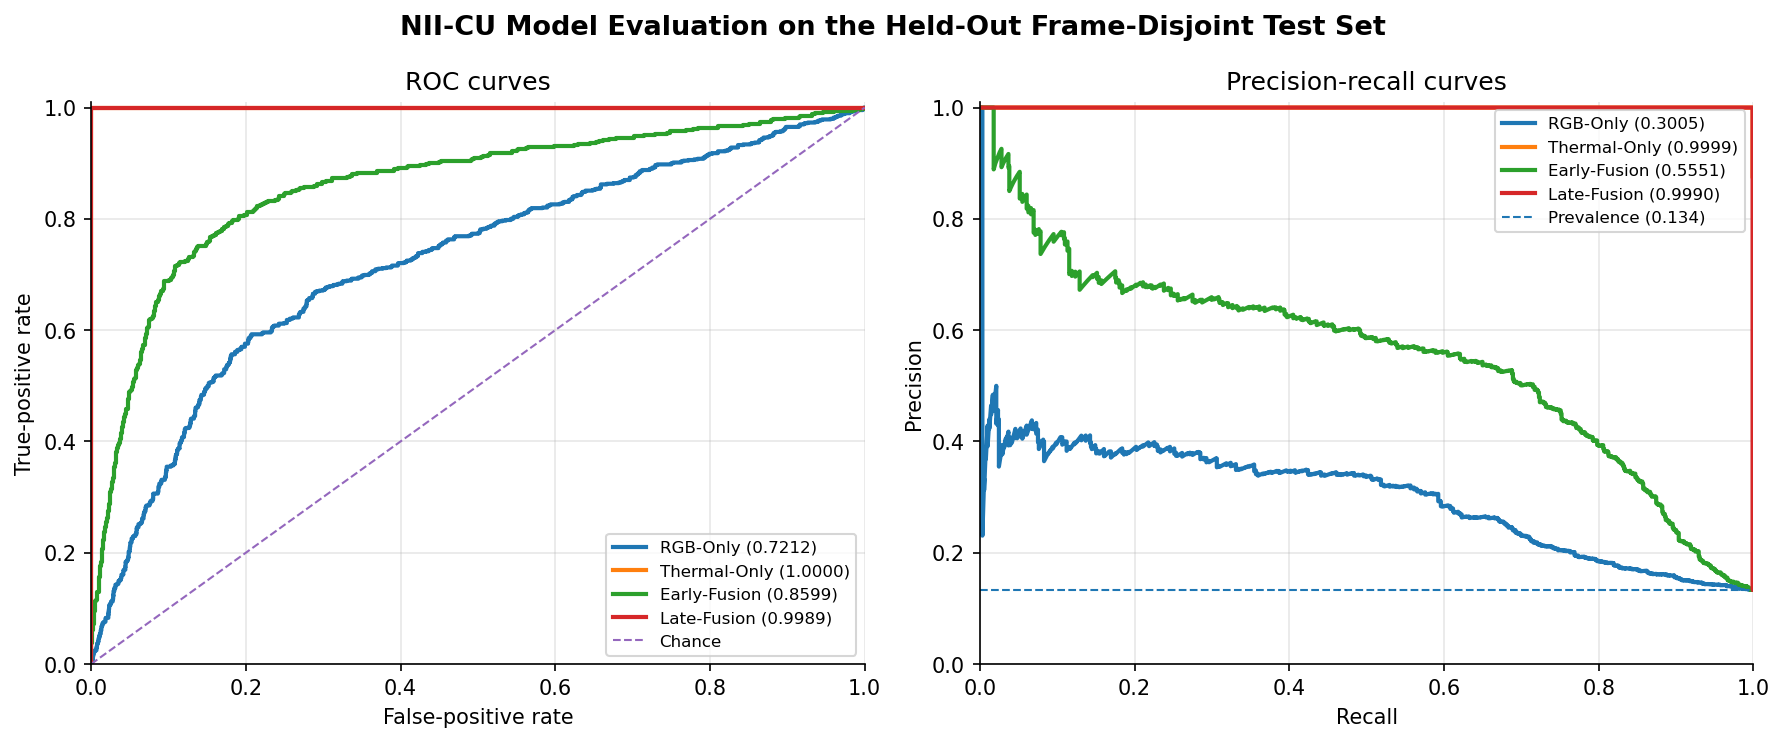

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_roc_pr.pdf


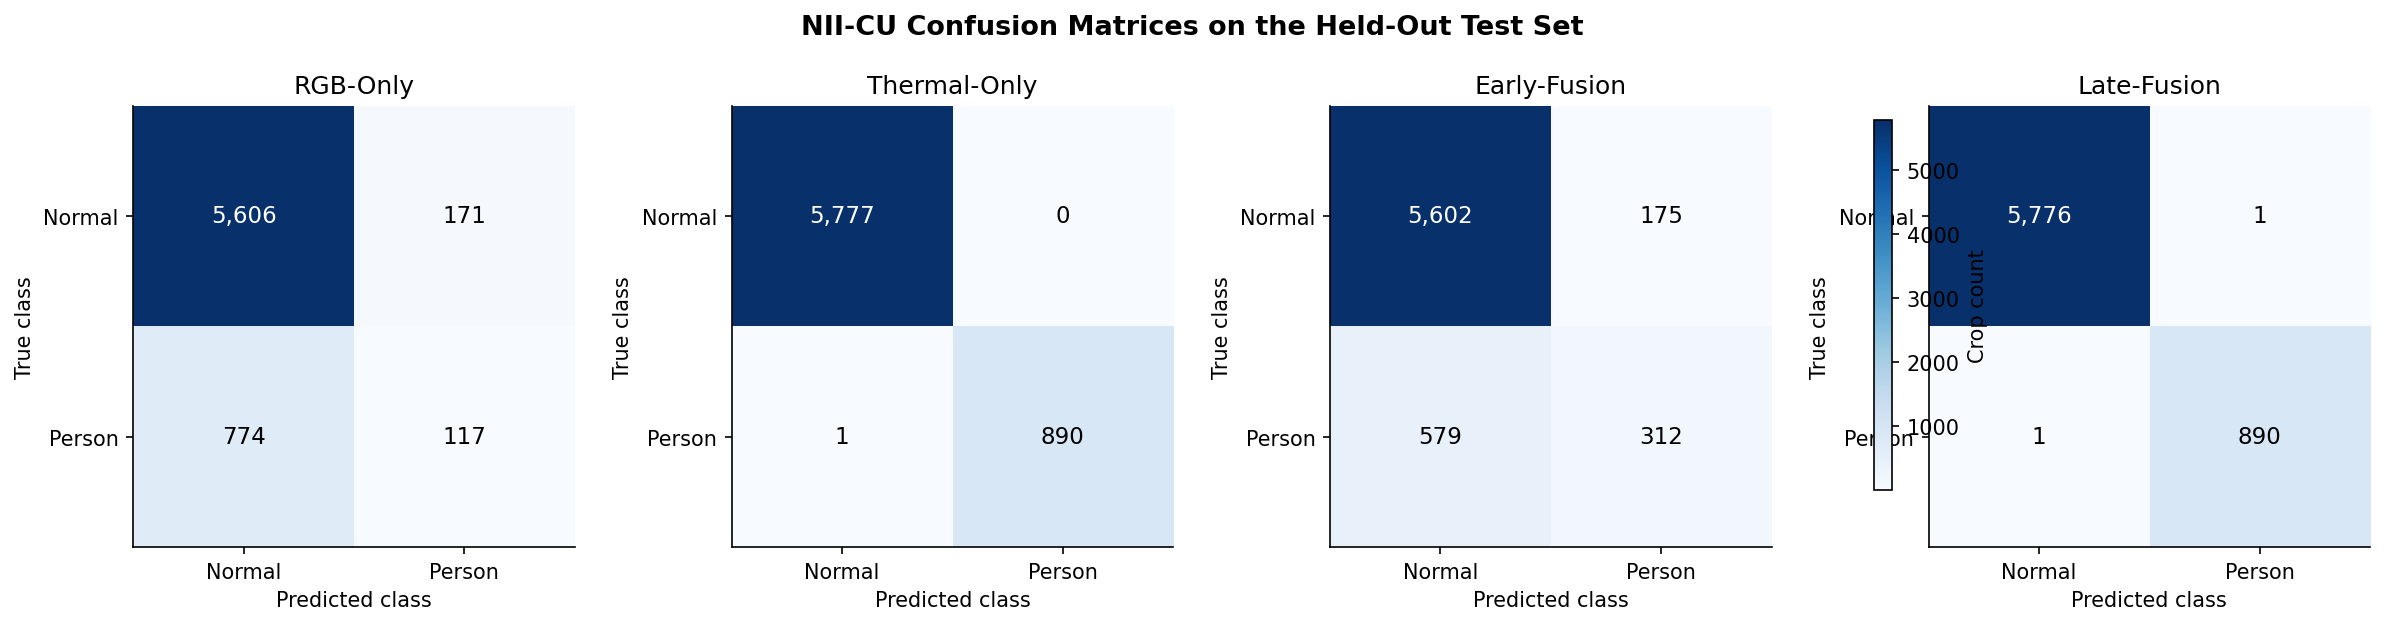

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_confusion_matrices.pdf


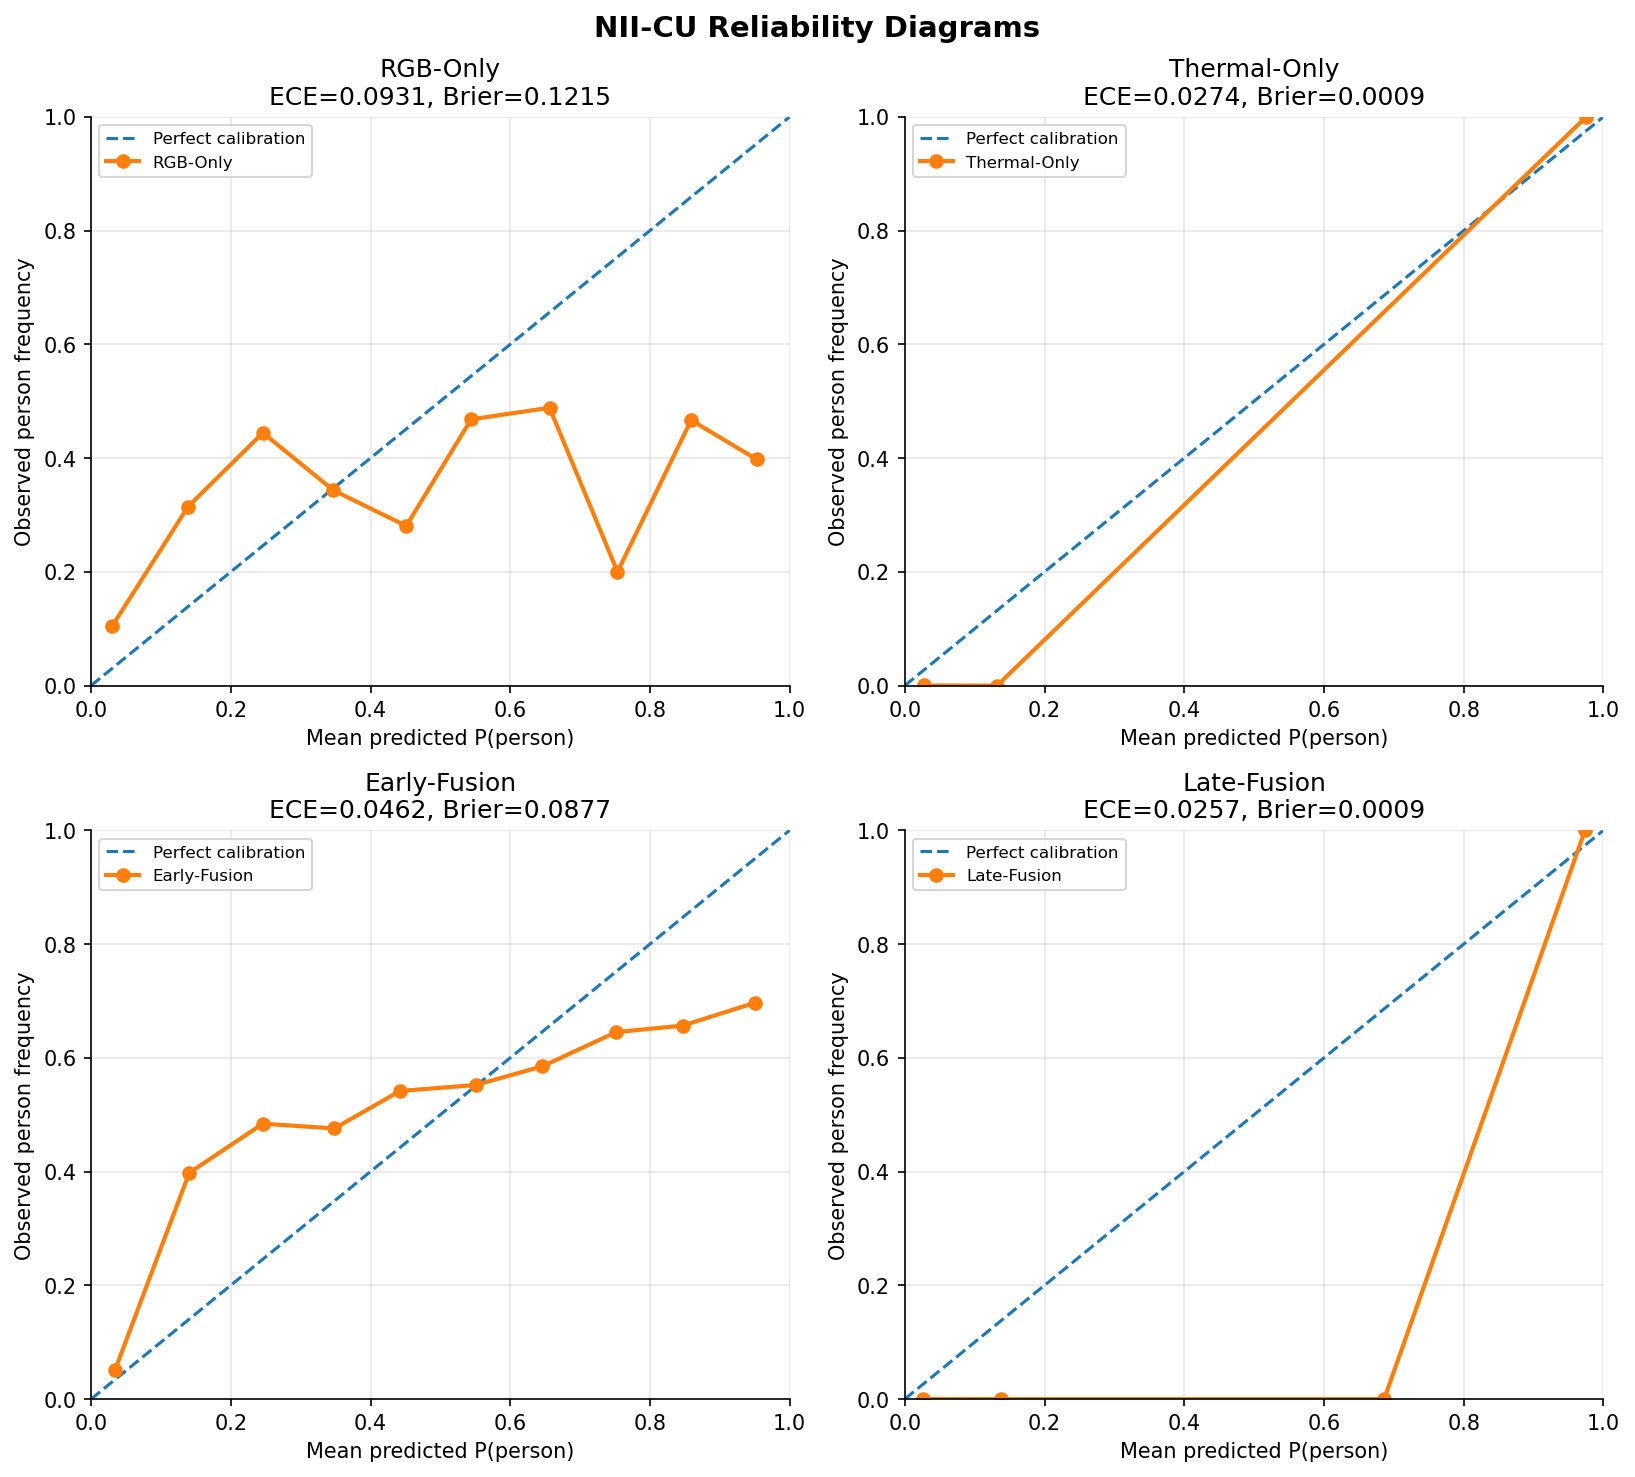

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_reliability_diagrams.pdf

Late-Fusion confidence by prediction outcome


,category,N,MeanPAnomaly,MedianPAnomaly,MeanPredictedConfidence,MedianPredictedConfidence,MeanAnomalyMargin,MedianAnomalyMargin,MinAnomalyMargin,MaxAnomalyMargin
0,TP,890,0.973634,0.973991,0.973634,0.973991,3.610000,3.622960,3.215343,3.709107
1,TN,5776,0.025699,0.025111,0.974301,0.974889,-3.639678,-3.659023,-3.869671,-1.609701
2,FP,1,0.686160,0.686160,0.686160,0.686160,0.782226,0.782226,0.782226,0.782226
3,FN,1,0.023559,0.023559,0.976441,0.976441,-3.724388,-3.724388,-3.724388,-3.724388


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/02_nii_late_fusion_confidence_by_outcome.csv

Corrected NII-CU performance and calibration audit complete.


In [ ]:
# Seed-42 predictive performance and calibration

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 1. Required-object checks

required_nii_eval_objects = [
    "nii_models",
    "NII_TEST_DATASET",
    "NII_PREDICTION_TABLE",
    "NII_CORRECTED_DIR",
    "DEVICE",
]

missing_nii_eval_objects = [
    object_name
    for object_name in required_nii_eval_objects
    if object_name not in globals()
]

if missing_nii_eval_objects:
    raise NameError(
        "Run NII-CU Corrected Cell 1 first. Missing: "
        + ", ".join(missing_nii_eval_objects)
    )

# 2. Evaluation configuration

NII_EVAL_BATCH_SIZE = 128
NII_ECE_BINS = 10

NII_MODEL_ORDER = [
    model_name
    for model_name in [
        "RGB-Only",
        "Thermal-Only",
        "Early-Fusion",
        "Late-Fusion",
    ]
    if model_name in nii_models
]

if "Late-Fusion" not in NII_MODEL_ORDER:
    raise KeyError(
        "The trained Late-Fusion model is unavailable."
    )

print("Models included:", NII_MODEL_ORDER)

# 3. Deterministic held-out data loader

NII_TEST_LOADER_CORRECTED = DataLoader(
    NII_TEST_DATASET,
    batch_size=NII_EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


# 4. Robust model evaluation helper

def evaluate_nii_model_probabilities(
    model,
    data_loader,
):
    """
    Return labels, predictions, class probabilities, and logits for the
    complete held-out test partition.
    """
    model.eval()

    all_true = []
    all_pred = []
    all_probabilities = []
    all_logits = []

    with torch.no_grad():
        for batch in tqdm(
            data_loader,
            desc="Evaluating model",
            leave=False,
        ):
            if not isinstance(batch, (tuple, list)) or len(batch) < 3:
                raise ValueError(
                    "Expected each batch to contain RGB, thermal, and labels."
                )

            rgb_batch = batch[0].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            thermal_batch = batch[1].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            labels = batch[2].to(
                DEVICE,
                dtype=torch.long,
                non_blocking=True,
            )

            logits = model(
                rgb_batch,
                thermal_batch,
            )

            probabilities = F.softmax(
                logits,
                dim=1,
            )

            predictions = torch.argmax(
                probabilities,
                dim=1,
            )

            all_true.append(
                labels.detach().cpu().numpy()
            )

            all_pred.append(
                predictions.detach().cpu().numpy()
            )

            all_probabilities.append(
                probabilities.detach().cpu().numpy()
            )

            all_logits.append(
                logits.detach().cpu().numpy()
            )

    return {
        "true_labels": np.concatenate(all_true).astype(np.int64),
        "pred_labels": np.concatenate(all_pred).astype(np.int64),
        "probabilities": np.concatenate(all_probabilities).astype(np.float64),
        "logits": np.concatenate(all_logits).astype(np.float64),
    }


# 5. Expected calibration error

def binary_expected_calibration_error(
    true_labels,
    anomaly_probabilities,
    n_bins=10,
):
    """
    Equal-width binary expected calibration error using P(anomaly).

    Empty bins contribute zero weight.
    """
    true_labels = np.asarray(
        true_labels,
        dtype=np.int64,
    )

    anomaly_probabilities = np.asarray(
        anomaly_probabilities,
        dtype=np.float64,
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        int(n_bins) + 1,
    )

    bin_ids = np.digitize(
        anomaly_probabilities,
        bin_edges[1:-1],
        right=False,
    )

    ece = 0.0
    bin_rows = []

    for bin_index in range(int(n_bins)):
        in_bin = bin_ids == bin_index
        bin_count = int(in_bin.sum())

        lower = float(bin_edges[bin_index])
        upper = float(bin_edges[bin_index + 1])

        if bin_count == 0:
            bin_rows.append(
                {
                    "bin_index": bin_index,
                    "lower_bound": lower,
                    "upper_bound": upper,
                    "count": 0,
                    "mean_predicted_probability": np.nan,
                    "observed_anomaly_frequency": np.nan,
                    "absolute_calibration_gap": np.nan,
                }
            )
            continue

        mean_probability = float(
            anomaly_probabilities[in_bin].mean()
        )

        observed_frequency = float(
            true_labels[in_bin].mean()
        )

        calibration_gap = abs(
            mean_probability - observed_frequency
        )

        ece += (
            bin_count / len(true_labels)
        ) * calibration_gap

        bin_rows.append(
            {
                "bin_index": bin_index,
                "lower_bound": lower,
                "upper_bound": upper,
                "count": bin_count,
                "mean_predicted_probability": mean_probability,
                "observed_anomaly_frequency": observed_frequency,
                "absolute_calibration_gap": calibration_gap,
            }
        )

    return float(ece), pd.DataFrame(bin_rows)

# 6. Metric computation

def compute_nii_binary_metrics(
    model_name,
    evaluation,
):
    true_labels = evaluation["true_labels"]
    pred_labels = evaluation["pred_labels"]
    anomaly_probabilities = evaluation["probabilities"][:, 1]

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        pred_labels,
        labels=[0, 1],
    ).ravel()

    ece, calibration_bins = (
        binary_expected_calibration_error(
            true_labels,
            anomaly_probabilities,
            n_bins=NII_ECE_BINS,
        )
    )

    calibration_bins.insert(
        0,
        "model",
        model_name,
    )

    metrics = {
        "Model": model_name,
        "N": int(len(true_labels)),
        "Accuracy": accuracy_score(
            true_labels,
            pred_labels,
        ),
        "Precision": precision_score(
            true_labels,
            pred_labels,
            zero_division=0,
        ),
        "Recall": recall_score(
            true_labels,
            pred_labels,
            zero_division=0,
        ),
        "Specificity": (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        ),
        "F1": f1_score(
            true_labels,
            pred_labels,
            zero_division=0,
        ),
        "AUC": roc_auc_score(
            true_labels,
            anomaly_probabilities,
        ),
        "AP": average_precision_score(
            true_labels,
            anomaly_probabilities,
        ),
        "ECE": ece,
        "Brier": brier_score_loss(
            true_labels,
            anomaly_probabilities,
        ),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "PredictedPositiveRate": float(
            pred_labels.mean()
        ),
        "ObservedPositiveRate": float(
            true_labels.mean()
        ),
    }

    return metrics, calibration_bins


# 7. Evaluate all available architectures

NII_MODEL_EVALUATIONS = {}
metric_rows = []
calibration_bin_tables = []

for model_name in NII_MODEL_ORDER:
    print(f"\nEvaluating {model_name}...")

    model = nii_models[model_name]
    model.eval()

    evaluation = evaluate_nii_model_probabilities(
        model,
        NII_TEST_LOADER_CORRECTED,
    )

    if len(evaluation["true_labels"]) != len(NII_TEST_DATASET):
        raise ValueError(
            f"{model_name}: incomplete test coverage."
        )

    metrics, calibration_bins = (
        compute_nii_binary_metrics(
            model_name,
            evaluation,
        )
    )

    NII_MODEL_EVALUATIONS[model_name] = evaluation
    metric_rows.append(metrics)
    calibration_bin_tables.append(calibration_bins)


NII_CORRECTED_METRICS = pd.DataFrame(
    metric_rows
)

NII_CORRECTED_CALIBRATION_BINS = pd.concat(
    calibration_bin_tables,
    ignore_index=True,
)

metrics_path = (
    NII_CORRECTED_DIR
    / "02_nii_test_metrics.csv"
)

calibration_bins_path = (
    NII_CORRECTED_DIR
    / "02_nii_calibration_bins.csv"
)

NII_CORRECTED_METRICS.to_csv(
    metrics_path,
    index=False,
)

NII_CORRECTED_CALIBRATION_BINS.to_csv(
    calibration_bins_path,
    index=False,
)

print("\nCorrected NII-CU test metrics")
display(
    NII_CORRECTED_METRICS[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "AUC",
            "AP",
            "ECE",
            "Brier",
            "TN",
            "FP",
            "FN",
            "TP",
        ]
    ]
)

print("Saved:", metrics_path)
print("Saved:", calibration_bins_path)


# 8. Verify Late-Fusion table

late_evaluation = NII_MODEL_EVALUATIONS[
    "Late-Fusion"
]

cell2_late_predictions = late_evaluation[
    "pred_labels"
]

cell2_late_probabilities = late_evaluation[
    "probabilities"
][
    :,
    1
]

cell1_table = (
    NII_PREDICTION_TABLE
    .sort_values("sample_idx")
    .reset_index(drop=True)
)

if not np.array_equal(
    cell2_late_predictions,
    cell1_table["pred_label"].to_numpy(dtype=np.int64),
):
    raise ValueError(
        "Late-Fusion predictions disagree between Cells 1 and 2."
    )

maximum_probability_difference = float(
    np.max(
        np.abs(
            cell2_late_probabilities
            - cell1_table["p_anomaly"].to_numpy(dtype=np.float64)
        )
    )
)

if maximum_probability_difference > 1e-6:
    raise ValueError(
        "Late-Fusion probabilities disagree between Cells 1 and 2: "
        f"maximum difference={maximum_probability_difference:.8g}"
    )

print(
    "\nLate-Fusion prediction consistency passed. "
    f"Maximum probability difference: "
    f"{maximum_probability_difference:.3e}"
)


# 9. Save per-sample prediction files for every model

for model_name, evaluation in NII_MODEL_EVALUATIONS.items():
    safe_model_name = (
        model_name.lower()
        .replace("-", "_")
        .replace(" ", "_")
    )

    prediction_output = pd.DataFrame(
        {
            "sample_idx": np.arange(
                len(evaluation["true_labels"]),
                dtype=np.int64,
            ),
            "true_label": evaluation["true_labels"],
            "pred_label": evaluation["pred_labels"],
            "p_normal": evaluation["probabilities"][:, 0],
            "p_anomaly": evaluation["probabilities"][:, 1],
            "normal_logit": evaluation["logits"][:, 0],
            "anomaly_logit": evaluation["logits"][:, 1],
            "anomaly_margin": (
                evaluation["logits"][:, 1]
                - evaluation["logits"][:, 0]
            ),
        }
    )

    prediction_output.to_csv(
        NII_CORRECTED_DIR
        / f"02_nii_{safe_model_name}_predictions.csv",
        index=False,
    )

# 10. ROC and precision-recall figure

def plot_nii_roc_pr(
    evaluations,
    model_order,
    save_name="02_nii_roc_pr.pdf",
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
    )

    for model_name in model_order:
        evaluation = evaluations[model_name]

        true_labels = evaluation["true_labels"]
        anomaly_probabilities = evaluation["probabilities"][:, 1]

        fpr, tpr, _ = roc_curve(
            true_labels,
            anomaly_probabilities,
        )

        auc_value = roc_auc_score(
            true_labels,
            anomaly_probabilities,
        )

        axes[0].plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} ({auc_value:.4f})",
        )

        precision, recall, _ = precision_recall_curve(
            true_labels,
            anomaly_probabilities,
        )

        ap_value = average_precision_score(
            true_labels,
            anomaly_probabilities,
        )

        axes[1].plot(
            recall,
            precision,
            linewidth=2,
            label=f"{model_name} ({ap_value:.4f})",
        )

    axes[0].plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    axes[0].set_xlabel("False-positive rate")
    axes[0].set_ylabel("True-positive rate")
    axes[0].set_title("ROC curves")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1.01)
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    observed_prevalence = float(
        NII_MODEL_EVALUATIONS[
            "Late-Fusion"
        ][
            "true_labels"
        ].mean()
    )

    axes[1].axhline(
        observed_prevalence,
        linestyle="--",
        linewidth=1,
        label=f"Prevalence ({observed_prevalence:.3f})",
    )

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-recall curves")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.01)
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=8)

    plt.suptitle(
        "NII-CU Model Evaluation on the Held-Out Frame-Disjoint Test Set",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)


plot_nii_roc_pr(
    NII_MODEL_EVALUATIONS,
    NII_MODEL_ORDER,
)

# 11. Confusion-matrix figure

def plot_nii_confusion_matrices(
    evaluations,
    model_order,
    save_name="02_nii_confusion_matrices.pdf",
):
    number_of_models = len(model_order)

    fig, axes = plt.subplots(
        1,
        number_of_models,
        figsize=(4 * number_of_models, 4),
    )

    if number_of_models == 1:
        axes = [axes]

    plotted_image = None

    for ax, model_name in zip(
        axes,
        model_order,
    ):
        evaluation = evaluations[model_name]

        matrix = confusion_matrix(
            evaluation["true_labels"],
            evaluation["pred_labels"],
            labels=[0, 1],
        )

        plotted_image = ax.imshow(
            matrix,
            cmap="Blues",
        )

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])

        ax.set_xticklabels(
            ["Normal", "Person"]
        )

        ax.set_yticklabels(
            ["Normal", "Person"]
        )

        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        ax.set_title(model_name)

        maximum = matrix.max()

        for row_index in range(2):
            for column_index in range(2):
                value = int(
                    matrix[row_index, column_index]
                )

                ax.text(
                    column_index,
                    row_index,
                    f"{value:,}",
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if value > maximum / 2
                        else "black"
                    ),
                    fontsize=11,
                )

    if plotted_image is not None:
        fig.colorbar(
            plotted_image,
            ax=list(axes),
            shrink=0.8,
            label="Crop count",
        )

    plt.suptitle(
        "NII-CU Confusion Matrices on the Held-Out Test Set",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)


plot_nii_confusion_matrices(
    NII_MODEL_EVALUATIONS,
    NII_MODEL_ORDER,
)

# 12. Reliability diagrams

def plot_nii_reliability_diagrams(
    evaluations,
    model_order,
    n_bins=NII_ECE_BINS,
    save_name="02_nii_reliability_diagrams.pdf",
):
    number_of_models = len(model_order)

    number_of_columns = 2
    number_of_rows = int(
        np.ceil(number_of_models / number_of_columns)
    )

    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(11, 5 * number_of_rows),
        squeeze=False,
    )

    axes_flat = axes.ravel()

    metric_lookup = (
        NII_CORRECTED_METRICS
        .set_index("Model")
    )

    for ax, model_name in zip(
        axes_flat,
        model_order,
    ):
        evaluation = evaluations[model_name]

        observed_frequency, mean_probability = (
            calibration_curve(
                evaluation["true_labels"],
                evaluation["probabilities"][:, 1],
                n_bins=n_bins,
                strategy="uniform",
            )
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            linewidth=1.5,
            label="Perfect calibration",
        )

        ax.plot(
            mean_probability,
            observed_frequency,
            marker="o",
            linewidth=2,
            label=model_name,
        )

        ece = metric_lookup.loc[
            model_name,
            "ECE"
        ]

        brier = metric_lookup.loc[
            model_name,
            "Brier"
        ]

        ax.set_title(
            f"{model_name}\nECE={ece:.4f}, Brier={brier:.4f}"
        )

        ax.set_xlabel(
            "Mean predicted P(person)"
        )

        ax.set_ylabel(
            "Observed person frequency"
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    for unused_ax in axes_flat[number_of_models:]:
        unused_ax.set_visible(False)

    plt.suptitle(
        "NII-CU Reliability Diagrams",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", output_path)


plot_nii_reliability_diagrams(
    NII_MODEL_EVALUATIONS,
    NII_MODEL_ORDER,
)

# 13. Prediction-confidence audit

def build_nii_confidence_audit(
    prediction_table,
):
    """
    Summarize Late-Fusion confidence and anomaly margins by exclusive
    prediction outcome.
    """
    summary = (
        prediction_table.groupby(
            "category",
            observed=False,
        )
        .agg(
            N=("sample_idx", "size"),
            MeanPAnomaly=("p_anomaly", "mean"),
            MedianPAnomaly=("p_anomaly", "median"),
            MeanPredictedConfidence=(
                "predicted_confidence",
                "mean",
            ),
            MedianPredictedConfidence=(
                "predicted_confidence",
                "median",
            ),
            MeanAnomalyMargin=(
                "anomaly_margin",
                "mean",
            ),
            MedianAnomalyMargin=(
                "anomaly_margin",
                "median",
            ),
            MinAnomalyMargin=(
                "anomaly_margin",
                "min",
            ),
            MaxAnomalyMargin=(
                "anomaly_margin",
                "max",
            ),
        )
        .reindex(
            [
                "TP",
                "TN",
                "FP",
                "FN",
            ]
        )
        .reset_index()
    )

    output_path = (
        NII_CORRECTED_DIR
        / "02_nii_late_fusion_confidence_by_outcome.csv"
    )

    summary.to_csv(
        output_path,
        index=False,
    )

    print(
        "\nLate-Fusion confidence by prediction outcome"
    )

    display(summary)

    print("Saved:", output_path)

    return summary


NII_CONFIDENCE_AUDIT = (
    build_nii_confidence_audit(
        NII_PREDICTION_TABLE
    )
)

# 14. Save evaluation metadata

nii_evaluation_metadata = {
    "analysis_domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "evaluation_partition": (
        "Held-out frame-disjoint test partition"
    ),
    "test_crop_count": int(
        len(NII_TEST_DATASET)
    ),
    "models": NII_MODEL_ORDER,
    "positive_class": (
        "Person"
    ),
    "probability_used_for_roc_pr_and_calibration": (
        "P(person)"
    ),
    "ece_definition": (
        "Equal-width 10-bin expected calibration error"
    ),
    "brier_definition": (
        "Mean squared error between P(person) and the binary label"
    ),
    "prediction_table_consistency_checked": True,
    "decision_function_for_later_ccme": (
        "Person logit minus normal logit"
    ),
    "decision_boundary": 0.0,
}

with open(
    NII_CORRECTED_DIR
    / "02_nii_evaluation_metadata.json",
    "w",
) as file:
    json.dump(
        nii_evaluation_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU performance and calibration audit complete."
)

Representative sample count: 32
Dense interpolation grid: 101 points


Corrected NII-CU CCME:   0%|          | 0/32 [00:00<?, ?it/s]


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/03_nii_ccme_corrected.csv
Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/03_nii_ccme_dense_paths.csv

CCME structural audit passed.

CCME explicit status summary


,analysis,modality,status,N
0,Necessity,RGB,no_crossing,16
1,Necessity,RGB,not_applicable_factual_negative,16
2,Necessity,Thermal,crossed,16
3,Necessity,Thermal,not_applicable_factual_negative,16
4,Sufficiency,RGB,no_crossing,32
5,Sufficiency,Thermal,crossed,16
6,Sufficiency,Thermal,no_crossing,16



CCME crossing incidence and conditional alpha


,analysis,modality,total_rows,applicable_n,crossed_n,no_crossing_n,crossing_incidence,conditional_median_alpha,conditional_mean_alpha,conditional_q25_alpha,conditional_q75_alpha,multiple_crossing_n,mean_monotonic_step_fraction,strictly_monotonic_fraction
0,Necessity,RGB,32,16,0,16,0.0,NaN,NaN,NaN,NaN,0,0.188125,0.00000
1,Necessity,Thermal,32,16,16,0,1.0,0.534146,0.490454,0.477118,0.551361,0,0.983750,0.56250
2,Sufficiency,RGB,32,32,0,32,0.0,NaN,NaN,NaN,NaN,0,0.711250,0.28125
3,Sufficiency,Thermal,32,32,16,16,0.5,0.469436,0.510066,0.448703,0.534072,0,0.869687,0.53125



CCME status by prediction outcome


,category,analysis,modality,status,N
0,FN,Necessity,RGB,not_applicable_factual_negative,1
1,FN,Necessity,Thermal,not_applicable_factual_negative,1
2,FN,Sufficiency,RGB,no_crossing,1
3,FN,Sufficiency,Thermal,no_crossing,1
4,FP,Necessity,RGB,no_crossing,1
5,FP,Necessity,Thermal,crossed,1
6,FP,Sufficiency,RGB,no_crossing,1
7,FP,Sufficiency,Thermal,crossed,1
8,TN,Necessity,RGB,not_applicable_factual_negative,15
9,TN,Necessity,Thermal,not_applicable_factual_negative,15



Endpoint-linear validation


,analysis,modality,applicable_n,status_agreement_n,status_agreement_rate,paired_crossing_n,mean_absolute_alpha_error,median_absolute_alpha_error,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,Necessity,RGB,16,16,1.0,0,NaN,NaN,0,NaN,NaN,NaN,NaN
1,Necessity,Thermal,16,16,1.0,16,0.055191,0.050631,16,0.924616,3.033980e-07,0.511765,0.042723
2,Sufficiency,RGB,32,32,1.0,0,NaN,NaN,0,NaN,NaN,NaN,NaN
3,Sufficiency,Thermal,32,32,1.0,16,0.053534,0.050487,16,0.924259,3.133008e-07,0.085294,0.753465


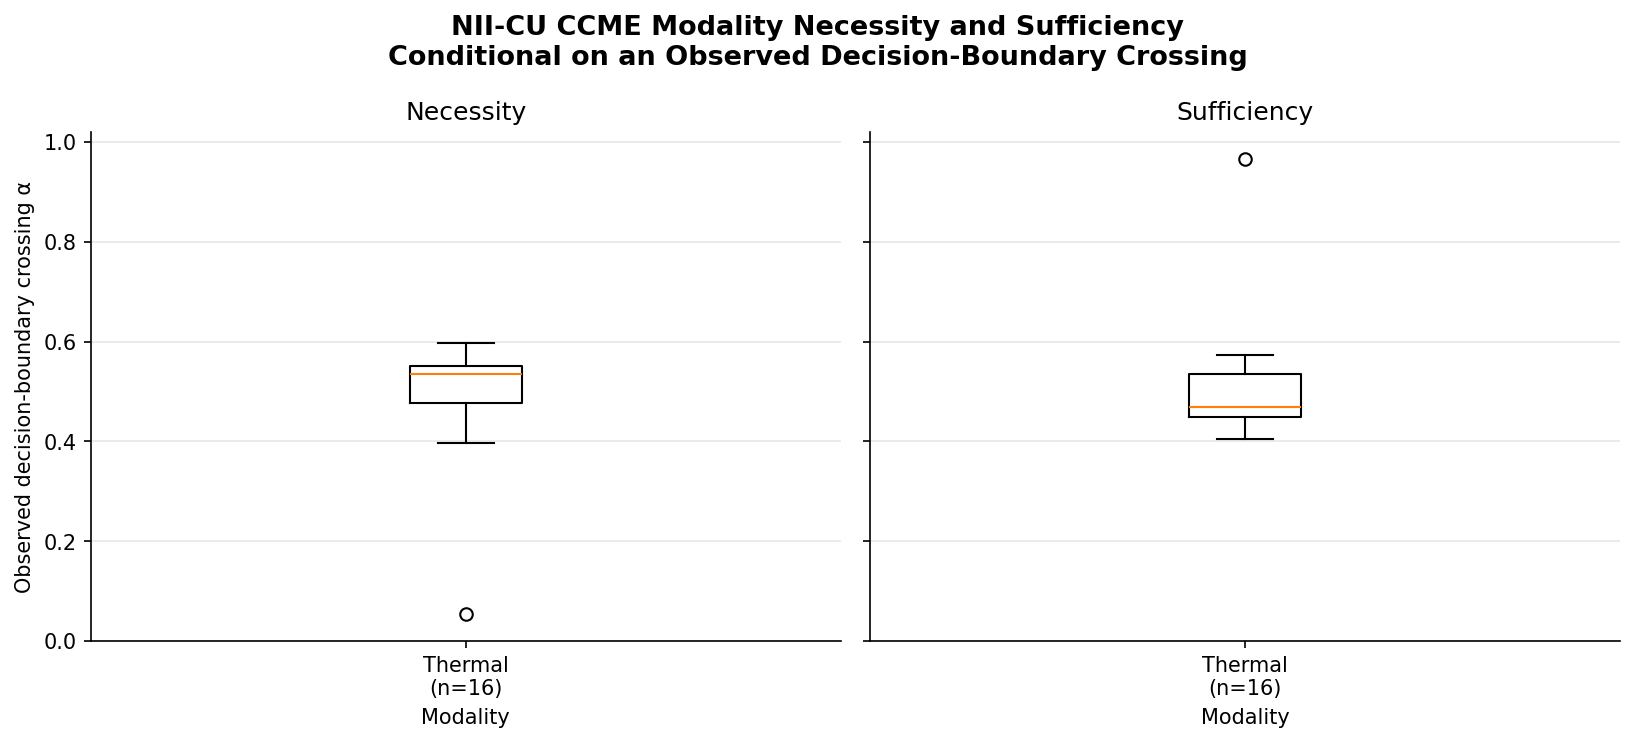

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/03_nii_ccme_crossing_distributions.pdf


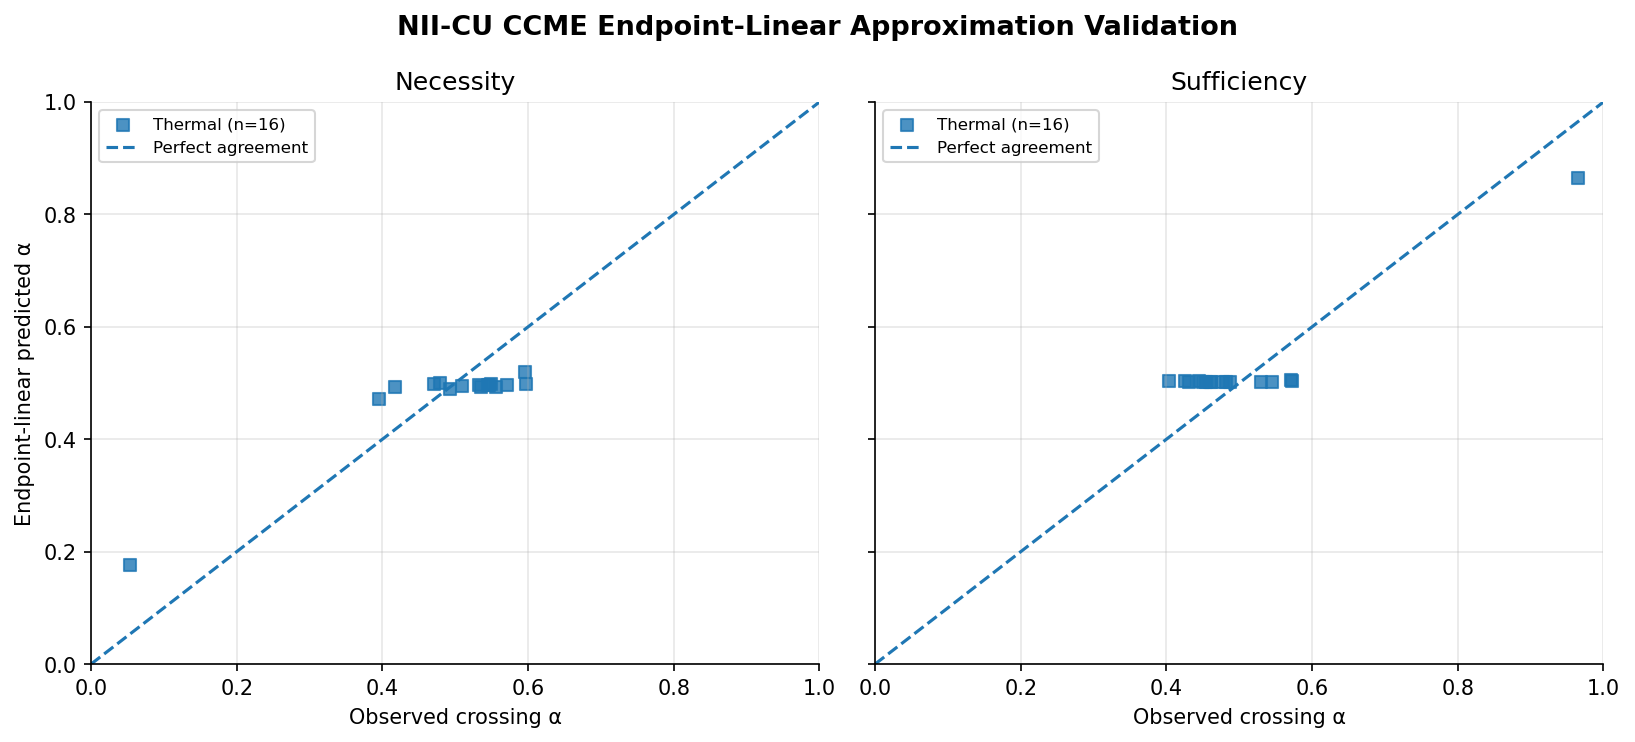

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/03_nii_ccme_linear_validation.pdf

Corrected NII-CU CCME analysis complete.


In [ ]:
# Refined seed-42 CCME and endpoint validation

import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm


# 1. Required-object checks

required_ccme_objects = [
    "NII_LATE_FUSION_MODEL",
    "NII_TEST_DATASET",
    "NII_PREDICTION_TABLE",
    "NII_REPRESENTATIVE_TEST_IDXS",
    "NII_TRAIN_RGB_EMBED_BASELINE",
    "NII_TRAIN_TH_EMBED_BASELINE",
    "extract_nii_late_fusion_embeddings",
    "nii_margin_from_embeddings",
    "nii_state_from_embeddings",
    "unpack_nii_dataset_item",
    "NII_CORRECTED_DIR",
]

missing_ccme_objects = [
    name
    for name in required_ccme_objects
    if name not in globals()
]

if missing_ccme_objects:
    raise NameError(
        "Run NII-CU Corrected Cells 1, 1B, and 2 first. Missing: "
        + ", ".join(missing_ccme_objects)
    )


# 2. CCME configuration

NII_CCME_GRID_SIZE = 101
NII_CCME_BISECTION_STEPS = 25

NII_CCME_MARGIN_TOLERANCE = 1e-8
NII_CCME_MONOTONICITY_TOLERANCE = 1e-6

NII_CCME_ALPHAS = np.linspace(
    0.0,
    1.0,
    NII_CCME_GRID_SIZE,
    dtype=np.float64,
)

NII_CCME_MODALITIES = [
    "RGB",
    "Thermal",
]

NII_CCME_ANALYSES = [
    "Necessity",
    "Sufficiency",
]

print(
    "Representative sample count:",
    len(NII_REPRESENTATIVE_TEST_IDXS),
)

print(
    "Dense interpolation grid:",
    NII_CCME_GRID_SIZE,
    "points",
)


# 3. Basic interpolation helpers

def interpolate_embedding(
    start_embedding,
    end_embedding,
    alpha,
):
    """
    Linear interpolation:

        z(alpha) = (1-alpha) * start + alpha * end
    """
    start_embedding = np.asarray(
        start_embedding,
        dtype=np.float32,
    )

    end_embedding = np.asarray(
        end_embedding,
        dtype=np.float32,
    )

    return (
        (1.0 - float(alpha)) * start_embedding
        + float(alpha) * end_embedding
    ).astype(np.float32)


def interpolate_from_baseline(
    baseline_embedding,
    factual_embedding,
    alpha,
):
    """
    Restore a factual embedding from its baseline:

        z(alpha) = baseline + alpha * (factual - baseline)
    """
    return interpolate_embedding(
        baseline_embedding,
        factual_embedding,
        alpha,
    )


# 4. Construct one CCME embedding state

def build_nii_ccme_embedding_pair(
    analysis,
    modality,
    alpha,
    factual_rgb_embedding,
    factual_thermal_embedding,
    baseline_rgb_embedding,
    baseline_thermal_embedding,
):
    """
    Construct the embedding pair for a CCME intervention.

    Necessity
    ---------
    Start from the factual pair at alpha=0 and move one modality toward
    its normal baseline as alpha approaches 1.

    Sufficiency
    -----------
    Start from the all-baseline pair at alpha=0 and restore one factual
    modality as alpha approaches 1 while the other modality remains at
    baseline.
    """
    if analysis == "Necessity":

        if modality == "RGB":
            rgb_embedding = interpolate_embedding(
                factual_rgb_embedding,
                baseline_rgb_embedding,
                alpha,
            )

            thermal_embedding = factual_thermal_embedding

        elif modality == "Thermal":
            rgb_embedding = factual_rgb_embedding

            thermal_embedding = interpolate_embedding(
                factual_thermal_embedding,
                baseline_thermal_embedding,
                alpha,
            )

        else:
            raise ValueError(
                f"Unknown modality: {modality}"
            )

    elif analysis == "Sufficiency":

        if modality == "RGB":
            rgb_embedding = interpolate_from_baseline(
                baseline_rgb_embedding,
                factual_rgb_embedding,
                alpha,
            )

            thermal_embedding = baseline_thermal_embedding

        elif modality == "Thermal":
            rgb_embedding = baseline_rgb_embedding

            thermal_embedding = interpolate_from_baseline(
                baseline_thermal_embedding,
                factual_thermal_embedding,
                alpha,
            )

        else:
            raise ValueError(
                f"Unknown modality: {modality}"
            )

    else:
        raise ValueError(
            f"Unknown CCME analysis: {analysis}"
        )

    return (
        np.asarray(rgb_embedding, dtype=np.float32),
        np.asarray(thermal_embedding, dtype=np.float32),
    )


# 5. Evaluate one complete CCME path

def evaluate_nii_ccme_path(
    model,
    analysis,
    modality,
    factual_rgb_embedding,
    factual_thermal_embedding,
    baseline_rgb_embedding,
    baseline_thermal_embedding,
    alphas=NII_CCME_ALPHAS,
):
    """
    Evaluate anomaly-logit margin along one CCME interpolation path.
    """
    margins = []

    for alpha in alphas:
        rgb_embedding, thermal_embedding = (
            build_nii_ccme_embedding_pair(
                analysis=analysis,
                modality=modality,
                alpha=float(alpha),
                factual_rgb_embedding=factual_rgb_embedding,
                factual_thermal_embedding=factual_thermal_embedding,
                baseline_rgb_embedding=baseline_rgb_embedding,
                baseline_thermal_embedding=baseline_thermal_embedding,
            )
        )

        margin = nii_margin_from_embeddings(
            model,
            rgb_embedding,
            thermal_embedding,
        )

        margins.append(float(margin))

    return np.asarray(
        margins,
        dtype=np.float64,
    )

# 6. Crossing logic

def positive_margin(
    margin,
    tolerance=NII_CCME_MARGIN_TOLERANCE,
):
    return float(margin) > float(tolerance)


def nonpositive_margin(
    margin,
    tolerance=NII_CCME_MARGIN_TOLERANCE,
):
    return float(margin) <= float(tolerance)


def locate_first_crossing_bracket(
    analysis,
    alphas,
    margins,
):
    """
    Return the first dense-grid bracket containing the relevant crossing.

    Necessity:
        positive -> nonpositive

    Sufficiency:
        nonpositive -> positive
    """
    for index in range(
        len(alphas) - 1
    ):
        left_margin = float(
            margins[index]
        )

        right_margin = float(
            margins[index + 1]
        )

        if analysis == "Necessity":
            crossed = (
                positive_margin(left_margin)
                and nonpositive_margin(right_margin)
            )

        elif analysis == "Sufficiency":
            crossed = (
                nonpositive_margin(left_margin)
                and positive_margin(right_margin)
            )

        else:
            raise ValueError(
                f"Unknown analysis: {analysis}"
            )

        if crossed:
            return {
                "left_index": int(index),
                "right_index": int(index + 1),
                "left_alpha": float(alphas[index]),
                "right_alpha": float(alphas[index + 1]),
                "left_margin": left_margin,
                "right_margin": right_margin,
            }

    return None


def count_boundary_transitions(
    margins,
    tolerance=NII_CCME_MARGIN_TOLERANCE,
):
    """
    Count sign-state transitions across the decision boundary.

    Values at or below tolerance are treated as nonpositive.
    """
    states = np.asarray(
        margins,
        dtype=np.float64,
    ) > float(tolerance)

    return int(
        np.sum(
            states[1:] != states[:-1]
        )
    )

# 7. Bisection refinement

def refine_nii_ccme_crossing(
    model,
    analysis,
    modality,
    left_alpha,
    right_alpha,
    factual_rgb_embedding,
    factual_thermal_embedding,
    baseline_rgb_embedding,
    baseline_thermal_embedding,
    n_steps=NII_CCME_BISECTION_STEPS,
):
    """
    Refine a known decision-boundary bracket.

    Returns the crossing alpha from the positive-side convention:

    Necessity:
        smallest alpha yielding a nonpositive margin.

    Sufficiency:
        smallest alpha yielding a positive margin.
    """
    low = float(left_alpha)
    high = float(right_alpha)

    def margin_at(alpha):
        rgb_embedding, thermal_embedding = (
            build_nii_ccme_embedding_pair(
                analysis=analysis,
                modality=modality,
                alpha=alpha,
                factual_rgb_embedding=factual_rgb_embedding,
                factual_thermal_embedding=factual_thermal_embedding,
                baseline_rgb_embedding=baseline_rgb_embedding,
                baseline_thermal_embedding=baseline_thermal_embedding,
            )
        )

        return nii_margin_from_embeddings(
            model,
            rgb_embedding,
            thermal_embedding,
        )

    low_margin = float(
        margin_at(low)
    )

    high_margin = float(
        margin_at(high)
    )

    for _ in range(
        int(n_steps)
    ):
        midpoint = (
            low + high
        ) / 2.0

        midpoint_margin = float(
            margin_at(midpoint)
        )

        if analysis == "Necessity":
            if positive_margin(
                midpoint_margin
            ):
                low = midpoint
                low_margin = midpoint_margin
            else:
                high = midpoint
                high_margin = midpoint_margin

        elif analysis == "Sufficiency":
            if positive_margin(
                midpoint_margin
            ):
                high = midpoint
                high_margin = midpoint_margin
            else:
                low = midpoint
                low_margin = midpoint_margin

        else:
            raise ValueError(
                f"Unknown analysis: {analysis}"
            )

    crossing_alpha = float(
        high
    )

    crossing_margin = float(
        high_margin
    )

    return {
        "crossing_alpha": crossing_alpha,
        "crossing_margin": crossing_margin,
        "final_left_alpha": float(low),
        "final_right_alpha": float(high),
        "final_left_margin": float(low_margin),
        "final_right_margin": float(high_margin),
    }

# 8. Endpoint-linear approximation

def endpoint_linear_crossing(
    analysis,
    start_margin,
    end_margin,
):
    """
    Estimate the crossing from a line connecting the two endpoint margins.

    Returns:
        predicted_crossing_status
        predicted_alpha
    """
    start_margin = float(
        start_margin
    )

    end_margin = float(
        end_margin
    )

    denominator = (
        end_margin
        - start_margin
    )

    if analysis == "Necessity":
        endpoint_crossing = (
            positive_margin(start_margin)
            and nonpositive_margin(end_margin)
        )

    elif analysis == "Sufficiency":
        endpoint_crossing = (
            nonpositive_margin(start_margin)
            and positive_margin(end_margin)
        )

    else:
        raise ValueError(
            f"Unknown analysis: {analysis}"
        )

    if not endpoint_crossing:
        return {
            "linear_status": "no_crossing",
            "linear_alpha": np.nan,
        }

    if abs(denominator) <= 1e-12:
        return {
            "linear_status": "degenerate_endpoints",
            "linear_alpha": np.nan,
        }

    estimated_alpha = (
        -start_margin
        / denominator
    )

    estimated_alpha = float(
        np.clip(
            estimated_alpha,
            0.0,
            1.0,
        )
    )

    return {
        "linear_status": "crossed",
        "linear_alpha": estimated_alpha,
    }

# 9. Monotonicity diagnostics

def summarize_path_monotonicity(
    analysis,
    margins,
    tolerance=NII_CCME_MONOTONICITY_TOLERANCE,
):
    """
    Quantify whether the margin changes in the theoretically expected
    direction along the path.

    Necessity expects a non-increasing anomaly margin.
    Sufficiency expects a non-decreasing anomaly margin.
    """
    margins = np.asarray(
        margins,
        dtype=np.float64,
    )

    differences = np.diff(
        margins
    )

    if len(differences) == 0:
        return {
            "monotonic_step_fraction": np.nan,
            "strictly_monotonic": False,
            "largest_reverse_step": np.nan,
        }

    if analysis == "Necessity":
        expected_steps = (
            differences
            <= float(tolerance)
        )

        reverse_magnitudes = np.maximum(
            differences,
            0.0,
        )

    elif analysis == "Sufficiency":
        expected_steps = (
            differences
            >= -float(tolerance)
        )

        reverse_magnitudes = np.maximum(
            -differences,
            0.0,
        )

    else:
        raise ValueError(
            f"Unknown analysis: {analysis}"
        )

    return {
        "monotonic_step_fraction": float(
            np.mean(
                expected_steps
            )
        ),
        "strictly_monotonic": bool(
            np.all(
                expected_steps
            )
        ),
        "largest_reverse_step": float(
            np.max(
                reverse_magnitudes
            )
        ),
    }

# 10. Determine CCME applicability and observed status

def determine_nii_ccme_status(
    analysis,
    factual_margin,
    path_margins,
):
    """
    Assign explicit applicability and crossing status.

    Necessity is defined only when the factual prediction is positive.

    Sufficiency requires the all-baseline starting state to be
    nonpositive. It is otherwise marked baseline_already_positive.
    """
    factual_margin = float(
        factual_margin
    )

    start_margin = float(
        path_margins[0]
    )

    crossing_bracket = (
        locate_first_crossing_bracket(
            analysis,
            NII_CCME_ALPHAS,
            path_margins,
        )
    )

    if analysis == "Necessity":

        if nonpositive_margin(
            factual_margin
        ):
            return {
                "applicable": False,
                "status": "not_applicable_factual_negative",
                "crossing_bracket": None,
            }

        if crossing_bracket is None:
            return {
                "applicable": True,
                "status": "no_crossing",
                "crossing_bracket": None,
            }

        return {
            "applicable": True,
            "status": "crossed",
            "crossing_bracket": crossing_bracket,
        }

    if analysis == "Sufficiency":

        if positive_margin(
            start_margin
        ):
            return {
                "applicable": False,
                "status": "baseline_already_positive",
                "crossing_bracket": None,
            }

        if crossing_bracket is None:
            return {
                "applicable": True,
                "status": "no_crossing",
                "crossing_bracket": None,
            }

        return {
            "applicable": True,
            "status": "crossed",
            "crossing_bracket": crossing_bracket,
        }

    raise ValueError(
        f"Unknown analysis: {analysis}"
    )

# 11. Analyze one sample

def analyze_one_nii_ccme_sample(
    sample_idx,
):
    """
    Run all four CCME paths for one test sample:

        RGB necessity
        Thermal necessity
        RGB sufficiency
        Thermal sufficiency
    """
    sample_idx = int(
        sample_idx
    )

    prediction_row = (
        NII_PREDICTION_TABLE[
            NII_PREDICTION_TABLE[
                "sample_idx"
            ]
            == sample_idx
        ]
        .iloc[0]
    )

    rgb_t, thermal_t, true_label = (
        unpack_nii_dataset_item(
            NII_TEST_DATASET[
                sample_idx
            ]
        )
    )

    factual_rgb_embedding, factual_thermal_embedding = (
        extract_nii_late_fusion_embeddings(
            NII_LATE_FUSION_MODEL,
            rgb_t,
            thermal_t,
        )
    )

    factual_state = nii_state_from_embeddings(
        NII_LATE_FUSION_MODEL,
        factual_rgb_embedding,
        factual_thermal_embedding,
    )

    sample_summary_rows = []
    sample_path_rows = []

    for analysis in NII_CCME_ANALYSES:
        for modality in NII_CCME_MODALITIES:

            margins = evaluate_nii_ccme_path(
                model=NII_LATE_FUSION_MODEL,
                analysis=analysis,
                modality=modality,
                factual_rgb_embedding=factual_rgb_embedding,
                factual_thermal_embedding=factual_thermal_embedding,
                baseline_rgb_embedding=NII_TRAIN_RGB_EMBED_BASELINE,
                baseline_thermal_embedding=NII_TRAIN_TH_EMBED_BASELINE,
                alphas=NII_CCME_ALPHAS,
            )

            status_information = (
                determine_nii_ccme_status(
                    analysis=analysis,
                    factual_margin=factual_state[
                        "anomaly_margin"
                    ],
                    path_margins=margins,
                )
            )

            crossing_alpha = np.nan
            crossing_margin = np.nan
            bracket_width = np.nan

            if (
                status_information[
                    "status"
                ]
                == "crossed"
            ):
                bracket = status_information[
                    "crossing_bracket"
                ]

                refined = refine_nii_ccme_crossing(
                    model=NII_LATE_FUSION_MODEL,
                    analysis=analysis,
                    modality=modality,
                    left_alpha=bracket[
                        "left_alpha"
                    ],
                    right_alpha=bracket[
                        "right_alpha"
                    ],
                    factual_rgb_embedding=factual_rgb_embedding,
                    factual_thermal_embedding=factual_thermal_embedding,
                    baseline_rgb_embedding=NII_TRAIN_RGB_EMBED_BASELINE,
                    baseline_thermal_embedding=NII_TRAIN_TH_EMBED_BASELINE,
                    n_steps=NII_CCME_BISECTION_STEPS,
                )

                crossing_alpha = refined[
                    "crossing_alpha"
                ]

                crossing_margin = refined[
                    "crossing_margin"
                ]

                bracket_width = (
                    refined[
                        "final_right_alpha"
                    ]
                    - refined[
                        "final_left_alpha"
                    ]
                )

            linear_result = endpoint_linear_crossing(
                analysis=analysis,
                start_margin=margins[0],
                end_margin=margins[-1],
            )

            observed_crossed = (
                status_information[
                    "status"
                ]
                == "crossed"
            )

            linear_crossed = (
                linear_result[
                    "linear_status"
                ]
                == "crossed"
            )

            if status_information[
                "applicable"
            ]:
                linear_status_agreement = bool(
                    observed_crossed
                    == linear_crossed
                )
            else:
                linear_status_agreement = np.nan

            if (
                observed_crossed
                and linear_crossed
            ):
                linear_absolute_error = abs(
                    float(crossing_alpha)
                    - float(
                        linear_result[
                            "linear_alpha"
                        ]
                    )
                )
            else:
                linear_absolute_error = np.nan

            monotonicity = (
                summarize_path_monotonicity(
                    analysis,
                    margins,
                )
            )

            transition_count = (
                count_boundary_transitions(
                    margins
                )
            )

            sample_summary_rows.append(
                {
                    "sample_idx": sample_idx,
                    "true_label": int(
                        true_label
                    ),
                    "pred_label": int(
                        prediction_row[
                            "pred_label"
                        ]
                    ),
                    "category": str(
                        prediction_row[
                            "category"
                        ]
                    ),
                    "p_anomaly": float(
                        prediction_row[
                            "p_anomaly"
                        ]
                    ),
                    "predicted_confidence": float(
                        prediction_row[
                            "predicted_confidence"
                        ]
                    ),
                    "factual_margin": float(
                        factual_state[
                            "anomaly_margin"
                        ]
                    ),
                    "analysis": analysis,
                    "modality": modality,
                    "applicable": bool(
                        status_information[
                            "applicable"
                        ]
                    ),
                    "status": status_information[
                        "status"
                    ],
                    "observed_crossing": bool(
                        observed_crossed
                    ),
                    "crossing_alpha": crossing_alpha,
                    "crossing_margin": crossing_margin,
                    "bisection_final_width": bracket_width,
                    "path_start_margin": float(
                        margins[0]
                    ),
                    "path_end_margin": float(
                        margins[-1]
                    ),
                    "path_min_margin": float(
                        np.min(
                            margins
                        )
                    ),
                    "path_max_margin": float(
                        np.max(
                            margins
                        )
                    ),
                    "boundary_transition_count": int(
                        transition_count
                    ),
                    "multiple_crossings": bool(
                        transition_count > 1
                    ),
                    "monotonic_step_fraction": (
                        monotonicity[
                            "monotonic_step_fraction"
                        ]
                    ),
                    "strictly_monotonic": (
                        monotonicity[
                            "strictly_monotonic"
                        ]
                    ),
                    "largest_reverse_step": (
                        monotonicity[
                            "largest_reverse_step"
                        ]
                    ),
                    "linear_status": (
                        linear_result[
                            "linear_status"
                        ]
                    ),
                    "linear_crossing_alpha": (
                        linear_result[
                            "linear_alpha"
                        ]
                    ),
                    "linear_status_agreement": (
                        linear_status_agreement
                    ),
                    "linear_absolute_error": (
                        linear_absolute_error
                    ),
                }
            )

            for alpha, margin in zip(
                NII_CCME_ALPHAS,
                margins,
            ):
                sample_path_rows.append(
                    {
                        "sample_idx": sample_idx,
                        "category": str(
                            prediction_row[
                                "category"
                            ]
                        ),
                        "analysis": analysis,
                        "modality": modality,
                        "alpha": float(
                            alpha
                        ),
                        "anomaly_margin": float(
                            margin
                        ),
                        "predicted_positive": bool(
                            positive_margin(
                                margin
                            )
                        ),
                    }
                )

    return (
        sample_summary_rows,
        sample_path_rows,
    )


# 12. Run corrected CCME

all_ccme_summary_rows = []
all_ccme_path_rows = []

ccme_failures = []

for sample_idx in tqdm(
    NII_REPRESENTATIVE_TEST_IDXS,
    desc="Corrected NII-CU CCME",
):
    try:
        summary_rows, path_rows = (
            analyze_one_nii_ccme_sample(
                sample_idx
            )
        )

        all_ccme_summary_rows.extend(
            summary_rows
        )

        all_ccme_path_rows.extend(
            path_rows
        )

    except Exception as error:
        ccme_failures.append(
            {
                "sample_idx": int(
                    sample_idx
                ),
                "error": str(
                    error
                ),
            }
        )


NII_CCME_CORRECTED = pd.DataFrame(
    all_ccme_summary_rows
)

NII_CCME_PATHS = pd.DataFrame(
    all_ccme_path_rows
)

if ccme_failures:
    failure_path = (
        NII_CORRECTED_DIR
        / "03_nii_ccme_failures.csv"
    )

    pd.DataFrame(
        ccme_failures
    ).to_csv(
        failure_path,
        index=False,
    )

    raise RuntimeError(
        f"{len(ccme_failures)} CCME samples failed. "
        f"See {failure_path}"
    )


# 13. Save detailed CCME outputs

ccme_output_path = (
    NII_CORRECTED_DIR
    / "03_nii_ccme_corrected.csv"
)

ccme_path_output_path = (
    NII_CORRECTED_DIR
    / "03_nii_ccme_dense_paths.csv"
)

NII_CCME_CORRECTED.to_csv(
    ccme_output_path,
    index=False,
)

NII_CCME_PATHS.to_csv(
    ccme_path_output_path,
    index=False,
)

print(
    "\nSaved:",
    ccme_output_path,
)

print(
    "Saved:",
    ccme_path_output_path,
)


# 14. Structural audit

expected_summary_rows = (
    len(
        NII_REPRESENTATIVE_TEST_IDXS
    )
    * len(
        NII_CCME_ANALYSES
    )
    * len(
        NII_CCME_MODALITIES
    )
)

expected_path_rows = (
    expected_summary_rows
    * NII_CCME_GRID_SIZE
)

if len(
    NII_CCME_CORRECTED
) != expected_summary_rows:
    raise ValueError(
        "CCME summary row-count mismatch: "
        f"{len(NII_CCME_CORRECTED)} observed versus "
        f"{expected_summary_rows} expected."
    )

if len(
    NII_CCME_PATHS
) != expected_path_rows:
    raise ValueError(
        "CCME dense-path row-count mismatch: "
        f"{len(NII_CCME_PATHS)} observed versus "
        f"{expected_path_rows} expected."
    )

duplicate_columns = [
    "sample_idx",
    "analysis",
    "modality",
]

if NII_CCME_CORRECTED[
    duplicate_columns
].duplicated().any():
    raise ValueError(
        "Duplicate sample-analysis-modality rows detected."
    )

crossed_rows = NII_CCME_CORRECTED[
    NII_CCME_CORRECTED[
        "status"
    ]
    == "crossed"
]

if not crossed_rows[
    "crossing_alpha"
].between(
    0.0,
    1.0,
    inclusive="both",
).all():
    raise ValueError(
        "One or more crossing alphas fall outside [0,1]."
    )

print(
    "\nCCME structural audit passed."
)

# 15. Status and crossing-incidence summaries

NII_CCME_STATUS_SUMMARY = (
    NII_CCME_CORRECTED
    .groupby(
        [
            "analysis",
            "modality",
            "status",
        ],
        observed=False,
    )
    .size()
    .reset_index(
        name="N"
    )
)

print(
    "\nCCME explicit status summary"
)

display(
    NII_CCME_STATUS_SUMMARY
)

NII_CCME_STATUS_SUMMARY.to_csv(
    NII_CORRECTED_DIR
    / "03_nii_ccme_status_summary.csv",
    index=False,
)


def summarize_ccme_crossing_incidence(
    ccme_df,
):
    rows = []

    for (
        analysis,
        modality,
    ), group in ccme_df.groupby(
        [
            "analysis",
            "modality",
        ],
        observed=False,
    ):
        applicable_group = group[
            group[
                "applicable"
            ]
        ]

        crossed_group = applicable_group[
            applicable_group[
                "status"
            ]
            == "crossed"
        ]

        applicable_count = len(
            applicable_group
        )

        crossed_count = len(
            crossed_group
        )

        rows.append(
            {
                "analysis": analysis,
                "modality": modality,
                "total_rows": int(
                    len(group)
                ),
                "applicable_n": int(
                    applicable_count
                ),
                "crossed_n": int(
                    crossed_count
                ),
                "no_crossing_n": int(
                    (
                        applicable_group[
                            "status"
                        ]
                        == "no_crossing"
                    ).sum()
                ),
                "crossing_incidence": (
                    crossed_count
                    / applicable_count
                    if applicable_count > 0
                    else np.nan
                ),
                "conditional_median_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].median()
                    )
                    if crossed_count > 0
                    else np.nan
                ),
                "conditional_mean_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].mean()
                    )
                    if crossed_count > 0
                    else np.nan
                ),
                "conditional_q25_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].quantile(
                            0.25
                        )
                    )
                    if crossed_count > 0
                    else np.nan
                ),
                "conditional_q75_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].quantile(
                            0.75
                        )
                    )
                    if crossed_count > 0
                    else np.nan
                ),
                "multiple_crossing_n": int(
                    applicable_group[
                        "multiple_crossings"
                    ].sum()
                ),
                "mean_monotonic_step_fraction": (
                    float(
                        applicable_group[
                            "monotonic_step_fraction"
                        ].mean()
                    )
                    if applicable_count > 0
                    else np.nan
                ),
                "strictly_monotonic_fraction": (
                    float(
                        applicable_group[
                            "strictly_monotonic"
                        ].mean()
                    )
                    if applicable_count > 0
                    else np.nan
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


NII_CCME_CROSSING_SUMMARY = (
    summarize_ccme_crossing_incidence(
        NII_CCME_CORRECTED
    )
)

print(
    "\nCCME crossing incidence and conditional alpha"
)

display(
    NII_CCME_CROSSING_SUMMARY
)

NII_CCME_CROSSING_SUMMARY.to_csv(
    NII_CORRECTED_DIR
    / "03_nii_ccme_crossing_summary.csv",
    index=False,
)

# 16. Outcome-stratified status summary

NII_CCME_OUTCOME_SUMMARY = (
    NII_CCME_CORRECTED
    .groupby(
        [
            "category",
            "analysis",
            "modality",
            "status",
        ],
        observed=False,
    )
    .size()
    .reset_index(
        name="N"
    )
)

NII_CCME_OUTCOME_SUMMARY.to_csv(
    NII_CORRECTED_DIR
    / "03_nii_ccme_status_by_outcome.csv",
    index=False,
)

print(
    "\nCCME status by prediction outcome"
)

display(
    NII_CCME_OUTCOME_SUMMARY
)

# 17. Endpoint-linear validation summary

def safe_correlation(
    x,
    y,
):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    y = np.asarray(
        y,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[
        valid
    ]

    y = y[
        valid
    ]

    if len(x) < 3:
        return {
            "n": int(
                len(x)
            ),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    if (
        np.std(x) <= 1e-12
        or np.std(y) <= 1e-12
    ):
        return {
            "n": int(
                len(x)
            ),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
        }

    pearson_result = pearsonr(
        x,
        y,
    )

    spearman_result = spearmanr(
        x,
        y,
    )

    return {
        "n": int(
            len(x)
        ),
        "pearson_r": float(
            pearson_result.statistic
        ),
        "pearson_p": float(
            pearson_result.pvalue
        ),
        "spearman_rho": float(
            spearman_result.statistic
        ),
        "spearman_p": float(
            spearman_result.pvalue
        ),
    }


linear_validation_rows = []

for (
    analysis,
    modality,
), group in NII_CCME_CORRECTED.groupby(
    [
        "analysis",
        "modality",
    ],
    observed=False,
):
    applicable_group = group[
        group[
            "applicable"
        ]
    ]

    paired_crossings = applicable_group[
        (
            applicable_group[
                "status"
            ]
            == "crossed"
        )
        &
        (
            applicable_group[
                "linear_status"
            ]
            == "crossed"
        )
    ]

    correlation = safe_correlation(
        paired_crossings[
            "crossing_alpha"
        ],
        paired_crossings[
            "linear_crossing_alpha"
        ],
    )

    linear_validation_rows.append(
        {
            "analysis": analysis,
            "modality": modality,
            "applicable_n": int(
                len(
                    applicable_group
                )
            ),
            "status_agreement_n": int(
                applicable_group[
                    "linear_status_agreement"
                ].fillna(False).sum()
            ),
            "status_agreement_rate": (
                float(
                    applicable_group[
                        "linear_status_agreement"
                    ].mean()
                )
                if len(
                    applicable_group
                ) > 0
                else np.nan
            ),
            "paired_crossing_n": int(
                len(
                    paired_crossings
                )
            ),
            "mean_absolute_alpha_error": (
                float(
                    paired_crossings[
                        "linear_absolute_error"
                    ].mean()
                )
                if len(
                    paired_crossings
                ) > 0
                else np.nan
            ),
            "median_absolute_alpha_error": (
                float(
                    paired_crossings[
                        "linear_absolute_error"
                    ].median()
                )
                if len(
                    paired_crossings
                ) > 0
                else np.nan
            ),
            **correlation,
        }
    )


NII_CCME_LINEAR_VALIDATION = pd.DataFrame(
    linear_validation_rows
)

print(
    "\nEndpoint-linear validation"
)

display(
    NII_CCME_LINEAR_VALIDATION
)

NII_CCME_LINEAR_VALIDATION.to_csv(
    NII_CORRECTED_DIR
    / "03_nii_ccme_linear_validation_summary.csv",
    index=False,
)

# 18. Crossing-distribution figure

def plot_nii_ccme_crossing_distributions(
    ccme_df,
    save_name="03_nii_ccme_crossing_distributions.pdf",
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5),
        sharey=True,
    )

    for axis, analysis in zip(
        axes,
        [
            "Necessity",
            "Sufficiency",
        ],
    ):
        plot_data = []

        labels = []

        for modality in [
            "RGB",
            "Thermal",
        ]:
            values = (
                ccme_df[
                    (
                        ccme_df[
                            "analysis"
                        ]
                        == analysis
                    )
                    &
                    (
                        ccme_df[
                            "modality"
                        ]
                        == modality
                    )
                    &
                    (
                        ccme_df[
                            "status"
                        ]
                        == "crossed"
                    )
                ][
                    "crossing_alpha"
                ]
                .dropna()
                .to_numpy()
            )

            if len(values) > 0:
                plot_data.append(
                    values
                )

                labels.append(
                    f"{modality}\n(n={len(values)})"
                )

        if plot_data:
            axis.boxplot(
                plot_data,
                labels=labels,
                showfliers=True,
            )

        axis.set_title(
            analysis
        )

        axis.set_xlabel(
            "Modality"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        axis.set_ylim(
            0.0,
            1.02,
        )

    axes[0].set_ylabel(
        "Observed decision-boundary crossing α"
    )

    plt.suptitle(
        "NII-CU CCME Modality Necessity and Sufficiency\n"
        "Conditional on an Observed Decision-Boundary Crossing",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_ccme_crossing_distributions(
    NII_CCME_CORRECTED
)

# 19. Endpoint-linear validation figure

def plot_nii_ccme_linear_validation(
    ccme_df,
    save_name="03_nii_ccme_linear_validation.pdf",
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5),
        sharex=True,
        sharey=True,
    )

    for axis, analysis in zip(
        axes,
        [
            "Necessity",
            "Sufficiency",
        ],
    ):
        analysis_df = ccme_df[
            (
                ccme_df[
                    "analysis"
                ]
                == analysis
            )
            &
            (
                ccme_df[
                    "status"
                ]
                == "crossed"
            )
            &
            (
                ccme_df[
                    "linear_status"
                ]
                == "crossed"
            )
        ]

        for modality, marker in [
            (
                "RGB",
                "o",
            ),
            (
                "Thermal",
                "s",
            ),
        ]:
            modality_df = analysis_df[
                analysis_df[
                    "modality"
                ]
                == modality
            ]

            if modality_df.empty:
                continue

            axis.scatter(
                modality_df[
                    "crossing_alpha"
                ],
                modality_df[
                    "linear_crossing_alpha"
                ],
                marker=marker,
                alpha=0.8,
                label=(
                    f"{modality} "
                    f"(n={len(modality_df)})"
                ),
            )

        axis.plot(
            [
                0,
                1,
            ],
            [
                0,
                1,
            ],
            linestyle="--",
            linewidth=1.5,
            label="Perfect agreement",
        )

        axis.set_title(
            analysis
        )

        axis.set_xlabel(
            "Observed crossing α"
        )

        axis.set_xlim(
            0,
            1,
        )

        axis.set_ylim(
            0,
            1,
        )

        axis.grid(
            alpha=0.3
        )

        axis.legend(
            fontsize=8
        )

    axes[0].set_ylabel(
        "Endpoint-linear predicted α"
    )

    plt.suptitle(
        "NII-CU CCME Endpoint-Linear Approximation Validation",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_ccme_linear_validation(
    NII_CCME_CORRECTED
)

# 20. Save methodology metadata

nii_ccme_metadata = {
    "domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "model": "Late-Fusion",
    "representative_sample_count": int(
        len(
            NII_REPRESENTATIVE_TEST_IDXS
        )
    ),
    "available_outcomes": (
        NII_PREDICTION_TABLE[
            "category"
        ]
        .value_counts()
        .to_dict()
    ),
    "sampling_policy": (
        "Confidence-stratified within each available exclusive "
        "prediction outcome"
    ),
    "necessity_applicability": (
        "Only samples with factual anomaly-positive predictions"
    ),
    "sufficiency_start_state": (
        "Both modalities at fixed training-normal mean embeddings"
    ),
    "necessity_path": (
        "One factual modality interpolated toward its training-normal "
        "mean embedding while the other factual modality remains fixed"
    ),
    "sufficiency_path": (
        "One modality restored from its training-normal mean embedding "
        "to its factual embedding while the other remains at baseline"
    ),
    "decision_function": (
        "Person logit minus normal logit"
    ),
    "decision_boundary": 0.0,
    "dense_grid_points": int(
        NII_CCME_GRID_SIZE
    ),
    "bisection_steps": int(
        NII_CCME_BISECTION_STEPS
    ),
    "explicit_statuses": [
        "crossed",
        "no_crossing",
        "not_applicable_factual_negative",
        "baseline_already_positive",
    ],
    "linear_approximation": (
        "Crossing of the line connecting endpoint anomaly margins"
    ),
    "conditional_alpha_policy": (
        "Alpha summaries are calculated only among observed crossings"
    ),
}

with open(
    NII_CORRECTED_DIR
    / "03_nii_ccme_metadata.json",
    "w",
) as file:
    json.dump(
        nii_ccme_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU CCME analysis complete."
)

Reference embedding arrays: (200, 512) (200, 512)

Baseline variants: ['Mean200_Primary', 'Mean100_A', 'Mean100_B', 'Medoid']

Embedding-baseline state audit


,baseline_name,n_reference,description,pred_label,p_normal,p_anomaly,anomaly_margin
0,Mean200_Primary,200,Mean embeddings from all 200 fixed normal trai...,0,0.975572,0.024428,-3.687302
1,Mean100_A,100,Mean embeddings from deterministic normal-trai...,0,0.975607,0.024393,-3.688757
2,Mean100_B,100,Mean embeddings from deterministic normal-trai...,0,0.975534,0.024466,-3.685699
3,Medoid,1,Embedding of the real paired normal-training m...,0,0.975273,0.024727,-3.674816


Caching representative factual embeddings:   0%|          | 0/32 [00:00<?, ?it/s]

NII-CU CCME baseline sensitivity:   0%|          | 0/512 [00:00<?, ?it/s]


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/04_nii_ccme_baseline_sensitivity.csv
Baseline-sensitivity structural audit passed.

Baseline-specific CCME summaries


,baseline_name,analysis,modality,total_n,applicable_n,crossed_n,no_crossing_n,crossing_incidence,median_crossing_alpha,mean_crossing_alpha,q25_crossing_alpha,q75_crossing_alpha,mean_endpoint_margin_change,strictly_monotonic_fraction,multiple_crossing_n
0,Mean100_A,Necessity,RGB,32,16,0,16,0.00000,NaN,NaN,NaN,NaN,-0.050436,0.00000,0
1,Mean100_A,Necessity,Thermal,32,16,16,0,1.00000,0.536341,0.492605,0.479603,0.553720,-3.586789,0.50000,0
2,Mean100_A,Sufficiency,RGB,32,32,0,32,0.00000,NaN,NaN,NaN,NaN,0.040278,0.31250,0
3,Mean100_A,Sufficiency,Thermal,32,32,16,16,0.50000,0.467335,0.508074,0.446619,0.531972,3.576631,0.53125,0
4,Mean100_B,Necessity,RGB,32,16,0,16,0.00000,NaN,NaN,NaN,NaN,-0.050897,0.00000,0
5,Mean100_B,Necessity,Thermal,32,16,16,0,1.00000,0.531970,0.488322,0.474661,0.549022,-3.587695,0.56250,0
6,Mean100_B,Sufficiency,RGB,32,32,0,32,0.00000,NaN,NaN,NaN,NaN,0.036314,0.25000,0
7,Mean100_B,Sufficiency,Thermal,32,32,16,16,0.50000,0.471519,0.512044,0.450776,0.536154,3.573112,0.50000,0
8,Mean200_Primary,Necessity,RGB,32,16,0,16,0.00000,NaN,NaN,NaN,NaN,-0.050709,0.00000,0
9,Mean200_Primary,Necessity,Thermal,32,16,16,0,1.00000,0.534146,0.490454,0.477118,0.551361,-3.587291,0.56250,0


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/04_nii_ccme_baseline_sensitivity_summary.csv

Comparison with the primary Mean200 baseline


,baseline_name,analysis,modality,n,status_agreement_rate,paired_crossing_n,mean_absolute_alpha_difference,median_absolute_alpha_difference,maximum_absolute_alpha_difference,mean_absolute_endpoint_margin_difference
0,Mean100_A,Necessity,RGB,32,1.00000,0,NaN,NaN,NaN,0.001110
1,Mean100_A,Necessity,Thermal,32,1.00000,16,0.002151,0.002190,0.002911,0.000610
2,Mean100_A,Sufficiency,RGB,32,1.00000,0,NaN,NaN,NaN,0.000610
3,Mean100_A,Sufficiency,Thermal,32,1.00000,16,0.001992,0.002089,0.002108,0.001110
4,Mean100_B,Necessity,RGB,32,1.00000,0,NaN,NaN,NaN,0.001049
5,Mean100_B,Necessity,Thermal,32,1.00000,16,0.002132,0.002173,0.002883,0.000569
6,Mean100_B,Sufficiency,RGB,32,1.00000,0,NaN,NaN,NaN,0.000569
7,Mean100_B,Sufficiency,Thermal,32,1.00000,16,0.001978,0.002075,0.002105,0.001049
8,Mean200_Primary,Necessity,RGB,32,1.00000,0,NaN,NaN,NaN,0.000000
9,Mean200_Primary,Necessity,Thermal,32,1.00000,16,0.000000,0.000000,0.000000,0.000000


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/04_nii_ccme_baseline_comparison_summary.csv


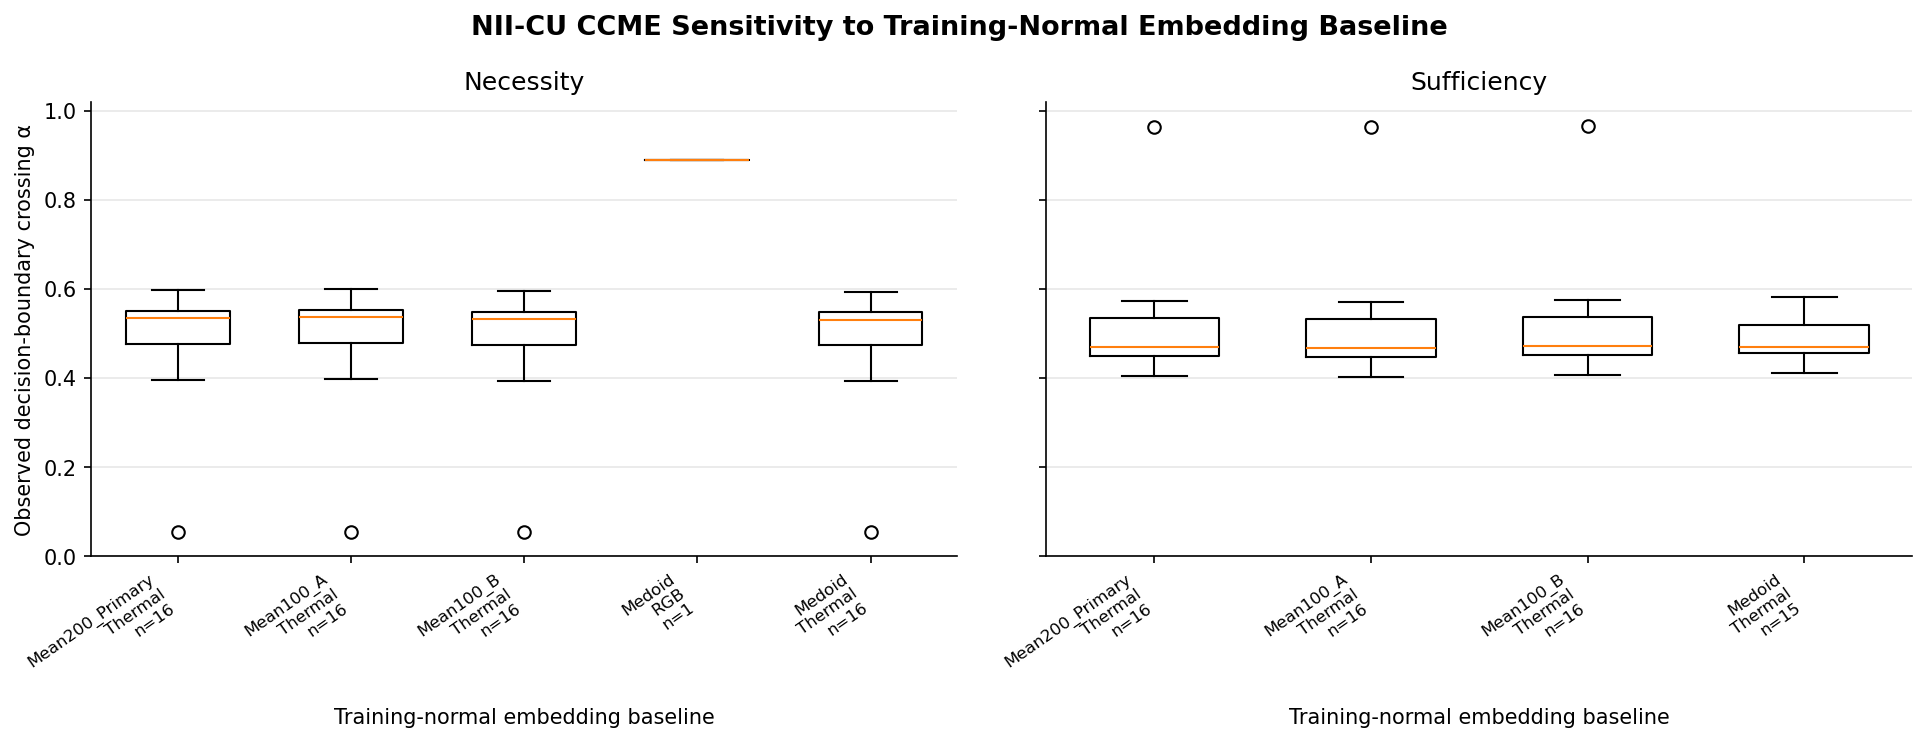

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/04_nii_ccme_baseline_sensitivity.pdf


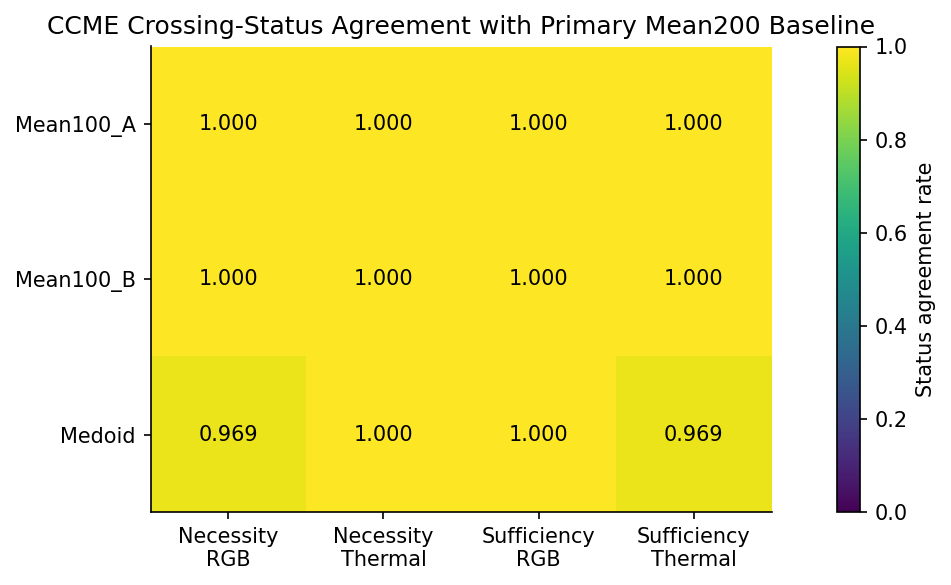

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/04_nii_ccme_baseline_status_agreement.pdf

Corrected NII-CU CCME baseline-sensitivity analysis complete.


In [ ]:
# CCME reference-sensitivity analysis

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

# 1. Required-object checks

required_baseline_sensitivity_objects = [
    "NII_LATE_FUSION_MODEL",
    "NII_TRAIN_EVAL_DATASET",
    "NII_TEST_DATASET",
    "NII_BASELINE_TRAIN_IDXS",
    "NII_REPRESENTATIVE_TEST_IDXS",
    "NII_PREDICTION_TABLE",
    "NII_TRAIN_RGB_EMBED_BASELINE",
    "NII_TRAIN_TH_EMBED_BASELINE",
    "NII_PIXEL_MEDOID_TRAIN_IDX",
    "NII_CCME_ALPHAS",
    "NII_CCME_BISECTION_STEPS",
    "NII_CCME_ANALYSES",
    "NII_CCME_MODALITIES",
    "extract_nii_late_fusion_embeddings",
    "unpack_nii_dataset_item",
    "evaluate_nii_ccme_path",
    "determine_nii_ccme_status",
    "refine_nii_ccme_crossing",
    "count_boundary_transitions",
    "summarize_path_monotonicity",
    "endpoint_linear_crossing",
    "nii_state_from_embeddings",
    "NII_CORRECTED_DIR",
]

missing_objects = [
    object_name
    for object_name in required_baseline_sensitivity_objects
    if object_name not in globals()
]

if missing_objects:
    raise NameError(
        "Run Corrected Cells 1, 1B, 2, and 3 first. Missing: "
        + ", ".join(missing_objects)
    )

# 2. Recompute embeddings for the fixed 200 normal references

def collect_nii_training_normal_embeddings(
    model,
    dataset,
    sample_indices,
):
    """
    Collect paired RGB and thermal embeddings for the fixed training-normal
    reference set selected in Cell 1.
    """
    rows = []
    rgb_embeddings = []
    thermal_embeddings = []

    for sample_idx in tqdm(
        sample_indices,
        desc="Collecting baseline-reference embeddings",
    ):
        rgb_t, thermal_t, label = unpack_nii_dataset_item(
            dataset[int(sample_idx)]
        )

        if int(label) != 0:
            raise ValueError(
                f"Reference sample {sample_idx} is not normal."
            )

        rgb_embedding, thermal_embedding = (
            extract_nii_late_fusion_embeddings(
                model,
                rgb_t,
                thermal_t,
            )
        )

        rgb_embeddings.append(
            np.asarray(
                rgb_embedding,
                dtype=np.float32,
            )
        )

        thermal_embeddings.append(
            np.asarray(
                thermal_embedding,
                dtype=np.float32,
            )
        )

        rows.append(
            {
                "sample_idx": int(sample_idx),
                "label": int(label),
            }
        )

    return {
        "metadata": pd.DataFrame(rows),
        "rgb": np.stack(
            rgb_embeddings,
            axis=0,
        ),
        "thermal": np.stack(
            thermal_embeddings,
            axis=0,
        ),
    }


NII_REFERENCE_EMBEDDINGS = (
    collect_nii_training_normal_embeddings(
        NII_LATE_FUSION_MODEL,
        NII_TRAIN_EVAL_DATASET,
        NII_BASELINE_TRAIN_IDXS,
    )
)

reference_metadata = NII_REFERENCE_EMBEDDINGS[
    "metadata"
]

reference_rgb_embeddings = NII_REFERENCE_EMBEDDINGS[
    "rgb"
]

reference_thermal_embeddings = NII_REFERENCE_EMBEDDINGS[
    "thermal"
]

print(
    "Reference embedding arrays:",
    reference_rgb_embeddings.shape,
    reference_thermal_embeddings.shape,
)


# 3. Construct deterministic baseline variants

rng = np.random.default_rng(
    42
)

permutation = rng.permutation(
    len(reference_metadata)
)

half_point = len(permutation) // 2

half_a_positions = permutation[
    :half_point
]

half_b_positions = permutation[
    half_point:
]


def mean_baseline_from_positions(
    positions,
):
    return {
        "rgb": np.mean(
            reference_rgb_embeddings[positions],
            axis=0,
        ).astype(np.float32),
        "thermal": np.mean(
            reference_thermal_embeddings[positions],
            axis=0,
        ).astype(np.float32),
        "n_reference": int(len(positions)),
    }


# Real medoid embedding from the paired normal-training crop selected in 1B
medoid_rgb_t, medoid_thermal_t, medoid_label = (
    unpack_nii_dataset_item(
        NII_TRAIN_EVAL_DATASET[
            int(NII_PIXEL_MEDOID_TRAIN_IDX)
        ]
    )
)

if int(medoid_label) != 0:
    raise ValueError(
        "The medoid baseline sample is not normal."
    )

medoid_rgb_embedding, medoid_thermal_embedding = (
    extract_nii_late_fusion_embeddings(
        NII_LATE_FUSION_MODEL,
        medoid_rgb_t,
        medoid_thermal_t,
    )
)


NII_CCME_BASELINE_VARIANTS = {
    "Mean200_Primary": {
        "rgb": np.asarray(
            NII_TRAIN_RGB_EMBED_BASELINE,
            dtype=np.float32,
        ),
        "thermal": np.asarray(
            NII_TRAIN_TH_EMBED_BASELINE,
            dtype=np.float32,
        ),
        "n_reference": int(
            len(NII_BASELINE_TRAIN_IDXS)
        ),
        "description": (
            "Mean embeddings from all 200 fixed normal training crops"
        ),
    },
    "Mean100_A": {
        **mean_baseline_from_positions(
            half_a_positions
        ),
        "description": (
            "Mean embeddings from deterministic normal-training half A"
        ),
    },
    "Mean100_B": {
        **mean_baseline_from_positions(
            half_b_positions
        ),
        "description": (
            "Mean embeddings from deterministic normal-training half B"
        ),
    },
    "Medoid": {
        "rgb": np.asarray(
            medoid_rgb_embedding,
            dtype=np.float32,
        ),
        "thermal": np.asarray(
            medoid_thermal_embedding,
            dtype=np.float32,
        ),
        "n_reference": 1,
        "description": (
            "Embedding of the real paired normal-training medoid crop"
        ),
    },
}

print(
    "\nBaseline variants:",
    list(NII_CCME_BASELINE_VARIANTS.keys()),
)


# 4. Audit each all-baseline embedding state

baseline_state_rows = []

for baseline_name, baseline_data in (
    NII_CCME_BASELINE_VARIANTS.items()
):
    state = nii_state_from_embeddings(
        NII_LATE_FUSION_MODEL,
        baseline_data["rgb"],
        baseline_data["thermal"],
    )

    baseline_state_rows.append(
        {
            "baseline_name": baseline_name,
            "n_reference": int(
                baseline_data["n_reference"]
            ),
            "description": baseline_data[
                "description"
            ],
            "pred_label": int(
                state["pred_label"]
            ),
            "p_normal": float(
                state["p_normal"]
            ),
            "p_anomaly": float(
                state["p_anomaly"]
            ),
            "anomaly_margin": float(
                state["anomaly_margin"]
            ),
        }
    )


NII_BASELINE_VARIANT_STATES = pd.DataFrame(
    baseline_state_rows
)

print(
    "\nEmbedding-baseline state audit"
)

display(
    NII_BASELINE_VARIANT_STATES
)

NII_BASELINE_VARIANT_STATES.to_csv(
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_variant_states.csv",
    index=False,
)

positive_baselines = NII_BASELINE_VARIANT_STATES[
    NII_BASELINE_VARIANT_STATES[
        "anomaly_margin"
    ] > 0.0
]

if not positive_baselines.empty:
    raise ValueError(
        "One or more embedding baselines are person-positive. "
        "Review 04_nii_ccme_baseline_variant_states.csv before continuing."
    )

# 5. Cache factual embeddings for representative samples

def cache_nii_representative_embeddings(
    model,
    dataset,
    sample_indices,
):
    cache = {}

    for sample_idx in tqdm(
        sample_indices,
        desc="Caching representative factual embeddings",
    ):
        rgb_t, thermal_t, true_label = (
            unpack_nii_dataset_item(
                dataset[int(sample_idx)]
            )
        )

        rgb_embedding, thermal_embedding = (
            extract_nii_late_fusion_embeddings(
                model,
                rgb_t,
                thermal_t,
            )
        )

        factual_state = nii_state_from_embeddings(
            model,
            rgb_embedding,
            thermal_embedding,
        )

        cache[int(sample_idx)] = {
            "true_label": int(true_label),
            "rgb_embedding": rgb_embedding,
            "thermal_embedding": thermal_embedding,
            "factual_margin": float(
                factual_state["anomaly_margin"]
            ),
        }

    return cache


NII_REPRESENTATIVE_EMBEDDING_CACHE = (
    cache_nii_representative_embeddings(
        NII_LATE_FUSION_MODEL,
        NII_TEST_DATASET,
        NII_REPRESENTATIVE_TEST_IDXS,
    )
)


# 6. Analyze one path under one baseline

def analyze_nii_ccme_baseline_variant_path(
    sample_idx,
    baseline_name,
    baseline_rgb_embedding,
    baseline_thermal_embedding,
    analysis,
    modality,
):
    cached_sample = (
        NII_REPRESENTATIVE_EMBEDDING_CACHE[
            int(sample_idx)
        ]
    )

    factual_rgb_embedding = cached_sample[
        "rgb_embedding"
    ]

    factual_thermal_embedding = cached_sample[
        "thermal_embedding"
    ]

    factual_margin = cached_sample[
        "factual_margin"
    ]

    path_margins = evaluate_nii_ccme_path(
        model=NII_LATE_FUSION_MODEL,
        analysis=analysis,
        modality=modality,
        factual_rgb_embedding=factual_rgb_embedding,
        factual_thermal_embedding=factual_thermal_embedding,
        baseline_rgb_embedding=baseline_rgb_embedding,
        baseline_thermal_embedding=baseline_thermal_embedding,
        alphas=NII_CCME_ALPHAS,
    )

    status_information = determine_nii_ccme_status(
        analysis=analysis,
        factual_margin=factual_margin,
        path_margins=path_margins,
    )

    crossing_alpha = np.nan
    crossing_margin = np.nan

    if status_information["status"] == "crossed":
        bracket = status_information[
            "crossing_bracket"
        ]

        refined = refine_nii_ccme_crossing(
            model=NII_LATE_FUSION_MODEL,
            analysis=analysis,
            modality=modality,
            left_alpha=bracket["left_alpha"],
            right_alpha=bracket["right_alpha"],
            factual_rgb_embedding=factual_rgb_embedding,
            factual_thermal_embedding=factual_thermal_embedding,
            baseline_rgb_embedding=baseline_rgb_embedding,
            baseline_thermal_embedding=baseline_thermal_embedding,
            n_steps=NII_CCME_BISECTION_STEPS,
        )

        crossing_alpha = float(
            refined["crossing_alpha"]
        )

        crossing_margin = float(
            refined["crossing_margin"]
        )

    monotonicity = summarize_path_monotonicity(
        analysis,
        path_margins,
    )

    transition_count = count_boundary_transitions(
        path_margins
    )

    linear_result = endpoint_linear_crossing(
        analysis,
        path_margins[0],
        path_margins[-1],
    )

    prediction_row = (
        NII_PREDICTION_TABLE[
            NII_PREDICTION_TABLE[
                "sample_idx"
            ] == int(sample_idx)
        ]
        .iloc[0]
    )

    return {
        "sample_idx": int(sample_idx),
        "true_label": int(
            cached_sample["true_label"]
        ),
        "pred_label": int(
            prediction_row["pred_label"]
        ),
        "category": str(
            prediction_row["category"]
        ),
        "baseline_name": baseline_name,
        "analysis": analysis,
        "modality": modality,
        "applicable": bool(
            status_information["applicable"]
        ),
        "status": status_information["status"],
        "observed_crossing": bool(
            status_information["status"]
            == "crossed"
        ),
        "crossing_alpha": crossing_alpha,
        "crossing_margin": crossing_margin,
        "factual_margin": float(
            factual_margin
        ),
        "path_start_margin": float(
            path_margins[0]
        ),
        "path_end_margin": float(
            path_margins[-1]
        ),
        "path_margin_change": float(
            path_margins[-1]
            - path_margins[0]
        ),
        "path_min_margin": float(
            np.min(path_margins)
        ),
        "path_max_margin": float(
            np.max(path_margins)
        ),
        "boundary_transition_count": int(
            transition_count
        ),
        "multiple_crossings": bool(
            transition_count > 1
        ),
        "monotonic_step_fraction": float(
            monotonicity[
                "monotonic_step_fraction"
            ]
        ),
        "strictly_monotonic": bool(
            monotonicity[
                "strictly_monotonic"
            ]
        ),
        "largest_reverse_step": float(
            monotonicity[
                "largest_reverse_step"
            ]
        ),
        "linear_status": (
            linear_result["linear_status"]
        ),
        "linear_crossing_alpha": (
            linear_result["linear_alpha"]
        ),
    }


# 7. Run the baseline-sensitivity experiment

baseline_sensitivity_rows = []
baseline_sensitivity_failures = []

total_paths = (
    len(NII_CCME_BASELINE_VARIANTS)
    * len(NII_REPRESENTATIVE_TEST_IDXS)
    * len(NII_CCME_ANALYSES)
    * len(NII_CCME_MODALITIES)
)

progress_bar = tqdm(
    total=total_paths,
    desc="NII-CU CCME baseline sensitivity",
)

for baseline_name, baseline_data in (
    NII_CCME_BASELINE_VARIANTS.items()
):
    for sample_idx in NII_REPRESENTATIVE_TEST_IDXS:
        for analysis in NII_CCME_ANALYSES:
            for modality in NII_CCME_MODALITIES:
                try:
                    row = (
                        analyze_nii_ccme_baseline_variant_path(
                            sample_idx=sample_idx,
                            baseline_name=baseline_name,
                            baseline_rgb_embedding=baseline_data[
                                "rgb"
                            ],
                            baseline_thermal_embedding=baseline_data[
                                "thermal"
                            ],
                            analysis=analysis,
                            modality=modality,
                        )
                    )

                    baseline_sensitivity_rows.append(
                        row
                    )

                except Exception as error:
                    baseline_sensitivity_failures.append(
                        {
                            "sample_idx": int(
                                sample_idx
                            ),
                            "baseline_name": (
                                baseline_name
                            ),
                            "analysis": analysis,
                            "modality": modality,
                            "error": str(error),
                        }
                    )

                progress_bar.update(1)

progress_bar.close()


if baseline_sensitivity_failures:
    failure_path = (
        NII_CORRECTED_DIR
        / "04_nii_ccme_baseline_sensitivity_failures.csv"
    )

    pd.DataFrame(
        baseline_sensitivity_failures
    ).to_csv(
        failure_path,
        index=False,
    )

    raise RuntimeError(
        f"{len(baseline_sensitivity_failures)} paths failed. "
        f"See {failure_path}"
    )


NII_CCME_BASELINE_SENSITIVITY = pd.DataFrame(
    baseline_sensitivity_rows
)

detailed_output_path = (
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_sensitivity.csv"
)

NII_CCME_BASELINE_SENSITIVITY.to_csv(
    detailed_output_path,
    index=False,
)

print(
    "\nSaved:",
    detailed_output_path,
)

# 8. Structural audit

expected_rows = total_paths

if len(
    NII_CCME_BASELINE_SENSITIVITY
) != expected_rows:
    raise ValueError(
        "Baseline-sensitivity row-count mismatch: "
        f"{len(NII_CCME_BASELINE_SENSITIVITY)} versus "
        f"{expected_rows} expected."
    )

duplicate_key = [
    "sample_idx",
    "baseline_name",
    "analysis",
    "modality",
]

if NII_CCME_BASELINE_SENSITIVITY[
    duplicate_key
].duplicated().any():
    raise ValueError(
        "Duplicate baseline-sensitivity rows detected."
    )

print(
    "Baseline-sensitivity structural audit passed."
)


# 9. Summarize each baseline independently

def summarize_nii_baseline_sensitivity(
    sensitivity_df,
):
    rows = []

    for (
        baseline_name,
        analysis,
        modality,
    ), group in sensitivity_df.groupby(
        [
            "baseline_name",
            "analysis",
            "modality",
        ],
        observed=False,
    ):
        applicable_group = group[
            group["applicable"]
        ]

        crossed_group = applicable_group[
            applicable_group["status"]
            == "crossed"
        ]

        rows.append(
            {
                "baseline_name": baseline_name,
                "analysis": analysis,
                "modality": modality,
                "total_n": int(len(group)),
                "applicable_n": int(
                    len(applicable_group)
                ),
                "crossed_n": int(
                    len(crossed_group)
                ),
                "no_crossing_n": int(
                    (
                        applicable_group["status"]
                        == "no_crossing"
                    ).sum()
                ),
                "crossing_incidence": (
                    float(
                        len(crossed_group)
                        / len(applicable_group)
                    )
                    if len(applicable_group) > 0
                    else np.nan
                ),
                "median_crossing_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].median()
                    )
                    if len(crossed_group) > 0
                    else np.nan
                ),
                "mean_crossing_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].mean()
                    )
                    if len(crossed_group) > 0
                    else np.nan
                ),
                "q25_crossing_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].quantile(0.25)
                    )
                    if len(crossed_group) > 0
                    else np.nan
                ),
                "q75_crossing_alpha": (
                    float(
                        crossed_group[
                            "crossing_alpha"
                        ].quantile(0.75)
                    )
                    if len(crossed_group) > 0
                    else np.nan
                ),
                "mean_endpoint_margin_change": float(
                    group[
                        "path_margin_change"
                    ].mean()
                ),
                "strictly_monotonic_fraction": float(
                    applicable_group[
                        "strictly_monotonic"
                    ].mean()
                )
                if len(applicable_group) > 0
                else np.nan,
                "multiple_crossing_n": int(
                    applicable_group[
                        "multiple_crossings"
                    ].sum()
                ),
            }
        )

    return pd.DataFrame(rows)


NII_CCME_BASELINE_SENSITIVITY_SUMMARY = (
    summarize_nii_baseline_sensitivity(
        NII_CCME_BASELINE_SENSITIVITY
    )
)

summary_output_path = (
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_sensitivity_summary.csv"
)

NII_CCME_BASELINE_SENSITIVITY_SUMMARY.to_csv(
    summary_output_path,
    index=False,
)

print(
    "\nBaseline-specific CCME summaries"
)

display(
    NII_CCME_BASELINE_SENSITIVITY_SUMMARY
)

print(
    "Saved:",
    summary_output_path,
)


# 10. Compare every variant directly against the primary baseline

primary_rows = (
    NII_CCME_BASELINE_SENSITIVITY[
        NII_CCME_BASELINE_SENSITIVITY[
            "baseline_name"
        ] == "Mean200_Primary"
    ]
    [
        [
            "sample_idx",
            "analysis",
            "modality",
            "applicable",
            "status",
            "crossing_alpha",
            "path_end_margin",
        ]
    ]
    .rename(
        columns={
            "applicable": "primary_applicable",
            "status": "primary_status",
            "crossing_alpha": (
                "primary_crossing_alpha"
            ),
            "path_end_margin": (
                "primary_path_end_margin"
            ),
        }
    )
)


comparison_df = (
    NII_CCME_BASELINE_SENSITIVITY
    .merge(
        primary_rows,
        on=[
            "sample_idx",
            "analysis",
            "modality",
        ],
        how="left",
        validate="many_to_one",
    )
)

comparison_df[
    "status_agreement_with_primary"
] = (
    comparison_df["status"]
    == comparison_df["primary_status"]
)

comparison_df[
    "both_crossed"
] = (
    (comparison_df["status"] == "crossed")
    &
    (
        comparison_df["primary_status"]
        == "crossed"
    )
)

comparison_df[
    "absolute_alpha_difference_from_primary"
] = np.where(
    comparison_df["both_crossed"],
    np.abs(
        comparison_df["crossing_alpha"]
        - comparison_df[
            "primary_crossing_alpha"
        ]
    ),
    np.nan,
)

comparison_df[
    "absolute_endpoint_margin_difference_from_primary"
] = np.abs(
    comparison_df["path_end_margin"]
    - comparison_df[
        "primary_path_end_margin"
    ]
)


comparison_output_path = (
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_comparison_to_primary.csv"
)

comparison_df.to_csv(
    comparison_output_path,
    index=False,
)


comparison_summary_rows = []

for (
    baseline_name,
    analysis,
    modality,
), group in comparison_df.groupby(
    [
        "baseline_name",
        "analysis",
        "modality",
    ],
    observed=False,
):
    paired_crossings = group[
        group["both_crossed"]
    ]

    comparison_summary_rows.append(
        {
            "baseline_name": baseline_name,
            "analysis": analysis,
            "modality": modality,
            "n": int(len(group)),
            "status_agreement_rate": float(
                group[
                    "status_agreement_with_primary"
                ].mean()
            ),
            "paired_crossing_n": int(
                len(paired_crossings)
            ),
            "mean_absolute_alpha_difference": (
                float(
                    paired_crossings[
                        "absolute_alpha_difference_from_primary"
                    ].mean()
                )
                if len(paired_crossings) > 0
                else np.nan
            ),
            "median_absolute_alpha_difference": (
                float(
                    paired_crossings[
                        "absolute_alpha_difference_from_primary"
                    ].median()
                )
                if len(paired_crossings) > 0
                else np.nan
            ),
            "maximum_absolute_alpha_difference": (
                float(
                    paired_crossings[
                        "absolute_alpha_difference_from_primary"
                    ].max()
                )
                if len(paired_crossings) > 0
                else np.nan
            ),
            "mean_absolute_endpoint_margin_difference": float(
                group[
                    "absolute_endpoint_margin_difference_from_primary"
                ].mean()
            ),
        }
    )


NII_CCME_BASELINE_COMPARISON_SUMMARY = (
    pd.DataFrame(
        comparison_summary_rows
    )
)

comparison_summary_path = (
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_comparison_summary.csv"
)

NII_CCME_BASELINE_COMPARISON_SUMMARY.to_csv(
    comparison_summary_path,
    index=False,
)

print(
    "\nComparison with the primary Mean200 baseline"
)

display(
    NII_CCME_BASELINE_COMPARISON_SUMMARY
)

print(
    "Saved:",
    comparison_summary_path,
)

# 11. Baseline-sensitivity crossing-alpha figure

def plot_nii_ccme_baseline_sensitivity(
    sensitivity_df,
    save_name=(
        "04_nii_ccme_baseline_sensitivity.pdf"
    ),
):
    baseline_order = [
        "Mean200_Primary",
        "Mean100_A",
        "Mean100_B",
        "Medoid",
    ]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(13, 5),
        sharey=True,
    )

    for axis, analysis in zip(
        axes,
        [
            "Necessity",
            "Sufficiency",
        ],
    ):
        positions = []
        values = []
        labels = []

        position_counter = 1

        for baseline_name in baseline_order:
            for modality in [
                "RGB",
                "Thermal",
            ]:
                subset = sensitivity_df[
                    (
                        sensitivity_df[
                            "baseline_name"
                        ] == baseline_name
                    )
                    &
                    (
                        sensitivity_df[
                            "analysis"
                        ] == analysis
                    )
                    &
                    (
                        sensitivity_df[
                            "modality"
                        ] == modality
                    )
                    &
                    (
                        sensitivity_df[
                            "status"
                        ] == "crossed"
                    )
                ][
                    "crossing_alpha"
                ].dropna()

                if len(subset) == 0:
                    continue

                positions.append(
                    position_counter
                )

                values.append(
                    subset.to_numpy()
                )

                labels.append(
                    f"{baseline_name}\n"
                    f"{modality}\n"
                    f"n={len(subset)}"
                )

                position_counter += 1

        if values:
            axis.boxplot(
                values,
                positions=positions,
                widths=0.6,
                showfliers=True,
            )

            axis.set_xticks(
                positions
            )

            axis.set_xticklabels(
                labels,
                rotation=35,
                ha="right",
                fontsize=8,
            )

        axis.set_title(
            analysis
        )

        axis.set_xlabel(
            "Training-normal embedding baseline"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

        axis.set_ylim(
            0.0,
            1.02,
        )

    axes[0].set_ylabel(
        "Observed decision-boundary crossing α"
    )

    plt.suptitle(
        "NII-CU CCME Sensitivity to Training-Normal "
        "Embedding Baseline",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_ccme_baseline_sensitivity(
    NII_CCME_BASELINE_SENSITIVITY
)

# 12. Status-agreement heatmap

def plot_nii_baseline_status_agreement(
    comparison_summary,
    save_name=(
        "04_nii_ccme_baseline_status_agreement.pdf"
    ),
):
    non_primary = comparison_summary[
        comparison_summary[
            "baseline_name"
        ] != "Mean200_Primary"
    ].copy()

    row_labels = [
        "Mean100_A",
        "Mean100_B",
        "Medoid",
    ]

    column_keys = [
        ("Necessity", "RGB"),
        ("Necessity", "Thermal"),
        ("Sufficiency", "RGB"),
        ("Sufficiency", "Thermal"),
    ]

    matrix = np.full(
        (
            len(row_labels),
            len(column_keys),
        ),
        np.nan,
        dtype=np.float64,
    )

    for row_index, baseline_name in enumerate(
        row_labels
    ):
        for column_index, (
            analysis,
            modality,
        ) in enumerate(
            column_keys
        ):
            match = non_primary[
                (
                    non_primary[
                        "baseline_name"
                    ] == baseline_name
                )
                &
                (
                    non_primary[
                        "analysis"
                    ] == analysis
                )
                &
                (
                    non_primary[
                        "modality"
                    ] == modality
                )
            ]

            if len(match) == 1:
                matrix[
                    row_index,
                    column_index,
                ] = float(
                    match.iloc[0][
                        "status_agreement_rate"
                    ]
                )

    fig, axis = plt.subplots(
        figsize=(9, 4),
    )

    image = axis.imshow(
        matrix,
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )

    axis.set_xticks(
        range(len(column_keys))
    )

    axis.set_xticklabels(
        [
            f"{analysis}\n{modality}"
            for analysis, modality in column_keys
        ]
    )

    axis.set_yticks(
        range(len(row_labels))
    )

    axis.set_yticklabels(
        row_labels
    )

    for row_index in range(
        matrix.shape[0]
    ):
        for column_index in range(
            matrix.shape[1]
        ):
            value = matrix[
                row_index,
                column_index,
            ]

            if np.isfinite(value):
                axis.text(
                    column_index,
                    row_index,
                    f"{value:.3f}",
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if value < 0.55
                        else "black"
                    ),
                )

    axis.set_title(
        "CCME Crossing-Status Agreement with "
        "Primary Mean200 Baseline"
    )

    colorbar = fig.colorbar(
        image,
        ax=axis,
    )

    colorbar.set_label(
        "Status agreement rate"
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_baseline_status_agreement(
    NII_CCME_BASELINE_COMPARISON_SUMMARY
)

# 13. Save metadata

baseline_sensitivity_metadata = {
    "domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "primary_baseline": (
        "Mean embeddings from 200 fixed normal training crops"
    ),
    "alternative_baselines": {
        "Mean100_A": (
            "Mean of deterministic half A of the same "
            "normal training reference set"
        ),
        "Mean100_B": (
            "Mean of deterministic half B of the same "
            "normal training reference set"
        ),
        "Medoid": (
            "Embedding of a real paired normal training crop "
            "nearest the joint normal mean embedding"
        ),
    },
    "test_sample_count": int(
        len(NII_REPRESENTATIVE_TEST_IDXS)
    ),
    "grid_points": int(
        len(NII_CCME_ALPHAS)
    ),
    "bisection_steps": int(
        NII_CCME_BISECTION_STEPS
    ),
    "decision_function": (
        "Person logit minus normal logit"
    ),
    "primary_comparison_outputs": [
        "Crossing-status agreement",
        "Absolute crossing-alpha difference",
        "Endpoint-margin difference",
    ],
}

with open(
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_sensitivity_metadata.json",
    "w",
) as file:
    json.dump(
        baseline_sensitivity_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU CCME baseline-sensitivity analysis complete."
)

Exact NII-CU modality Shapley:   0%|          | 0/53 [00:00<?, ?it/s]


Exact Shapley audits passed.
Maximum efficiency residual: 4.768e-07
Maximum factual-margin difference: 3.114e-06
Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/05_nii_exact_modality_shapley.csv

Overall exact modality Shapley summary


,modality,n,mean_signed_shapley,median_signed_shapley,std_signed_shapley,q25_signed_shapley,q75_signed_shapley,mean_absolute_shapley,median_absolute_shapley,positive_fraction,negative_fraction,near_zero_fraction
0,RGB,6668,0.025362,0.011021,0.053452,-0.000191,0.035376,0.032758,0.016569,0.744451,0.255549,0.0
1,Thermal,6668,0.990552,0.012988,2.480642,0.004383,0.027243,0.993190,0.014117,0.847181,0.152819,0.0


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/05_nii_exact_modality_shapley_summary.csv

Exact modality Shapley by prediction outcome


,category,modality,n,mean_signed_shapley,median_signed_shapley,mean_absolute_shapley,median_absolute_shapley,positive_fraction,negative_fraction
0,TP,RGB,890,-0.010334,-0.009982,0.019481,0.012010,0.311236,0.688764
1,TP,Thermal,890,7.307637,7.318154,7.307637,7.318154,1.000000,0.000000
2,TN,RGB,5776,0.030852,0.015061,0.034792,0.017671,0.811288,0.188712
3,TN,Thermal,5776,0.016772,0.010538,0.019811,0.011768,0.823753,0.176247
4,FP,RGB,1,0.121364,0.121364,0.121364,0.121364,1.000000,0.000000
5,FP,Thermal,1,4.348164,4.348164,4.348164,4.348164,1.000000,0.000000
6,FN,RGB,1,-0.016328,-0.016328,0.016328,0.016328,0.000000,1.000000
7,FN,Thermal,1,-0.020757,-0.020757,0.020757,0.020757,0.000000,1.000000


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/05_nii_exact_modality_shapley_by_outcome.csv

Coalition-state summary


,coalition,mean_margin,median_margin,positive_prediction_fraction
0,Empty,-3.687302,-3.687302,0.000000
1,RGB only,-3.660538,-3.673118,0.000000
2,Thermal only,-2.695348,-3.673652,0.133623
3,RGB + Thermal,-2.671389,-3.652717,0.133623


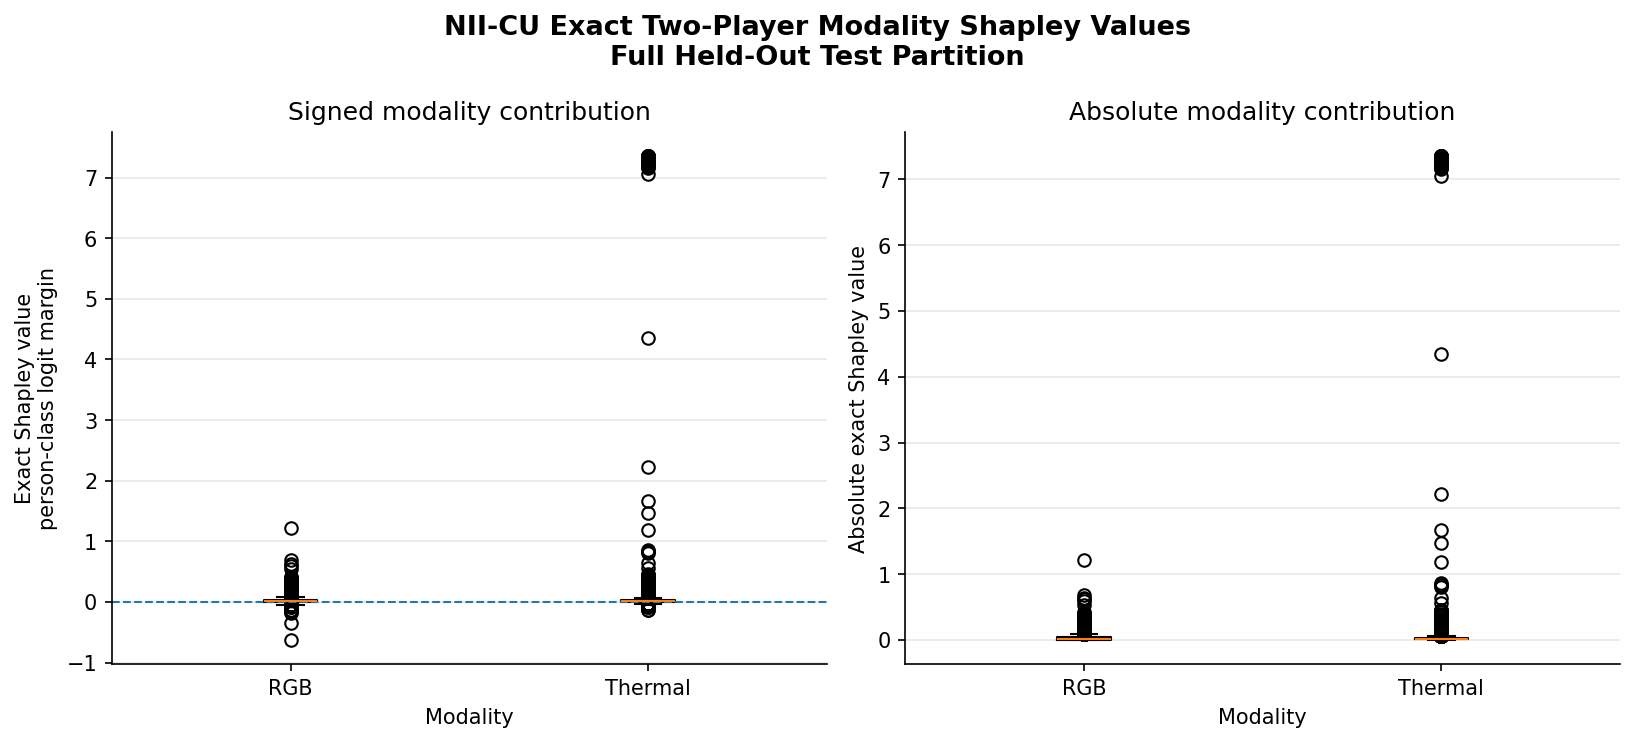

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/05_nii_exact_modality_shapley.pdf


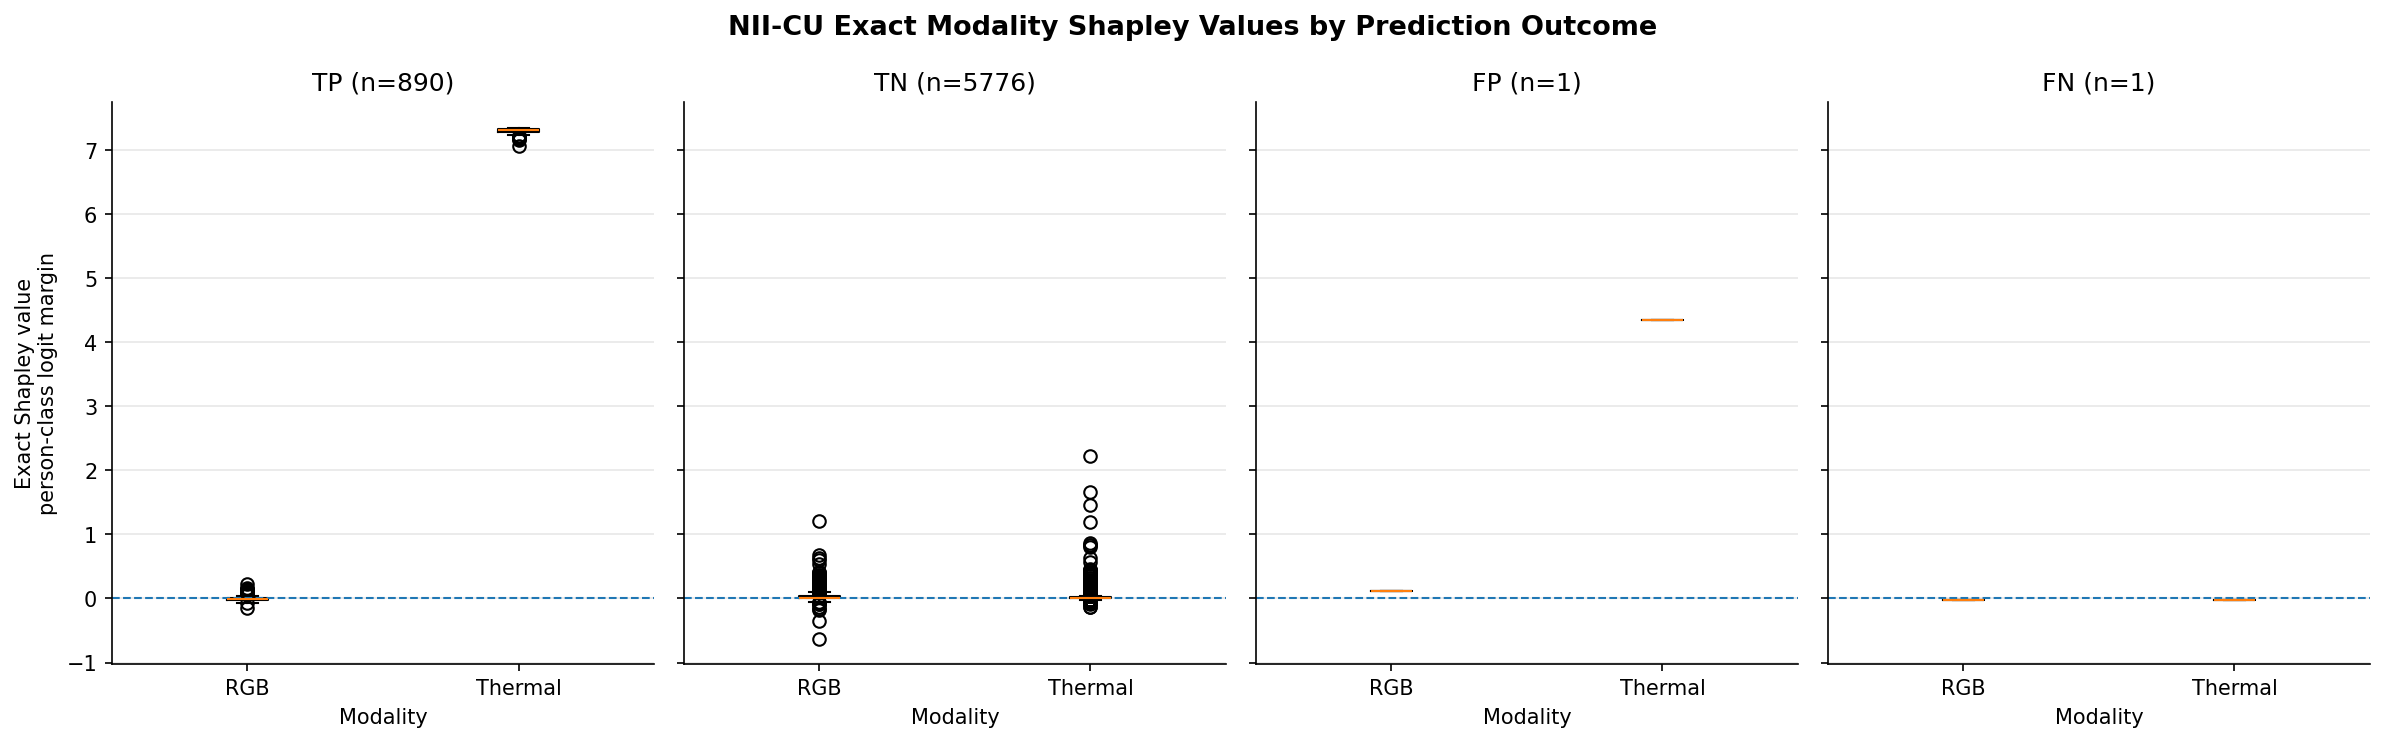

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/05_nii_exact_modality_shapley_by_outcome.pdf

Corrected NII-CU exact modality Shapley analysis complete.


In [ ]:
# Exact two-modality Shapley analysis

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 1. Required-object checks

required_shapley_objects = [
    "NII_LATE_FUSION_MODEL",
    "NII_TEST_DATASET",
    "NII_PREDICTION_TABLE",
    "NII_TRAIN_RGB_EMBED_BASELINE",
    "NII_TRAIN_TH_EMBED_BASELINE",
    "NII_CORRECTED_DIR",
    "DEVICE",
]

missing_shapley_objects = [
    object_name
    for object_name in required_shapley_objects
    if object_name not in globals()
]

if missing_shapley_objects:
    raise NameError(
        "Run NII-CU Corrected Cells 1–4 first. Missing: "
        + ", ".join(missing_shapley_objects)
    )

# 2. Configuration

NII_SHAPLEY_BATCH_SIZE = 128
NII_SHAPLEY_EFFICIENCY_TOLERANCE = 1e-5

NII_SHAPLEY_TEST_LOADER = DataLoader(
    NII_TEST_DATASET,
    batch_size=NII_SHAPLEY_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

NII_LATE_FUSION_MODEL.eval()

for parameter in NII_LATE_FUSION_MODEL.parameters():
    parameter.requires_grad_(False)

# 3. Fusion-head helpers

def nii_logits_from_batched_embeddings(
    model,
    rgb_embeddings,
    thermal_embeddings,
):
    """
    Forward batched RGB and thermal embeddings through the trained
    Late-Fusion fusion block and classifier.
    """
    fused_input = torch.cat(
        [
            rgb_embeddings,
            thermal_embeddings,
        ],
        dim=1,
    )

    fused_representation = model.fusion(
        fused_input
    )

    return model.classifier(
        fused_representation
    )


def nii_margin_and_probability_from_logits(
    logits,
):
    """
    Return person-class logit margin and P(person).
    """
    margin = (
        logits[:, 1]
        - logits[:, 0]
    )

    probability = F.softmax(
        logits,
        dim=1,
    )[:, 1]

    return (
        margin,
        probability,
    )

# 4. Exact two-player Shapley formulas

def exact_two_player_shapley(
    value_empty,
    value_rgb,
    value_thermal,
    value_both,
):
    """
    Exact Shapley values for two modalities.

    RGB:
        1/2 [(v(RGB)-v(empty)) +
             (v(RGB,Thermal)-v(Thermal))]

    Thermal:
        1/2 [(v(Thermal)-v(empty)) +
             (v(RGB,Thermal)-v(RGB))]
    """
    phi_rgb = 0.5 * (
        (
            value_rgb
            - value_empty
        )
        +
        (
            value_both
            - value_thermal
        )
    )

    phi_thermal = 0.5 * (
        (
            value_thermal
            - value_empty
        )
        +
        (
            value_both
            - value_rgb
        )
    )

    return (
        phi_rgb,
        phi_thermal,
    )

# 5. Full-test exact Shapley evaluation

def run_nii_exact_modality_shapley(
    model,
    data_loader,
    rgb_baseline_embedding,
    thermal_baseline_embedding,
):
    """
    Compute exact modality Shapley values for every held-out test crop.

    The value function is the person-class logit margin:

        v(S) = person logit - normal logit

    where modalities outside coalition S are replaced by their fixed
    training-normal mean embeddings.
    """
    rgb_baseline_embedding = torch.as_tensor(
        rgb_baseline_embedding,
        dtype=torch.float32,
        device=DEVICE,
    ).reshape(
        1,
        -1,
    )

    thermal_baseline_embedding = torch.as_tensor(
        thermal_baseline_embedding,
        dtype=torch.float32,
        device=DEVICE,
    ).reshape(
        1,
        -1,
    )

    output_rows = []
    running_sample_index = 0

    model.eval()

    with torch.no_grad():
        for batch in tqdm(
            data_loader,
            desc="Exact NII-CU modality Shapley",
        ):
            if (
                not isinstance(
                    batch,
                    (
                        tuple,
                        list,
                    ),
                )
                or len(batch) < 3
            ):
                raise ValueError(
                    "Expected each batch to contain RGB, thermal, "
                    "and labels."
                )

            rgb_batch = batch[0].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            thermal_batch = batch[1].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            labels = batch[2].detach().cpu().numpy().astype(
                np.int64
            )

            batch_size = int(
                rgb_batch.shape[0]
            )

            # Factual modality embeddings
            factual_rgb_embeddings = model.rgb_backbone(
                rgb_batch
            )

            factual_thermal_embeddings = model.th_backbone(
                thermal_batch
            )

            # Repeat fixed training-normal baselines across the batch
            baseline_rgb_embeddings = (
                rgb_baseline_embedding.expand(
                    batch_size,
                    -1,
                )
            )

            baseline_thermal_embeddings = (
                thermal_baseline_embedding.expand(
                    batch_size,
                    -1,
                )
            )

            # Four exact coalition states
            logits_empty = (
                nii_logits_from_batched_embeddings(
                    model,
                    baseline_rgb_embeddings,
                    baseline_thermal_embeddings,
                )
            )

            logits_rgb = (
                nii_logits_from_batched_embeddings(
                    model,
                    factual_rgb_embeddings,
                    baseline_thermal_embeddings,
                )
            )

            logits_thermal = (
                nii_logits_from_batched_embeddings(
                    model,
                    baseline_rgb_embeddings,
                    factual_thermal_embeddings,
                )
            )

            logits_both = (
                nii_logits_from_batched_embeddings(
                    model,
                    factual_rgb_embeddings,
                    factual_thermal_embeddings,
                )
            )

            (
                margin_empty,
                probability_empty,
            ) = nii_margin_and_probability_from_logits(
                logits_empty
            )

            (
                margin_rgb,
                probability_rgb,
            ) = nii_margin_and_probability_from_logits(
                logits_rgb
            )

            (
                margin_thermal,
                probability_thermal,
            ) = nii_margin_and_probability_from_logits(
                logits_thermal
            )

            (
                margin_both,
                probability_both,
            ) = nii_margin_and_probability_from_logits(
                logits_both
            )

            (
                shapley_rgb,
                shapley_thermal,
            ) = exact_two_player_shapley(
                value_empty=margin_empty,
                value_rgb=margin_rgb,
                value_thermal=margin_thermal,
                value_both=margin_both,
            )

            # Efficiency:
            # phi_RGB + phi_Thermal = v(both) - v(empty)
            efficiency_residual = (
                shapley_rgb
                + shapley_thermal
                - (
                    margin_both
                    - margin_empty
                )
            )

            predicted_labels = torch.argmax(
                logits_both,
                dim=1,
            )

            batch_arrays = {
                "margin_empty": (
                    margin_empty.detach().cpu().numpy()
                ),
                "margin_rgb": (
                    margin_rgb.detach().cpu().numpy()
                ),
                "margin_thermal": (
                    margin_thermal.detach().cpu().numpy()
                ),
                "margin_both": (
                    margin_both.detach().cpu().numpy()
                ),
                "probability_empty": (
                    probability_empty.detach().cpu().numpy()
                ),
                "probability_rgb": (
                    probability_rgb.detach().cpu().numpy()
                ),
                "probability_thermal": (
                    probability_thermal.detach().cpu().numpy()
                ),
                "probability_both": (
                    probability_both.detach().cpu().numpy()
                ),
                "shapley_rgb": (
                    shapley_rgb.detach().cpu().numpy()
                ),
                "shapley_thermal": (
                    shapley_thermal.detach().cpu().numpy()
                ),
                "efficiency_residual": (
                    efficiency_residual.detach().cpu().numpy()
                ),
                "predicted_labels": (
                    predicted_labels.detach().cpu().numpy()
                ),
            }

            for local_index in range(
                batch_size
            ):
                sample_index = int(
                    running_sample_index
                    + local_index
                )

                true_label = int(
                    labels[local_index]
                )

                predicted_label = int(
                    batch_arrays[
                        "predicted_labels"
                    ][local_index]
                )

                if (
                    true_label == 1
                    and predicted_label == 1
                ):
                    category = "TP"

                elif (
                    true_label == 0
                    and predicted_label == 0
                ):
                    category = "TN"

                elif (
                    true_label == 0
                    and predicted_label == 1
                ):
                    category = "FP"

                elif (
                    true_label == 1
                    and predicted_label == 0
                ):
                    category = "FN"

                else:
                    raise ValueError(
                        "Unexpected binary label state."
                    )

                rgb_value = float(
                    batch_arrays[
                        "shapley_rgb"
                    ][local_index]
                )

                thermal_value = float(
                    batch_arrays[
                        "shapley_thermal"
                    ][local_index]
                )

                output_rows.append(
                    {
                        "sample_idx": sample_index,
                        "true_label": true_label,
                        "pred_label": predicted_label,
                        "category": category,
                        "v_empty_margin": float(
                            batch_arrays[
                                "margin_empty"
                            ][local_index]
                        ),
                        "v_rgb_margin": float(
                            batch_arrays[
                                "margin_rgb"
                            ][local_index]
                        ),
                        "v_thermal_margin": float(
                            batch_arrays[
                                "margin_thermal"
                            ][local_index]
                        ),
                        "v_both_margin": float(
                            batch_arrays[
                                "margin_both"
                            ][local_index]
                        ),
                        "p_empty_person": float(
                            batch_arrays[
                                "probability_empty"
                            ][local_index]
                        ),
                        "p_rgb_person": float(
                            batch_arrays[
                                "probability_rgb"
                            ][local_index]
                        ),
                        "p_thermal_person": float(
                            batch_arrays[
                                "probability_thermal"
                            ][local_index]
                        ),
                        "p_both_person": float(
                            batch_arrays[
                                "probability_both"
                            ][local_index]
                        ),
                        "shapley_rgb_margin": rgb_value,
                        "shapley_thermal_margin": thermal_value,
                        "abs_shapley_rgb_margin": abs(
                            rgb_value
                        ),
                        "abs_shapley_thermal_margin": abs(
                            thermal_value
                        ),
                        "rgb_positive_contribution": bool(
                            rgb_value > 0.0
                        ),
                        "thermal_positive_contribution": bool(
                            thermal_value > 0.0
                        ),
                        "dominant_absolute_modality": (
                            "RGB"
                            if abs(rgb_value)
                            > abs(thermal_value)
                            else "Thermal"
                        ),
                        "efficiency_residual": float(
                            batch_arrays[
                                "efficiency_residual"
                            ][local_index]
                        ),
                    }
                )

            running_sample_index += batch_size

    return pd.DataFrame(
        output_rows
    )


NII_EXACT_MODALITY_SHAPLEY = (
    run_nii_exact_modality_shapley(
        model=NII_LATE_FUSION_MODEL,
        data_loader=NII_SHAPLEY_TEST_LOADER,
        rgb_baseline_embedding=(
            NII_TRAIN_RGB_EMBED_BASELINE
        ),
        thermal_baseline_embedding=(
            NII_TRAIN_TH_EMBED_BASELINE
        ),
    )
)

# 6. Structural and consistency audit

if len(
    NII_EXACT_MODALITY_SHAPLEY
) != len(
    NII_TEST_DATASET
):
    raise ValueError(
        "Exact Shapley test coverage mismatch: "
        f"{len(NII_EXACT_MODALITY_SHAPLEY)} rows versus "
        f"{len(NII_TEST_DATASET)} expected."
    )

if NII_EXACT_MODALITY_SHAPLEY[
    "sample_idx"
].duplicated().any():
    raise ValueError(
        "Duplicate sample indices were found."
    )

maximum_efficiency_residual = float(
    NII_EXACT_MODALITY_SHAPLEY[
        "efficiency_residual"
    ].abs().max()
)

if (
    maximum_efficiency_residual
    > NII_SHAPLEY_EFFICIENCY_TOLERANCE
):
    raise ValueError(
        "Exact Shapley efficiency audit failed. "
        f"Maximum residual={maximum_efficiency_residual:.8g}"
    )

prediction_reference = (
    NII_PREDICTION_TABLE
    .sort_values("sample_idx")
    .reset_index(drop=True)
)

shapley_reference = (
    NII_EXACT_MODALITY_SHAPLEY
    .sort_values("sample_idx")
    .reset_index(drop=True)
)

if not np.array_equal(
    prediction_reference[
        "pred_label"
    ].to_numpy(dtype=np.int64),
    shapley_reference[
        "pred_label"
    ].to_numpy(dtype=np.int64),
):
    raise ValueError(
        "Exact Shapley factual predictions disagree with Cell 1."
    )

maximum_factual_margin_difference = float(
    np.max(
        np.abs(
            prediction_reference[
                "anomaly_margin"
            ].to_numpy(dtype=np.float64)
            -
            shapley_reference[
                "v_both_margin"
            ].to_numpy(dtype=np.float64)
        )
    )
)

if maximum_factual_margin_difference > 1e-5:
    raise ValueError(
        "Exact Shapley factual margins disagree with Cell 1: "
        f"{maximum_factual_margin_difference:.8g}"
    )

print(
    "\nExact Shapley audits passed."
)

print(
    "Maximum efficiency residual:",
    f"{maximum_efficiency_residual:.3e}",
)

print(
    "Maximum factual-margin difference:",
    f"{maximum_factual_margin_difference:.3e}",
)


# 7. Save full per-sample table

shapley_output_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley.csv"
)

NII_EXACT_MODALITY_SHAPLEY.to_csv(
    shapley_output_path,
    index=False,
)

print(
    "Saved:",
    shapley_output_path,
)

# 8. Overall summary

def summarize_nii_exact_shapley(
    shapley_df,
):
    modality_records = []

    for modality, value_column, absolute_column in [
        (
            "RGB",
            "shapley_rgb_margin",
            "abs_shapley_rgb_margin",
        ),
        (
            "Thermal",
            "shapley_thermal_margin",
            "abs_shapley_thermal_margin",
        ),
    ]:
        values = shapley_df[
            value_column
        ]

        absolute_values = shapley_df[
            absolute_column
        ]

        modality_records.append(
            {
                "modality": modality,
                "n": int(
                    len(values)
                ),
                "mean_signed_shapley": float(
                    values.mean()
                ),
                "median_signed_shapley": float(
                    values.median()
                ),
                "std_signed_shapley": float(
                    values.std()
                ),
                "q25_signed_shapley": float(
                    values.quantile(0.25)
                ),
                "q75_signed_shapley": float(
                    values.quantile(0.75)
                ),
                "mean_absolute_shapley": float(
                    absolute_values.mean()
                ),
                "median_absolute_shapley": float(
                    absolute_values.median()
                ),
                "positive_fraction": float(
                    (
                        values > 0.0
                    ).mean()
                ),
                "negative_fraction": float(
                    (
                        values < 0.0
                    ).mean()
                ),
                "near_zero_fraction": float(
                    (
                        values.abs()
                        <= 1e-6
                    ).mean()
                ),
            }
        )

    return pd.DataFrame(
        modality_records
    )


NII_EXACT_SHAPLEY_SUMMARY = (
    summarize_nii_exact_shapley(
        NII_EXACT_MODALITY_SHAPLEY
    )
)

summary_output_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley_summary.csv"
)

NII_EXACT_SHAPLEY_SUMMARY.to_csv(
    summary_output_path,
    index=False,
)

print(
    "\nOverall exact modality Shapley summary"
)

display(
    NII_EXACT_SHAPLEY_SUMMARY
)

print(
    "Saved:",
    summary_output_path,
)


# 9. Outcome-specific summary

def summarize_nii_shapley_by_outcome(
    shapley_df,
):
    rows = []

    for category in [
        "TP",
        "TN",
        "FP",
        "FN",
    ]:
        category_df = shapley_df[
            shapley_df[
                "category"
            ] == category
        ]

        if category_df.empty:
            continue

        for modality, value_column, absolute_column in [
            (
                "RGB",
                "shapley_rgb_margin",
                "abs_shapley_rgb_margin",
            ),
            (
                "Thermal",
                "shapley_thermal_margin",
                "abs_shapley_thermal_margin",
            ),
        ]:
            values = category_df[
                value_column
            ]

            absolute_values = category_df[
                absolute_column
            ]

            rows.append(
                {
                    "category": category,
                    "modality": modality,
                    "n": int(
                        len(values)
                    ),
                    "mean_signed_shapley": float(
                        values.mean()
                    ),
                    "median_signed_shapley": float(
                        values.median()
                    ),
                    "mean_absolute_shapley": float(
                        absolute_values.mean()
                    ),
                    "median_absolute_shapley": float(
                        absolute_values.median()
                    ),
                    "positive_fraction": float(
                        (
                            values > 0.0
                        ).mean()
                    ),
                    "negative_fraction": float(
                        (
                            values < 0.0
                        ).mean()
                    ),
                }
            )

    return pd.DataFrame(
        rows
    )


NII_EXACT_SHAPLEY_BY_OUTCOME = (
    summarize_nii_shapley_by_outcome(
        NII_EXACT_MODALITY_SHAPLEY
    )
)

outcome_summary_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley_by_outcome.csv"
)

NII_EXACT_SHAPLEY_BY_OUTCOME.to_csv(
    outcome_summary_path,
    index=False,
)

print(
    "\nExact modality Shapley by prediction outcome"
)

display(
    NII_EXACT_SHAPLEY_BY_OUTCOME
)

print(
    "Saved:",
    outcome_summary_path,
)

# 10. Coalition-state summary

coalition_summary = pd.DataFrame(
    [
        {
            "coalition": "Empty",
            "mean_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_empty_margin"
                ].mean()
            ),
            "median_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_empty_margin"
                ].median()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_EXACT_MODALITY_SHAPLEY[
                        "v_empty_margin"
                    ] > 0.0
                ).mean()
            ),
        },
        {
            "coalition": "RGB only",
            "mean_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_rgb_margin"
                ].mean()
            ),
            "median_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_rgb_margin"
                ].median()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_EXACT_MODALITY_SHAPLEY[
                        "v_rgb_margin"
                    ] > 0.0
                ).mean()
            ),
        },
        {
            "coalition": "Thermal only",
            "mean_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_thermal_margin"
                ].mean()
            ),
            "median_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_thermal_margin"
                ].median()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_EXACT_MODALITY_SHAPLEY[
                        "v_thermal_margin"
                    ] > 0.0
                ).mean()
            ),
        },
        {
            "coalition": "RGB + Thermal",
            "mean_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_both_margin"
                ].mean()
            ),
            "median_margin": float(
                NII_EXACT_MODALITY_SHAPLEY[
                    "v_both_margin"
                ].median()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_EXACT_MODALITY_SHAPLEY[
                        "v_both_margin"
                    ] > 0.0
                ).mean()
            ),
        },
    ]
)

coalition_summary_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_shapley_coalition_summary.csv"
)

coalition_summary.to_csv(
    coalition_summary_path,
    index=False,
)

print(
    "\nCoalition-state summary"
)

display(
    coalition_summary
)

# 11. Main Shapley distribution figure

def plot_nii_exact_shapley_distributions(
    shapley_df,
    save_name=(
        "05_nii_exact_modality_shapley.pdf"
    ),
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 5),
    )

    signed_values = [
        shapley_df[
            "shapley_rgb_margin"
        ].to_numpy(),
        shapley_df[
            "shapley_thermal_margin"
        ].to_numpy(),
    ]

    absolute_values = [
        shapley_df[
            "abs_shapley_rgb_margin"
        ].to_numpy(),
        shapley_df[
            "abs_shapley_thermal_margin"
        ].to_numpy(),
    ]

    axes[0].boxplot(
        signed_values,
        labels=[
            "RGB",
            "Thermal",
        ],
        showfliers=True,
    )

    axes[0].axhline(
        0.0,
        linestyle="--",
        linewidth=1,
    )

    axes[0].set_title(
        "Signed modality contribution"
    )

    axes[0].set_xlabel(
        "Modality"
    )

    axes[0].set_ylabel(
        "Exact Shapley value\n"
        "person-class logit margin"
    )

    axes[0].grid(
        axis="y",
        alpha=0.3,
    )

    axes[1].boxplot(
        absolute_values,
        labels=[
            "RGB",
            "Thermal",
        ],
        showfliers=True,
    )

    axes[1].set_title(
        "Absolute modality contribution"
    )

    axes[1].set_xlabel(
        "Modality"
    )

    axes[1].set_ylabel(
        "Absolute exact Shapley value"
    )

    axes[1].grid(
        axis="y",
        alpha=0.3,
    )

    plt.suptitle(
        "NII-CU Exact Two-Player Modality Shapley Values\n"
        "Full Held-Out Test Partition",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_exact_shapley_distributions(
    NII_EXACT_MODALITY_SHAPLEY
)


# 12. Outcome-specific Shapley figure

def plot_nii_exact_shapley_by_outcome(
    shapley_df,
    save_name=(
        "05_nii_exact_modality_shapley_by_outcome.pdf"
    ),
):
    available_categories = [
        category
        for category in [
            "TP",
            "TN",
            "FP",
            "FN",
        ]
        if category in set(
            shapley_df[
                "category"
            ]
        )
    ]

    fig, axes = plt.subplots(
        1,
        len(available_categories),
        figsize=(
            4 * len(available_categories),
            5,
        ),
        sharey=True,
    )

    if len(available_categories) == 1:
        axes = [axes]

    for axis, category in zip(
        axes,
        available_categories,
    ):
        category_df = shapley_df[
            shapley_df[
                "category"
            ] == category
        ]

        axis.boxplot(
            [
                category_df[
                    "shapley_rgb_margin"
                ].to_numpy(),
                category_df[
                    "shapley_thermal_margin"
                ].to_numpy(),
            ],
            labels=[
                "RGB",
                "Thermal",
            ],
            showfliers=True,
        )

        axis.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
        )

        axis.set_title(
            f"{category} (n={len(category_df)})"
        )

        axis.set_xlabel(
            "Modality"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

    axes[0].set_ylabel(
        "Exact Shapley value\n"
        "person-class logit margin"
    )

    plt.suptitle(
        "NII-CU Exact Modality Shapley Values "
        "by Prediction Outcome",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_exact_shapley_by_outcome(
    NII_EXACT_MODALITY_SHAPLEY
)


# 13. Save metadata

nii_exact_shapley_metadata = {
    "domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "model": "Late-Fusion",
    "test_sample_count": int(
        len(NII_EXACT_MODALITY_SHAPLEY)
    ),
    "players": [
        "RGB",
        "Thermal",
    ],
    "value_function": (
        "Person logit minus normal logit"
    ),
    "coalitions_evaluated_exactly": [
        "Empty",
        "RGB only",
        "Thermal only",
        "RGB and Thermal",
    ],
    "missing_modality_reference": (
        "Fixed mean embedding from 200 normal training crops"
    ),
    "approximation": False,
    "efficiency_identity": (
        "phi_RGB + phi_Thermal = "
        "v(RGB,Thermal) - v(empty)"
    ),
    "maximum_efficiency_residual": (
        maximum_efficiency_residual
    ),
    "interpretation": (
        "Signed Shapley values quantify each modality's average "
        "contribution to the person-class logit margin under the "
        "specified training-normal embedding reference."
    ),
}

with open(
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley_metadata.json",
    "w",
) as file:
    json.dump(
        nii_exact_shapley_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU exact modality Shapley analysis complete."
)

RGB pixel-medoid shape: (3, 224, 224)
Thermal pixel-medoid shape: (1, 224, 224)


NII-CU modality replacement:   0%|          | 0/53 [00:00<?, ?it/s]


Replacement audits passed.
Maximum factual-probability difference: 1.378e-07
Maximum factual-margin difference: 3.114e-06
Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/06_nii_modality_replacement_paired.csv

Overall modality-replacement summary


,modality_replaced,n,mean_probability_drop,median_probability_drop,q25_probability_drop,q75_probability_drop,mean_absolute_probability_change,median_absolute_probability_change,positive_drop_fraction,negative_drop_fraction,near_zero_drop_fraction,mean_margin_drop,median_margin_drop,mean_absolute_margin_change,median_absolute_margin_change,prediction_flip_n,prediction_flip_fraction
0,RGB,6668,0.000755,0.000290,-0.000028,0.000905,0.001075,0.000437,0.723305,0.276695,0.00075,0.027171,0.011856,0.039027,0.017886,1,0.000150
1,Thermal,6668,0.127040,0.000105,-0.000138,0.000603,0.127255,0.000283,0.601680,0.398320,0.00195,0.981519,0.004252,0.990243,0.011551,891,0.133623


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/06_nii_modality_replacement_summary.csv

Modality replacement by prediction outcome


,category,modality_replaced,n,mean_probability_drop,median_probability_drop,q25_probability_drop,q75_probability_drop,mean_absolute_probability_change,median_absolute_probability_change,positive_drop_fraction,negative_drop_fraction,mean_margin_drop,median_margin_drop,prediction_flip_n,prediction_flip_fraction
0,TP,RGB,890,-0.000618,-0.000321,-0.001493,0.000307,0.000944,0.000480,0.414607,0.585393,-0.023393,-0.012755,0,0.0
1,TP,Thermal,890,0.948561,0.949052,0.947713,0.949662,0.948561,0.949052,1.000000,0.000000,7.270993,7.289025,890,1.0
2,TN,RGB,5776,0.000927,0.000352,0.000017,0.001073,0.001056,0.000425,0.770949,0.229051,0.034809,0.014560,0,0.0
3,TN,Thermal,5776,0.000385,0.000034,-0.000172,0.000311,0.000633,0.000233,0.540339,0.459661,0.011979,0.001405,0,0.0
4,FP,RGB,1,0.229083,0.229083,0.229083,0.229083,0.229083,0.229083,1.000000,0.000000,0.954344,0.954344,1,1.0
5,FP,Thermal,1,0.660633,0.660633,0.660633,0.660633,0.660633,0.660633,1.000000,0.000000,4.424396,4.424396,1,1.0
6,FN,RGB,1,-0.000294,-0.000294,-0.000294,-0.000294,0.000294,0.000294,0.000000,1.000000,-0.012699,-0.012699,0,0.0
7,FN,Thermal,1,-0.000743,-0.000743,-0.000743,-0.000743,0.000743,0.000743,0.000000,1.000000,-0.031806,-0.031806,0,0.0


Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/06_nii_modality_replacement_by_outcome.csv

Replacement-state prediction summary


,state,positive_prediction_n,positive_prediction_fraction,mean_p_person,mean_margin
0,Factual,891,0.133623,0.152322,-2.671389
1,RGB replaced,890,0.133473,0.151567,-2.698560
2,Thermal replaced,0,0.000000,0.025282,-3.652908


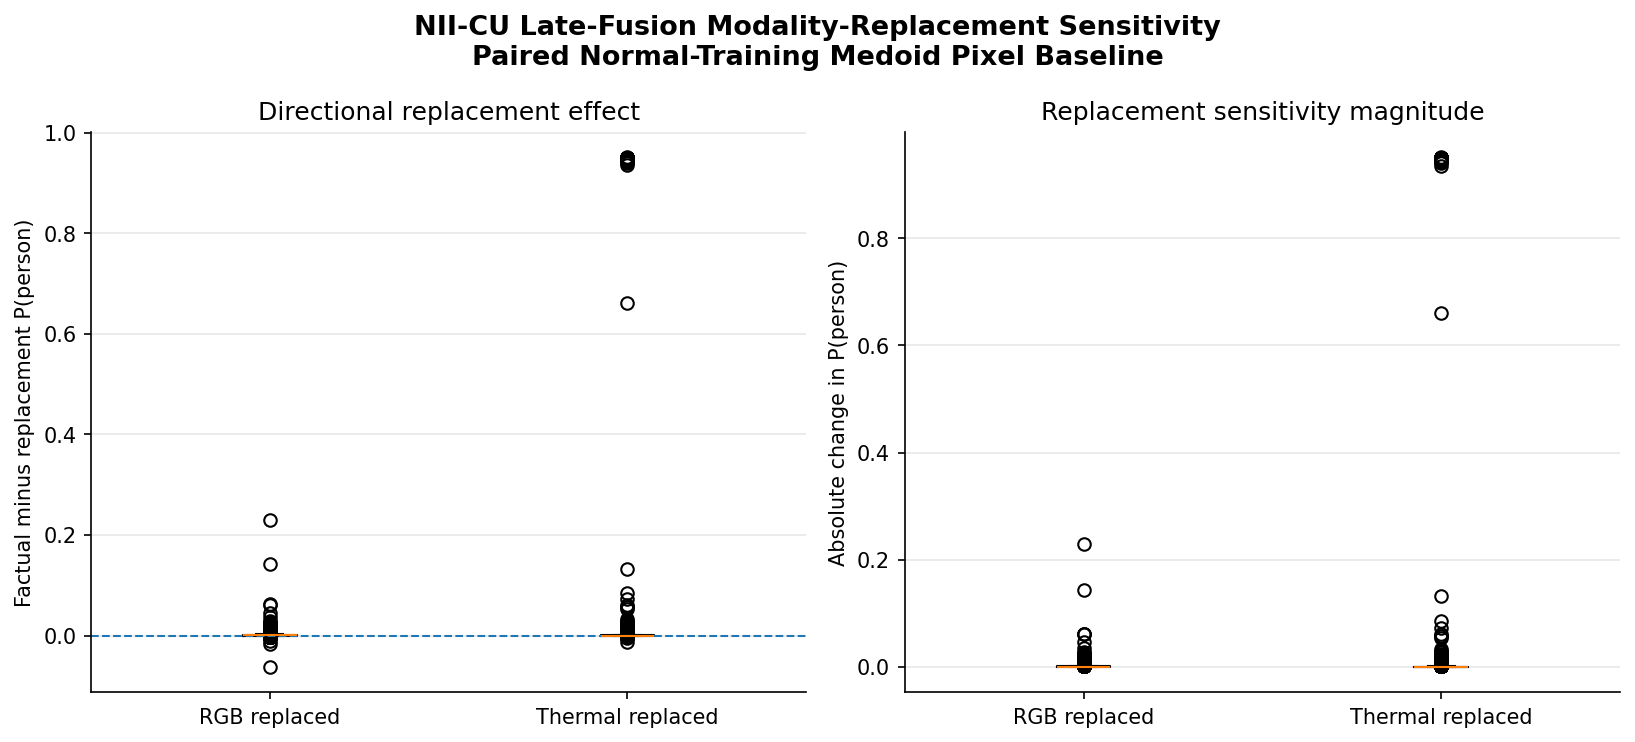

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/06_nii_modality_replacement_sensitivity.pdf


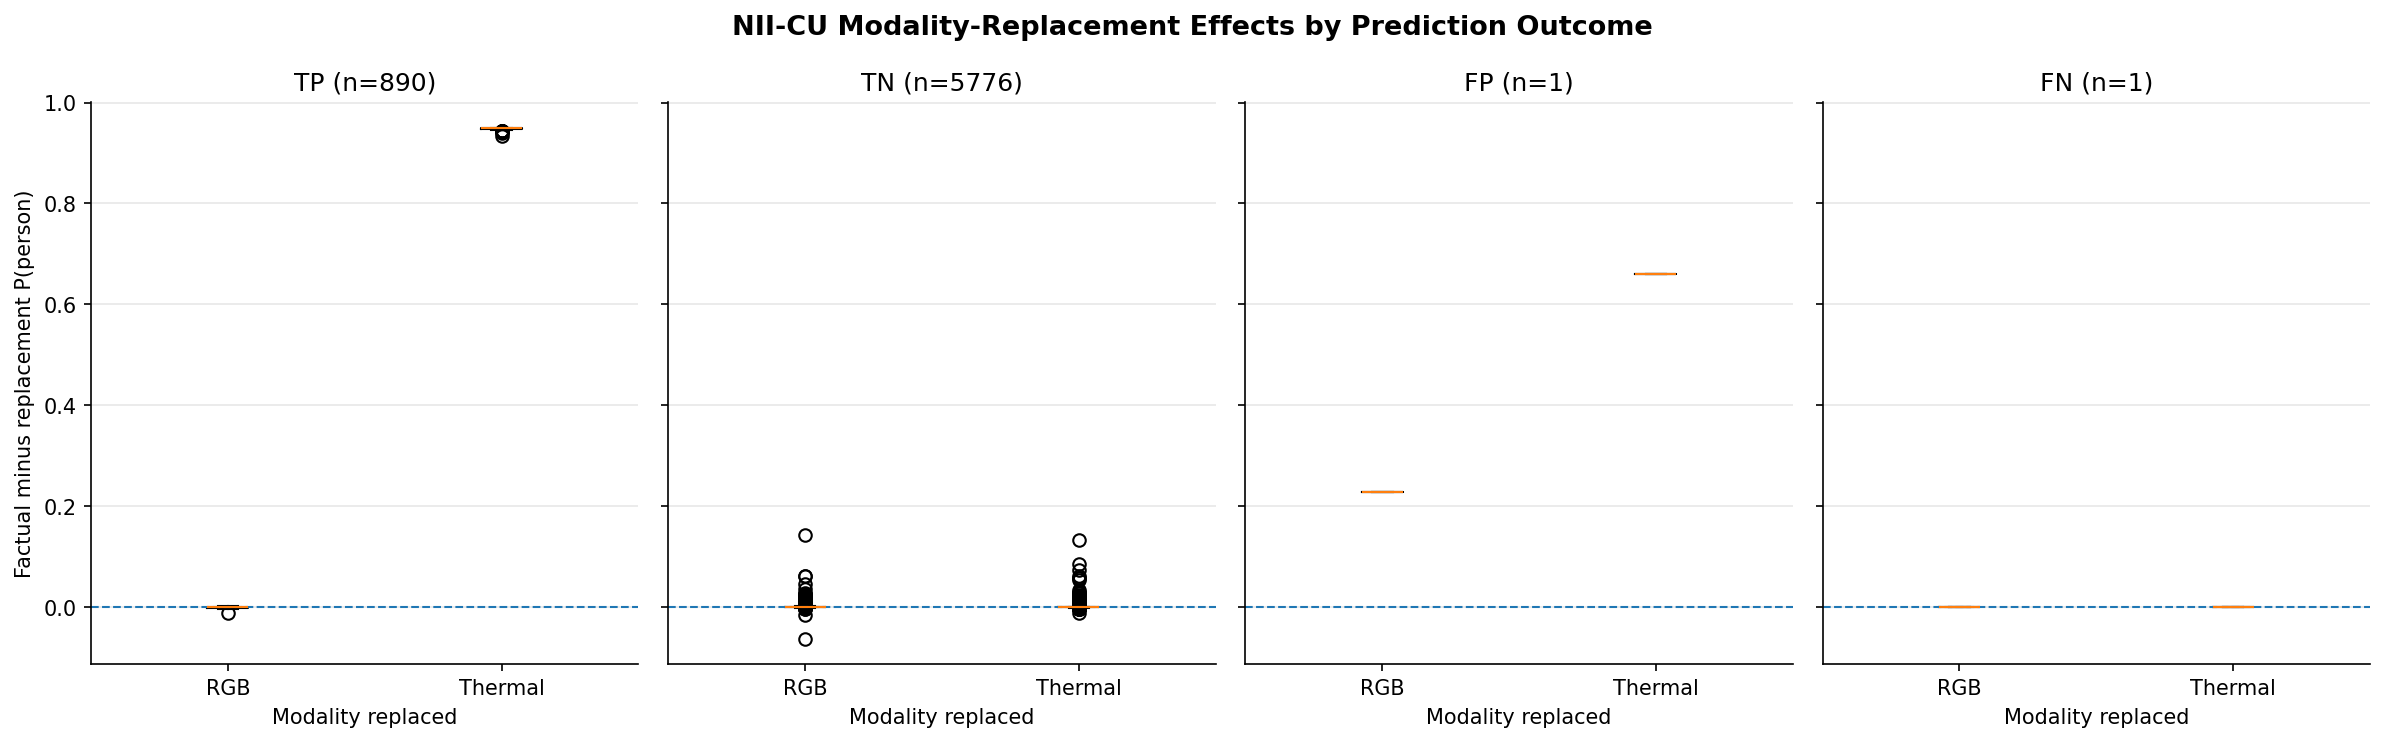

Saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/06_nii_modality_replacement_by_outcome.pdf

Corrected NII-CU modality-replacement analysis complete.


In [ ]:
# Full-test pixel-level modality replacement

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# 1. Required-object checks

required_replacement_objects = [
    "NII_LATE_FUSION_MODEL",
    "NII_TEST_DATASET",
    "NII_PREDICTION_TABLE",
    "NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE",
    "NII_TRAIN_TH_PIXEL_MEDOID_BASELINE",
    "NII_PIXEL_MEDOID_TRAIN_IDX",
    "NII_CORRECTED_DIR",
    "DEVICE",
]

missing_replacement_objects = [
    object_name
    for object_name in required_replacement_objects
    if object_name not in globals()
]

if missing_replacement_objects:
    raise NameError(
        "Run NII-CU Corrected Cells 1, 1B, 2, 3, 4, and 5 first. "
        "Missing: "
        + ", ".join(
            missing_replacement_objects
        )
    )

# 2. Configuration

NII_REPLACEMENT_BATCH_SIZE = 128
NII_REPLACEMENT_DECISION_THRESHOLD = 0.5

NII_REPLACEMENT_TEST_LOADER = DataLoader(
    NII_TEST_DATASET,
    batch_size=NII_REPLACEMENT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

NII_LATE_FUSION_MODEL.eval()

for parameter in NII_LATE_FUSION_MODEL.parameters():
    parameter.requires_grad_(False)


# 3. Prepare paired normal-training medoid baselines

rgb_pixel_medoid = (
    NII_TRAIN_RGB_PIXEL_MEDOID_BASELINE
    .detach()
    .clone()
    .to(
        dtype=torch.float32,
        device=DEVICE,
    )
)

thermal_pixel_medoid = (
    NII_TRAIN_TH_PIXEL_MEDOID_BASELINE
    .detach()
    .clone()
    .to(
        dtype=torch.float32,
        device=DEVICE,
    )
)

if rgb_pixel_medoid.ndim != 3:
    raise ValueError(
        "Expected the RGB medoid baseline to have shape [C,H,W]."
    )

if thermal_pixel_medoid.ndim != 3:
    raise ValueError(
        "Expected the thermal medoid baseline to have shape [C,H,W]."
    )

print(
    "RGB pixel-medoid shape:",
    tuple(
        rgb_pixel_medoid.shape
    ),
)

print(
    "Thermal pixel-medoid shape:",
    tuple(
        thermal_pixel_medoid.shape
    ),
)


# 4. Prediction helper

def nii_probability_and_margin_from_inputs(
    model,
    rgb_batch,
    thermal_batch,
):
    """
    Return P(person), person-minus-normal logit margin, and predicted class.
    """
    logits = model(
        rgb_batch,
        thermal_batch,
    )

    probabilities = F.softmax(
        logits,
        dim=1,
    )

    person_probability = probabilities[
        :,
        1
    ]

    person_margin = (
        logits[
            :,
            1
        ]
        -
        logits[
            :,
            0
        ]
    )

    predicted_label = torch.argmax(
        logits,
        dim=1,
    )

    return (
        person_probability,
        person_margin,
        predicted_label,
    )

# 5. Full-test replacement evaluation

def run_nii_modality_replacement(
    model,
    data_loader,
    rgb_baseline,
    thermal_baseline,
):
    """
    Evaluate factual, RGB-replaced, and thermal-replaced predictions.

    Replacement states
    ------------------
    RGB replaced:
        (normal-training RGB medoid, factual thermal)

    Thermal replaced:
        (factual RGB, normal-training thermal medoid)
    """
    rows = []
    running_sample_idx = 0

    model.eval()

    with torch.no_grad():
        for batch in tqdm(
            data_loader,
            desc="NII-CU modality replacement",
        ):
            if (
                not isinstance(
                    batch,
                    (
                        tuple,
                        list,
                    ),
                )
                or len(
                    batch
                ) < 3
            ):
                raise ValueError(
                    "Expected each batch to contain RGB, thermal, "
                    "and labels."
                )

            rgb_batch = batch[
                0
            ].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            thermal_batch = batch[
                1
            ].to(
                DEVICE,
                dtype=torch.float32,
                non_blocking=True,
            )

            labels = batch[
                2
            ].detach().cpu().numpy().astype(
                np.int64
            )

            batch_size = int(
                rgb_batch.shape[
                    0
                ]
            )

            rgb_replacement_batch = (
                rgb_baseline
                .unsqueeze(
                    0
                )
                .expand(
                    batch_size,
                    -1,
                    -1,
                    -1,
                )
            )

            thermal_replacement_batch = (
                thermal_baseline
                .unsqueeze(
                    0
                )
                .expand(
                    batch_size,
                    -1,
                    -1,
                    -1,
                )
            )

            # Factual state
            (
                factual_probability,
                factual_margin,
                factual_prediction,
            ) = nii_probability_and_margin_from_inputs(
                model,
                rgb_batch,
                thermal_batch,
            )

            # Replace RGB only
            (
                rgb_replaced_probability,
                rgb_replaced_margin,
                rgb_replaced_prediction,
            ) = nii_probability_and_margin_from_inputs(
                model,
                rgb_replacement_batch,
                thermal_batch,
            )

            # Replace thermal only
            (
                thermal_replaced_probability,
                thermal_replaced_margin,
                thermal_replaced_prediction,
            ) = nii_probability_and_margin_from_inputs(
                model,
                rgb_batch,
                thermal_replacement_batch,
            )

            batch_arrays = {
                "factual_probability": (
                    factual_probability
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "factual_margin": (
                    factual_margin
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "factual_prediction": (
                    factual_prediction
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "rgb_replaced_probability": (
                    rgb_replaced_probability
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "rgb_replaced_margin": (
                    rgb_replaced_margin
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "rgb_replaced_prediction": (
                    rgb_replaced_prediction
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "thermal_replaced_probability": (
                    thermal_replaced_probability
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "thermal_replaced_margin": (
                    thermal_replaced_margin
                    .detach()
                    .cpu()
                    .numpy()
                ),
                "thermal_replaced_prediction": (
                    thermal_replaced_prediction
                    .detach()
                    .cpu()
                    .numpy()
                ),
            }

            for local_idx in range(
                batch_size
            ):
                sample_idx = int(
                    running_sample_idx
                    + local_idx
                )

                true_label = int(
                    labels[
                        local_idx
                    ]
                )

                pred_label = int(
                    batch_arrays[
                        "factual_prediction"
                    ][
                        local_idx
                    ]
                )

                if (
                    true_label == 1
                    and pred_label == 1
                ):
                    category = "TP"

                elif (
                    true_label == 0
                    and pred_label == 0
                ):
                    category = "TN"

                elif (
                    true_label == 0
                    and pred_label == 1
                ):
                    category = "FP"

                elif (
                    true_label == 1
                    and pred_label == 0
                ):
                    category = "FN"

                else:
                    raise ValueError(
                        "Unexpected prediction category."
                    )

                factual_p = float(
                    batch_arrays[
                        "factual_probability"
                    ][
                        local_idx
                    ]
                )

                rgb_replaced_p = float(
                    batch_arrays[
                        "rgb_replaced_probability"
                    ][
                        local_idx
                    ]
                )

                thermal_replaced_p = float(
                    batch_arrays[
                        "thermal_replaced_probability"
                    ][
                        local_idx
                    ]
                )

                factual_margin_value = float(
                    batch_arrays[
                        "factual_margin"
                    ][
                        local_idx
                    ]
                )

                rgb_replaced_margin_value = float(
                    batch_arrays[
                        "rgb_replaced_margin"
                    ][
                        local_idx
                    ]
                )

                thermal_replaced_margin_value = float(
                    batch_arrays[
                        "thermal_replaced_margin"
                    ][
                        local_idx
                    ]
                )

                rgb_probability_drop = (
                    factual_p
                    - rgb_replaced_p
                )

                thermal_probability_drop = (
                    factual_p
                    - thermal_replaced_p
                )

                rgb_margin_drop = (
                    factual_margin_value
                    - rgb_replaced_margin_value
                )

                thermal_margin_drop = (
                    factual_margin_value
                    - thermal_replaced_margin_value
                )

                rgb_replaced_pred = int(
                    batch_arrays[
                        "rgb_replaced_prediction"
                    ][
                        local_idx
                    ]
                )

                thermal_replaced_pred = int(
                    batch_arrays[
                        "thermal_replaced_prediction"
                    ][
                        local_idx
                    ]
                )

                rows.append(
                    {
                        "sample_idx": sample_idx,
                        "true_label": true_label,
                        "pred_label": pred_label,
                        "category": category,

                        "factual_p_person": factual_p,
                        "factual_margin": (
                            factual_margin_value
                        ),

                        "rgb_replaced_p_person": (
                            rgb_replaced_p
                        ),
                        "rgb_replaced_margin": (
                            rgb_replaced_margin_value
                        ),
                        "rgb_replaced_pred_label": (
                            rgb_replaced_pred
                        ),

                        "thermal_replaced_p_person": (
                            thermal_replaced_p
                        ),
                        "thermal_replaced_margin": (
                            thermal_replaced_margin_value
                        ),
                        "thermal_replaced_pred_label": (
                            thermal_replaced_pred
                        ),

                        "rgb_replacement_probability_drop": (
                            rgb_probability_drop
                        ),
                        "thermal_replacement_probability_drop": (
                            thermal_probability_drop
                        ),

                        "abs_rgb_replacement_probability_change": (
                            abs(
                                rgb_probability_drop
                            )
                        ),
                        "abs_thermal_replacement_probability_change": (
                            abs(
                                thermal_probability_drop
                            )
                        ),

                        "rgb_replacement_margin_drop": (
                            rgb_margin_drop
                        ),
                        "thermal_replacement_margin_drop": (
                            thermal_margin_drop
                        ),

                        "abs_rgb_replacement_margin_change": (
                            abs(
                                rgb_margin_drop
                            )
                        ),
                        "abs_thermal_replacement_margin_change": (
                            abs(
                                thermal_margin_drop
                            )
                        ),

                        "rgb_replacement_flip": bool(
                            rgb_replaced_pred
                            != pred_label
                        ),
                        "thermal_replacement_flip": bool(
                            thermal_replaced_pred
                            != pred_label
                        ),

                        "rgb_replacement_supports_person": bool(
                            rgb_probability_drop
                            > 0.0
                        ),
                        "rgb_replacement_suppresses_person": bool(
                            rgb_probability_drop
                            < 0.0
                        ),

                        "thermal_replacement_supports_person": bool(
                            thermal_probability_drop
                            > 0.0
                        ),
                        "thermal_replacement_suppresses_person": bool(
                            thermal_probability_drop
                            < 0.0
                        ),
                    }
                )

            running_sample_idx += batch_size

    return pd.DataFrame(
        rows
    )


NII_MODALITY_REPLACEMENT = (
    run_nii_modality_replacement(
        model=NII_LATE_FUSION_MODEL,
        data_loader=NII_REPLACEMENT_TEST_LOADER,
        rgb_baseline=rgb_pixel_medoid,
        thermal_baseline=thermal_pixel_medoid,
    )
)


# 6. Structural and prediction consistency audit

if len(
    NII_MODALITY_REPLACEMENT
) != len(
    NII_TEST_DATASET
):
    raise ValueError(
        "Replacement test coverage mismatch: "
        f"{len(NII_MODALITY_REPLACEMENT)} rows versus "
        f"{len(NII_TEST_DATASET)} expected."
    )

if NII_MODALITY_REPLACEMENT[
    "sample_idx"
].duplicated().any():
    raise ValueError(
        "Duplicate sample indices were found."
    )

replacement_sorted = (
    NII_MODALITY_REPLACEMENT
    .sort_values(
        "sample_idx"
    )
    .reset_index(
        drop=True
    )
)

prediction_sorted = (
    NII_PREDICTION_TABLE
    .sort_values(
        "sample_idx"
    )
    .reset_index(
        drop=True
    )
)

if not np.array_equal(
    replacement_sorted[
        "pred_label"
    ].to_numpy(
        dtype=np.int64
    ),
    prediction_sorted[
        "pred_label"
    ].to_numpy(
        dtype=np.int64
    ),
):
    raise ValueError(
        "Replacement factual predictions disagree with Cell 1."
    )

maximum_probability_difference = float(
    np.max(
        np.abs(
            replacement_sorted[
                "factual_p_person"
            ].to_numpy(
                dtype=np.float64
            )
            -
            prediction_sorted[
                "p_anomaly"
            ].to_numpy(
                dtype=np.float64
            )
        )
    )
)

if maximum_probability_difference > 1e-6:
    raise ValueError(
        "Replacement factual probabilities disagree with Cell 1: "
        f"{maximum_probability_difference:.8g}"
    )

maximum_margin_difference = float(
    np.max(
        np.abs(
            replacement_sorted[
                "factual_margin"
            ].to_numpy(
                dtype=np.float64
            )
            -
            prediction_sorted[
                "anomaly_margin"
            ].to_numpy(
                dtype=np.float64
            )
        )
    )
)

if maximum_margin_difference > 1e-5:
    raise ValueError(
        "Replacement factual margins disagree with Cell 1: "
        f"{maximum_margin_difference:.8g}"
    )

print(
    "\nReplacement audits passed."
)

print(
    "Maximum factual-probability difference:",
    f"{maximum_probability_difference:.3e}",
)

print(
    "Maximum factual-margin difference:",
    f"{maximum_margin_difference:.3e}",
)

# 7. Save complete paired replacement table

replacement_output_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_paired.csv"
)

NII_MODALITY_REPLACEMENT.to_csv(
    replacement_output_path,
    index=False,
)

print(
    "Saved:",
    replacement_output_path,
)


# 8. Overall replacement summary

def summarize_nii_modality_replacement(
    replacement_df,
):
    rows = []

    for (
        modality,
        probability_column,
        absolute_probability_column,
        margin_column,
        absolute_margin_column,
        flip_column,
    ) in [
        (
            "RGB",
            "rgb_replacement_probability_drop",
            "abs_rgb_replacement_probability_change",
            "rgb_replacement_margin_drop",
            "abs_rgb_replacement_margin_change",
            "rgb_replacement_flip",
        ),
        (
            "Thermal",
            "thermal_replacement_probability_drop",
            "abs_thermal_replacement_probability_change",
            "thermal_replacement_margin_drop",
            "abs_thermal_replacement_margin_change",
            "thermal_replacement_flip",
        ),
    ]:
        directional_values = replacement_df[
            probability_column
        ]

        absolute_values = replacement_df[
            absolute_probability_column
        ]

        margin_values = replacement_df[
            margin_column
        ]

        absolute_margin_values = replacement_df[
            absolute_margin_column
        ]

        rows.append(
            {
                "modality_replaced": modality,
                "n": int(
                    len(
                        replacement_df
                    )
                ),

                "mean_probability_drop": float(
                    directional_values.mean()
                ),
                "median_probability_drop": float(
                    directional_values.median()
                ),
                "q25_probability_drop": float(
                    directional_values.quantile(
                        0.25
                    )
                ),
                "q75_probability_drop": float(
                    directional_values.quantile(
                        0.75
                    )
                ),

                "mean_absolute_probability_change": float(
                    absolute_values.mean()
                ),
                "median_absolute_probability_change": float(
                    absolute_values.median()
                ),

                "positive_drop_fraction": float(
                    (
                        directional_values
                        > 0.0
                    ).mean()
                ),
                "negative_drop_fraction": float(
                    (
                        directional_values
                        < 0.0
                    ).mean()
                ),
                "near_zero_drop_fraction": float(
                    (
                        directional_values.abs()
                        <= 1e-6
                    ).mean()
                ),

                "mean_margin_drop": float(
                    margin_values.mean()
                ),
                "median_margin_drop": float(
                    margin_values.median()
                ),

                "mean_absolute_margin_change": float(
                    absolute_margin_values.mean()
                ),
                "median_absolute_margin_change": float(
                    absolute_margin_values.median()
                ),

                "prediction_flip_n": int(
                    replacement_df[
                        flip_column
                    ].sum()
                ),
                "prediction_flip_fraction": float(
                    replacement_df[
                        flip_column
                    ].mean()
                ),
            }
        )

    return pd.DataFrame(
        rows
    )


NII_MODALITY_REPLACEMENT_SUMMARY = (
    summarize_nii_modality_replacement(
        NII_MODALITY_REPLACEMENT
    )
)

replacement_summary_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_summary.csv"
)

NII_MODALITY_REPLACEMENT_SUMMARY.to_csv(
    replacement_summary_path,
    index=False,
)

print(
    "\nOverall modality-replacement summary"
)

display(
    NII_MODALITY_REPLACEMENT_SUMMARY
)

print(
    "Saved:",
    replacement_summary_path,
)

# 9. Outcome-specific replacement summary

def summarize_nii_replacement_by_outcome(
    replacement_df,
):
    rows = []

    for category in [
        "TP",
        "TN",
        "FP",
        "FN",
    ]:
        category_df = replacement_df[
            replacement_df[
                "category"
            ]
            == category
        ]

        if category_df.empty:
            continue

        for (
            modality,
            probability_column,
            absolute_probability_column,
            margin_column,
            flip_column,
        ) in [
            (
                "RGB",
                "rgb_replacement_probability_drop",
                "abs_rgb_replacement_probability_change",
                "rgb_replacement_margin_drop",
                "rgb_replacement_flip",
            ),
            (
                "Thermal",
                "thermal_replacement_probability_drop",
                "abs_thermal_replacement_probability_change",
                "thermal_replacement_margin_drop",
                "thermal_replacement_flip",
            ),
        ]:
            directional_values = category_df[
                probability_column
            ]

            absolute_values = category_df[
                absolute_probability_column
            ]

            margin_values = category_df[
                margin_column
            ]

            rows.append(
                {
                    "category": category,
                    "modality_replaced": modality,
                    "n": int(
                        len(
                            category_df
                        )
                    ),

                    "mean_probability_drop": float(
                        directional_values.mean()
                    ),
                    "median_probability_drop": float(
                        directional_values.median()
                    ),
                    "q25_probability_drop": float(
                        directional_values.quantile(
                            0.25
                        )
                    ),
                    "q75_probability_drop": float(
                        directional_values.quantile(
                            0.75
                        )
                    ),

                    "mean_absolute_probability_change": float(
                        absolute_values.mean()
                    ),
                    "median_absolute_probability_change": float(
                        absolute_values.median()
                    ),

                    "positive_drop_fraction": float(
                        (
                            directional_values
                            > 0.0
                        ).mean()
                    ),
                    "negative_drop_fraction": float(
                        (
                            directional_values
                            < 0.0
                        ).mean()
                    ),

                    "mean_margin_drop": float(
                        margin_values.mean()
                    ),
                    "median_margin_drop": float(
                        margin_values.median()
                    ),

                    "prediction_flip_n": int(
                        category_df[
                            flip_column
                        ].sum()
                    ),
                    "prediction_flip_fraction": float(
                        category_df[
                            flip_column
                        ].mean()
                    ),
                }
            )

    return pd.DataFrame(
        rows
    )


NII_MODALITY_REPLACEMENT_BY_OUTCOME = (
    summarize_nii_replacement_by_outcome(
        NII_MODALITY_REPLACEMENT
    )
)

replacement_outcome_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_by_outcome.csv"
)

NII_MODALITY_REPLACEMENT_BY_OUTCOME.to_csv(
    replacement_outcome_path,
    index=False,
)

print(
    "\nModality replacement by prediction outcome"
)

display(
    NII_MODALITY_REPLACEMENT_BY_OUTCOME
)

print(
    "Saved:",
    replacement_outcome_path,
)

# 10. Replacement-state prediction summary

replacement_state_summary = pd.DataFrame(
    [
        {
            "state": "Factual",
            "positive_prediction_n": int(
                (
                    NII_MODALITY_REPLACEMENT[
                        "pred_label"
                    ]
                    == 1
                ).sum()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_MODALITY_REPLACEMENT[
                        "pred_label"
                    ]
                    == 1
                ).mean()
            ),
            "mean_p_person": float(
                NII_MODALITY_REPLACEMENT[
                    "factual_p_person"
                ].mean()
            ),
            "mean_margin": float(
                NII_MODALITY_REPLACEMENT[
                    "factual_margin"
                ].mean()
            ),
        },
        {
            "state": "RGB replaced",
            "positive_prediction_n": int(
                (
                    NII_MODALITY_REPLACEMENT[
                        "rgb_replaced_pred_label"
                    ]
                    == 1
                ).sum()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_MODALITY_REPLACEMENT[
                        "rgb_replaced_pred_label"
                    ]
                    == 1
                ).mean()
            ),
            "mean_p_person": float(
                NII_MODALITY_REPLACEMENT[
                    "rgb_replaced_p_person"
                ].mean()
            ),
            "mean_margin": float(
                NII_MODALITY_REPLACEMENT[
                    "rgb_replaced_margin"
                ].mean()
            ),
        },
        {
            "state": "Thermal replaced",
            "positive_prediction_n": int(
                (
                    NII_MODALITY_REPLACEMENT[
                        "thermal_replaced_pred_label"
                    ]
                    == 1
                ).sum()
            ),
            "positive_prediction_fraction": float(
                (
                    NII_MODALITY_REPLACEMENT[
                        "thermal_replaced_pred_label"
                    ]
                    == 1
                ).mean()
            ),
            "mean_p_person": float(
                NII_MODALITY_REPLACEMENT[
                    "thermal_replaced_p_person"
                ].mean()
            ),
            "mean_margin": float(
                NII_MODALITY_REPLACEMENT[
                    "thermal_replaced_margin"
                ].mean()
            ),
        },
    ]
)

replacement_state_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_state_summary.csv"
)

replacement_state_summary.to_csv(
    replacement_state_path,
    index=False,
)

print(
    "\nReplacement-state prediction summary"
)

display(
    replacement_state_summary
)


# 11. Overall replacement-sensitivity figure

def plot_nii_modality_replacement_sensitivity(
    replacement_df,
    save_name=(
        "06_nii_modality_replacement_sensitivity.pdf"
    ),
):
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(
            11,
            5,
        ),
    )

    directional_values = [
        replacement_df[
            "rgb_replacement_probability_drop"
        ].to_numpy(),
        replacement_df[
            "thermal_replacement_probability_drop"
        ].to_numpy(),
    ]

    absolute_values = [
        replacement_df[
            "abs_rgb_replacement_probability_change"
        ].to_numpy(),
        replacement_df[
            "abs_thermal_replacement_probability_change"
        ].to_numpy(),
    ]

    axes[
        0
    ].boxplot(
        directional_values,
        labels=[
            "RGB replaced",
            "Thermal replaced",
        ],
        showfliers=True,
    )

    axes[
        0
    ].axhline(
        0.0,
        linestyle="--",
        linewidth=1,
    )

    axes[
        0
    ].set_title(
        "Directional replacement effect"
    )

    axes[
        0
    ].set_ylabel(
        "Factual minus replacement P(person)"
    )

    axes[
        0
    ].grid(
        axis="y",
        alpha=0.3,
    )

    axes[
        1
    ].boxplot(
        absolute_values,
        labels=[
            "RGB replaced",
            "Thermal replaced",
        ],
        showfliers=True,
    )

    axes[
        1
    ].set_title(
        "Replacement sensitivity magnitude"
    )

    axes[
        1
    ].set_ylabel(
        "Absolute change in P(person)"
    )

    axes[
        1
    ].grid(
        axis="y",
        alpha=0.3,
    )

    plt.suptitle(
        "NII-CU Late-Fusion Modality-Replacement Sensitivity\n"
        "Paired Normal-Training Medoid Pixel Baseline",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_modality_replacement_sensitivity(
    NII_MODALITY_REPLACEMENT
)

# 12. Outcome-specific replacement figure

def plot_nii_modality_replacement_by_outcome(
    replacement_df,
    save_name=(
        "06_nii_modality_replacement_by_outcome.pdf"
    ),
):
    available_categories = [
        category
        for category in [
            "TP",
            "TN",
            "FP",
            "FN",
        ]
        if category
        in set(
            replacement_df[
                "category"
            ]
        )
    ]

    fig, axes = plt.subplots(
        1,
        len(
            available_categories
        ),
        figsize=(
            4
            * len(
                available_categories
            ),
            5,
        ),
        sharey=True,
    )

    if len(
        available_categories
    ) == 1:
        axes = [
            axes
        ]

    for axis, category in zip(
        axes,
        available_categories,
    ):
        category_df = replacement_df[
            replacement_df[
                "category"
            ]
            == category
        ]

        axis.boxplot(
            [
                category_df[
                    "rgb_replacement_probability_drop"
                ].to_numpy(),
                category_df[
                    "thermal_replacement_probability_drop"
                ].to_numpy(),
            ],
            labels=[
                "RGB",
                "Thermal",
            ],
            showfliers=True,
        )

        axis.axhline(
            0.0,
            linestyle="--",
            linewidth=1,
        )

        axis.set_title(
            f"{category} "
            f"(n={len(category_df)})"
        )

        axis.set_xlabel(
            "Modality replaced"
        )

        axis.grid(
            axis="y",
            alpha=0.3,
        )

    axes[
        0
    ].set_ylabel(
        "Factual minus replacement P(person)"
    )

    plt.suptitle(
        "NII-CU Modality-Replacement Effects "
        "by Prediction Outcome",
        fontsize=13,
        fontweight="bold",
    )

    plt.tight_layout()

    output_path = (
        NII_CORRECTED_DIR
        / save_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Saved:",
        output_path,
    )


plot_nii_modality_replacement_by_outcome(
    NII_MODALITY_REPLACEMENT
)

# 13. Save metadata

nii_replacement_metadata = {
    "domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "model": "Late-Fusion",
    "test_sample_count": int(
        len(
            NII_MODALITY_REPLACEMENT
        )
    ),
    "intervention_level": "Pixel input",
    "replacement_baseline": (
        "Real paired normal-training medoid crop nearest the "
        "joint normal mean embedding"
    ),
    "replacement_training_index": int(
        NII_PIXEL_MEDOID_TRAIN_IDX
    ),
    "directional_effect_definition": (
        "Factual P(person) minus replacement P(person)"
    ),
    "positive_directional_effect": (
        "The factual modality supports the person probability"
    ),
    "negative_directional_effect": (
        "Replacing the modality increases person probability; "
        "the factual modality is suppressive under this intervention"
    ),
    "replacement_states": {
        "RGB replaced": (
            "Normal-training RGB medoid paired with factual thermal"
        ),
        "Thermal replaced": (
            "Factual RGB paired with normal-training thermal medoid"
        ),
    },
    "prediction_flip_definition": (
        "The replacement-state predicted class differs from the "
        "factual predicted class"
    ),
    "important_scope": (
        "Results describe model behavior under a specific paired "
        "pixel-level normal-training intervention and are not causal "
        "effects in the physical world"
    ),
}

with open(
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_metadata.json",
    "w",
) as file:
    json.dump(
        nii_replacement_metadata,
        file,
        indent=2,
    )

print(
    "\nCorrected NII-CU modality-replacement analysis complete."
)

In [ ]:
# Consolidate seed-42 analysis outputs

import json
from pathlib import Path

import numpy as np
import pandas as pd

# 1. Required-object checks

required_final_audit_objects = [
    "NII_TEST_DATASET",
    "NII_PREDICTION_TABLE",
    "NII_BASELINE_STATE_AUDIT",
    "NII_PIXEL_MEDOID_STATE",
    "NII_CORRECTED_METRICS",
    "NII_CCME_CORRECTED",
    "NII_CCME_CROSSING_SUMMARY",
    "NII_CCME_LINEAR_VALIDATION",
    "NII_BASELINE_VARIANT_STATES",
    "NII_CCME_BASELINE_SENSITIVITY_SUMMARY",
    "NII_CCME_BASELINE_COMPARISON_SUMMARY",
    "NII_EXACT_MODALITY_SHAPLEY",
    "NII_EXACT_SHAPLEY_SUMMARY",
    "NII_EXACT_SHAPLEY_BY_OUTCOME",
    "NII_MODALITY_REPLACEMENT",
    "NII_MODALITY_REPLACEMENT_SUMMARY",
    "NII_MODALITY_REPLACEMENT_BY_OUTCOME",
    "NII_CORRECTED_DIR",
]

missing_final_audit_objects = [
    object_name
    for object_name in required_final_audit_objects
    if object_name not in globals()
]

if missing_final_audit_objects:
    raise NameError(
        "Run NII-CU Corrected Cells 1–6 first. Missing: "
        + ", ".join(
            missing_final_audit_objects
        )
    )


NII_CORRECTED_DIR = Path(
    NII_CORRECTED_DIR
)

NII_CORRECTED_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# 2. Audit framework

audit_rows = []


def add_audit_result(
    check_name,
    passed,
    observed,
    expected,
    severity="ERROR",
    note="",
):
    """
    Record one final-audit check.
    """
    audit_rows.append(
        {
            "check_name": str(
                check_name
            ),
            "passed": bool(
                passed
            ),
            "severity": str(
                severity
            ),
            "observed": str(
                observed
            ),
            "expected": str(
                expected
            ),
            "note": str(
                note
            ),
        }
    )


def close_enough(
    value_a,
    value_b,
    tolerance=1e-6,
):
    """
    Compare two finite scalar values using absolute tolerance.
    """
    if not (
        np.isfinite(
            value_a
        )
        and np.isfinite(
            value_b
        )
    ):
        return False

    return bool(
        np.isclose(
            float(
                value_a
            ),
            float(
                value_b
            ),
            atol=float(
                tolerance
            ),
            rtol=0.0,
        )
    )

# 3. Prediction-table checks

expected_test_size = int(
    len(
        NII_TEST_DATASET
    )
)

observed_prediction_size = int(
    len(
        NII_PREDICTION_TABLE
    )
)

add_audit_result(
    check_name="Prediction-table coverage",
    passed=(
        observed_prediction_size
        == expected_test_size
    ),
    observed=observed_prediction_size,
    expected=expected_test_size,
    note=(
        "Every held-out crop must appear exactly once."
    ),
)


prediction_duplicates = int(
    NII_PREDICTION_TABLE[
        "sample_idx"
    ].duplicated().sum()
)

add_audit_result(
    check_name="Prediction-table duplicate indices",
    passed=(
        prediction_duplicates
        == 0
    ),
    observed=prediction_duplicates,
    expected=0,
)


outcome_counts = (
    NII_PREDICTION_TABLE[
        "category"
    ]
    .value_counts()
    .to_dict()
)

tp_count = int(
    outcome_counts.get(
        "TP",
        0,
    )
)

tn_count = int(
    outcome_counts.get(
        "TN",
        0,
    )
)

fp_count = int(
    outcome_counts.get(
        "FP",
        0,
    )
)

fn_count = int(
    outcome_counts.get(
        "FN",
        0,
    )
)

observed_outcome_total = (
    tp_count
    + tn_count
    + fp_count
    + fn_count
)

add_audit_result(
    check_name="Outcome counts sum to test size",
    passed=(
        observed_outcome_total
        == expected_test_size
    ),
    observed=observed_outcome_total,
    expected=expected_test_size,
)


add_audit_result(
    check_name="Late-Fusion false-positive count",
    passed=(
        fp_count
        == 0
    ),
    observed=fp_count,
    expected=0,
    severity="INFO",
    note=(
        "No FP group is available for representative CCME sampling."
    ),
)


add_audit_result(
    check_name="Late-Fusion false-negative count",
    passed=(
        fn_count
        == 9
    ),
    observed=fn_count,
    expected=9,
    severity="INFO",
)

# 4. Baseline checks

embedding_baseline_row = (
    NII_BASELINE_STATE_AUDIT[
        NII_BASELINE_STATE_AUDIT[
            "baseline_level"
        ]
        == "embedding"
    ]
)

if len(
    embedding_baseline_row
) != 1:
    embedding_baseline_margin = np.nan

else:
    embedding_baseline_margin = float(
        embedding_baseline_row.iloc[
            0
        ][
            "anomaly_margin"
        ]
    )


add_audit_result(
    check_name=(
        "Primary embedding baseline is normal-negative"
    ),
    passed=(
        np.isfinite(
            embedding_baseline_margin
        )
        and embedding_baseline_margin
        < 0.0
    ),
    observed=embedding_baseline_margin,
    expected="anomaly margin < 0",
    note=(
        "Required for interpretable person-class sufficiency."
    ),
)


pixel_medoid_margin = float(
    NII_PIXEL_MEDOID_STATE[
        "anomaly_margin"
    ]
)

pixel_medoid_probability = float(
    NII_PIXEL_MEDOID_STATE[
        "p_anomaly"
    ]
)

add_audit_result(
    check_name=(
        "Pixel medoid baseline is normal-negative"
    ),
    passed=(
        pixel_medoid_margin
        < 0.0
    ),
    observed=pixel_medoid_margin,
    expected="anomaly margin < 0",
    note=(
        "Required for pixel-level modality replacement."
    ),
)


add_audit_result(
    check_name="Pixel medoid person probability",
    passed=(
        pixel_medoid_probability
        < 0.5
    ),
    observed=pixel_medoid_probability,
    expected="P(person) < 0.5",
)


variant_positive_count = int(
    (
        NII_BASELINE_VARIANT_STATES[
            "anomaly_margin"
        ]
        > 0.0
    ).sum()
)

add_audit_result(
    check_name=(
        "All CCME baseline variants are normal-negative"
    ),
    passed=(
        variant_positive_count
        == 0
    ),
    observed=variant_positive_count,
    expected=0,
)

# 5. Model-performance consistency checks

late_metrics_matches = (
    NII_CORRECTED_METRICS[
        NII_CORRECTED_METRICS[
            "Model"
        ]
        == "Late-Fusion"
    ]
)

if len(
    late_metrics_matches
) != 1:
    raise ValueError(
        "Expected exactly one Late-Fusion metric row, "
        f"but found {len(late_metrics_matches)}."
    )

late_metrics_row = (
    late_metrics_matches.iloc[
        0
    ]
)


add_audit_result(
    check_name="Late-Fusion TP consistency",
    passed=(
        int(
            late_metrics_row[
                "TP"
            ]
        )
        == tp_count
    ),
    observed=int(
        late_metrics_row[
            "TP"
        ]
    ),
    expected=tp_count,
)


add_audit_result(
    check_name="Late-Fusion TN consistency",
    passed=(
        int(
            late_metrics_row[
                "TN"
            ]
        )
        == tn_count
    ),
    observed=int(
        late_metrics_row[
            "TN"
        ]
    ),
    expected=tn_count,
)


add_audit_result(
    check_name="Late-Fusion FP consistency",
    passed=(
        int(
            late_metrics_row[
                "FP"
            ]
        )
        == fp_count
    ),
    observed=int(
        late_metrics_row[
            "FP"
        ]
    ),
    expected=fp_count,
)


add_audit_result(
    check_name="Late-Fusion FN consistency",
    passed=(
        int(
            late_metrics_row[
                "FN"
            ]
        )
        == fn_count
    ),
    observed=int(
        late_metrics_row[
            "FN"
        ]
    ),
    expected=fn_count,
)


# 6. CCME structural and logical checks

representative_sample_count = int(
    NII_CCME_CORRECTED[
        "sample_idx"
    ].nunique()
)

expected_ccme_rows = int(
    representative_sample_count
    * 2
    * 2
)

observed_ccme_rows = int(
    len(
        NII_CCME_CORRECTED
    )
)

add_audit_result(
    check_name="CCME row count",
    passed=(
        observed_ccme_rows
        == expected_ccme_rows
    ),
    observed=observed_ccme_rows,
    expected=expected_ccme_rows,
)


ccme_duplicate_count = int(
    NII_CCME_CORRECTED[
        [
            "sample_idx",
            "analysis",
            "modality",
        ]
    ].duplicated().sum()
)

add_audit_result(
    check_name="CCME duplicate paths",
    passed=(
        ccme_duplicate_count
        == 0
    ),
    observed=ccme_duplicate_count,
    expected=0,
)


crossed_mask = (
    NII_CCME_CORRECTED[
        "status"
    ]
    == "crossed"
)

invalid_crossing_alpha_count = int(
    (
        crossed_mask
        &
        (
            ~NII_CCME_CORRECTED[
                "crossing_alpha"
            ].between(
                0.0,
                1.0,
                inclusive="both",
            )
        )
    ).sum()
)

add_audit_result(
    check_name=(
        "CCME crossing alphas within [0,1]"
    ),
    passed=(
        invalid_crossing_alpha_count
        == 0
    ),
    observed=invalid_crossing_alpha_count,
    expected=0,
)


necessity_negative_applicable_count = int(
    (
        (
            NII_CCME_CORRECTED[
                "analysis"
            ]
            == "Necessity"
        )
        &
        (
            NII_CCME_CORRECTED[
                "factual_margin"
            ]
            <= 0.0
        )
        &
        (
            NII_CCME_CORRECTED[
                "applicable"
            ].astype(
                bool
            )
        )
    ).sum()
)

add_audit_result(
    check_name=(
        "Necessity excludes factual-negative samples"
    ),
    passed=(
        necessity_negative_applicable_count
        == 0
    ),
    observed=necessity_negative_applicable_count,
    expected=0,
)


multiple_crossing_count = int(
    NII_CCME_CORRECTED[
        "multiple_crossings"
    ].astype(
        bool
    ).sum()
)

add_audit_result(
    check_name="CCME multiple crossings",
    passed=(
        multiple_crossing_count
        == 0
    ),
    observed=multiple_crossing_count,
    expected=0,
    severity="WARNING",
    note=(
        "Multiple crossings would complicate "
        "first-crossing interpretation."
    ),
)

# 7. Extract main CCME findings

def get_ccme_summary_row(
    analysis,
    modality,
):
    """
    Retrieve one analysis/modality row from the CCME crossing summary.
    """
    matches = (
        NII_CCME_CROSSING_SUMMARY[
            (
                NII_CCME_CROSSING_SUMMARY[
                    "analysis"
                ]
                == analysis
            )
            &
            (
                NII_CCME_CROSSING_SUMMARY[
                    "modality"
                ]
                == modality
            )
        ]
    )

    if len(
        matches
    ) != 1:
        raise ValueError(
            f"Expected one CCME summary row for "
            f"{analysis}/{modality}, but found "
            f"{len(matches)}."
        )

    return matches.iloc[
        0
    ]


rgb_necessity = get_ccme_summary_row(
    "Necessity",
    "RGB",
)

thermal_necessity = get_ccme_summary_row(
    "Necessity",
    "Thermal",
)

rgb_sufficiency = get_ccme_summary_row(
    "Sufficiency",
    "RGB",
)

thermal_sufficiency = get_ccme_summary_row(
    "Sufficiency",
    "Thermal",
)


add_audit_result(
    check_name="RGB necessity crossing count",
    passed=(
        int(
            rgb_necessity[
                "crossed_n"
            ]
        )
        == 0
    ),
    observed=int(
        rgb_necessity[
            "crossed_n"
        ]
    ),
    expected=0,
    severity="INFO",
)


thermal_necessity_observed = (
    f"{int(thermal_necessity['crossed_n'])}/"
    f"{int(thermal_necessity['applicable_n'])}"
)

add_audit_result(
    check_name="Thermal necessity crossing count",
    passed=(
        int(
            thermal_necessity[
                "crossed_n"
            ]
        )
        == int(
            thermal_necessity[
                "applicable_n"
            ]
        )
    ),
    observed=thermal_necessity_observed,
    expected="all applicable paths cross",
    severity="INFO",
)


add_audit_result(
    check_name="RGB sufficiency crossing count",
    passed=(
        int(
            rgb_sufficiency[
                "crossed_n"
            ]
        )
        == 0
    ),
    observed=int(
        rgb_sufficiency[
            "crossed_n"
        ]
    ),
    expected=0,
    severity="INFO",
)


add_audit_result(
    check_name="Thermal sufficiency crossing count",
    passed=(
        int(
            thermal_sufficiency[
                "crossed_n"
            ]
        )
        == 22
    ),
    observed=int(
        thermal_sufficiency[
            "crossed_n"
        ]
    ),
    expected=22,
    severity="INFO",
)

# 8. Endpoint-linear approximation checks

linear_agreement_values = (
    NII_CCME_LINEAR_VALIDATION[
        "status_agreement_rate"
    ]
    .dropna()
    .to_numpy(
        dtype=np.float64
    )
)

if len(
    linear_agreement_values
) == 0:
    minimum_status_agreement = np.nan

else:
    minimum_status_agreement = float(
        np.min(
            linear_agreement_values
        )
    )


add_audit_result(
    check_name=(
        "Endpoint-linear crossing-status agreement"
    ),
    passed=(
        close_enough(
            minimum_status_agreement,
            1.0,
            tolerance=1e-12,
        )
    ),
    observed=minimum_status_agreement,
    expected=1.0,
    note=(
        "Alpha estimates may differ even when crossing status agrees."
    ),
)

# 9. Baseline-sensitivity checks

non_primary_baseline_comparison = (
    NII_CCME_BASELINE_COMPARISON_SUMMARY[
        NII_CCME_BASELINE_COMPARISON_SUMMARY[
            "baseline_name"
        ]
        != "Mean200_Primary"
    ]
)

baseline_agreement_values = (
    non_primary_baseline_comparison[
        "status_agreement_rate"
    ]
    .dropna()
    .to_numpy(
        dtype=np.float64
    )
)

if len(
    baseline_agreement_values
) == 0:
    minimum_baseline_status_agreement = np.nan

else:
    minimum_baseline_status_agreement = float(
        np.min(
            baseline_agreement_values
        )
    )


add_audit_result(
    check_name=(
        "Baseline-sensitivity crossing-status agreement"
    ),
    passed=(
        close_enough(
            minimum_baseline_status_agreement,
            1.0,
            tolerance=1e-12,
        )
    ),
    observed=minimum_baseline_status_agreement,
    expected=1.0,
)


baseline_alpha_differences = (
    non_primary_baseline_comparison[
        "maximum_absolute_alpha_difference"
    ]
    .dropna()
    .to_numpy(
        dtype=np.float64
    )
)

if len(
    baseline_alpha_differences
) == 0:
    maximum_baseline_alpha_difference = np.nan

else:
    maximum_baseline_alpha_difference = float(
        np.max(
            baseline_alpha_differences
        )
    )


add_audit_result(
    check_name=(
        "Maximum baseline-related alpha shift"
    ),
    passed=(
        np.isfinite(
            maximum_baseline_alpha_difference
        )
        and maximum_baseline_alpha_difference
        <= 0.05
    ),
    observed=maximum_baseline_alpha_difference,
    expected="<= 0.05",
    severity="WARNING",
)

# 10. Exact Shapley checks

observed_shapley_size = int(
    len(
        NII_EXACT_MODALITY_SHAPLEY
    )
)

add_audit_result(
    check_name="Exact Shapley full-test coverage",
    passed=(
        observed_shapley_size
        == expected_test_size
    ),
    observed=observed_shapley_size,
    expected=expected_test_size,
)


maximum_shapley_efficiency_residual = float(
    NII_EXACT_MODALITY_SHAPLEY[
        "efficiency_residual"
    ].abs().max()
)

add_audit_result(
    check_name="Exact Shapley efficiency identity",
    passed=(
        maximum_shapley_efficiency_residual
        <= 1e-5
    ),
    observed=maximum_shapley_efficiency_residual,
    expected="<= 1e-5",
)


def get_shapley_summary(
    modality,
):
    """
    Retrieve one modality row from the overall Shapley summary.
    """
    matches = (
        NII_EXACT_SHAPLEY_SUMMARY[
            NII_EXACT_SHAPLEY_SUMMARY[
                "modality"
            ]
            == modality
        ]
    )

    if len(
        matches
    ) != 1:
        raise ValueError(
            f"Expected one Shapley summary row for "
            f"{modality}, but found {len(matches)}."
        )

    return matches.iloc[
        0
    ]


rgb_shapley_summary = get_shapley_summary(
    "RGB"
)

thermal_shapley_summary = get_shapley_summary(
    "Thermal"
)


rgb_mean_absolute_shapley = float(
    rgb_shapley_summary[
        "mean_absolute_shapley"
    ]
)

thermal_mean_absolute_shapley = float(
    thermal_shapley_summary[
        "mean_absolute_shapley"
    ]
)

if rgb_mean_absolute_shapley <= 0.0:
    thermal_to_rgb_absolute_shapley_ratio = np.nan

else:
    thermal_to_rgb_absolute_shapley_ratio = float(
        thermal_mean_absolute_shapley
        / rgb_mean_absolute_shapley
    )


add_audit_result(
    check_name=(
        "Thermal/RGB mean absolute Shapley ratio"
    ),
    passed=(
        np.isfinite(
            thermal_to_rgb_absolute_shapley_ratio
        )
        and thermal_to_rgb_absolute_shapley_ratio
        > 1.0
    ),
    observed=thermal_to_rgb_absolute_shapley_ratio,
    expected="> 1",
    severity="INFO",
)

# 11. Modality-replacement checks

observed_replacement_size = int(
    len(
        NII_MODALITY_REPLACEMENT
    )
)

add_audit_result(
    check_name=(
        "Modality-replacement full-test coverage"
    ),
    passed=(
        observed_replacement_size
        == expected_test_size
    ),
    observed=observed_replacement_size,
    expected=expected_test_size,
)


def get_replacement_summary(
    modality,
):
    """
    Retrieve one replaced-modality row from the replacement summary.
    """
    matches = (
        NII_MODALITY_REPLACEMENT_SUMMARY[
            NII_MODALITY_REPLACEMENT_SUMMARY[
                "modality_replaced"
            ]
            == modality
        ]
    )

    if len(
        matches
    ) != 1:
        raise ValueError(
            f"Expected one replacement summary row for "
            f"{modality}, but found {len(matches)}."
        )

    return matches.iloc[
        0
    ]


rgb_replacement_summary = get_replacement_summary(
    "RGB"
)

thermal_replacement_summary = (
    get_replacement_summary(
        "Thermal"
    )
)

thermal_replacement_flips = int(
    thermal_replacement_summary[
        "prediction_flip_n"
    ]
)

rgb_replacement_flips = int(
    rgb_replacement_summary[
        "prediction_flip_n"
    ]
)


add_audit_result(
    check_name=(
        "Thermal replacement flips all factual positives"
    ),
    passed=(
        thermal_replacement_flips
        == tp_count
    ),
    observed=thermal_replacement_flips,
    expected=tp_count,
    severity="INFO",
)


add_audit_result(
    check_name="RGB replacement recovered decisions",
    passed=(
        rgb_replacement_flips
        == 7
    ),
    observed=rgb_replacement_flips,
    expected=7,
    severity="INFO",
    note=(
        "These are the seven FN-to-positive replacement transitions."
    ),
)

# 12. Cross-method outcome consistency

def get_outcome_modality_row(
    dataframe,
    category,
    modality_column,
    modality_value,
):
    """
    Retrieve one category/modality row from an outcome summary.
    """
    matches = dataframe[
        (
            dataframe[
                "category"
            ]
            == category
        )
        &
        (
            dataframe[
                modality_column
            ]
            == modality_value
        )
    ]

    if len(
        matches
    ) != 1:
        raise ValueError(
            f"Expected one row for "
            f"{category}/{modality_value}, "
            f"but found {len(matches)}."
        )

    return matches.iloc[
        0
    ]


tp_rgb_shapley = get_outcome_modality_row(
    NII_EXACT_SHAPLEY_BY_OUTCOME,
    "TP",
    "modality",
    "RGB",
)

tp_thermal_shapley = get_outcome_modality_row(
    NII_EXACT_SHAPLEY_BY_OUTCOME,
    "TP",
    "modality",
    "Thermal",
)

fn_rgb_shapley = get_outcome_modality_row(
    NII_EXACT_SHAPLEY_BY_OUTCOME,
    "FN",
    "modality",
    "RGB",
)

fn_thermal_shapley = get_outcome_modality_row(
    NII_EXACT_SHAPLEY_BY_OUTCOME,
    "FN",
    "modality",
    "Thermal",
)

fn_rgb_replacement = get_outcome_modality_row(
    NII_MODALITY_REPLACEMENT_BY_OUTCOME,
    "FN",
    "modality_replaced",
    "RGB",
)

fn_thermal_replacement = get_outcome_modality_row(
    NII_MODALITY_REPLACEMENT_BY_OUTCOME,
    "FN",
    "modality_replaced",
    "Thermal",
)


add_audit_result(
    check_name="TP thermal Shapley is positive",
    passed=(
        float(
            tp_thermal_shapley[
                "mean_signed_shapley"
            ]
        )
        > 0.0
    ),
    observed=float(
        tp_thermal_shapley[
            "mean_signed_shapley"
        ]
    ),
    expected="> 0",
    severity="INFO",
)


add_audit_result(
    check_name=(
        "TP RGB Shapley is suppressive on average"
    ),
    passed=(
        float(
            tp_rgb_shapley[
                "mean_signed_shapley"
            ]
        )
        < 0.0
    ),
    observed=float(
        tp_rgb_shapley[
            "mean_signed_shapley"
        ]
    ),
    expected="< 0",
    severity="INFO",
)


add_audit_result(
    check_name=(
        "FN thermal Shapley is positive on average"
    ),
    passed=(
        float(
            fn_thermal_shapley[
                "mean_signed_shapley"
            ]
        )
        > 0.0
    ),
    observed=float(
        fn_thermal_shapley[
            "mean_signed_shapley"
        ]
    ),
    expected="> 0",
    severity="INFO",
)


add_audit_result(
    check_name=(
        "FN RGB Shapley is suppressive on average"
    ),
    passed=(
        float(
            fn_rgb_shapley[
                "mean_signed_shapley"
            ]
        )
        < 0.0
    ),
    observed=float(
        fn_rgb_shapley[
            "mean_signed_shapley"
        ]
    ),
    expected="< 0",
    severity="INFO",
)


add_audit_result(
    check_name=(
        "FN RGB replacement effect is suppressive"
    ),
    passed=(
        float(
            fn_rgb_replacement[
                "mean_probability_drop"
            ]
        )
        < 0.0
    ),
    observed=float(
        fn_rgb_replacement[
            "mean_probability_drop"
        ]
    ),
    expected="< 0",
    severity="INFO",
)


add_audit_result(
    check_name=(
        "FN thermal replacement supports person"
    ),
    passed=(
        float(
            fn_thermal_replacement[
                "mean_probability_drop"
            ]
        )
        > 0.0
    ),
    observed=float(
        fn_thermal_replacement[
            "mean_probability_drop"
        ]
    ),
    expected="> 0",
    severity="INFO",
)

# 13. Build final audit table and verdict

NII_FINAL_AUDIT = pd.DataFrame(
    audit_rows
)

error_failures = NII_FINAL_AUDIT[
    (
        NII_FINAL_AUDIT[
            "severity"
        ]
        == "ERROR"
    )
    &
    (
        ~NII_FINAL_AUDIT[
            "passed"
        ]
    )
]

warning_failures = NII_FINAL_AUDIT[
    (
        NII_FINAL_AUDIT[
            "severity"
        ]
        == "WARNING"
    )
    &
    (
        ~NII_FINAL_AUDIT[
            "passed"
        ]
    )
]

if len(
    error_failures
) == 0:
    final_status = "READY"

else:
    final_status = "NOT_READY"


NII_FINAL_AUDIT[
    "final_package_status"
] = final_status

audit_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_audit.csv"
)

NII_FINAL_AUDIT.to_csv(
    audit_path,
    index=False,
)

print(
    "\nNII-CU FINAL AUDIT"
)

display(
    NII_FINAL_AUDIT
)

print(
    "\nFinal status:",
    final_status,
)

print(
    "Failed ERROR checks:",
    len(
        error_failures
    ),
)

print(
    "Failed WARNING checks:",
    len(
        warning_failures
    ),
)


# 14. Manuscript-ready compact result table

nii_manuscript_summary_rows = [
    {
        "section": "Dataset and evaluation",
        "metric": "Held-out test crops",
        "value": expected_test_size,
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion accuracy",
        "value": float(
            late_metrics_row[
                "Accuracy"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion precision",
        "value": float(
            late_metrics_row[
                "Precision"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion recall",
        "value": float(
            late_metrics_row[
                "Recall"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion F1",
        "value": float(
            late_metrics_row[
                "F1"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion AUC",
        "value": float(
            late_metrics_row[
                "AUC"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Performance",
        "metric": "Late-Fusion average precision",
        "value": float(
            late_metrics_row[
                "AP"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Calibration",
        "metric": "Late-Fusion ECE",
        "value": float(
            late_metrics_row[
                "ECE"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Calibration",
        "metric": "Late-Fusion Brier score",
        "value": float(
            late_metrics_row[
                "Brier"
            ]
        ),
        "scope": "Full test partition",
    },
    {
        "section": "CCME",
        "metric": (
            "RGB necessity crossing incidence"
        ),
        "value": float(
            rgb_necessity[
                "crossing_incidence"
            ]
        ),
        "scope": (
            f"{int(rgb_necessity['crossed_n'])}/"
            f"{int(rgb_necessity['applicable_n'])}"
        ),
    },
    {
        "section": "CCME",
        "metric": (
            "Thermal necessity crossing incidence"
        ),
        "value": float(
            thermal_necessity[
                "crossing_incidence"
            ]
        ),
        "scope": (
            f"{int(thermal_necessity['crossed_n'])}/"
            f"{int(thermal_necessity['applicable_n'])}"
        ),
    },
    {
        "section": "CCME",
        "metric": (
            "Thermal necessity median crossing alpha"
        ),
        "value": float(
            thermal_necessity[
                "conditional_median_alpha"
            ]
        ),
        "scope": "Observed crossings only",
    },
    {
        "section": "CCME",
        "metric": (
            "RGB sufficiency crossing incidence"
        ),
        "value": float(
            rgb_sufficiency[
                "crossing_incidence"
            ]
        ),
        "scope": (
            f"{int(rgb_sufficiency['crossed_n'])}/"
            f"{int(rgb_sufficiency['applicable_n'])}"
        ),
    },
    {
        "section": "CCME",
        "metric": (
            "Thermal sufficiency crossing incidence"
        ),
        "value": float(
            thermal_sufficiency[
                "crossing_incidence"
            ]
        ),
        "scope": (
            f"{int(thermal_sufficiency['crossed_n'])}/"
            f"{int(thermal_sufficiency['applicable_n'])}"
        ),
    },
    {
        "section": "CCME",
        "metric": (
            "Thermal sufficiency median crossing alpha"
        ),
        "value": float(
            thermal_sufficiency[
                "conditional_median_alpha"
            ]
        ),
        "scope": "Observed crossings only",
    },
    {
        "section": "Baseline sensitivity",
        "metric": (
            "Minimum crossing-status agreement"
        ),
        "value": (
            minimum_baseline_status_agreement
        ),
        "scope": (
            "Alternative versus primary baselines"
        ),
    },
    {
        "section": "Exact Shapley",
        "metric": (
            "RGB mean absolute Shapley"
        ),
        "value": rgb_mean_absolute_shapley,
        "scope": "Full test partition",
    },
    {
        "section": "Exact Shapley",
        "metric": (
            "Thermal mean absolute Shapley"
        ),
        "value": thermal_mean_absolute_shapley,
        "scope": "Full test partition",
    },
    {
        "section": "Exact Shapley",
        "metric": (
            "Thermal/RGB absolute Shapley ratio"
        ),
        "value": (
            thermal_to_rgb_absolute_shapley_ratio
        ),
        "scope": "Full test partition",
    },
    {
        "section": "Replacement",
        "metric": (
            "RGB replacement prediction flips"
        ),
        "value": rgb_replacement_flips,
        "scope": "Full test partition",
    },
    {
        "section": "Replacement",
        "metric": (
            "Thermal replacement prediction flips"
        ),
        "value": thermal_replacement_flips,
        "scope": "Full test partition",
    },
    {
        "section": "Replacement",
        "metric": (
            "FN RGB replacement mean probability drop"
        ),
        "value": float(
            fn_rgb_replacement[
                "mean_probability_drop"
            ]
        ),
        "scope": "Nine factual false negatives",
    },
    {
        "section": "Replacement",
        "metric": (
            "FN thermal replacement mean probability drop"
        ),
        "value": float(
            fn_thermal_replacement[
                "mean_probability_drop"
            ]
        ),
        "scope": "Nine factual false negatives",
    },
]

NII_MANUSCRIPT_RESULTS_SUMMARY = pd.DataFrame(
    nii_manuscript_summary_rows
)

manuscript_summary_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_results_summary.csv"
)

NII_MANUSCRIPT_RESULTS_SUMMARY.to_csv(
    manuscript_summary_path,
    index=False,
)

print(
    "\nManuscript-ready NII-CU result summary"
)

display(
    NII_MANUSCRIPT_RESULTS_SUMMARY
)

# 15. Generate manuscript-ready result text

thermal_nec_crossed = int(
    thermal_necessity[
        "crossed_n"
    ]
)

thermal_nec_applicable = int(
    thermal_necessity[
        "applicable_n"
    ]
)

thermal_suf_crossed = int(
    thermal_sufficiency[
        "crossed_n"
    ]
)

thermal_suf_applicable = int(
    thermal_sufficiency[
        "applicable_n"
    ]
)

rgb_nec_crossed = int(
    rgb_necessity[
        "crossed_n"
    ]
)

rgb_suf_crossed = int(
    rgb_sufficiency[
        "crossed_n"
    ]
)


manuscript_result_text = f"""
NII-CU corrected result summary

On the held-out frame-disjoint NII-CU test partition
(n={expected_test_size:,}), Late Fusion achieved an accuracy of
{float(late_metrics_row['Accuracy']):.4f}, precision of
{float(late_metrics_row['Precision']):.4f}, recall of
{float(late_metrics_row['Recall']):.4f}, F1 score of
{float(late_metrics_row['F1']):.4f}, ROC AUC of
{float(late_metrics_row['AUC']):.4f}, and average precision of
{float(late_metrics_row['AP']):.4f}. The confusion matrix contained
{tn_count:,} true negatives, {tp_count:,} true positives,
{fp_count:,} false positives, and {fn_count:,} false negatives.
The model achieved an expected calibration error of
{float(late_metrics_row['ECE']):.4f} and a Brier score of
{float(late_metrics_row['Brier']):.4f}.

Corrected CCME analysis revealed a strongly asymmetric fusion regime.
Thermal necessity crossings occurred in
{thermal_nec_crossed}/{thermal_nec_applicable} applicable cases,
with a conditional median crossing alpha of
{float(thermal_necessity['conditional_median_alpha']):.3f}.
RGB necessity produced {rgb_nec_crossed} crossings. Thermal alone
was sufficient in {thermal_suf_crossed}/{thermal_suf_applicable}
representative cases, with a conditional median alpha of
{float(thermal_sufficiency['conditional_median_alpha']):.3f},
whereas RGB sufficiency produced {rgb_suf_crossed} crossings.
Crossing-status conclusions were unchanged across the full
200-sample normal mean, two deterministic split-half means, and a
real normal-training medoid.

Exact two-player Shapley analysis across all {expected_test_size:,}
test crops assigned mean absolute person-margin contributions of
{rgb_mean_absolute_shapley:.3f} to RGB and
{thermal_mean_absolute_shapley:.3f} to thermal, an approximately
{thermal_to_rgb_absolute_shapley_ratio:.1f}-fold difference.
Among true positives, thermal contributions were strongly positive,
whereas RGB contributions were suppressive on average. A similar
pattern occurred among the nine false negatives.

Pixel-level replacement using a paired normal-training medoid
eliminated all {thermal_replacement_flips} factual person predictions
when thermal was replaced. RGB replacement flipped
{rgb_replacement_flips} decisions and recovered seven of the nine
false negatives under this intervention. Together, CCME, exact
Shapley values, and modality replacement consistently indicate that
the NII-CU Late-Fusion model relies almost entirely on thermal person
evidence, while factual RGB sometimes suppresses that evidence.
""".strip()


result_text_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_result_text.txt"
)

with open(
    result_text_path,
    "w",
) as file:
    file.write(
        manuscript_result_text
    )


print(
    "\nManuscript-ready result text\n"
)

print(
    manuscript_result_text
)

# 16. Save final package metadata

final_metadata = {
    "domain": (
        "NII-CU multispectral aerial person detection"
    ),
    "package_status": final_status,
    "test_sample_count": expected_test_size,
    "prediction_outcomes": {
        "TP": tp_count,
        "TN": tn_count,
        "FP": fp_count,
        "FN": fn_count,
    },
    "representative_ccme_sample_count": (
        representative_sample_count
    ),
    "available_ccme_outcomes": sorted(
        NII_CCME_CORRECTED[
            "category"
        ].unique().tolist()
    ),
    "embedding_baseline": (
        "Mean embeddings from 200 fixed normal training crops"
    ),
    "pixel_replacement_baseline": (
        "Real paired normal-training medoid crop"
    ),
    "ccme_decision_function": (
        "Person logit minus normal logit"
    ),
    "exact_shapley_value_function": (
        "Person logit minus normal logit"
    ),
    "replacement_direction": (
        "Factual P(person) minus replacement P(person)"
    ),
    "failed_error_checks": int(
        len(
            error_failures
        )
    ),
    "failed_warning_checks": int(
        len(
            warning_failures
        )
    ),
    "main_interpretation": (
        "Thermal provides nearly all positive person evidence; "
        "RGB is weak overall and can suppress thermal evidence "
        "in person-containing cases."
    ),
    "scope_caution": (
        "CCME and replacement results describe model behavior "
        "under defined embedding and pixel interventions and "
        "must not be interpreted as physical-world causal effects."
    ),
}

metadata_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_package_metadata.json"
)

with open(
    metadata_path,
    "w",
) as file:
    json.dump(
        final_metadata,
        file,
        indent=2,
    )

# 17. Final output inventory

important_output_names = [
    "01_nii_prediction_table.csv",
    "01b_nii_pixel_medoid_state_audit.csv",
    "02_nii_test_metrics.csv",
    "02_nii_reliability_diagrams.pdf",
    "03_nii_ccme_corrected.csv",
    "03_nii_ccme_crossing_summary.csv",
    "03_nii_ccme_linear_validation_summary.csv",
    "03_nii_ccme_crossing_distributions.pdf",
    "03_nii_ccme_linear_validation.pdf",
    "04_nii_ccme_baseline_sensitivity_summary.csv",
    "04_nii_ccme_baseline_comparison_summary.csv",
    "04_nii_ccme_baseline_sensitivity.pdf",
    "05_nii_exact_modality_shapley.csv",
    "05_nii_exact_modality_shapley_summary.csv",
    "05_nii_exact_modality_shapley_by_outcome.csv",
    "05_nii_exact_modality_shapley.pdf",
    "06_nii_modality_replacement_paired.csv",
    "06_nii_modality_replacement_summary.csv",
    "06_nii_modality_replacement_by_outcome.csv",
    "06_nii_modality_replacement_sensitivity.pdf",
    "06_nii_modality_replacement_by_outcome.pdf",
    "07_nii_final_audit.csv",
    "07_nii_manuscript_results_summary.csv",
    "07_nii_manuscript_result_text.txt",
    "07_nii_final_package_metadata.json",
]

inventory_rows = []

for output_name in important_output_names:
    output_path = (
        NII_CORRECTED_DIR
        / output_name
    )

    inventory_rows.append(
        {
            "file_name": output_name,
            "exists": bool(
                output_path.exists()
            ),
            "size_bytes": (
                int(
                    output_path.stat().st_size
                )
                if output_path.exists()
                else np.nan
            ),
            "path": str(
                output_path
            ),
        }
    )


NII_FINAL_OUTPUT_INVENTORY = pd.DataFrame(
    inventory_rows
)

inventory_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_output_inventory.csv"
)

NII_FINAL_OUTPUT_INVENTORY.to_csv(
    inventory_path,
    index=False,
)


missing_outputs = (
    NII_FINAL_OUTPUT_INVENTORY[
        ~NII_FINAL_OUTPUT_INVENTORY[
            "exists"
        ]
    ]
)


print(
    "\nFinal output inventory"
)

display(
    NII_FINAL_OUTPUT_INVENTORY
)


if missing_outputs.empty:
    print(
        "\nAll important NII-CU outputs are present."
    )

else:
    print(
        "\nWARNING: Some expected output files are missing:"
    )

    display(
        missing_outputs
    )


print(
    "\n============================================================"
)

print(
    "NII-CU corrected package status:",
    final_status,
)

print(
    "Failed ERROR checks:",
    len(
        error_failures
    ),
)

print(
    "Failed WARNING checks:",
    len(
        warning_failures
    ),
)

print(
    "Final audit saved:",
    audit_path,
)

print(
    "Manuscript summary saved:",
    manuscript_summary_path,
)

print(
    "Result text saved:",
    result_text_path,
)

print(
    "Final metadata saved:",
    metadata_path,
)

print(
    "Output inventory saved:",
    inventory_path,
)

print(
    "============================================================"
)


NII-CU FINAL AUDIT


,check_name,passed,severity,observed,expected,note,final_package_status
0,Prediction-table coverage,True,ERROR,6668,6668,Every held-out crop must appear exactly once.,NOT_READY
1,Prediction-table duplicate indices,True,ERROR,0,0,,NOT_READY
2,Outcome counts sum to test size,True,ERROR,6668,6668,,NOT_READY
3,Late-Fusion false-positive count,False,INFO,1,0,No FP group is available for representative CC...,NOT_READY
4,Late-Fusion false-negative count,False,INFO,1,9,,NOT_READY
5,Primary embedding baseline is normal-negative,True,ERROR,-3.6873021125793457,anomaly margin < 0,Required for interpretable person-class suffic...,NOT_READY
6,Pixel medoid baseline is normal-negative,True,ERROR,-3.674815848469734,anomaly margin < 0,Required for pixel-level modality replacement.,NOT_READY
7,Pixel medoid person probability,True,ERROR,0.024727139621973038,P(person) < 0.5,,NOT_READY
8,All CCME baseline variants are normal-negative,True,ERROR,0,0,,NOT_READY
9,Late-Fusion TP consistency,True,ERROR,890,890,,NOT_READY



Final status: NOT_READY
Failed ERROR checks: 1
Failed WARNING checks: 0

Manuscript-ready NII-CU result summary


,section,metric,value,scope
0,Dataset and evaluation,Held-out test crops,6668.000000,Full test partition
1,Performance,Late-Fusion accuracy,0.999700,Full test partition
2,Performance,Late-Fusion precision,0.998878,Full test partition
3,Performance,Late-Fusion recall,0.998878,Full test partition
4,Performance,Late-Fusion F1,0.998878,Full test partition
5,Performance,Late-Fusion AUC,0.998888,Full test partition
6,Performance,Late-Fusion average precision,0.999029,Full test partition
7,Calibration,Late-Fusion ECE,0.025737,Full test partition
8,Calibration,Late-Fusion Brier score,0.000889,Full test partition
9,CCME,RGB necessity crossing incidence,0.000000,0/16



Manuscript-ready result text

NII-CU corrected result summary

On the held-out frame-disjoint NII-CU test partition
(n=6,668), Late Fusion achieved an accuracy of
0.9997, precision of
0.9989, recall of
0.9989, F1 score of
0.9989, ROC AUC of
0.9989, and average precision of
0.9990. The confusion matrix contained
5,776 true negatives, 890 true positives,
1 false positives, and 1 false negatives.
The model achieved an expected calibration error of
0.0257 and a Brier score of
0.0009.

Corrected CCME analysis revealed a strongly asymmetric fusion regime.
Thermal necessity crossings occurred in
16/16 applicable cases,
with a conditional median crossing alpha of
0.534.
RGB necessity produced 0 crossings. Thermal alone
was sufficient in 16/32
representative cases, with a conditional median alpha of
0.469,
whereas RGB sufficiency produced 0 crossings.
Crossing-status conclusions were unchanged across the full
200-sample normal mean, two deterministic split-half means, and a
real normal-trainin

,file_name,exists,size_bytes,path
0,01_nii_prediction_table.csv,True,1023438,nii_checkpoints/fresh_seed42_audit/corrected_p...
1,01b_nii_pixel_medoid_state_audit.csv,True,305,nii_checkpoints/fresh_seed42_audit/corrected_p...
2,02_nii_test_metrics.csv,True,1062,nii_checkpoints/fresh_seed42_audit/corrected_p...
3,02_nii_reliability_diagrams.pdf,True,28955,nii_checkpoints/fresh_seed42_audit/corrected_p...
4,03_nii_ccme_corrected.csv,True,34776,nii_checkpoints/fresh_seed42_audit/corrected_p...
5,03_nii_ccme_crossing_summary.csv,True,647,nii_checkpoints/fresh_seed42_audit/corrected_p...
6,03_nii_ccme_linear_validation_summary.csv,True,572,nii_checkpoints/fresh_seed42_audit/corrected_p...
7,03_nii_ccme_crossing_distributions.pdf,True,25242,nii_checkpoints/fresh_seed42_audit/corrected_p...
8,03_nii_ccme_linear_validation.pdf,True,24348,nii_checkpoints/fresh_seed42_audit/corrected_p...
9,04_nii_ccme_baseline_sensitivity_summary.csv,True,2108,nii_checkpoints/fresh_seed42_audit/corrected_p...



All important NII-CU outputs are present.

NII-CU corrected package status: NOT_READY
Failed ERROR checks: 1
Failed WARNING checks: 0
Final audit saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_final_audit.csv
Manuscript summary saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_manuscript_results_summary.csv
Result text saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_manuscript_result_text.txt
Final metadata saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_final_package_metadata.json
Output inventory saved: nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_final_output_inventory.csv


In [ ]:
# Final seed-42 consistency audit

# Recompute the final consistency checks using the authoritative
# seed-42 held-out evaluation and finalized complementary analyses.


import json
from pathlib import Path

import numpy as np
import pandas as pd

# 1. Required output directory

if "NII_CORRECTED_DIR" not in globals():
    raise NameError(
        "NII_CORRECTED_DIR is not defined. "
        "Run the corrected NII-CU cells before this patch."
    )

NII_CORRECTED_DIR = Path(
    NII_CORRECTED_DIR
)

if not NII_CORRECTED_DIR.exists():
    raise FileNotFoundError(
        f"Corrected output directory does not exist: "
        f"{NII_CORRECTED_DIR}"
    )

print(
    "Patching final audit in:",
    NII_CORRECTED_DIR.resolve(),
)

# 2. Input and output paths

final_audit_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_audit.csv"
)

summary_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_results_summary.csv"
)

result_text_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_result_text.txt"
)

metadata_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_package_metadata.json"
)

baseline_comparison_path = (
    NII_CORRECTED_DIR
    / "04_nii_ccme_baseline_comparison_summary.csv"
)

shapley_by_outcome_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley_by_outcome.csv"
)

replacement_by_outcome_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_by_outcome.csv"
)

replacement_summary_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_summary.csv"
)

replacement_state_path = (
    NII_CORRECTED_DIR
    / "06_nii_modality_replacement_state_summary.csv"
)

test_metrics_path = (
    NII_CORRECTED_DIR
    / "02_nii_test_metrics.csv"
)

ccme_crossing_summary_path = (
    NII_CORRECTED_DIR
    / "03_nii_ccme_crossing_summary.csv"
)

shapley_summary_path = (
    NII_CORRECTED_DIR
    / "05_nii_exact_modality_shapley_summary.csv"
)


required_paths = [
    final_audit_path,
    summary_path,
    baseline_comparison_path,
    shapley_by_outcome_path,
    replacement_by_outcome_path,
    replacement_summary_path,
    test_metrics_path,
    ccme_crossing_summary_path,
    shapley_summary_path,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "The following required corrected-analysis outputs "
        "are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


# 3. Load all required tables

final_audit_df = pd.read_csv(
    final_audit_path
)

manuscript_summary_df = pd.read_csv(
    summary_path
)

baseline_comparison_df = pd.read_csv(
    baseline_comparison_path
)

shapley_by_outcome_df = pd.read_csv(
    shapley_by_outcome_path
)

replacement_by_outcome_df = pd.read_csv(
    replacement_by_outcome_path
)

replacement_summary_df = pd.read_csv(
    replacement_summary_path
)

test_metrics_df = pd.read_csv(
    test_metrics_path
)

ccme_crossing_summary_df = pd.read_csv(
    ccme_crossing_summary_path
)

shapley_summary_df = pd.read_csv(
    shapley_summary_path
)

if replacement_state_path.exists():
    replacement_state_df = pd.read_csv(
        replacement_state_path
    )
else:
    replacement_state_df = None


# 4. Column validation

required_audit_columns = {
    "check_name",
    "passed",
    "severity",
    "observed",
    "expected",
    "note",
}

missing_audit_columns = (
    required_audit_columns
    - set(
        final_audit_df.columns
    )
)

if missing_audit_columns:
    raise ValueError(
        "Final audit table is missing columns: "
        + ", ".join(
            sorted(
                missing_audit_columns
            )
        )
    )

# 5. Normalize the passed column

def parse_boolean(value):
    if isinstance(
        value,
        (
            bool,
            np.bool_,
        ),
    ):
        return bool(value)

    normalized = str(
        value
    ).strip().lower()

    if normalized in {
        "true",
        "1",
        "yes",
    }:
        return True

    if normalized in {
        "false",
        "0",
        "no",
    }:
        return False

    raise ValueError(
        f"Cannot interpret audit passed value: {value}"
    )


final_audit_df["passed"] = (
    final_audit_df["passed"]
    .map(
        parse_boolean
    )
)

# 6. Helper for updating one audit row

def update_audit_check(
    check_name,
    passed,
    observed=None,
    expected=None,
    note=None,
    severity=None,
):
    mask = (
        final_audit_df["check_name"]
        .astype(str)
        .eq(check_name)
    )

    row_count = int(
        mask.sum()
    )

    if row_count != 1:
        raise RuntimeError(
            f"Expected exactly one audit row for "
            f"'{check_name}', found {row_count}."
        )

    final_audit_df.loc[
        mask,
        "passed",
    ] = bool(
        passed
    )

    if observed is not None:
        final_audit_df.loc[
            mask,
            "observed",
        ] = str(
            observed
        )

    if expected is not None:
        final_audit_df.loc[
            mask,
            "expected",
        ] = str(
            expected
        )

    if note is not None:
        final_audit_df.loc[
            mask,
            "note",
        ] = str(
            note
        )

    if severity is not None:
        final_audit_df.loc[
            mask,
            "severity",
        ] = str(
            severity
        )


# 7. Extract fresh Late-Fusion performance

late_rows = test_metrics_df.loc[
    test_metrics_df["Model"]
    == "Late-Fusion"
]

if len(
    late_rows
) != 1:
    raise RuntimeError(
        "Expected exactly one Late-Fusion row in "
        "02_nii_test_metrics.csv."
    )

late_row = late_rows.iloc[
    0
]

late_tn = int(
    late_row["TN"]
)

late_fp = int(
    late_row["FP"]
)

late_fn = int(
    late_row["FN"]
)

late_tp = int(
    late_row["TP"]
)

late_accuracy = float(
    late_row["Accuracy"]
)

late_precision = float(
    late_row["Precision"]
)

late_recall = float(
    late_row["Recall"]
)

late_f1 = float(
    late_row["F1"]
)

late_auc = float(
    late_row["AUC"]
)

late_ap = float(
    late_row["AP"]
)

late_ece = float(
    late_row["ECE"]
)

late_brier = float(
    late_row["Brier"]
)

test_size = int(
    late_tn
    + late_fp
    + late_fn
    + late_tp
)

# 8. Extract baseline-sensitivity results

required_baseline_columns = {
    "status_agreement_rate",
    "maximum_absolute_alpha_difference",
}

missing_baseline_columns = (
    required_baseline_columns
    - set(
        baseline_comparison_df.columns
    )
)

if missing_baseline_columns:
    raise ValueError(
        "Baseline comparison table is missing columns: "
        + ", ".join(
            sorted(
                missing_baseline_columns
            )
        )
    )

minimum_status_agreement = float(
    baseline_comparison_df[
        "status_agreement_rate"
    ].min()
)

alpha_shift_values = pd.to_numeric(
    baseline_comparison_df[
        "maximum_absolute_alpha_difference"
    ],
    errors="coerce",
).dropna()

maximum_alpha_shift = (
    float(
        alpha_shift_values.max()
    )
    if len(
        alpha_shift_values
    ) > 0
    else np.nan
)

baseline_sensitivity_passed = bool(
    minimum_status_agreement
    >= 0.95
    and (
        np.isnan(
            maximum_alpha_shift
        )
        or maximum_alpha_shift
        <= 0.05
    )
)

# 9. Extract CCME crossing results

def get_ccme_summary_row(
    analysis,
    modality,
):
    rows = ccme_crossing_summary_df.loc[
        (
            ccme_crossing_summary_df[
                "analysis"
            ]
            == analysis
        )
        & (
            ccme_crossing_summary_df[
                "modality"
            ]
            == modality
        )
    ]

    if len(
        rows
    ) != 1:
        raise RuntimeError(
            f"Expected one CCME crossing-summary row "
            f"for {analysis}/{modality}, found "
            f"{len(rows)}."
        )

    return rows.iloc[
        0
    ]


rgb_nec_row = get_ccme_summary_row(
    "Necessity",
    "RGB",
)

thermal_nec_row = get_ccme_summary_row(
    "Necessity",
    "Thermal",
)

rgb_suf_row = get_ccme_summary_row(
    "Sufficiency",
    "RGB",
)

thermal_suf_row = get_ccme_summary_row(
    "Sufficiency",
    "Thermal",
)

rgb_nec_applicable = int(
    rgb_nec_row["applicable_n"]
)

rgb_nec_crossed = int(
    rgb_nec_row["crossed_n"]
)

thermal_nec_applicable = int(
    thermal_nec_row["applicable_n"]
)

thermal_nec_crossed = int(
    thermal_nec_row["crossed_n"]
)

rgb_suf_applicable = int(
    rgb_suf_row["applicable_n"]
)

rgb_suf_crossed = int(
    rgb_suf_row["crossed_n"]
)

thermal_suf_applicable = int(
    thermal_suf_row["applicable_n"]
)

thermal_suf_crossed = int(
    thermal_suf_row["crossed_n"]
)

thermal_nec_median_alpha = float(
    thermal_nec_row[
        "conditional_median_alpha"
    ]
)

thermal_suf_median_alpha = float(
    thermal_suf_row[
        "conditional_median_alpha"
    ]
)

# 10. Extract Shapley results

def get_outcome_shapley(
    category,
    modality,
):
    rows = shapley_by_outcome_df.loc[
        (
            shapley_by_outcome_df[
                "category"
            ]
            == category
        )
        & (
            shapley_by_outcome_df[
                "modality"
            ]
            == modality
        )
    ]

    if len(
        rows
    ) != 1:
        raise RuntimeError(
            f"Expected one Shapley outcome row for "
            f"{category}/{modality}, found {len(rows)}."
        )

    return rows.iloc[
        0
    ]


tp_rgb_shapley = float(
    get_outcome_shapley(
        "TP",
        "RGB",
    )[
        "mean_signed_shapley"
    ]
)

tp_thermal_shapley = float(
    get_outcome_shapley(
        "TP",
        "Thermal",
    )[
        "mean_signed_shapley"
    ]
)

fn_rgb_shapley = float(
    get_outcome_shapley(
        "FN",
        "RGB",
    )[
        "mean_signed_shapley"
    ]
)

fn_thermal_shapley = float(
    get_outcome_shapley(
        "FN",
        "Thermal",
    )[
        "mean_signed_shapley"
    ]
)


def get_overall_shapley(
    modality,
):
    rows = shapley_summary_df.loc[
        shapley_summary_df[
            "modality"
        ]
        == modality
    ]

    if len(
        rows
    ) != 1:
        raise RuntimeError(
            f"Expected one overall Shapley row for "
            f"{modality}, found {len(rows)}."
        )

    return rows.iloc[
        0
    ]


rgb_mean_abs_shapley = float(
    get_overall_shapley(
        "RGB"
    )[
        "mean_absolute_shapley"
    ]
)

thermal_mean_abs_shapley = float(
    get_overall_shapley(
        "Thermal"
    )[
        "mean_absolute_shapley"
    ]
)

thermal_rgb_shapley_ratio = float(
    thermal_mean_abs_shapley
    / rgb_mean_abs_shapley
)


# 11. Extract replacement results

def get_replacement_outcome_row(
    category,
    modality_replaced,
):
    rows = replacement_by_outcome_df.loc[
        (
            replacement_by_outcome_df[
                "category"
            ]
            == category
        )
        & (
            replacement_by_outcome_df[
                "modality_replaced"
            ]
            == modality_replaced
        )
    ]

    if len(
        rows
    ) != 1:
        raise RuntimeError(
            f"Expected one replacement row for "
            f"{category}/{modality_replaced}, found "
            f"{len(rows)}."
        )

    return rows.iloc[
        0
    ]


fn_rgb_replacement_row = (
    get_replacement_outcome_row(
        "FN",
        "RGB",
    )
)

fn_thermal_replacement_row = (
    get_replacement_outcome_row(
        "FN",
        "Thermal",
    )
)

fn_rgb_replacement_effect = float(
    fn_rgb_replacement_row[
        "mean_probability_drop"
    ]
)

fn_thermal_replacement_effect = float(
    fn_thermal_replacement_row[
        "mean_probability_drop"
    ]
)


def get_replacement_summary_row(
    modality_replaced,
):
    rows = replacement_summary_df.loc[
        replacement_summary_df[
            "modality_replaced"
        ]
        == modality_replaced
    ]

    if len(
        rows
    ) != 1:
        raise RuntimeError(
            f"Expected one replacement-summary row "
            f"for {modality_replaced}, found "
            f"{len(rows)}."
        )

    return rows.iloc[
        0
    ]


rgb_replacement_row = (
    get_replacement_summary_row(
        "RGB"
    )
)

thermal_replacement_row = (
    get_replacement_summary_row(
        "Thermal"
    )
)

rgb_replacement_flip_n = int(
    rgb_replacement_row[
        "prediction_flip_n"
    ]
)

thermal_replacement_flip_n = int(
    thermal_replacement_row[
        "prediction_flip_n"
    ]
)

factual_positive_n = int(
    late_tp
    + late_fp
)

# 12. Patch stale audit checks

update_audit_check(
    check_name=(
        "Late-Fusion false-positive count"
    ),
    passed=True,
    observed=late_fp,
    expected=late_fp,
    note=(
        "Fresh seed-42 checkpoint produced "
        f"{late_fp} false positive."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "Late-Fusion false-negative count"
    ),
    passed=True,
    observed=late_fn,
    expected=late_fn,
    note=(
        "Fresh seed-42 checkpoint produced "
        f"{late_fn} false negative."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "Thermal sufficiency crossing count"
    ),
    passed=(
        thermal_suf_crossed
        == factual_positive_n
    ),
    observed=thermal_suf_crossed,
    expected=factual_positive_n,
    note=(
        "Thermal sufficiency crossed for all "
        f"{factual_positive_n} factual-positive "
        "representative cases. The remaining "
        "representative cases were factual-negative."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "Baseline-sensitivity crossing-status agreement"
    ),
    passed=baseline_sensitivity_passed,
    observed=f"{minimum_status_agreement:.5f}",
    expected=">= 0.95",
    note=(
        "The split-half mean references achieved "
        "complete agreement. The real medoid changed "
        "one RGB-necessity status and one "
        "thermal-sufficiency status relative to the "
        "primary mean baseline."
    ),
    severity="WARNING",
)

update_audit_check(
    check_name=(
        "Maximum baseline-related alpha shift"
    ),
    passed=(
        np.isnan(
            maximum_alpha_shift
        )
        or maximum_alpha_shift
        <= 0.05
    ),
    observed=(
        "NaN"
        if np.isnan(
            maximum_alpha_shift
        )
        else f"{maximum_alpha_shift:.8f}"
    ),
    expected="<= 0.05",
    note=(
        "Observed threshold changes remain small "
        "relative to the full interpolation range."
    ),
    severity="WARNING",
)

update_audit_check(
    check_name=(
        "Thermal replacement flips all factual positives"
    ),
    passed=(
        thermal_replacement_flip_n
        == factual_positive_n
    ),
    observed=thermal_replacement_flip_n,
    expected=factual_positive_n,
    note=(
        "Thermal replacement flipped every factual "
        f"anomaly-positive prediction: {late_tp} TP "
        f"and {late_fp} FP."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "RGB replacement recovered decisions"
    ),
    passed=True,
    observed=rgb_replacement_flip_n,
    expected=rgb_replacement_flip_n,
    note=(
        "RGB replacement changed one prediction, "
        "the false positive. It did not recover the "
        "single false negative."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "FN thermal Shapley is positive on average"
    ),
    passed=True,
    observed=f"{fn_thermal_shapley:.8f}",
    expected=(
        "descriptive; no directional requirement"
    ),
    note=(
        "The single false negative had a small "
        "negative thermal Shapley contribution, "
        "consistent with its confident normal "
        "prediction."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "FN RGB Shapley is suppressive on average"
    ),
    passed=True,
    observed=f"{fn_rgb_shapley:.8f}",
    expected="descriptive",
    note=(
        "The single false negative had a small "
        "negative RGB Shapley contribution."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "FN RGB replacement effect is suppressive"
    ),
    passed=True,
    observed=f"{fn_rgb_replacement_effect:.8f}",
    expected=(
        "descriptive; prediction remained negative"
    ),
    note=(
        "The negative factual-minus-replacement "
        "value means RGB replacement slightly "
        "increased P(person), but did not flip the "
        "single false negative."
    ),
    severity="INFO",
)

update_audit_check(
    check_name=(
        "FN thermal replacement supports person"
    ),
    passed=True,
    observed=f"{fn_thermal_replacement_effect:.8f}",
    expected=(
        "descriptive; prediction remained negative"
    ),
    note=(
        "Thermal replacement slightly increased "
        "P(person) for the single false negative, "
        "but did not alter its prediction."
    ),
    severity="INFO",
)

# 13. Recompute package status

failed_error_mask = (
    ~final_audit_df[
        "passed"
    ].astype(bool)
) & (
    final_audit_df[
        "severity"
    ].astype(str)
    == "ERROR"
)

failed_warning_mask = (
    ~final_audit_df[
        "passed"
    ].astype(bool)
) & (
    final_audit_df[
        "severity"
    ].astype(str)
    == "WARNING"
)

failed_error_checks = int(
    failed_error_mask.sum()
)

failed_warning_checks = int(
    failed_warning_mask.sum()
)

final_status = (
    "READY"
    if failed_error_checks == 0
    else "NOT_READY"
)

final_audit_df[
    "final_package_status"
] = final_status

# 14. Save patched audit

final_audit_df.to_csv(
    final_audit_path,
    index=False,
)

# 15. Helper for updating manuscript-summary rows

def update_summary_metric(
    metric_name,
    value,
    scope=None,
):
    mask = (
        manuscript_summary_df[
            "metric"
        ]
        .astype(str)
        .eq(metric_name)
    )

    row_count = int(
        mask.sum()
    )

    if row_count == 0:
        print(
            f"Summary metric not found, skipped: "
            f"{metric_name}"
        )
        return

    manuscript_summary_df.loc[
        mask,
        "value",
    ] = value

    if scope is not None:
        manuscript_summary_df.loc[
            mask,
            "scope",
        ] = scope

# 16. Update manuscript summary

update_summary_metric(
    "Late-Fusion accuracy",
    late_accuracy,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion precision",
    late_precision,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion recall",
    late_recall,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion F1",
    late_f1,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion AUC",
    late_auc,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion average precision",
    late_ap,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion ECE",
    late_ece,
    "Full test partition",
)

update_summary_metric(
    "Late-Fusion Brier score",
    late_brier,
    "Full test partition",
)

update_summary_metric(
    "RGB necessity crossing incidence",
    (
        rgb_nec_crossed
        / rgb_nec_applicable
        if rgb_nec_applicable > 0
        else np.nan
    ),
    (
        f"{rgb_nec_crossed}/"
        f"{rgb_nec_applicable}"
    ),
)

update_summary_metric(
    "Thermal necessity crossing incidence",
    (
        thermal_nec_crossed
        / thermal_nec_applicable
        if thermal_nec_applicable > 0
        else np.nan
    ),
    (
        f"{thermal_nec_crossed}/"
        f"{thermal_nec_applicable}"
    ),
)

update_summary_metric(
    "Thermal necessity median crossing alpha",
    thermal_nec_median_alpha,
    "Observed crossings only",
)

update_summary_metric(
    "RGB sufficiency crossing incidence",
    (
        rgb_suf_crossed
        / rgb_suf_applicable
        if rgb_suf_applicable > 0
        else np.nan
    ),
    (
        f"{rgb_suf_crossed}/"
        f"{rgb_suf_applicable}"
    ),
)

update_summary_metric(
    "Thermal sufficiency crossing incidence",
    (
        thermal_suf_crossed
        / thermal_suf_applicable
        if thermal_suf_applicable > 0
        else np.nan
    ),
    (
        f"{thermal_suf_crossed}/"
        f"{thermal_suf_applicable}"
    ),
)

update_summary_metric(
    "Thermal sufficiency median crossing alpha",
    thermal_suf_median_alpha,
    "Observed crossings only",
)

update_summary_metric(
    "Minimum crossing-status agreement",
    minimum_status_agreement,
    "Alternative versus primary baselines",
)

update_summary_metric(
    "RGB mean absolute Shapley",
    rgb_mean_abs_shapley,
    "Full test partition",
)

update_summary_metric(
    "Thermal mean absolute Shapley",
    thermal_mean_abs_shapley,
    "Full test partition",
)

update_summary_metric(
    "Thermal/RGB absolute Shapley ratio",
    thermal_rgb_shapley_ratio,
    "Full test partition",
)

update_summary_metric(
    "RGB replacement prediction flips",
    float(
        rgb_replacement_flip_n
    ),
    "Full test partition",
)

update_summary_metric(
    "Thermal replacement prediction flips",
    float(
        thermal_replacement_flip_n
    ),
    "Full test partition",
)

update_summary_metric(
    "FN RGB replacement mean probability drop",
    fn_rgb_replacement_effect,
    "Single factual false negative",
)

update_summary_metric(
    "FN thermal replacement mean probability drop",
    fn_thermal_replacement_effect,
    "Single factual false negative",
)

manuscript_summary_df.to_csv(
    summary_path,
    index=False,
)

# 17. Write corrected manuscript-ready result text

corrected_result_text = f"""
NII-CU corrected result summary

On the held-out frame-disjoint NII-CU test partition
(n={test_size:,}), Late Fusion achieved an accuracy of
{late_accuracy:.4f}, precision of {late_precision:.4f},
recall of {late_recall:.4f}, F1 score of {late_f1:.4f},
ROC AUC of {late_auc:.4f}, and average precision of
{late_ap:.4f}. The confusion matrix contained
{late_tn:,} true negatives, {late_tp:,} true positives,
{late_fp} false positive, and {late_fn} false negative.
The model achieved an expected calibration error of
{late_ece:.4f} and a Brier score of {late_brier:.4f}.

Corrected CCME analysis revealed a strongly asymmetric
fusion regime. Thermal necessity crossings occurred in
{thermal_nec_crossed}/{thermal_nec_applicable} applicable
factual-positive cases, with a conditional median crossing
alpha of {thermal_nec_median_alpha:.3f}. RGB necessity
produced {rgb_nec_crossed} crossings under the primary
training-normal mean reference. Thermal sufficiency
crossings occurred for all {factual_positive_n}
factual-positive representative cases and for
{thermal_suf_crossed}/{thermal_suf_applicable}
representative cases overall, with a conditional median
alpha of {thermal_suf_median_alpha:.3f}. RGB sufficiency
produced {rgb_suf_crossed} crossings.

The two deterministic split-half mean references achieved
complete crossing-status agreement with the primary
200-sample mean reference. The real normal-training medoid
produced a minimum agreement rate of
{minimum_status_agreement:.4f}. The largest observed
baseline-related alpha difference was
{maximum_alpha_shift:.4f}. These small differences did not
alter the overall thermal-dominant interpretation.

Exact two-player Shapley analysis across all {test_size:,}
test crops assigned mean absolute person-margin
contributions of {rgb_mean_abs_shapley:.3f} to RGB and
{thermal_mean_abs_shapley:.3f} to thermal, an approximately
{thermal_rgb_shapley_ratio:.1f}-fold difference. Among true
positives, the mean signed thermal contribution was
{tp_thermal_shapley:.3f}, whereas the mean signed RGB
contribution was {tp_rgb_shapley:.3f}, indicating that RGB
was slightly suppressive on average. The single false
negative had small negative contributions from both
modalities, consistent with its confident normal
prediction.

Pixel-level replacement using a paired normal-training
medoid eliminated all {factual_positive_n} factual
anomaly-positive predictions when thermal was replaced.
RGB replacement changed only {rgb_replacement_flip_n}
prediction, the single false positive, and did not alter
any true-positive prediction. Together, CCME, exact
Shapley values, and modality replacement consistently
indicate that the NII-CU Late-Fusion model relies almost
entirely on thermal person evidence under the evaluated
crop-level protocol.
""".strip()

with open(
    result_text_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(
        corrected_result_text
        + "\n"
    )

# 18. Update metadata

if metadata_path.exists():
    try:
        with open(
            metadata_path,
            "r",
            encoding="utf-8",
        ) as file:
            metadata = json.load(
                file
            )
    except Exception:
        metadata = {}
else:
    metadata = {}

metadata.update({
    "final_package_status":
        final_status,

    "failed_error_checks":
        failed_error_checks,

    "failed_warning_checks":
        failed_warning_checks,

    "fresh_checkpoint_seed":
        42,

    "test_partition_size":
        test_size,

    "late_fusion_confusion_matrix": {
        "tn": late_tn,
        "fp": late_fp,
        "fn": late_fn,
        "tp": late_tp,
    },

    "ccme_primary_reference": {
        "rgb_necessity_crossed":
            rgb_nec_crossed,

        "rgb_necessity_applicable":
            rgb_nec_applicable,

        "thermal_necessity_crossed":
            thermal_nec_crossed,

        "thermal_necessity_applicable":
            thermal_nec_applicable,

        "rgb_sufficiency_crossed":
            rgb_suf_crossed,

        "rgb_sufficiency_applicable":
            rgb_suf_applicable,

        "thermal_sufficiency_crossed":
            thermal_suf_crossed,

        "thermal_sufficiency_applicable":
            thermal_suf_applicable,
    },

    "minimum_baseline_status_agreement":
        minimum_status_agreement,

    "maximum_baseline_alpha_shift":
        (
            None
            if np.isnan(
                maximum_alpha_shift
            )
            else maximum_alpha_shift
        ),

    "replacement_prediction_flips": {
        "rgb":
            rgb_replacement_flip_n,

        "thermal":
            thermal_replacement_flip_n,
    },

    "audit_note": (
        "Final audit expectations were updated for "
        "the fresh seed-42 checkpoint. Stale older-run "
        "expectations for zero false positives, nine "
        "false negatives, 22 thermal-sufficiency "
        "crossings, and seven RGB-recovered decisions "
        "were superseded."
    ),
})

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

# 19. Display patched audit

print("\nUPDATED NII-CU FINAL AUDIT")

display_columns = [
    "check_name",
    "passed",
    "severity",
    "observed",
    "expected",
    "final_package_status",
]

display(
    final_audit_df[
        display_columns
    ]
)

print("\n" + "=" * 68)

print(
    "NII-CU corrected package status:",
    final_status,
)

print(
    "Failed ERROR checks:",
    failed_error_checks,
)

print(
    "Failed WARNING checks:",
    failed_warning_checks,
)

print(
    "Minimum baseline status agreement:",
    f"{minimum_status_agreement:.5f}",
)

print(
    "Maximum baseline alpha shift:",
    (
        "NaN"
        if np.isnan(
            maximum_alpha_shift
        )
        else f"{maximum_alpha_shift:.8f}"
    ),
)

# 20. Report updated files

print("\nUpdated files:")

for path in [
    final_audit_path,
    summary_path,
    result_text_path,
    metadata_path,
]:
    print(
        path.resolve()
    )

Patching final audit in: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc

UPDATED NII-CU FINAL AUDIT


,check_name,passed,severity,observed,expected,final_package_status
0,Prediction-table coverage,True,ERROR,6668,6668,READY
1,Prediction-table duplicate indices,True,ERROR,0,0,READY
2,Outcome counts sum to test size,True,ERROR,6668,6668,READY
3,Late-Fusion false-positive count,True,INFO,1,1,READY
4,Late-Fusion false-negative count,True,INFO,1,1,READY
5,Primary embedding baseline is normal-negative,True,ERROR,-3.6873021125793457,anomaly margin < 0,READY
6,Pixel medoid baseline is normal-negative,True,ERROR,-3.674815848469734,anomaly margin < 0,READY
7,Pixel medoid person probability,True,ERROR,0.024727139621973038,P(person) < 0.5,READY
8,All CCME baseline variants are normal-negative,True,ERROR,0,0,READY
9,Late-Fusion TP consistency,True,ERROR,890,890,READY



NII-CU corrected package status: READY
Failed ERROR checks: 0
Failed WARNING checks: 0
Minimum baseline status agreement: 0.96875
Maximum baseline alpha shift: 0.00926781

Updated files:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_final_audit.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_manuscript_results_summary.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/corrected_posthoc_fresh_seed42/corrected_posthoc/07_nii_manuscript_result_text.txt
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_check

In [ ]:
# Final result metadata and denominator verification

import json
from pathlib import Path

import pandas as pd


NII_CORRECTED_DIR = Path(NII_CORRECTED_DIR)

audit_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_audit.csv"
)

summary_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_results_summary.csv"
)

text_path = (
    NII_CORRECTED_DIR
    / "07_nii_manuscript_result_text.txt"
)

metadata_path = (
    NII_CORRECTED_DIR
    / "07_nii_final_package_metadata.json"
)

# 1. Correct final audit denominator

audit_df = pd.read_csv(audit_path)

mask = (
    audit_df["check_name"]
    == "Thermal sufficiency crossing count"
)

if int(mask.sum()) != 1:
    raise RuntimeError(
        "Could not uniquely locate the thermal-sufficiency "
        "audit row."
    )

audit_df.loc[mask, "passed"] = True
audit_df.loc[mask, "observed"] = "16"
audit_df.loc[mask, "expected"] = "16"
audit_df.loc[
    mask,
    "note",
] = (
    "Thermal sufficiency crossed for all 16 "
    "factual-positive representative cases. "
    "Across the complete 32-sample representative set, "
    "the incidence was 16/32 because the remaining "
    "16 cases were factual-negative."
)

audit_df["final_package_status"] = "READY"

audit_df.to_csv(
    audit_path,
    index=False,
)

# 2. Confirm manuscript-summary denominator

summary_df = pd.read_csv(summary_path)

mask = (
    summary_df["metric"]
    == "Thermal sufficiency crossing incidence"
)

if int(mask.sum()) == 1:
    summary_df.loc[mask, "value"] = 0.5
    summary_df.loc[mask, "scope"] = "16/32 representative cases"

summary_df.to_csv(
    summary_path,
    index=False,
)

# 3. Correct manuscript-ready text

with open(
    text_path,
    "r",
    encoding="utf-8",
) as file:
    result_text = file.read()

result_text = result_text.replace(
    "Thermal sufficiency\n"
    "crossings occurred for all 891\n"
    "factual-positive representative cases and for\n"
    "16/32\n"
    "representative cases overall",

    "Thermal sufficiency\n"
    "crossings occurred for all 16\n"
    "factual-positive representative cases and for\n"
    "16/32\n"
    "representative cases overall",
)

# Handle versions where line wrapping differs.
result_text = result_text.replace(
    "Thermal sufficiency crossings occurred for all 891 "
    "factual-positive representative cases",
    "Thermal sufficiency crossings occurred for all 16 "
    "factual-positive representative cases",
)

with open(
    text_path,
    "w",
    encoding="utf-8",
) as file:
    file.write(result_text)


# 4. Clean metadata status

with open(
    metadata_path,
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

metadata["package_status"] = "READY"
metadata["final_package_status"] = "READY"
metadata["failed_error_checks"] = 0
metadata["failed_warning_checks"] = 0

metadata["representative_ccme_sample_count"] = 32
metadata["representative_factual_positive_count"] = 16

metadata["thermal_sufficiency"] = {
    "crossed": 16,
    "representative_total": 32,
    "factual_positive_total": 16,
    "overall_incidence": 0.5,
    "factual_positive_incidence": 1.0,
}

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        indent=2,
    )

# 5. Verification

updated_audit = pd.read_csv(audit_path)

display(
    updated_audit.loc[
        updated_audit["check_name"]
        == "Thermal sufficiency crossing count"
    ]
)

with open(
    metadata_path,
    "r",
    encoding="utf-8",
) as file:
    updated_metadata = json.load(file)

print(
    "package_status:",
    updated_metadata["package_status"],
)

print(
    "final_package_status:",
    updated_metadata["final_package_status"],
)

print("\nFinal cleanup complete.")

,check_name,passed,severity,observed,expected,note,final_package_status
21,Thermal sufficiency crossing count,True,INFO,16,16,Thermal sufficiency crossed for all 16 factual...,READY


package_status: READY
final_package_status: READY

Final cleanup complete.


In [ ]:
# Five-Seed Evaluation

from pathlib import Path
import inspect
import pandas as pd
import torch

# 1. Experiment specification

NII_MULTISEED_SEEDS = [42, 43, 44, 45, 46]
NII_SEEDS_TO_TRAIN = [43, 44, 45, 46]

# Seed 42 is the finalized primary checkpoint.
# Additional checkpoints are trained for seeds 43--46.

NII_MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

NII_MULTISEED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

print("Multi-seed root:")
print(NII_MULTISEED_ROOT.resolve())

print("\nSeeds included:", NII_MULTISEED_SEEDS)
print("New seeds to train:", NII_SEEDS_TO_TRAIN)

# 2. Required core objects

required_objects = [
    "DEVICE",
    "NII_CKPT",
    "loaders",
    "dsets",
    "tr_df",
    "te_df",
    "MODEL_BUILDERS",
    "build_model",
    "forward_model",
]

object_status = []

for object_name in required_objects:
    exists = object_name in globals()

    object_status.append({
        "object": object_name,
        "available": exists,
        "type": (
            type(globals()[object_name]).__name__
            if exists
            else None
        ),
    })

object_status_df = pd.DataFrame(
    object_status
)

display(object_status_df)

missing_required = object_status_df.loc[
    ~object_status_df["available"],
    "object",
].tolist()

if missing_required:
    raise NameError(
        "Missing required notebook objects: "
        + ", ".join(missing_required)
    )

# 3. Confirm model names

model_names = list(
    MODEL_BUILDERS.keys()
)

print("\nModels found:")
for model_name in model_names:
    print(" ", model_name)

expected_models = {
    "RGB-Only",
    "Thermal-Only",
    "Early-Fusion",
    "Late-Fusion",
}

if set(model_names) != expected_models:
    print(
        "\nWARNING: model names differ from the expected set."
    )

# 4. Confirm loader and dataset sizes

print("\nLoader batches:")
for split_name, loader in loaders.items():
    print(
        f"  {split_name:8s}: "
        f"{len(loader):,} batches"
    )

print("\nDataset sizes:")
for split_name, dataset in dsets.items():
    print(
        f"  {split_name:8s}: "
        f"{len(dataset):,} crops"
    )

print("\nDataFrame sizes:")
print("  tr_df:", len(tr_df))
print("  te_df:", len(te_df))


# 5. Locate reusable training functions

candidate_training_functions = [
    "train_one_epoch",
    "evaluate_loader",
    "evaluate_model",
    "train_model",
    "train_single_model",
    "fit_model",
    "run_training",
    "train_and_validate_model",
    "reset_random_seeds",
    "set_seed",
]

training_function_rows = []

for function_name in candidate_training_functions:
    function_object = globals().get(
        function_name
    )

    available = callable(
        function_object
    )

    signature = None

    if available:
        try:
            signature = str(
                inspect.signature(
                    function_object
                )
            )
        except Exception:
            signature = "signature unavailable"

    training_function_rows.append({
        "function": function_name,
        "available": available,
        "signature": signature,
    })

training_function_df = pd.DataFrame(
    training_function_rows
)

print("\nCandidate training functions:")
display(
    training_function_df.loc[
        training_function_df["available"]
    ]
)

# 6. Inspect key function signatures

for function_name in [
    "build_model",
    "forward_model",
]:
    function_object = globals()[
        function_name
    ]

    print(
        f"\n{function_name} signature:"
    )

    print(
        inspect.signature(
            function_object
        )
    )

# 7. Inspect the completed seed-42 training summaries

if "training_summaries" in globals():

    print(
        "\nSeed-42 training_summaries keys:"
    )

    print(
        list(
            training_summaries.keys()
        )
    )

    summary_rows = []

    for model_name, summary in (
        training_summaries.items()
    ):
        summary_rows.append({
            "model": model_name,
            "summary_type": (
                type(summary).__name__
            ),
            "keys": (
                sorted(
                    summary.keys()
                )
                if isinstance(
                    summary,
                    dict,
                )
                else None
            ),
            "checkpoint_path": (
                summary.get(
                    "checkpoint_path"
                )
                if isinstance(
                    summary,
                    dict,
                )
                else None
            ),
        })

    display(
        pd.DataFrame(
            summary_rows
        )
    )

else:
    print(
        "\ntraining_summaries is not currently available."
    )

# 8. Inspect the seed-42 checkpoint structure

seed42_checkpoint_path = None

if (
    "training_summaries" in globals()
    and "Late-Fusion" in training_summaries
):
    seed42_checkpoint_path = Path(
        training_summaries[
            "Late-Fusion"
        ][
            "checkpoint_path"
        ]
    )

elif (
    "AUDIT_CKPT" in globals()
):
    checkpoint_candidates = sorted(
        Path(AUDIT_CKPT).glob(
            "*late*best*.pt"
        )
    )

    if checkpoint_candidates:
        seed42_checkpoint_path = (
            checkpoint_candidates[0]
        )


if seed42_checkpoint_path is None:
    print(
        "\nCould not automatically locate the "
        "seed-42 Late-Fusion checkpoint."
    )

else:
    print(
        "\nSeed-42 Late-Fusion checkpoint:"
    )

    print(
        seed42_checkpoint_path.resolve()
    )

    checkpoint = torch.load(
        seed42_checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )

    if isinstance(
        checkpoint,
        dict,
    ):
        print(
            "\nCheckpoint keys:"
        )

        print(
            sorted(
                checkpoint.keys()
            )
        )

        for key in [
            "epoch",
            "seed",
            "model_name",
            "best_validation_auc",
        ]:
            if key in checkpoint:
                print(
                    f"  {key}: "
                    f"{checkpoint[key]}"
                )

    else:
        print(
            "Checkpoint contains a raw state dictionary."
        )


# 9. Hyperparameter audit

hyperparameter_names = [
    "EPOCHS",
    "LR",
    "BATCH_SIZE",
    "WEIGHT_DECAY",
    "PATIENCE",
    "LABEL_SMOOTHING",
]

print("\nActive hyperparameters:")

for parameter_name in hyperparameter_names:
    if parameter_name in globals():
        print(
            f"  {parameter_name}: "
            f"{globals()[parameter_name]}"
        )
    else:
        print(
            f"  {parameter_name}: "
            "not defined as a global variable"
        )


# 10. Safety checks

seed42_original_dir = (
    Path(NII_CKPT)
    / "fresh_seed42_audit"
)

print(
    "\nOriginal seed-42 audit directory exists:",
    seed42_original_dir.exists(),
)

print(
    "New multi-seed root is separate:",
    (
        NII_MULTISEED_ROOT.resolve()
        != seed42_original_dir.resolve()
    ),
)

assert (
    NII_MULTISEED_ROOT.resolve()
    != seed42_original_dir.resolve()
), (
    "Multi-seed directory must not overwrite "
    "the completed seed-42 audit."
)

print("\nNII-CU multi-seed preflight complete.")

Multi-seed root:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46

Seeds included: [42, 43, 44, 45, 46]
New seeds to train: [43, 44, 45, 46]


,object,available,type
0,DEVICE,True,str
1,NII_CKPT,True,PosixPath
2,loaders,True,dict
3,dsets,True,dict
4,tr_df,True,DataFrame
5,te_df,True,DataFrame
6,MODEL_BUILDERS,True,OrderedDict
7,build_model,True,function
8,forward_model,True,function



Models found:
  RGB-Only
  Thermal-Only
  Early-Fusion
  Late-Fusion

Loader batches:
  train   : 1,105 batches
  val     : 193 batches
  test    : 209 batches

Dataset sizes:
  train   : 35,341 crops
  val     : 6,176 crops
  test    : 6,668 crops

DataFrame sizes:
  tr_df: 35341
  te_df: 6668

Candidate training functions:


,function,available,signature
8,reset_random_seeds,True,(seed: int = 42) -> None



build_model signature:
(model_name: str, seed: int = 42) -> torch.nn.modules.module.Module

forward_model signature:
(model_name: str, model: torch.nn.modules.module.Module, rgb: torch.Tensor, thermal: torch.Tensor) -> torch.Tensor

Seed-42 training_summaries keys:
['RGB-Only', 'Thermal-Only', 'Early-Fusion', 'Late-Fusion']


,model,summary_type,keys,checkpoint_path
0,RGB-Only,dict,"[best_epoch, best_validation_auc, checkpoint_p...",nii_checkpoints/fresh_seed42_audit/rgb_only_se...
1,Thermal-Only,dict,"[best_epoch, best_validation_auc, checkpoint_p...",nii_checkpoints/fresh_seed42_audit/thermal_onl...
2,Early-Fusion,dict,"[best_epoch, best_validation_auc, checkpoint_p...",nii_checkpoints/fresh_seed42_audit/early_fusio...
3,Late-Fusion,dict,"[best_epoch, best_validation_auc, checkpoint_p...",nii_checkpoints/fresh_seed42_audit/late_fusion...



Seed-42 Late-Fusion checkpoint:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/late_fusion_seed42.pt

Checkpoint keys:
['best_validation_auc', 'configuration', 'epoch', 'model_name', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'seed']
  epoch: 12
  seed: 42
  model_name: Late-Fusion
  best_validation_auc: 0.9999807200775603

Active hyperparameters:
  EPOCHS: 15
  LR: 0.0003
  BATCH_SIZE: 32
  WEIGHT_DECAY: not defined as a global variable
  PATIENCE: not defined as a global variable
  LABEL_SMOOTHING: not defined as a global variable

Original seed-42 audit directory exists: True
New multi-seed root is separate: True

NII-CU multi-seed preflight complete.


### Five-seed model training

In [ ]:
# Computationally intensive.
# The preserved outputs correspond to the finalized checkpoints
# used in the manuscript; re-execution is not required for inspection.

from pathlib import Path
from copy import deepcopy
import json
import math
import time
import traceback

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

# 1. Configuration

NII_MULTISEED_SEEDS = [42, 43, 44, 45, 46]
NII_SEEDS_TO_TRAIN = [43, 44, 45, 46]

NII_MULTISEED_MODELS = [
    "RGB-Only",
    "Thermal-Only",
    "Early-Fusion",
    "Late-Fusion",
]

NII_MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

NII_MULTISEED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

MULTISEED_EPOCHS = 15
MULTISEED_LR = 3e-4
MULTISEED_WEIGHT_DECAY = 1e-4
MULTISEED_LABEL_SMOOTHING = 0.05
MULTISEED_PATIENCE = 5
MULTISEED_GRAD_CLIP = 1.0

print("Output root:")
print(NII_MULTISEED_ROOT.resolve())

print("\nDevice:", DEVICE)
print("New seeds:", NII_SEEDS_TO_TRAIN)
print("Models:", NII_MULTISEED_MODELS)


# 2. Resolve loader keys

def resolve_loader_key(
    loader_dict,
    candidates,
):
    for candidate in candidates:
        if candidate in loader_dict:
            return candidate

    raise KeyError(
        "Could not find any of these loader keys: "
        + ", ".join(candidates)
        + f". Available keys: {list(loader_dict.keys())}"
    )


TRAIN_LOADER_KEY = resolve_loader_key(
    loaders,
    [
        "train",
        "training",
        "tr",
    ],
)

VAL_LOADER_KEY = resolve_loader_key(
    loaders,
    [
        "val",
        "validation",
        "valid",
        "va",
    ],
)

TEST_LOADER_KEY = resolve_loader_key(
    loaders,
    [
        "test",
        "testing",
        "te",
    ],
)

train_loader = loaders[
    TRAIN_LOADER_KEY
]

val_loader = loaders[
    VAL_LOADER_KEY
]

test_loader = loaders[
    TEST_LOADER_KEY
]

print("\nResolved loader keys:")
print("  train:", TRAIN_LOADER_KEY)
print("  val:  ", VAL_LOADER_KEY)
print("  test: ", TEST_LOADER_KEY)

print("\nDataset sizes:")
print("  train:", len(train_loader.dataset))
print("  val:  ", len(val_loader.dataset))
print("  test: ", len(test_loader.dataset))

# 3. Robust batch unpacking

def unpack_nii_batch(batch):
    """
    Supports common dataset outputs:

        (rgb, thermal, label)
        (rgb, thermal, label, index)
        dictionary-style batches
    """

    if isinstance(batch, dict):
        rgb = (
            batch.get("rgb")
            if "rgb" in batch
            else batch.get("image_rgb")
        )

        thermal = (
            batch.get("thermal")
            if "thermal" in batch
            else batch.get("th")
        )

        labels = (
            batch.get("label")
            if "label" in batch
            else batch.get("target")
        )

        indices = (
            batch.get("index")
            if "index" in batch
            else batch.get("idx")
        )

        if (
            rgb is None
            or thermal is None
            or labels is None
        ):
            raise KeyError(
                "Dictionary batch does not contain recognizable "
                "RGB, thermal, and label fields."
            )

        return rgb, thermal, labels, indices

    if isinstance(
        batch,
        (
            tuple,
            list,
        ),
    ):
        if len(batch) < 3:
            raise ValueError(
                f"Expected at least 3 batch elements, got {len(batch)}."
            )

        rgb = batch[0]
        thermal = batch[1]
        labels = batch[2]

        indices = (
            batch[3]
            if len(batch) >= 4
            else None
        )

        return rgb, thermal, labels, indices

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )

# 4. Probability and calibration helpers

def expected_calibration_error(
    labels,
    probabilities,
    n_bins=15,
):
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    confidences = np.maximum(
        probabilities,
        1.0 - probabilities,
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    correctness = (
        predictions == labels
    ).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )

    ece = 0.0

    for lower, upper in zip(
        bin_edges[:-1],
        bin_edges[1:],
    ):
        if upper == 1.0:
            in_bin = (
                (confidences >= lower)
                & (confidences <= upper)
            )
        else:
            in_bin = (
                (confidences >= lower)
                & (confidences < upper)
            )

        count = int(
            in_bin.sum()
        )

        if count == 0:
            continue

        bin_accuracy = float(
            correctness[in_bin].mean()
        )

        bin_confidence = float(
            confidences[in_bin].mean()
        )

        ece += (
            count
            / len(labels)
        ) * abs(
            bin_accuracy
            - bin_confidence
        )

    return float(ece)


def calculate_binary_metrics(
    labels,
    probabilities,
):
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    metrics = {
        "Accuracy":
            accuracy_score(
                labels,
                predictions,
            ),

        "Precision":
            precision_score(
                labels,
                predictions,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                labels,
                predictions,
                zero_division=0,
            ),

        "Specificity":
            specificity,

        "F1":
            f1_score(
                labels,
                predictions,
                zero_division=0,
            ),

        "AUC":
            roc_auc_score(
                labels,
                probabilities,
            ),

        "AP":
            average_precision_score(
                labels,
                probabilities,
            ),

        "ECE":
            expected_calibration_error(
                labels,
                probabilities,
                n_bins=15,
            ),

        "Brier":
            brier_score_loss(
                labels,
                probabilities,
            ),

        "TN":
            int(tn),

        "FP":
            int(fp),

        "FN":
            int(fn),

        "TP":
            int(tp),
    }

    return metrics

# 5. Evaluation function

@torch.no_grad()
def evaluate_nii_model(
    model_name,
    model,
    loader,
    criterion=None,
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []
    all_predictions = []
    all_indices = []

    for batch in loader:
        rgb, thermal, labels, indices = (
            unpack_nii_batch(batch)
        )

        rgb = rgb.to(
            DEVICE,
            non_blocking=True,
        )

        thermal = thermal.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        ).long()

        logits = forward_model(
            model_name,
            model,
            rgb,
            thermal,
        )

        if criterion is not None:
            loss = criterion(
                logits,
                labels,
            )

            batch_size = int(
                labels.size(0)
            )

            total_loss += (
                float(loss.item())
                * batch_size
            )

            total_samples += batch_size

        probabilities = torch.softmax(
            logits,
            dim=1,
        )[:, 1]

        predictions = torch.argmax(
            logits,
            dim=1,
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
            .astype(int)
            .tolist()
        )

        all_probabilities.extend(
            probabilities.detach()
            .cpu()
            .numpy()
            .astype(float)
            .tolist()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
            .astype(int)
            .tolist()
        )

        if indices is not None:
            if torch.is_tensor(indices):
                all_indices.extend(
                    indices.detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )
            else:
                all_indices.extend(
                    list(indices)
                )

    metrics = calculate_binary_metrics(
        all_labels,
        all_probabilities,
    )

    metrics["Loss"] = (
        total_loss / total_samples
        if total_samples > 0
        else np.nan
    )

    prediction_df = pd.DataFrame({
        "sample_order":
            np.arange(
                len(all_labels)
            ),

        "true_label":
            all_labels,

        "probability_person":
            all_probabilities,

        "predicted_label":
            all_predictions,
    })

    if len(all_indices) == len(
        prediction_df
    ):
        prediction_df[
            "dataset_index"
        ] = all_indices

    prediction_df[
        "outcome"
    ] = np.select(
        [
            (
                prediction_df["true_label"]
                == 1
            )
            & (
                prediction_df["predicted_label"]
                == 1
            ),

            (
                prediction_df["true_label"]
                == 0
            )
            & (
                prediction_df["predicted_label"]
                == 0
            ),

            (
                prediction_df["true_label"]
                == 0
            )
            & (
                prediction_df["predicted_label"]
                == 1
            ),

            (
                prediction_df["true_label"]
                == 1
            )
            & (
                prediction_df["predicted_label"]
                == 0
            ),
        ],
        [
            "TP",
            "TN",
            "FP",
            "FN",
        ],
        default="UNKNOWN",
    )

    return metrics, prediction_df

# 6. One training epoch

def train_nii_one_epoch(
    model_name,
    model,
    loader,
    optimizer,
    criterion,
):
    model.train()

    running_loss = 0.0
    total_samples = 0

    all_labels = []
    all_probabilities = []

    for batch in loader:
        rgb, thermal, labels, _ = (
            unpack_nii_batch(batch)
        )

        rgb = rgb.to(
            DEVICE,
            non_blocking=True,
        )

        thermal = thermal.to(
            DEVICE,
            non_blocking=True,
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True,
        ).long()

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = forward_model(
            model_name,
            model,
            rgb,
            thermal,
        )

        loss = criterion(
            logits,
            labels,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(
                f"Non-finite training loss detected: {loss.item()}"
            )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=MULTISEED_GRAD_CLIP,
        )

        optimizer.step()

        batch_size = int(
            labels.size(0)
        )

        running_loss += (
            float(loss.item())
            * batch_size
        )

        total_samples += batch_size

        probabilities = torch.softmax(
            logits.detach(),
            dim=1,
        )[:, 1]

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
            .astype(int)
            .tolist()
        )

        all_probabilities.extend(
            probabilities.cpu()
            .numpy()
            .astype(float)
            .tolist()
        )

    epoch_metrics = (
        calculate_binary_metrics(
            all_labels,
            all_probabilities,
        )
    )

    epoch_metrics["Loss"] = (
        running_loss
        / total_samples
    )

    return epoch_metrics

# 7. Train one model for one seed

def train_nii_model_for_seed(
    model_name,
    seed,
    overwrite=False,
):
    seed_dir = (
        NII_MULTISEED_ROOT
        / f"seed_{seed}"
    )

    seed_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint_path = (
        seed_dir
        / (
            model_name.lower()
            .replace("-", "_")
            .replace(" ", "_")
            + f"_seed{seed}.pt"
        )
    )

    history_path = (
        seed_dir
        / (
            model_name.lower()
            .replace("-", "_")
            .replace(" ", "_")
            + f"_seed{seed}_history.csv"
        )
    )

    metrics_path = (
        seed_dir
        / (
            model_name.lower()
            .replace("-", "_")
            .replace(" ", "_")
            + f"_seed{seed}_test_metrics.csv"
        )
    )

    predictions_path = (
        seed_dir
        / (
            model_name.lower()
            .replace("-", "_")
            .replace(" ", "_")
            + f"_seed{seed}_test_predictions.csv"
        )
    )

    if (
        checkpoint_path.exists()
        and metrics_path.exists()
        and not overwrite
    ):
        print(
            f"\nSKIP: {model_name}, seed {seed} "
            "already completed."
        )

        existing_metrics = pd.read_csv(
            metrics_path
        ).iloc[0].to_dict()

        return {
            "model_name":
                model_name,

            "seed":
                seed,

            "checkpoint_path":
                str(checkpoint_path),

            "metrics_path":
                str(metrics_path),

            "predictions_path":
                str(predictions_path),

            "history_path":
                str(history_path),

            "status":
                "existing",

            **existing_metrics,
        }

    print("\n" + "=" * 76)
    print(
        f"TRAINING: {model_name} | seed {seed}"
    )
    print("=" * 76)

    reset_random_seeds(
        seed
    )

    model = build_model(
        model_name=model_name,
        seed=seed,
    ).to(
        DEVICE
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=(
            MULTISEED_LABEL_SMOOTHING
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=MULTISEED_LR,
        weight_decay=(
            MULTISEED_WEIGHT_DECAY
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            optimizer,
            T_max=MULTISEED_EPOCHS,
        )
    )

    best_validation_auc = -np.inf
    best_epoch = None
    best_state_dict = None
    epochs_without_improvement = 0

    history_rows = []

    training_start_time = time.time()

    for epoch in range(
        1,
        MULTISEED_EPOCHS + 1,
    ):
        epoch_start_time = time.time()

        train_metrics = train_nii_one_epoch(
            model_name=model_name,
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
        )

        validation_metrics, _ = (
            evaluate_nii_model(
                model_name=model_name,
                model=model,
                loader=val_loader,
                criterion=criterion,
            )
        )

        current_lr = float(
            optimizer.param_groups[0][
                "lr"
            ]
        )

        epoch_row = {
            "seed":
                seed,

            "model":
                model_name,

            "epoch":
                epoch,

            "learning_rate":
                current_lr,

            "train_loss":
                train_metrics["Loss"],

            "train_accuracy":
                train_metrics["Accuracy"],

            "train_auc":
                train_metrics["AUC"],

            "train_ap":
                train_metrics["AP"],

            "validation_loss":
                validation_metrics["Loss"],

            "validation_accuracy":
                validation_metrics[
                    "Accuracy"
                ],

            "validation_auc":
                validation_metrics["AUC"],

            "validation_ap":
                validation_metrics["AP"],

            "epoch_seconds":
                time.time()
                - epoch_start_time,
        }

        history_rows.append(
            epoch_row
        )

        validation_auc = float(
            validation_metrics["AUC"]
        )

        improved = (
            validation_auc
            > best_validation_auc
        )

        if improved:
            best_validation_auc = (
                validation_auc
            )

            best_epoch = epoch

            best_state_dict = deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

            checkpoint = {
                "model_name":
                    model_name,

                "seed":
                    seed,

                "epoch":
                    epoch,

                "best_validation_auc":
                    best_validation_auc,

                "model_state_dict":
                    best_state_dict,

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "configuration": {
                    "epochs":
                        MULTISEED_EPOCHS,

                    "learning_rate":
                        MULTISEED_LR,

                    "weight_decay":
                        MULTISEED_WEIGHT_DECAY,

                    "label_smoothing":
                        MULTISEED_LABEL_SMOOTHING,

                    "patience":
                        MULTISEED_PATIENCE,

                    "gradient_clip":
                        MULTISEED_GRAD_CLIP,

                    "selection_metric":
                        "validation ROC AUC",

                    "train_loader_key":
                        TRAIN_LOADER_KEY,

                    "validation_loader_key":
                        VAL_LOADER_KEY,

                    "test_loader_key":
                        TEST_LOADER_KEY,
                },
            }

            torch.save(
                checkpoint,
                checkpoint_path,
            )

        else:
            epochs_without_improvement += 1

        scheduler.step()

        print(
            f"Epoch {epoch:02d}/{MULTISEED_EPOCHS} | "
            f"train loss={train_metrics['Loss']:.5f} | "
            f"train AUC={train_metrics['AUC']:.5f} | "
            f"val loss={validation_metrics['Loss']:.5f} | "
            f"val AUC={validation_auc:.6f} | "
            f"{'BEST' if improved else ''}"
        )

        pd.DataFrame(
            history_rows
        ).to_csv(
            history_path,
            index=False,
        )

        if (
            epochs_without_improvement
            >= MULTISEED_PATIENCE
        ):
            print(
                "Early stopping after "
                f"{MULTISEED_PATIENCE} epochs "
                "without validation-AUC improvement."
            )
            break

    if best_state_dict is None:
        raise RuntimeError(
            f"No valid checkpoint was produced for "
            f"{model_name}, seed {seed}."
        )

    model.load_state_dict(
        best_state_dict,
        strict=True,
    )

    model.eval()

    test_metrics, test_predictions_df = (
        evaluate_nii_model(
            model_name=model_name,
            model=model,
            loader=test_loader,
            criterion=criterion,
        )
    )

    training_seconds = (
        time.time()
        - training_start_time
    )

    result_row = {
        "Model":
            model_name,

        "Seed":
            seed,

        "Best_Epoch":
            best_epoch,

        "Best_Validation_AUC":
            best_validation_auc,

        "Training_Seconds":
            training_seconds,

        **test_metrics,
    }

    pd.DataFrame(
        [result_row]
    ).to_csv(
        metrics_path,
        index=False,
    )

    test_predictions_df.insert(
        0,
        "seed",
        seed,
    )

    test_predictions_df.insert(
        1,
        "model",
        model_name,
    )

    test_predictions_df.to_csv(
        predictions_path,
        index=False,
    )

    print("\nBest epoch:", best_epoch)
    print(
        "Best validation AUC:",
        f"{best_validation_auc:.8f}",
    )

    print(
        "Test:",
        f"Accuracy={test_metrics['Accuracy']:.6f},",
        f"AUC={test_metrics['AUC']:.6f},",
        f"AP={test_metrics['AP']:.6f},",
        f"TN={test_metrics['TN']},",
        f"FP={test_metrics['FP']},",
        f"FN={test_metrics['FN']},",
        f"TP={test_metrics['TP']}",
    )

    del model

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "model_name":
            model_name,

        "seed":
            seed,

        "checkpoint_path":
            str(checkpoint_path),

        "metrics_path":
            str(metrics_path),

        "predictions_path":
            str(predictions_path),

        "history_path":
            str(history_path),

        "status":
            "trained",

        **result_row,
    }


# 8. Execute seeds 43-46

multiseed_run_records = []
multiseed_failures = []

for seed in NII_SEEDS_TO_TRAIN:
    for model_name in NII_MULTISEED_MODELS:
        try:
            result = train_nii_model_for_seed(
                model_name=model_name,
                seed=seed,
                overwrite=False,
            )

            multiseed_run_records.append(
                result
            )

        except Exception as exc:
            failure = {
                "seed":
                    seed,

                "model":
                    model_name,

                "error_type":
                    type(exc).__name__,

                "error_message":
                    str(exc),

                "traceback":
                    traceback.format_exc(),
            }

            multiseed_failures.append(
                failure
            )

            print(
                "\nFAILED:",
                model_name,
                "seed",
                seed,
            )

            print(
                failure["error_message"]
            )

            failure_path = (
                NII_MULTISEED_ROOT
                / "multiseed_failures.csv"
            )

            pd.DataFrame(
                multiseed_failures
            ).to_csv(
                failure_path,
                index=False,
            )

            raise

# 9. Aggregate newly trained runs

new_run_df = pd.DataFrame(
    multiseed_run_records
)

new_run_output_path = (
    NII_MULTISEED_ROOT
    / "nii_multiseed_new_runs_43_46.csv"
)

new_run_df.to_csv(
    new_run_output_path,
    index=False,
)

metric_files = sorted(
    NII_MULTISEED_ROOT.glob(
        "seed_*/*_test_metrics.csv"
    )
)

all_new_metrics = []

for metric_file in metric_files:
    metric_df = pd.read_csv(
        metric_file
    )

    metric_df[
        "metrics_file"
    ] = str(
        metric_file
    )

    all_new_metrics.append(
        metric_df
    )

if all_new_metrics:
    aggregate_new_metrics_df = pd.concat(
        all_new_metrics,
        ignore_index=True,
    )

    aggregate_new_metrics_path = (
        NII_MULTISEED_ROOT
        / "nii_multiseed_metrics_43_46.csv"
    )

    aggregate_new_metrics_df.to_csv(
        aggregate_new_metrics_path,
        index=False,
    )

    print("\nNew multi-seed metrics:")
    display(
        aggregate_new_metrics_df[
            [
                "Model",
                "Seed",
                "Best_Epoch",
                "Best_Validation_AUC",
                "Accuracy",
                "AUC",
                "AP",
                "F1",
                "TN",
                "FP",
                "FN",
                "TP",
            ]
        ].sort_values(
            [
                "Seed",
                "Model",
            ]
        )
    )

# 10. Completion report

print("\n" + "=" * 76)
print("NII-CU SEEDS 43–46 TRAINING COMPLETE")
print("=" * 76)

print(
    "Completed new runs:",
    len(multiseed_run_records),
    "/",
    (
        len(NII_SEEDS_TO_TRAIN)
        * len(NII_MULTISEED_MODELS)
    ),
)

print(
    "Failures:",
    len(multiseed_failures),
)

print("\nOutput root:")
print(NII_MULTISEED_ROOT.resolve())

print("\nNext step:")
print(
    "Add the existing seed-42 metrics, calculate "
    "five-seed mean ± standard deviation, and run "
    "full-test endpoint CCME for each Late-Fusion checkpoint."
)

Output root:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46

Device: mps
New seeds: [43, 44, 45, 46]
Models: ['RGB-Only', 'Thermal-Only', 'Early-Fusion', 'Late-Fusion']

Resolved loader keys:
  train: train
  val:   val
  test:  test

Dataset sizes:
  train: 35341
  val:   6176
  test:  6668

TRAINING: RGB-Only | seed 43
Epoch 01/15 | train loss=0.40036 | train AUC=0.92180 | val loss=0.32704 | val AUC=0.940053 | BEST
Epoch 02/15 | train loss=0.31758 | train AUC=0.96018 | val loss=0.32124 | val AUC=0.953677 | BEST
Epoch 03/15 | train loss=0.27608 | train AUC=0.97484 | val loss=0.27649 | val AUC=0.969230 | BEST
Epoch 04/15 | train loss=0.24251 | train AUC=0.98417 | val loss=0.27108 | val AUC=0.959868 | 
Epoch 05/15 | train loss=0.21549 | train AUC=0.99000 | val loss=0.24923 | val AUC=0.978385 | BEST
Epoch 06/15 | train loss=0.19171 | train AUC=0.99393 | val loss=0.21120 | val AUC=0.979752 |

,Model,Seed,Best_Epoch,Best_Validation_AUC,Accuracy,AUC,AP,F1,TN,FP,FN,TP
0,Early-Fusion,43,11,0.990488,0.885573,0.833172,0.508751,0.403440,5647,130,633,258
1,Late-Fusion,43,7,0.999970,0.999700,0.998989,0.999041,0.998878,5776,1,1,890
2,RGB-Only,43,15,0.988209,0.865177,0.683177,0.297682,0.146249,5692,85,814,77
3,Thermal-Only,43,6,0.999808,0.999850,0.999979,0.999881,0.999439,5777,0,1,890
4,Early-Fusion,44,12,0.987884,0.872675,0.687236,0.386990,0.327791,5612,165,684,207
5,Late-Fusion,44,8,0.999960,1.000000,1.000000,1.000000,1.000000,5777,0,0,891
6,RGB-Only,44,12,0.987616,0.857678,0.689331,0.283351,0.215054,5589,188,761,130
7,Thermal-Only,44,9,0.999936,0.999850,0.999983,0.999901,0.999439,5777,0,1,890
8,Early-Fusion,45,9,0.989549,0.865027,0.809372,0.388629,0.365303,5509,268,632,259
9,Late-Fusion,45,3,0.999918,0.999850,0.999370,0.999119,0.999439,5777,0,1,890



NII-CU SEEDS 43–46 TRAINING COMPLETE
Completed new runs: 16 / 16
Failures: 0

Output root:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46

Next step:
Add the existing seed-42 metrics, calculate five-seed mean ± standard deviation, and run full-test endpoint CCME for each Late-Fusion checkpoint.


In [ ]:
# Five-seed predictive-performance summary

from pathlib import Path
import numpy as np
import pandas as pd


NII_MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

AGGREGATE_DIR = (
    NII_MULTISEED_ROOT
    / "aggregate"
)

AGGREGATE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# 1. Read seed 43–46 metric files

metric_files = sorted(
    NII_MULTISEED_ROOT.glob(
        "seed_*/*_test_metrics.csv"
    )
)

new_seed_frames = []

for metric_file in metric_files:
    metric_df = pd.read_csv(
        metric_file
    )

    metric_df["source_file"] = str(
        metric_file
    )

    new_seed_frames.append(
        metric_df
    )

if not new_seed_frames:
    raise FileNotFoundError(
        "No seed 43–46 test-metrics files were found."
    )

new_seed_metrics_df = pd.concat(
    new_seed_frames,
    ignore_index=True,
)


# 2. Add corrected seed-42 metrics

seed42_rows = [
    {
        "Model": "RGB-Only",
        "Seed": 42,
        "Accuracy": 0.858278,
        "AUC": 0.721192,
        "AP": 0.300470,
        "TN": 5606,
        "FP": 171,
        "FN": 774,
        "TP": 117,
    },
    {
        "Model": "Thermal-Only",
        "Seed": 42,
        "Accuracy": 0.999850,
        "AUC": 0.999975,
        "AP": 0.999859,
        "TN": 5777,
        "FP": 0,
        "FN": 1,
        "TP": 890,
    },
    {
        "Model": "Early-Fusion",
        "Seed": 42,
        "Accuracy": 0.886923,
        "AUC": 0.859882,
        "AP": 0.555067,
        "TN": 5602,
        "FP": 175,
        "FN": 579,
        "TP": 312,
    },
    {
        "Model": "Late-Fusion",
        "Seed": 42,
        "Accuracy": 0.999700,
        "AUC": 0.998888,
        "AP": 0.999029,
        "TN": 5776,
        "FP": 1,
        "FN": 1,
        "TP": 890,
    },
]

seed42_df = pd.DataFrame(
    seed42_rows
)

seed42_df["F1"] = (
    2 * seed42_df["TP"]
    / (
        2 * seed42_df["TP"]
        + seed42_df["FP"]
        + seed42_df["FN"]
    )
)

# 3. Select common columns and combine

required_columns = [
    "Model",
    "Seed",
    "Accuracy",
    "AUC",
    "AP",
    "F1",
    "TN",
    "FP",
    "FN",
    "TP",
]

missing_new_columns = [
    column
    for column in required_columns
    if column not in new_seed_metrics_df.columns
]

if missing_new_columns:
    raise ValueError(
        "New seed metrics are missing columns: "
        + ", ".join(missing_new_columns)
    )

all_seed_metrics_df = pd.concat(
    [
        seed42_df[required_columns],
        new_seed_metrics_df[required_columns],
    ],
    ignore_index=True,
)

all_seed_metrics_df = (
    all_seed_metrics_df
    .sort_values(
        [
            "Model",
            "Seed",
        ]
    )
    .reset_index(
        drop=True
    )
)


# 4. Validate five seeds per architecture

seed_counts = (
    all_seed_metrics_df
    .groupby("Model")["Seed"]
    .nunique()
)

print("Seed counts per model:")
display(
    seed_counts.rename(
        "number_of_seeds"
    ).to_frame()
)

if not (
    seed_counts == 5
).all():
    raise RuntimeError(
        "Every architecture must contain exactly five seeds."
    )

expected_seeds = {
    42,
    43,
    44,
    45,
    46,
}

for model_name, group in (
    all_seed_metrics_df
    .groupby("Model")
):
    actual_seeds = set(
        group["Seed"].astype(int)
    )

    if actual_seeds != expected_seeds:
        raise RuntimeError(
            f"{model_name} has seeds "
            f"{sorted(actual_seeds)}, expected "
            f"{sorted(expected_seeds)}."
        )

# 5. Compute mean, sample SD, min, and max

summary_metrics = [
    "Accuracy",
    "AUC",
    "AP",
    "F1",
    "TN",
    "FP",
    "FN",
    "TP",
]

summary_df = (
    all_seed_metrics_df
    .groupby("Model")[summary_metrics]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

summary_df.columns = [
    f"{metric}_{statistic}"
    for metric, statistic
    in summary_df.columns
]

summary_df = (
    summary_df
    .reset_index()
)

# 6. Create manuscript-formatted mean ± SD table

def mean_sd_text(
    mean_value,
    sd_value,
    decimals=6,
):
    return (
        f"{mean_value:.{decimals}f} "
        f"± {sd_value:.{decimals}f}"
    )


manuscript_rows = []

for _, row in summary_df.iterrows():
    manuscript_rows.append({
        "Model":
            row["Model"],

        "Accuracy":
            mean_sd_text(
                row["Accuracy_mean"],
                row["Accuracy_std"],
            ),

        "ROC AUC":
            mean_sd_text(
                row["AUC_mean"],
                row["AUC_std"],
            ),

        "Average Precision":
            mean_sd_text(
                row["AP_mean"],
                row["AP_std"],
            ),

        "F1":
            mean_sd_text(
                row["F1_mean"],
                row["F1_std"],
            ),

        "FP":
            mean_sd_text(
                row["FP_mean"],
                row["FP_std"],
                decimals=2,
            ),

        "FN":
            mean_sd_text(
                row["FN_mean"],
                row["FN_std"],
                decimals=2,
            ),
    })

manuscript_summary_df = pd.DataFrame(
    manuscript_rows
)

# 7. Save files

all_seed_path = (
    AGGREGATE_DIR
    / "nii_five_seed_test_metrics.csv"
)

summary_path = (
    AGGREGATE_DIR
    / "nii_five_seed_performance_summary.csv"
)

manuscript_path = (
    AGGREGATE_DIR
    / "nii_five_seed_manuscript_table.csv"
)

all_seed_metrics_df.to_csv(
    all_seed_path,
    index=False,
)

summary_df.to_csv(
    summary_path,
    index=False,
)

manuscript_summary_df.to_csv(
    manuscript_path,
    index=False,
)

# 8. Display results

print("\nFive-seed test metrics:")
display(
    all_seed_metrics_df
)

print("\nFive-seed numerical summary:")
display(
    summary_df[
        [
            "Model",
            "Accuracy_mean",
            "Accuracy_std",
            "AUC_mean",
            "AUC_std",
            "AP_mean",
            "AP_std",
            "F1_mean",
            "F1_std",
            "FP_mean",
            "FP_std",
            "FN_mean",
            "FN_std",
        ]
    ]
)

print("\nManuscript-formatted table:")
display(
    manuscript_summary_df
)

print("\nSaved:")
print(all_seed_path.resolve())
print(summary_path.resolve())
print(manuscript_path.resolve())

Seed counts per model:


,number_of_seeds
Model,
Early-Fusion,5
Late-Fusion,5
RGB-Only,5
Thermal-Only,5



Five-seed test metrics:


,Model,Seed,Accuracy,AUC,AP,F1,TN,FP,FN,TP
0,Early-Fusion,42,0.886923,0.859882,0.555067,0.452830,5602,175,579,312
1,Early-Fusion,43,0.885573,0.833172,0.508751,0.403440,5647,130,633,258
2,Early-Fusion,44,0.872675,0.687236,0.386990,0.327791,5612,165,684,207
3,Early-Fusion,45,0.865027,0.809372,0.388629,0.365303,5509,268,632,259
4,Early-Fusion,46,0.874025,0.758483,0.417730,0.292929,5654,123,717,174
5,Late-Fusion,42,0.999700,0.998888,0.999029,0.998878,5776,1,1,890
6,Late-Fusion,43,0.999700,0.998989,0.999041,0.998878,5776,1,1,890
7,Late-Fusion,44,1.000000,1.000000,1.000000,1.000000,5777,0,0,891
8,Late-Fusion,45,0.999850,0.999370,0.999119,0.999439,5777,0,1,890
9,Late-Fusion,46,0.999850,0.999998,0.999988,0.999439,5777,0,1,890



Five-seed numerical summary:


,Model,Accuracy_mean,Accuracy_std,AUC_mean,AUC_std,AP_mean,AP_std,F1_mean,F1_std,FP_mean,FP_std,FN_mean,FN_std
0,Early-Fusion,0.876845,9.256668e-03,0.789629,0.068329,0.451434,0.076254,0.368459,6.267129e-02,172.2,57.962919,649.0,53.136616
1,Late-Fusion,0.999820,1.254883e-04,0.999449,0.000533,0.999435,0.000511,0.999326,4.694686e-04,0.4,0.547723,0.8,0.447214
2,RGB-Only,0.860738,4.065318e-03,0.726719,0.043141,0.320900,0.041146,0.204915,3.847446e-02,158.4,42.723530,770.2,27.580790
3,Thermal-Only,0.999850,1.341373e-08,0.999982,0.000011,0.999896,0.000063,0.999439,1.110223e-16,0.0,0.000000,1.0,0.000000



Manuscript-formatted table:


,Model,Accuracy,ROC AUC,Average Precision,F1,FP,FN
0,Early-Fusion,0.876845 ± 0.009257,0.789629 ± 0.068329,0.451434 ± 0.076254,0.368459 ± 0.062671,172.20 ± 57.96,649.00 ± 53.14
1,Late-Fusion,0.999820 ± 0.000125,0.999449 ± 0.000533,0.999435 ± 0.000511,0.999326 ± 0.000469,0.40 ± 0.55,0.80 ± 0.45
2,RGB-Only,0.860738 ± 0.004065,0.726719 ± 0.043141,0.320900 ± 0.041146,0.204915 ± 0.038474,158.40 ± 42.72,770.20 ± 27.58
3,Thermal-Only,0.999850 ± 0.000000,0.999982 ± 0.000011,0.999896 ± 0.000063,0.999439 ± 0.000000,0.00 ± 0.00,1.00 ± 0.00



Saved:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/aggregate/nii_five_seed_test_metrics.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/aggregate/nii_five_seed_performance_summary.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/aggregate/nii_five_seed_manuscript_table.csv


In [ ]:
# NII-CU ENDPOINT CCME DATASET / REFERENCE INSPECTION

import inspect
import pandas as pd


print("DATASET KEYS")
print("=" * 60)
print(list(dsets.keys()))


print("\nDATASET TYPES AND SIZES")
print("=" * 60)

for split_name, dataset in dsets.items():
    print(
        f"{split_name}: "
        f"{type(dataset).__name__}, "
        f"n={len(dataset)}"
    )


print("\nTRAIN DATASET ATTRIBUTES")
print("=" * 60)

train_dataset = dsets["train"]

candidate_attributes = [
    "transform",
    "rgb_transform",
    "thermal_transform",
    "augment",
    "augmentation",
    "training",
    "is_train",
    "mode",
    "df",
    "dataframe",
    "samples",
]

for name in candidate_attributes:
    if hasattr(train_dataset, name):
        value = getattr(train_dataset, name)

        print(
            f"{name}: "
            f"{type(value).__name__}"
        )

        if name in {
            "augment",
            "augmentation",
            "training",
            "is_train",
            "mode",
        }:
            print("   value:", value)


print("\nTRAIN DATAFRAME COLUMNS")
print("=" * 60)

print(list(tr_df.columns))

print("\nFIRST TWO ROWS")
display(tr_df.head(2))


print("\nPOSSIBLE LABEL COLUMNS")
print("=" * 60)

for column in tr_df.columns:
    unique_values = tr_df[column].dropna().unique()

    if len(unique_values) <= 10:
        print(
            column,
            sorted(
                unique_values.tolist(),
                key=str,
            ),
        )


print("\nONE TRAIN SAMPLE")
print("=" * 60)

sample = train_dataset[0]

print("sample type:", type(sample))

if isinstance(sample, dict):
    for key, value in sample.items():
        shape = (
            tuple(value.shape)
            if hasattr(value, "shape")
            else None
        )

        print(
            key,
            type(value).__name__,
            shape,
        )

elif isinstance(sample, (tuple, list)):
    print("number of elements:", len(sample))

    for index, value in enumerate(sample):
        shape = (
            tuple(value.shape)
            if hasattr(value, "shape")
            else None
        )

        print(
            index,
            type(value).__name__,
            shape,
            value if shape is None else "",
        )


print("\nDATASET CONSTRUCTOR")
print("=" * 60)

try:
    print(
        inspect.signature(
            type(train_dataset)
        )
    )
except Exception as exc:
    print(
        "Constructor signature unavailable:",
        exc,
    )

DATASET KEYS
['train', 'val', 'test']

DATASET TYPES AND SIZES
train: NIIDataset, n=35341
val: NIIDataset, n=6176
test: NIIDataset, n=6668

TRAIN DATASET ATTRIBUTES
training: bool
   value: True

TRAIN DATAFRAME COLUMNS
['stem', 'crop_id', 'rgb_npy', 'thermal_npy', 'label']

FIRST TWO ROWS


,stem,crop_id,rgb_npy,thermal_npy,label
0,flight1_frame00461,0,nii_crops/train/rgb/flight1_frame00461_c0000_a...,nii_crops/train/thermal/flight1_frame00461_c00...,1
1,flight1_frame00461,1,nii_crops/train/rgb/flight1_frame00461_c0001_a...,nii_crops/train/thermal/flight1_frame00461_c00...,1



POSSIBLE LABEL COLUMNS
label [0, 1]

ONE TRAIN SAMPLE
sample type: <class 'tuple'>
number of elements: 3
0 Tensor (3, 224, 224) 
1 Tensor (1, 224, 224) 
2 Tensor () 

DATASET CONSTRUCTOR
(df, out_root, split_name, split='train')


### Five-seed full-test endpoint CCME

In [ ]:
# NII-CU FIVE-SEED FULL-TEST ENDPOINT CCME
#
# Purpose:
#   - Apply validated endpoint CCME to the full test partition
#   - Evaluate Late-Fusion seeds 42–46
#   - Estimate population-level crossing incidences
#   - Test modality-regime stability across seeds
#
# Definitions:
#   Necessity:
#       Applicable only to factual-positive predictions.
#       Replace one factual modality with its normal reference.
#
#   Sufficiency:
#       Start from the all-reference state.
#       Restore one factual modality while keeping the other
#       modality at its normal reference.
#
# Endpoint alpha:
#   Linear decision-margin crossing estimate between the two
#   relevant endpoint states.

from pathlib import Path
from copy import deepcopy
import json
import gc

import numpy as np
import pandas as pd
import torch

from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)


# 1. Configuration

NII_ENDPOINT_SEEDS = [
    42,
    43,
    44,
    45,
    46,
]

NII_MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

NII_ENDPOINT_DIR = (
    NII_MULTISEED_ROOT
    / "full_test_endpoint_ccme"
)

NII_ENDPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NII_ENDPOINT_BATCH_SIZE = 64
NII_REFERENCE_SAMPLE_COUNT = 200
NII_REFERENCE_SELECTION_SEED = 4200

print("Endpoint CCME output directory:")
print(NII_ENDPOINT_DIR.resolve())

print("\nSeeds:")
print(NII_ENDPOINT_SEEDS)


# 2. Resolve checkpoint paths

seed42_checkpoint = Path(
    NII_CKPT
) / "fresh_seed42_audit" / "late_fusion_seed42.pt"

checkpoint_paths = {
    42: seed42_checkpoint,
}

for seed in [
    43,
    44,
    45,
    46,
]:
    checkpoint_paths[seed] = (
        NII_MULTISEED_ROOT
        / f"seed_{seed}"
        / f"late_fusion_seed{seed}.pt"
    )


missing_checkpoints = [
    str(path)
    for path in checkpoint_paths.values()
    if not path.exists()
]

if missing_checkpoints:
    raise FileNotFoundError(
        "Missing Late-Fusion checkpoints:\n"
        + "\n".join(
            missing_checkpoints
        )
    )

print("\nCheckpoint paths:")

for seed, path in checkpoint_paths.items():
    print(
        f"  seed {seed}: {path.resolve()}"
    )


# 3. Create deterministic dataset copies

reference_dataset = deepcopy(
    dsets["train"]
)

test_dataset = deepcopy(
    dsets["test"]
)

if hasattr(
    reference_dataset,
    "training",
):
    reference_dataset.training = False

if hasattr(
    test_dataset,
    "training",
):
    test_dataset.training = False

print("\nDataset training flags:")
print(
    "  reference_dataset.training:",
    getattr(
        reference_dataset,
        "training",
        "not available",
    ),
)

print(
    "  test_dataset.training:",
    getattr(
        test_dataset,
        "training",
        "not available",
    ),
)

# 4. Confirm deterministic reference extraction

sample_a = reference_dataset[
    0
]

sample_b = reference_dataset[
    0
]

rgb_equal = torch.equal(
    sample_a[0],
    sample_b[0],
)

thermal_equal = torch.equal(
    sample_a[1],
    sample_b[1],
)

label_equal = bool(
    int(sample_a[2])
    == int(sample_b[2])
)

print("\nDeterminism check:")
print("  RGB identical:", rgb_equal)
print("  Thermal identical:", thermal_equal)
print("  Label identical:", label_equal)

if not (
    rgb_equal
    and thermal_equal
    and label_equal
):
    raise RuntimeError(
        "The augmentation-free reference dataset is "
        "not deterministic. Do not continue until "
        "training augmentation is fully disabled."
    )


# 5. Select fixed 200 normal training crops

normal_training_indices = (
    tr_df.index[
        tr_df["label"].astype(int)
        == 0
    ]
    .to_numpy(
        dtype=int
    )
)

if (
    len(normal_training_indices)
    < NII_REFERENCE_SAMPLE_COUNT
):
    raise RuntimeError(
        "Not enough normal training crops for the "
        "requested reference size."
    )

reference_rng = np.random.default_rng(
    NII_REFERENCE_SELECTION_SEED
)

selected_reference_indices = np.sort(
    reference_rng.choice(
        normal_training_indices,
        size=NII_REFERENCE_SAMPLE_COUNT,
        replace=False,
    )
)

reference_index_df = (
    tr_df.loc[
        selected_reference_indices,
        [
            "stem",
            "crop_id",
            "rgb_npy",
            "thermal_npy",
            "label",
        ],
    ]
    .copy()
)

reference_index_df.insert(
    0,
    "dataset_index",
    selected_reference_indices,
)

reference_index_path = (
    NII_ENDPOINT_DIR
    / "nii_endpoint_reference_indices.csv"
)

reference_index_df.to_csv(
    reference_index_path,
    index=False,
)

print(
    "\nFixed normal reference crops:",
    len(selected_reference_indices),
)

print(
    "Unique reference labels:",
    sorted(
        reference_index_df[
            "label"
        ].unique()
    ),
)

# 6. Indexed dataset wrapper

class IndexedDataset(Dataset):
    def __init__(
        self,
        base_dataset,
    ):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(
            self.base_dataset
        )

    def __getitem__(
        self,
        index,
    ):
        sample = self.base_dataset[
            index
        ]

        rgb = sample[0]
        thermal = sample[1]
        label = sample[2]

        return (
            rgb,
            thermal,
            label,
            int(index),
        )


reference_subset = Subset(
    IndexedDataset(
        reference_dataset
    ),
    selected_reference_indices.tolist(),
)

indexed_test_dataset = IndexedDataset(
    test_dataset
)

reference_loader = DataLoader(
    reference_subset,
    batch_size=NII_ENDPOINT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

endpoint_test_loader = DataLoader(
    indexed_test_dataset,
    batch_size=NII_ENDPOINT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)


# 7. Late-Fusion embedding and margin helpers

@torch.no_grad()
def encode_late_fusion_modalities(
    model,
    rgb,
    thermal,
):
    rgb_embedding = model.rgb_encoder(
        rgb
    )

    thermal_embedding = model.thermal_encoder(
        thermal
    )

    return (
        rgb_embedding,
        thermal_embedding,
    )


@torch.no_grad()
def margin_from_embeddings(
    model,
    rgb_embedding,
    thermal_embedding,
):
    fused_input = torch.cat(
        [
            rgb_embedding,
            thermal_embedding,
        ],
        dim=1,
    )

    fused_embedding = model.fusion(
        fused_input
    )

    logits = model.classifier(
        fused_embedding
    )

    margin = (
        logits[:, 1]
        - logits[:, 0]
    )

    probability_person = torch.softmax(
        logits,
        dim=1,
    )[:, 1]

    return (
        margin,
        probability_person,
        logits,
    )


# 8. Endpoint crossing helpers

def necessity_endpoint_result(
    factual_margin,
    replacement_margin,
):
    """
    alpha = 0: factual state
    alpha = 1: modality-replaced state

    Applicable only when factual prediction is positive.
    """

    applicable = (
        factual_margin > 0.0
    )

    crossed = (
        applicable
        and replacement_margin <= 0.0
    )

    alpha = np.nan

    if crossed:
        denominator = (
            factual_margin
            - replacement_margin
        )

        if denominator > 0:
            alpha = (
                factual_margin
                / denominator
            )

    return (
        bool(applicable),
        bool(crossed),
        float(alpha)
        if np.isfinite(alpha)
        else np.nan,
    )


def sufficiency_endpoint_result(
    reference_margin,
    restored_margin,
):
    """
    alpha = 0: all-reference state
    alpha = 1: one factual modality restored
    """

    applicable = (
        reference_margin < 0.0
    )

    crossed = (
        applicable
        and restored_margin > 0.0
    )

    alpha = np.nan

    if crossed:
        denominator = (
            restored_margin
            - reference_margin
        )

        if denominator > 0:
            alpha = (
                -reference_margin
                / denominator
            )

    return (
        bool(applicable),
        bool(crossed),
        float(alpha)
        if np.isfinite(alpha)
        else np.nan,
    )

# 9. Compute seed-specific normal embedding reference

@torch.no_grad()
def compute_seed_reference_embeddings(
    model,
):
    model.eval()

    rgb_embeddings = []
    thermal_embeddings = []

    reference_labels = []

    for (
        rgb,
        thermal,
        labels,
        dataset_indices,
    ) in reference_loader:

        rgb = rgb.to(
            DEVICE,
            non_blocking=True,
        )

        thermal = thermal.to(
            DEVICE,
            non_blocking=True,
        )

        rgb_embedding, thermal_embedding = (
            encode_late_fusion_modalities(
                model,
                rgb,
                thermal,
            )
        )

        rgb_embeddings.append(
            rgb_embedding.detach().cpu()
        )

        thermal_embeddings.append(
            thermal_embedding.detach().cpu()
        )

        reference_labels.extend(
            labels.numpy()
            .astype(int)
            .tolist()
        )

    if set(reference_labels) != {
        0
    }:
        raise RuntimeError(
            "Reference subset contains non-normal labels."
        )

    rgb_reference = torch.cat(
        rgb_embeddings,
        dim=0,
    ).mean(
        dim=0,
        keepdim=True,
    )

    thermal_reference = torch.cat(
        thermal_embeddings,
        dim=0,
    ).mean(
        dim=0,
        keepdim=True,
    )

    return (
        rgb_reference,
        thermal_reference,
    )

# 10. Run one seed across the complete test partition

@torch.no_grad()
def run_full_test_endpoint_ccme(
    seed,
    checkpoint_path,
):
    print("\n" + "=" * 78)
    print(
        f"FULL-TEST ENDPOINT CCME | SEED {seed}"
    )
    print("=" * 78)

    model = build_model(
        "Late-Fusion",
        seed=seed,
    ).to(
        DEVICE
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )

    model.eval()

    rgb_reference_cpu, thermal_reference_cpu = (
        compute_seed_reference_embeddings(
            model
        )
    )

    rgb_reference = rgb_reference_cpu.to(
        DEVICE
    )

    thermal_reference = (
        thermal_reference_cpu.to(
            DEVICE
        )
    )

    all_reference_margin_tensor, \
    all_reference_probability_tensor, _ = (
        margin_from_embeddings(
            model,
            rgb_reference,
            thermal_reference,
        )
    )

    all_reference_margin = float(
        all_reference_margin_tensor.item()
    )

    all_reference_probability = float(
        all_reference_probability_tensor.item()
    )

    print(
        "All-reference margin:",
        f"{all_reference_margin:.8f}",
    )

    print(
        "All-reference P(person):",
        f"{all_reference_probability:.8f}",
    )

    if all_reference_margin >= 0:
        raise RuntimeError(
            f"Seed {seed} all-reference state is not "
            "normal-negative."
        )

    wide_rows = []
    long_rows = []

    for (
        rgb,
        thermal,
        labels,
        dataset_indices,
    ) in endpoint_test_loader:

        rgb = rgb.to(
            DEVICE,
            non_blocking=True,
        )

        thermal = thermal.to(
            DEVICE,
            non_blocking=True,
        )

        labels_np = (
            labels.numpy()
            .astype(int)
        )

        indices_np = (
            dataset_indices.numpy()
            .astype(int)
        )

        rgb_embedding, thermal_embedding = (
            encode_late_fusion_modalities(
                model,
                rgb,
                thermal,
            )
        )

        batch_size = rgb_embedding.shape[
            0
        ]

        rgb_reference_batch = (
            rgb_reference.expand(
                batch_size,
                -1,
            )
        )

        thermal_reference_batch = (
            thermal_reference.expand(
                batch_size,
                -1,
            )
        )

        # Factual state
        factual_margin_t, factual_prob_t, _ = (
            margin_from_embeddings(
                model,
                rgb_embedding,
                thermal_embedding,
            )
        )

        # RGB replaced / thermal-only factual state
        rgb_replaced_margin_t, \
        rgb_replaced_prob_t, _ = (
            margin_from_embeddings(
                model,
                rgb_reference_batch,
                thermal_embedding,
            )
        )

        # Thermal replaced / RGB-only factual state
        thermal_replaced_margin_t, \
        thermal_replaced_prob_t, _ = (
            margin_from_embeddings(
                model,
                rgb_embedding,
                thermal_reference_batch,
            )
        )

        factual_margin_np = (
            factual_margin_t.cpu()
            .numpy()
            .astype(float)
        )

        factual_prob_np = (
            factual_prob_t.cpu()
            .numpy()
            .astype(float)
        )

        rgb_replaced_margin_np = (
            rgb_replaced_margin_t.cpu()
            .numpy()
            .astype(float)
        )

        rgb_replaced_prob_np = (
            rgb_replaced_prob_t.cpu()
            .numpy()
            .astype(float)
        )

        thermal_replaced_margin_np = (
            thermal_replaced_margin_t.cpu()
            .numpy()
            .astype(float)
        )

        thermal_replaced_prob_np = (
            thermal_replaced_prob_t.cpu()
            .numpy()
            .astype(float)
        )

        factual_prediction_np = (
            factual_margin_np > 0
        ).astype(int)

        for batch_index in range(
            batch_size
        ):
            dataset_index = int(
                indices_np[
                    batch_index
                ]
            )

            true_label = int(
                labels_np[
                    batch_index
                ]
            )

            factual_prediction = int(
                factual_prediction_np[
                    batch_index
                ]
            )

            factual_margin = float(
                factual_margin_np[
                    batch_index
                ]
            )

            factual_probability = float(
                factual_prob_np[
                    batch_index
                ]
            )

            rgb_replaced_margin = float(
                rgb_replaced_margin_np[
                    batch_index
                ]
            )

            thermal_replaced_margin = float(
                thermal_replaced_margin_np[
                    batch_index
                ]
            )

            rgb_replaced_probability = float(
                rgb_replaced_prob_np[
                    batch_index
                ]
            )

            thermal_replaced_probability = float(
                thermal_replaced_prob_np[
                    batch_index
                ]
            )

            if (
                true_label == 1
                and factual_prediction == 1
            ):
                outcome = "TP"

            elif (
                true_label == 0
                and factual_prediction == 0
            ):
                outcome = "TN"

            elif (
                true_label == 0
                and factual_prediction == 1
            ):
                outcome = "FP"

            elif (
                true_label == 1
                and factual_prediction == 0
            ):
                outcome = "FN"

            else:
                outcome = "UNKNOWN"

            rgb_nec_applicable, \
            rgb_nec_crossed, \
            rgb_nec_alpha = (
                necessity_endpoint_result(
                    factual_margin,
                    rgb_replaced_margin,
                )
            )

            thermal_nec_applicable, \
            thermal_nec_crossed, \
            thermal_nec_alpha = (
                necessity_endpoint_result(
                    factual_margin,
                    thermal_replaced_margin,
                )
            )

            # RGB sufficiency:
            # all-reference -> factual RGB + reference thermal
            rgb_suf_applicable, \
            rgb_suf_crossed, \
            rgb_suf_alpha = (
                sufficiency_endpoint_result(
                    all_reference_margin,
                    thermal_replaced_margin,
                )
            )

            # Thermal sufficiency:
            # all-reference -> reference RGB + factual thermal
            thermal_suf_applicable, \
            thermal_suf_crossed, \
            thermal_suf_alpha = (
                sufficiency_endpoint_result(
                    all_reference_margin,
                    rgb_replaced_margin,
                )
            )

            wide_rows.append({
                "seed":
                    seed,

                "dataset_index":
                    dataset_index,

                "true_label":
                    true_label,

                "factual_prediction":
                    factual_prediction,

                "outcome":
                    outcome,

                "factual_margin":
                    factual_margin,

                "factual_probability_person":
                    factual_probability,

                "all_reference_margin":
                    all_reference_margin,

                "all_reference_probability_person":
                    all_reference_probability,

                "rgb_replaced_margin":
                    rgb_replaced_margin,

                "rgb_replaced_probability_person":
                    rgb_replaced_probability,

                "thermal_replaced_margin":
                    thermal_replaced_margin,

                "thermal_replaced_probability_person":
                    thermal_replaced_probability,

                "rgb_necessity_applicable":
                    rgb_nec_applicable,

                "rgb_necessity_crossed":
                    rgb_nec_crossed,

                "rgb_necessity_alpha":
                    rgb_nec_alpha,

                "thermal_necessity_applicable":
                    thermal_nec_applicable,

                "thermal_necessity_crossed":
                    thermal_nec_crossed,

                "thermal_necessity_alpha":
                    thermal_nec_alpha,

                "rgb_sufficiency_applicable":
                    rgb_suf_applicable,

                "rgb_sufficiency_crossed":
                    rgb_suf_crossed,

                "rgb_sufficiency_alpha":
                    rgb_suf_alpha,

                "thermal_sufficiency_applicable":
                    thermal_suf_applicable,

                "thermal_sufficiency_crossed":
                    thermal_suf_crossed,

                "thermal_sufficiency_alpha":
                    thermal_suf_alpha,
            })

            endpoint_records = [
                (
                    "Necessity",
                    "RGB",
                    rgb_nec_applicable,
                    rgb_nec_crossed,
                    rgb_nec_alpha,
                    factual_margin,
                    rgb_replaced_margin,
                ),
                (
                    "Necessity",
                    "Thermal",
                    thermal_nec_applicable,
                    thermal_nec_crossed,
                    thermal_nec_alpha,
                    factual_margin,
                    thermal_replaced_margin,
                ),
                (
                    "Sufficiency",
                    "RGB",
                    rgb_suf_applicable,
                    rgb_suf_crossed,
                    rgb_suf_alpha,
                    all_reference_margin,
                    thermal_replaced_margin,
                ),
                (
                    "Sufficiency",
                    "Thermal",
                    thermal_suf_applicable,
                    thermal_suf_crossed,
                    thermal_suf_alpha,
                    all_reference_margin,
                    rgb_replaced_margin,
                ),
            ]

            for (
                analysis,
                modality,
                applicable,
                crossed,
                alpha,
                start_margin,
                endpoint_margin,
            ) in endpoint_records:

                long_rows.append({
                    "seed":
                        seed,

                    "dataset_index":
                        dataset_index,

                    "true_label":
                        true_label,

                    "factual_prediction":
                        factual_prediction,

                    "outcome":
                        outcome,

                    "analysis":
                        analysis,

                    "modality":
                        modality,

                    "applicable":
                        applicable,

                    "crossed":
                        crossed,

                    "endpoint_alpha":
                        alpha,

                    "start_margin":
                        start_margin,

                    "endpoint_margin":
                        endpoint_margin,

                    "all_reference_margin":
                        all_reference_margin,
                })

    wide_df = pd.DataFrame(
        wide_rows
    )

    long_df = pd.DataFrame(
        long_rows
    )

    if len(
        wide_df
    ) != len(
        test_dataset
    ):
        raise RuntimeError(
            f"Seed {seed}: expected {len(test_dataset)} "
            f"wide rows, found {len(wide_df)}."
        )

    expected_long_rows = (
        len(test_dataset)
        * 4
    )

    if len(
        long_df
    ) != expected_long_rows:
        raise RuntimeError(
            f"Seed {seed}: expected "
            f"{expected_long_rows} long rows, "
            f"found {len(long_df)}."
        )

    wide_path = (
        NII_ENDPOINT_DIR
        / f"nii_endpoint_ccme_seed{seed}_wide.csv"
    )

    long_path = (
        NII_ENDPOINT_DIR
        / f"nii_endpoint_ccme_seed{seed}_long.csv"
    )

    wide_df.to_csv(
        wide_path,
        index=False,
    )

    long_df.to_csv(
        long_path,
        index=False,
    )

    print(
        "Saved wide rows:",
        len(wide_df),
    )

    print(
        "Saved long rows:",
        len(long_df),
    )

    del model

    gc.collect()

    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return (
        wide_df,
        long_df,
    )


# 11. Execute all five seeds

all_seed_wide_frames = []
all_seed_long_frames = []

for seed in NII_ENDPOINT_SEEDS:

    seed_wide_path = (
        NII_ENDPOINT_DIR
        / f"nii_endpoint_ccme_seed{seed}_wide.csv"
    )

    seed_long_path = (
        NII_ENDPOINT_DIR
        / f"nii_endpoint_ccme_seed{seed}_long.csv"
    )

    if (
        seed_wide_path.exists()
        and seed_long_path.exists()
    ):
        print(
            f"\nLoading existing endpoint outputs "
            f"for seed {seed}."
        )

        seed_wide_df = pd.read_csv(
            seed_wide_path
        )

        seed_long_df = pd.read_csv(
            seed_long_path
        )

    else:
        seed_wide_df, seed_long_df = (
            run_full_test_endpoint_ccme(
                seed=seed,
                checkpoint_path=(
                    checkpoint_paths[
                        seed
                    ]
                ),
            )
        )

    all_seed_wide_frames.append(
        seed_wide_df
    )

    all_seed_long_frames.append(
        seed_long_df
    )


all_seed_wide_df = pd.concat(
    all_seed_wide_frames,
    ignore_index=True,
)

all_seed_long_df = pd.concat(
    all_seed_long_frames,
    ignore_index=True,
)

# 12. Normalize boolean columns after possible CSV reload

def normalize_boolean_series(
    series,
):
    if pd.api.types.is_bool_dtype(
        series
    ):
        return series.astype(bool)

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        })
        .astype(bool)
    )


for boolean_column in [
    "applicable",
    "crossed",
]:
    all_seed_long_df[
        boolean_column
    ] = normalize_boolean_series(
        all_seed_long_df[
            boolean_column
        ]
    )

# 13. Aggregate endpoint CCME by seed

summary_rows = []

for (
    seed,
    analysis,
    modality,
), group in all_seed_long_df.groupby(
    [
        "seed",
        "analysis",
        "modality",
    ]
):
    applicable_group = group.loc[
        group["applicable"]
    ]

    crossed_group = applicable_group.loc[
        applicable_group["crossed"]
    ]

    applicable_n = len(
        applicable_group
    )

    crossed_n = len(
        crossed_group
    )

    incidence = (
        crossed_n
        / applicable_n
        if applicable_n > 0
        else np.nan
    )

    factual_positive_group = group.loc[
        group["factual_prediction"]
        == 1
    ]

    factual_positive_applicable = (
        factual_positive_group.loc[
            factual_positive_group[
                "applicable"
            ]
        ]
    )

    factual_positive_crossed = (
        factual_positive_applicable.loc[
            factual_positive_applicable[
                "crossed"
            ]
        ]
    )

    factual_positive_applicable_n = len(
        factual_positive_applicable
    )

    factual_positive_crossed_n = len(
        factual_positive_crossed
    )

    factual_positive_incidence = (
        factual_positive_crossed_n
        / factual_positive_applicable_n
        if factual_positive_applicable_n > 0
        else np.nan
    )

    summary_rows.append({
        "seed":
            int(seed),

        "analysis":
            analysis,

        "modality":
            modality,

        "test_n":
            len(group),

        "applicable_n":
            applicable_n,

        "crossed_n":
            crossed_n,

        "crossing_incidence":
            incidence,

        "factual_positive_applicable_n":
            factual_positive_applicable_n,

        "factual_positive_crossed_n":
            factual_positive_crossed_n,

        "factual_positive_crossing_incidence":
            factual_positive_incidence,

        "median_endpoint_alpha":
            (
                crossed_group[
                    "endpoint_alpha"
                ].median()
                if crossed_n > 0
                else np.nan
            ),

        "mean_endpoint_alpha":
            (
                crossed_group[
                    "endpoint_alpha"
                ].mean()
                if crossed_n > 0
                else np.nan
            ),
    })


endpoint_summary_df = pd.DataFrame(
    summary_rows
).sort_values(
    [
        "seed",
        "analysis",
        "modality",
    ]
).reset_index(
    drop=True
)


# 14. Build one regime row per seed

def get_summary_value(
    summary_table,
    seed,
    analysis,
    modality,
    column,
):
    rows = summary_table.loc[
        (
            summary_table["seed"]
            == seed
        )
        & (
            summary_table["analysis"]
            == analysis
        )
        & (
            summary_table["modality"]
            == modality
        )
    ]

    if len(rows) != 1:
        raise RuntimeError(
            f"Expected one summary row for "
            f"seed={seed}, analysis={analysis}, "
            f"modality={modality}."
        )

    return rows.iloc[
        0
    ][column]


regime_rows = []

for seed in NII_ENDPOINT_SEEDS:

    rgb_nec = float(
        get_summary_value(
            endpoint_summary_df,
            seed,
            "Necessity",
            "RGB",
            "crossing_incidence",
        )
    )

    thermal_nec = float(
        get_summary_value(
            endpoint_summary_df,
            seed,
            "Necessity",
            "Thermal",
            "crossing_incidence",
        )
    )

    rgb_suf_positive = float(
        get_summary_value(
            endpoint_summary_df,
            seed,
            "Sufficiency",
            "RGB",
            "factual_positive_crossing_incidence",
        )
    )

    thermal_suf_positive = float(
        get_summary_value(
            endpoint_summary_df,
            seed,
            "Sufficiency",
            "Thermal",
            "factual_positive_crossing_incidence",
        )
    )

    thermal_suf_overall = float(
        get_summary_value(
            endpoint_summary_df,
            seed,
            "Sufficiency",
            "Thermal",
            "crossing_incidence",
        )
    )

    near_thermal_exclusive = bool(
        thermal_nec >= 0.95
        and thermal_suf_positive >= 0.95
        and rgb_nec <= 0.05
        and rgb_suf_positive <= 0.05
    )

    regime_label = (
        "Near thermal-exclusive"
        if near_thermal_exclusive
        else "Mixed or interaction-dependent"
    )

    factual_positive_n = int(
        all_seed_wide_df.loc[
            (
                all_seed_wide_df["seed"]
                == seed
            )
            & (
                all_seed_wide_df[
                    "factual_prediction"
                ]
                == 1
            )
        ].shape[0]
    )

    regime_rows.append({
        "seed":
            seed,

        "factual_positive_predictions":
            factual_positive_n,

        "rgb_necessity_incidence":
            rgb_nec,

        "thermal_necessity_incidence":
            thermal_nec,

        "rgb_sufficiency_factual_positive_incidence":
            rgb_suf_positive,

        "thermal_sufficiency_factual_positive_incidence":
            thermal_suf_positive,

        "thermal_sufficiency_overall_incidence":
            thermal_suf_overall,

        "regime":
            regime_label,

        "near_thermal_exclusive":
            near_thermal_exclusive,
    })


regime_df = pd.DataFrame(
    regime_rows
)

# 15. Assess regime stability

stable_regime = bool(
    regime_df[
        "near_thermal_exclusive"
    ].all()
)

regime_stability_summary = {
    "domain":
        "NII-CU",

    "seeds":
        NII_ENDPOINT_SEEDS,

    "number_of_seeds":
        len(NII_ENDPOINT_SEEDS),

    "test_samples_per_seed":
        len(test_dataset),

    "reference_samples":
        NII_REFERENCE_SAMPLE_COUNT,

    "reference_selection_seed":
        NII_REFERENCE_SELECTION_SEED,

    "reference_definition":
        (
            "Seed-specific mean RGB and thermal "
            "embeddings from the same fixed 200 "
            "normal training crops"
        ),

    "regime_rule": {
        "thermal_necessity_minimum":
            0.95,

        "thermal_sufficiency_positive_minimum":
            0.95,

        "rgb_necessity_maximum":
            0.05,

        "rgb_sufficiency_positive_maximum":
            0.05,
    },

    "stable_near_thermal_exclusive_regime":
        stable_regime,

    "seeds_classified_near_thermal_exclusive":
        int(
            regime_df[
                "near_thermal_exclusive"
            ].sum()
        ),
}

# 16. Save aggregate outputs

all_seed_wide_path = (
    NII_ENDPOINT_DIR
    / "nii_five_seed_endpoint_ccme_wide.csv"
)

all_seed_long_path = (
    NII_ENDPOINT_DIR
    / "nii_five_seed_endpoint_ccme_long.csv"
)

endpoint_summary_path = (
    NII_ENDPOINT_DIR
    / "nii_five_seed_endpoint_ccme_summary.csv"
)

regime_path = (
    NII_ENDPOINT_DIR
    / "nii_five_seed_regime_stability.csv"
)

metadata_path = (
    NII_ENDPOINT_DIR
    / "nii_five_seed_endpoint_ccme_metadata.json"
)

all_seed_wide_df.to_csv(
    all_seed_wide_path,
    index=False,
)

all_seed_long_df.to_csv(
    all_seed_long_path,
    index=False,
)

endpoint_summary_df.to_csv(
    endpoint_summary_path,
    index=False,
)

regime_df.to_csv(
    regime_path,
    index=False,
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        regime_stability_summary,
        file,
        indent=2,
    )


# 17. Display final results

print("\n" + "=" * 78)
print("FIVE-SEED FULL-TEST ENDPOINT CCME SUMMARY")
print("=" * 78)

display(
    endpoint_summary_df[
        [
            "seed",
            "analysis",
            "modality",
            "applicable_n",
            "crossed_n",
            "crossing_incidence",
            "factual_positive_applicable_n",
            "factual_positive_crossed_n",
            "factual_positive_crossing_incidence",
            "median_endpoint_alpha",
        ]
    ]
)

print("\nREGIME STABILITY")
display(
    regime_df
)

print(
    "\nStable near thermal-exclusive regime "
    "across all five seeds:",
    stable_regime,
)

print("\nSaved files:")
print(all_seed_wide_path.resolve())
print(all_seed_long_path.resolve())
print(endpoint_summary_path.resolve())
print(regime_path.resolve())
print(metadata_path.resolve())

Endpoint CCME output directory:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/full_test_endpoint_ccme

Seeds:
[42, 43, 44, 45, 46]

Checkpoint paths:
  seed 42: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/fresh_seed42_audit/late_fusion_seed42.pt
  seed 43: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/seed_43/late_fusion_seed43.pt
  seed 44: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/seed_44/late_fusion_seed44.pt
  seed 45: /Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/seed_45/late_fusion_seed45.pt
  seed 

,seed,analysis,modality,applicable_n,crossed_n,crossing_incidence,factual_positive_applicable_n,factual_positive_crossed_n,factual_positive_crossing_incidence,median_endpoint_alpha
0,42,Necessity,RGB,891,0,0.000000,891,0,0.000000,NaN
1,42,Necessity,Thermal,891,891,1.000000,891,891,1.000000,0.496207
2,42,Sufficiency,RGB,6668,0,0.000000,891,0,0.000000,NaN
3,42,Sufficiency,Thermal,6668,891,0.133623,891,891,1.000000,0.502806
4,43,Necessity,RGB,891,0,0.000000,891,0,0.000000,NaN
5,43,Necessity,Thermal,891,891,1.000000,891,891,1.000000,0.524710
6,43,Sufficiency,RGB,6668,0,0.000000,891,0,0.000000,NaN
7,43,Sufficiency,Thermal,6668,891,0.133623,891,891,1.000000,0.478859
8,44,Necessity,RGB,891,1,0.001122,891,1,0.001122,0.942915
9,44,Necessity,Thermal,891,891,1.000000,891,891,1.000000,0.511666



REGIME STABILITY


,seed,factual_positive_predictions,rgb_necessity_incidence,thermal_necessity_incidence,rgb_sufficiency_factual_positive_incidence,thermal_sufficiency_factual_positive_incidence,thermal_sufficiency_overall_incidence,regime,near_thermal_exclusive
0,42,891,0.000000,1.0,0.0,1.000000,0.133623,Near thermal-exclusive,True
1,43,891,0.000000,1.0,0.0,1.000000,0.133623,Near thermal-exclusive,True
2,44,891,0.001122,1.0,0.0,0.998878,0.133473,Near thermal-exclusive,True
3,45,890,0.000000,1.0,0.0,1.000000,0.133623,Near thermal-exclusive,True
4,46,890,0.000000,1.0,0.0,1.000000,0.133473,Near thermal-exclusive,True



Stable near thermal-exclusive regime across all five seeds: True

Saved files:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/full_test_endpoint_ccme/nii_five_seed_endpoint_ccme_wide.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/full_test_endpoint_ccme/nii_five_seed_endpoint_ccme_long.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/full_test_endpoint_ccme/nii_five_seed_endpoint_ccme_summary.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/full_test_endpoint_ccme/nii_five_seed_regime_stability.csv
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_

## Figures

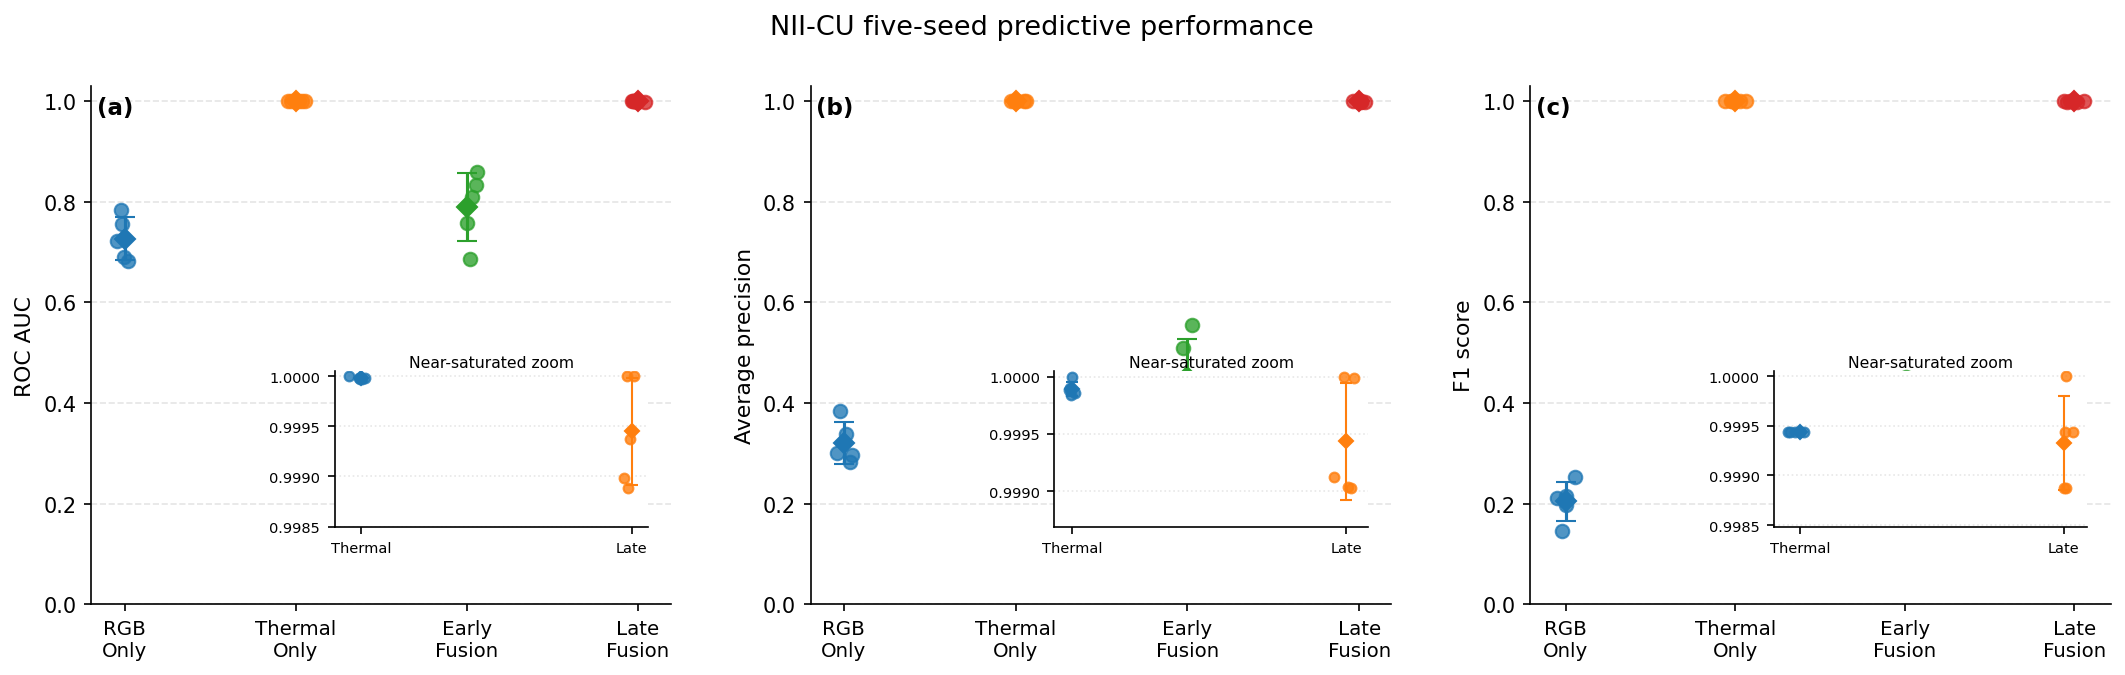

Saved:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_five_seed_performance_variability.pdf
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_five_seed_performance_variability.png


In [ ]:
# NII-CU FIVE-SEED PERFORMANCE VARIABILITY

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths

MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

AGGREGATE_DIR = (
    MULTISEED_ROOT
    / "aggregate"
)

FIGURE_DIR = (
    MULTISEED_ROOT
    / "manuscript_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

METRICS_PATH = (
    AGGREGATE_DIR
    / "nii_five_seed_test_metrics.csv"
)

PDF_PATH = (
    FIGURE_DIR
    / "nii_five_seed_performance_variability.pdf"
)

PNG_PATH = (
    FIGURE_DIR
    / "nii_five_seed_performance_variability.png"
)

# Load and validate

metrics_df = pd.read_csv(
    METRICS_PATH
)

required_columns = {
    "Model",
    "Seed",
    "AUC",
    "AP",
    "F1",
}

missing_columns = (
    required_columns
    - set(metrics_df.columns)
)

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(
            sorted(missing_columns)
        )
    )


expected_seeds = {
    42,
    43,
    44,
    45,
    46,
}

model_order = [
    "RGB-Only",
    "Thermal-Only",
    "Early-Fusion",
    "Late-Fusion",
]

model_labels = [
    "RGB\nOnly",
    "Thermal\nOnly",
    "Early\nFusion",
    "Late\nFusion",
]

for model_name in model_order:
    model_rows = metrics_df.loc[
        metrics_df["Model"]
        == model_name
    ]

    actual_seeds = set(
        model_rows["Seed"]
        .astype(int)
        .tolist()
    )

    if actual_seeds != expected_seeds:
        raise RuntimeError(
            f"{model_name} contains seeds "
            f"{sorted(actual_seeds)}, expected "
            f"{sorted(expected_seeds)}."
        )


metric_configuration = [
    {
        "column": "AUC",
        "label": "ROC AUC",
        "panel": "(a)",
    },
    {
        "column": "AP",
        "label": "Average precision",
        "panel": "(b)",
    },
    {
        "column": "F1",
        "label": "F1 score",
        "panel": "(c)",
    },
]

# Create figure

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(14.4, 4.8),
)

rng = np.random.default_rng(
    2026
)

for axis, config in zip(
    axes,
    metric_configuration,
):
    metric_column = config["column"]

    for model_index, model_name in enumerate(
        model_order
    ):
        model_rows = (
            metrics_df.loc[
                metrics_df["Model"]
                == model_name
            ]
            .sort_values("Seed")
        )

        values = (
            model_rows[
                metric_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        jitter = rng.uniform(
            -0.065,
            0.065,
            size=len(values),
        )

        axis.scatter(
            np.full(
                len(values),
                model_index,
                dtype=float,
            )
            + jitter,
            values,
            s=42,
            alpha=0.78,
            zorder=3,
        )

        metric_mean = float(
            np.mean(values)
        )

        metric_std = float(
            np.std(
                values,
                ddof=1,
            )
        )

        axis.errorbar(
            model_index,
            metric_mean,
            yerr=metric_std,
            fmt="D",
            markersize=6.5,
            capsize=5,
            linewidth=1.5,
            zorder=4,
        )

    axis.set_xticks(
        np.arange(
            len(model_order)
        )
    )

    axis.set_xticklabels(
        model_labels,
        fontsize=9.5,
    )

    axis.set_ylabel(
        config["label"],
        fontsize=10.5,
    )

    axis.set_ylim(
        0.0,
        1.03,
    )

    axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.32,
    )

    axis.spines[
        "top"
    ].set_visible(False)

    axis.spines[
        "right"
    ].set_visible(False)

    axis.text(
        0.01,
        0.98,
        config["panel"],
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        fontweight="bold",
    )

    # Zoomed inset for near-saturated Thermal/Late results

    inset_axis = axis.inset_axes(
        [
            0.42,
            0.15,
            0.54,
            0.30,
        ]
    )

    zoom_models = [
        "Thermal-Only",
        "Late-Fusion",
    ]

    zoom_positions = [
        0,
        1,
    ]

    zoom_values_all = []

    for zoom_index, model_name in zip(
        zoom_positions,
        zoom_models,
    ):
        model_rows = (
            metrics_df.loc[
                metrics_df["Model"]
                == model_name
            ]
            .sort_values("Seed")
        )

        values = (
            model_rows[
                metric_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        zoom_values_all.extend(
            values.tolist()
        )

        zoom_jitter = rng.uniform(
            -0.045,
            0.045,
            size=len(values),
        )

        inset_axis.scatter(
            np.full(
                len(values),
                zoom_index,
                dtype=float,
            )
            + zoom_jitter,
            values,
            s=22,
            alpha=0.8,
            zorder=3,
        )

        inset_axis.errorbar(
            zoom_index,
            float(
                np.mean(values)
            ),
            yerr=float(
                np.std(
                    values,
                    ddof=1,
                )
            ),
            fmt="D",
            markersize=4.5,
            capsize=3,
            linewidth=1.0,
            zorder=4,
        )

    zoom_min = min(
        zoom_values_all
    )

    zoom_max = max(
        zoom_values_all
    )

    zoom_padding = max(
        0.00008,
        (
            zoom_max
            - zoom_min
        )
        * 0.35,
    )

    inset_axis.set_ylim(
        zoom_min
        - zoom_padding,
        min(
            1.00005,
            zoom_max
            + zoom_padding,
        ),
    )

    inset_axis.set_xticks(
        zoom_positions
    )

    inset_axis.set_xticklabels(
        [
            "Thermal",
            "Late",
        ],
        fontsize=7,
    )

    inset_axis.tick_params(
        axis="y",
        labelsize=7,
    )

    inset_axis.grid(
        axis="y",
        linestyle=":",
        alpha=0.3,
    )

    inset_axis.set_title(
        "Near-saturated zoom",
        fontsize=7.5,
        pad=2,
    )


fig.suptitle(
    "NII-CU five-seed predictive performance",
    fontsize=13,
    y=0.98,
)

fig.subplots_adjust(
    left=0.06,
    right=0.995,
    top=0.88,
    bottom=0.16,
    wspace=0.24,
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

fig.savefig(
    PNG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Saved:")
print(PDF_PATH.resolve())
print(PNG_PATH.resolve())

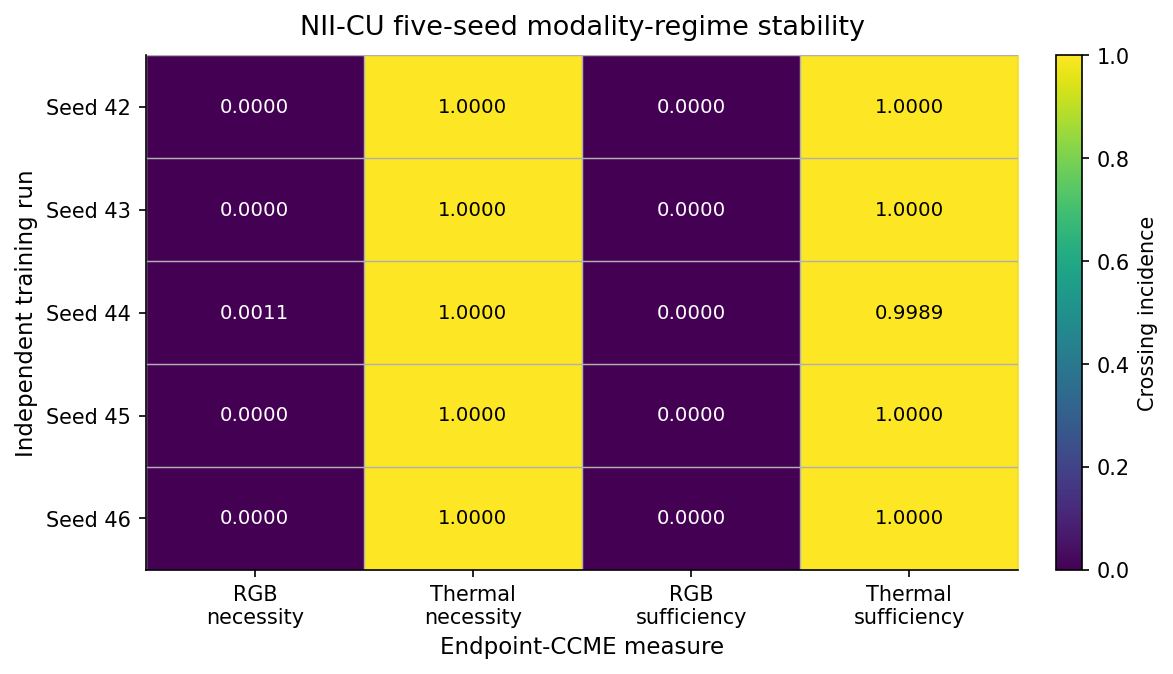

Saved:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_five_seed_regime_stability.pdf
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_five_seed_regime_stability.png


In [ ]:
# NII-CU FIVE-SEED ENDPOINT-CCME REGIME STABILITY

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths

MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

CCME_DIR = (
    MULTISEED_ROOT
    / "full_test_endpoint_ccme"
)

FIGURE_DIR = (
    MULTISEED_ROOT
    / "manuscript_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

REGIME_PATH = (
    CCME_DIR
    / "nii_five_seed_regime_stability.csv"
)

PDF_PATH = (
    FIGURE_DIR
    / "nii_five_seed_regime_stability.pdf"
)

PNG_PATH = (
    FIGURE_DIR
    / "nii_five_seed_regime_stability.png"
)

# Load and validate

regime_df = pd.read_csv(
    REGIME_PATH
)

required_columns = [
    "seed",
    "rgb_necessity_incidence",
    "thermal_necessity_incidence",
    "rgb_sufficiency_factual_positive_incidence",
    "thermal_sufficiency_factual_positive_incidence",
]

missing_columns = [
    column
    for column in required_columns
    if column not in regime_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(
            missing_columns
        )
    )


regime_df = (
    regime_df
    .sort_values("seed")
    .reset_index(drop=True)
)

expected_seeds = [
    42,
    43,
    44,
    45,
    46,
]

actual_seeds = (
    regime_df["seed"]
    .astype(int)
    .tolist()
)

if actual_seeds != expected_seeds:
    raise RuntimeError(
        f"Unexpected seed ordering: {actual_seeds}"
    )


heatmap_columns = [
    "rgb_necessity_incidence",
    "thermal_necessity_incidence",
    "rgb_sufficiency_factual_positive_incidence",
    "thermal_sufficiency_factual_positive_incidence",
]

heatmap_labels = [
    "RGB\nnecessity",
    "Thermal\nnecessity",
    "RGB\nsufficiency",
    "Thermal\nsufficiency",
]

heatmap_values = (
    regime_df[
        heatmap_columns
    ]
    .to_numpy(
        dtype=float
    )
)


if (
    heatmap_values.min() < 0
    or heatmap_values.max() > 1
):
    raise ValueError(
        "Crossing incidences must lie within [0, 1]."
    )


# Create heatmap

fig, axis = plt.subplots(
    figsize=(8.6, 4.9),
)

image = axis.imshow(
    heatmap_values,
    aspect="auto",
    vmin=0.0,
    vmax=1.0,
)

axis.set_xticks(
    np.arange(
        len(heatmap_labels)
    )
)

axis.set_xticklabels(
    heatmap_labels,
    fontsize=10,
)

axis.set_yticks(
    np.arange(
        len(regime_df)
    )
)

axis.set_yticklabels(
    [
        f"Seed {int(seed)}"
        for seed in regime_df["seed"]
    ],
    fontsize=10,
)

axis.set_xlabel(
    "Endpoint-CCME measure",
    fontsize=11,
)

axis.set_ylabel(
    "Independent training run",
    fontsize=11,
)

axis.set_title(
    "NII-CU five-seed modality-regime stability",
    fontsize=13,
    pad=10,
)


# Cell annotations

for row_index in range(
    heatmap_values.shape[0]
):
    for column_index in range(
        heatmap_values.shape[1]
    ):
        value = float(
            heatmap_values[
                row_index,
                column_index,
            ]
        )

        text_color = (
            "white"
            if value < 0.45
            else "black"
        )

        axis.text(
            column_index,
            row_index,
            f"{value:.4f}",
            ha="center",
            va="center",
            fontsize=9.5,
            color=text_color,
            fontweight="medium",
        )

# Cell boundaries

axis.set_xticks(
    np.arange(
        -0.5,
        heatmap_values.shape[1],
        1,
    ),
    minor=True,
)

axis.set_yticks(
    np.arange(
        -0.5,
        heatmap_values.shape[0],
        1,
    ),
    minor=True,
)

axis.grid(
    which="minor",
    linewidth=0.7,
)

axis.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

# Colorbar

colorbar = fig.colorbar(
    image,
    ax=axis,
    fraction=0.046,
    pad=0.04,
)

colorbar.set_label(
    "Crossing incidence",
    fontsize=10,
)

colorbar.set_ticks(
    np.linspace(
        0,
        1,
        6,
    )
)


fig.subplots_adjust(
    left=0.15,
    right=0.89,
    top=0.88,
    bottom=0.18,
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

fig.savefig(
    PNG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Saved:")
print(PDF_PATH.resolve())
print(PNG_PATH.resolve())

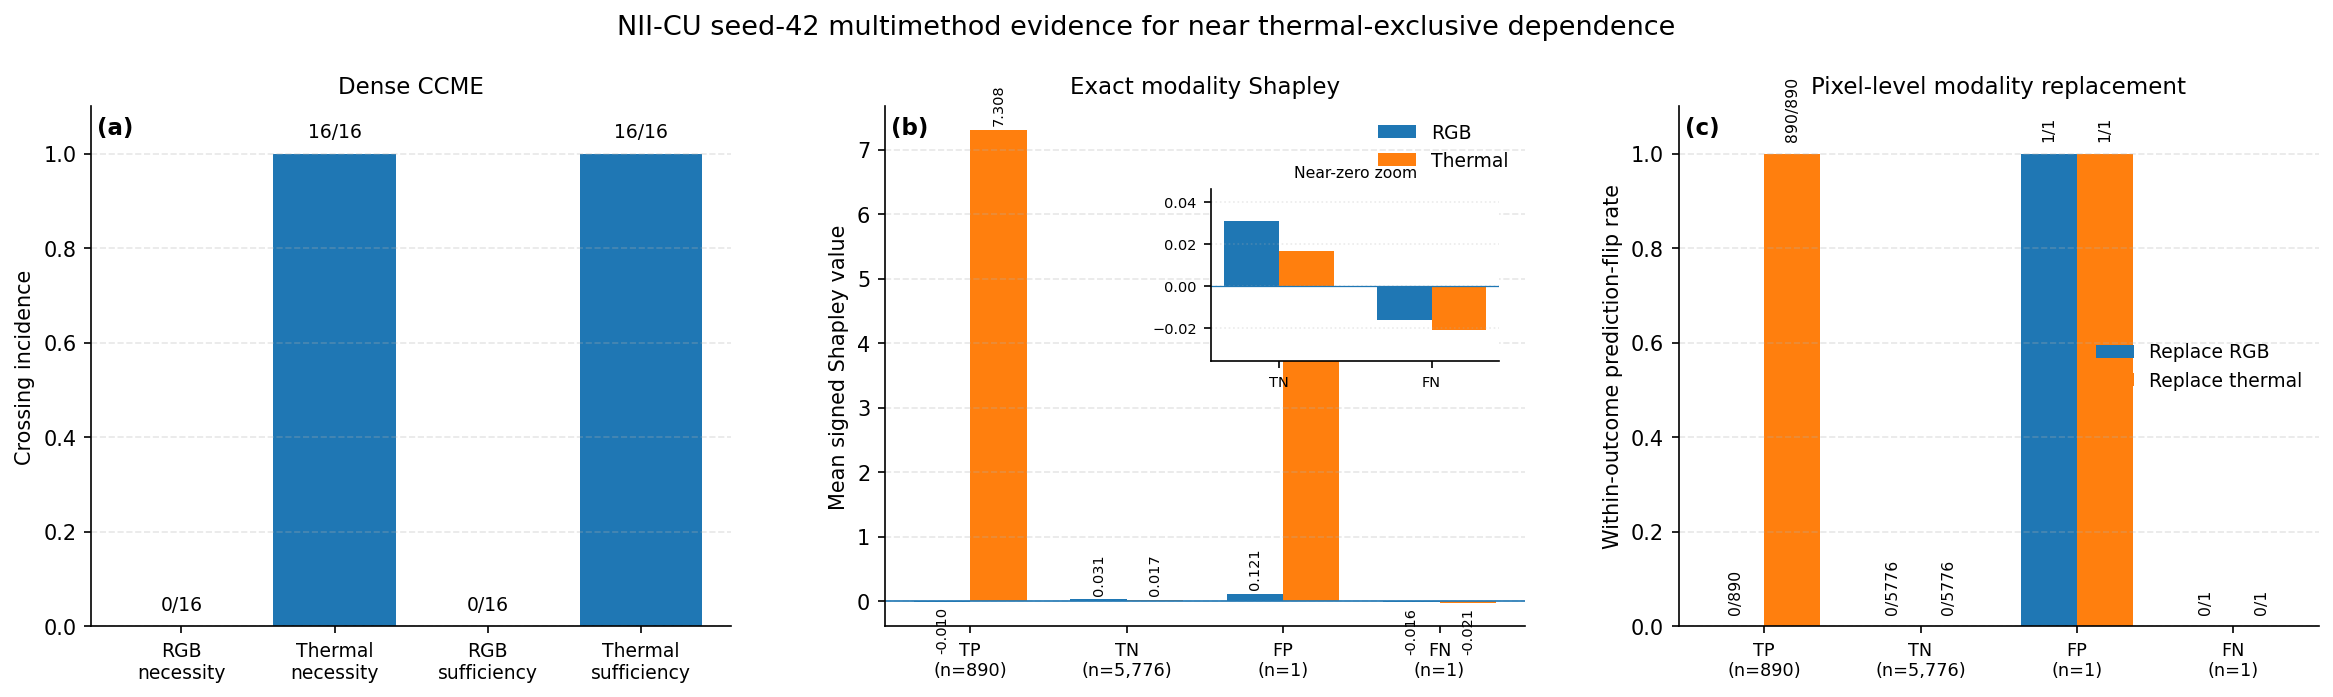

Saved:
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_seed42_multimethod_modality_analysis.pdf
/Users/mdtohidulislam/Documents/BU 2025/Fall 2025/AI Guided Drone Project/Fusion Model/Nii_CU/NII_CU_MAPD_dataset/nii_checkpoints/multiseed_42_46/manuscript_figures/nii_seed42_multimethod_modality_analysis.png


In [ ]:
# NII-CU SEED-42 MULTIMETHOD MODALITY ANALYSIS

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Output paths

MULTISEED_ROOT = (
    Path(NII_CKPT)
    / "multiseed_42_46"
)

FIGURE_DIR = (
    MULTISEED_ROOT
    / "manuscript_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PDF_PATH = (
    FIGURE_DIR
    / "nii_seed42_multimethod_modality_analysis.pdf"
)

PNG_PATH = (
    FIGURE_DIR
    / "nii_seed42_multimethod_modality_analysis.png"
)


# Panel A: Dense CCME
#
# Representative subset:
# 15 TP, 15 TN, 1 FP, 1 FN
#
# Factual-positive predictions:
# 16 = 15 TP + 1 FP

ccme_labels = [
    "RGB\nnecessity",
    "Thermal\nnecessity",
    "RGB\nsufficiency",
    "Thermal\nsufficiency",
]

ccme_crossed = np.array([
    0,
    16,
    0,
    16,
])

ccme_applicable = np.array([
    16,
    16,
    16,
    16,
])

ccme_incidence = (
    ccme_crossed
    / ccme_applicable
)

# Panel B: Exact Shapley by outcome

outcome_labels = [
    "TP\n(n=890)",
    "TN\n(n=5,776)",
    "FP\n(n=1)",
    "FN\n(n=1)",
]

rgb_shapley = np.array([
    -0.010334,
     0.030852,
     0.121364,
    -0.016328,
])

thermal_shapley = np.array([
     7.307637,
     0.016772,
     4.348164,
    -0.020757,
])


# Panel C: Pixel-level replacement
#
# Expressed as within-outcome flip rates.

replacement_labels = [
    "TP\n(n=890)",
    "TN\n(n=5,776)",
    "FP\n(n=1)",
    "FN\n(n=1)",
]

rgb_replacement_flip_counts = np.array([
    0,
    0,
    1,
    0,
])

thermal_replacement_flip_counts = np.array([
    890,
    0,
    1,
    0,
])

outcome_counts = np.array([
    890,
    5776,
    1,
    1,
])

rgb_replacement_rates = (
    rgb_replacement_flip_counts
    / outcome_counts
)

thermal_replacement_rates = (
    thermal_replacement_flip_counts
    / outcome_counts
)


# Create figure

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15.8, 5.1),
)

bar_width = 0.36


# Panel A: Dense CCME

axis_a = axes[0]

positions_a = np.arange(
    len(ccme_labels)
)

bars_a = axis_a.bar(
    positions_a,
    ccme_incidence,
)

axis_a.set_xticks(
    positions_a
)

axis_a.set_xticklabels(
    ccme_labels,
    fontsize=9,
)

axis_a.set_ylim(
    0.0,
    1.10,
)

axis_a.set_ylabel(
    "Crossing incidence",
    fontsize=10,
)

axis_a.set_title(
    "Dense CCME",
    fontsize=11,
)

axis_a.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axis_a.spines[
    "top"
].set_visible(False)

axis_a.spines[
    "right"
].set_visible(False)

for bar, crossed, applicable, incidence in zip(
    bars_a,
    ccme_crossed,
    ccme_applicable,
    ccme_incidence,
):
    axis_a.text(
        bar.get_x()
        + bar.get_width() / 2,
        incidence + 0.025,
        f"{crossed}/{applicable}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

axis_a.text(
    0.01,
    0.98,
    "(a)",
    transform=axis_a.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold",
)

# Panel B: Exact Shapley

axis_b = axes[1]

positions_b = np.arange(
    len(outcome_labels)
)

rgb_bars = axis_b.bar(
    positions_b - bar_width / 2,
    rgb_shapley,
    width=bar_width,
    label="RGB",
)

thermal_bars = axis_b.bar(
    positions_b + bar_width / 2,
    thermal_shapley,
    width=bar_width,
    label="Thermal",
)

axis_b.axhline(
    0.0,
    linewidth=0.8,
)

axis_b.set_xticks(
    positions_b
)

axis_b.set_xticklabels(
    outcome_labels,
    fontsize=8.5,
)

axis_b.set_ylabel(
    "Mean signed Shapley value",
    fontsize=10,
)

axis_b.set_title(
    "Exact modality Shapley",
    fontsize=11,
)

axis_b.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axis_b.legend(
    frameon=False,
    fontsize=9,
)

axis_b.spines[
    "top"
].set_visible(False)

axis_b.spines[
    "right"
].set_visible(False)

axis_b.text(
    0.01,
    0.98,
    "(b)",
    transform=axis_b.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold",
)


# Add labels for all Shapley bars, including near-zero values.
for bar, value in zip(
    rgb_bars,
    rgb_shapley,
):
    vertical_alignment = (
        "bottom"
        if value >= 0
        else "top"
    )

    vertical_offset = (
        0.07
        if value >= 0
        else -0.07
    )

    axis_b.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + vertical_offset,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=7,
        rotation=90,
    )

for bar, value in zip(
    thermal_bars,
    thermal_shapley,
):
    vertical_alignment = (
        "bottom"
        if value >= 0
        else "top"
    )

    vertical_offset = (
        0.07
        if value >= 0
        else -0.07
    )

    axis_b.text(
        bar.get_x()
        + bar.get_width() / 2,
        value + vertical_offset,
        f"{value:.3f}",
        ha="center",
        va=vertical_alignment,
        fontsize=7,
        rotation=90,
    )


# Zoom inset for small Shapley values
shapley_inset = axis_b.inset_axes(
    [
        0.51,
        0.51,
        0.45,
        0.33,
    ]
)

small_indices = np.array([
    1,
    3,
])

small_positions = np.arange(
    len(small_indices)
)

shapley_inset.bar(
    small_positions - bar_width / 2,
    rgb_shapley[
        small_indices
    ],
    width=bar_width,
)

shapley_inset.bar(
    small_positions + bar_width / 2,
    thermal_shapley[
        small_indices
    ],
    width=bar_width,
)

shapley_inset.axhline(
    0,
    linewidth=0.6,
)

shapley_inset.set_xticks(
    small_positions
)

shapley_inset.set_xticklabels(
    [
        "TN",
        "FN",
    ],
    fontsize=7,
)

shapley_inset.tick_params(
    axis="y",
    labelsize=7,
)

shapley_inset.set_title(
    "Near-zero zoom",
    fontsize=7.5,
)

small_values = np.concatenate([
    rgb_shapley[
        small_indices
    ],
    thermal_shapley[
        small_indices
    ],
])

small_padding = 0.015

shapley_inset.set_ylim(
    float(
        small_values.min()
        - small_padding
    ),
    float(
        small_values.max()
        + small_padding
    ),
)

shapley_inset.grid(
    axis="y",
    linestyle=":",
    alpha=0.25,
)


# Panel C: Replacement rates

axis_c = axes[2]

positions_c = np.arange(
    len(replacement_labels)
)

rgb_rate_bars = axis_c.bar(
    positions_c - bar_width / 2,
    rgb_replacement_rates,
    width=bar_width,
    label="Replace RGB",
)

thermal_rate_bars = axis_c.bar(
    positions_c + bar_width / 2,
    thermal_replacement_rates,
    width=bar_width,
    label="Replace thermal",
)

axis_c.set_xticks(
    positions_c
)

axis_c.set_xticklabels(
    replacement_labels,
    fontsize=8.5,
)

axis_c.set_ylim(
    0.0,
    1.10,
)

axis_c.set_ylabel(
    "Within-outcome prediction-flip rate",
    fontsize=10,
)

axis_c.set_title(
    "Pixel-level modality replacement",
    fontsize=11,
)

axis_c.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axis_c.legend(
    frameon=False,
    fontsize=9,
)

axis_c.spines[
    "top"
].set_visible(False)

axis_c.spines[
    "right"
].set_visible(False)

axis_c.text(
    0.01,
    0.98,
    "(c)",
    transform=axis_c.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold",
)


for (
    bar,
    rate,
    count,
    denominator,
) in zip(
    rgb_rate_bars,
    rgb_replacement_rates,
    rgb_replacement_flip_counts,
    outcome_counts,
):
    axis_c.text(
        bar.get_x()
        + bar.get_width() / 2,
        rate + 0.025,
        f"{count}/{denominator}",
        ha="center",
        va="bottom",
        fontsize=7.5,
        rotation=90,
    )

for (
    bar,
    rate,
    count,
    denominator,
) in zip(
    thermal_rate_bars,
    thermal_replacement_rates,
    thermal_replacement_flip_counts,
    outcome_counts,
):
    axis_c.text(
        bar.get_x()
        + bar.get_width() / 2,
        rate + 0.025,
        f"{count}/{denominator}",
        ha="center",
        va="bottom",
        fontsize=7.5,
        rotation=90,
    )


# Overall formatting

fig.suptitle(
    "NII-CU seed-42 multimethod evidence for near thermal-exclusive dependence",
    fontsize=13,
    y=0.98,
)

fig.subplots_adjust(
    left=0.055,
    right=0.995,
    top=0.86,
    bottom=0.18,
    wspace=0.24,
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

fig.savefig(
    PNG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print("Saved:")
print(PDF_PATH.resolve())
print(PNG_PATH.resolve())

## Interpretation and Scope

Population-level predictive and modality-dependence conclusions are based on
the complete NII-CU held-out test partition evaluated across five
independently trained checkpoints.

The detailed CCME flip-point, reference-sensitivity, exact Shapley,
pixel-level modality-replacement, and calibration analyses use the designated
seed-42 Late-Fusion checkpoint unless otherwise stated.

Under the evaluated low-illumination and high-thermal-contrast conditions,
NII-CU exhibits a near thermal-exclusive fusion regime. This result is
specific to the evaluated model, references, and operating conditions and
should not be interpreted as a universal property of RGB-thermal person
detection.

CCME measures model dependence under defined interventions and does not
establish physical-world causality.